<a href="https://colab.research.google.com/github/Knerdy-got-moves/Many-body-dynamics-in-Floquet-driven-systems/blob/main/Entanglement_entropy/PBC_Optimised_entanglement_entropy_in_large_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model: Kicked transverse field Ising model under periodic boundary conditions


Consider a transverse-field Ising chain of length $L$ with periodic boundary conditions (PBC), Pauli operators $\sigma_i^{x,y,z}$, and a weak transverse perturbation:
$$
H(t)=H_0(t)+H_1,
\qquad
H_0(t)=-J(t)\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z-h(t)\sum_{i=1}^{L}\sigma_i^z,
\qquad
H_1=-g\sum_{i=1}^{L}\sigma_i^x,\;\; |g|\ll \{|J_0|,|h_0|\},
$$
with periodic identification $\sigma_{L+1}^z\equiv\sigma_1^z$.
Both couplings follow the same symmetric square–wave of period $T$:
$$
J(t)=
\begin{cases}
+J_0,& 0\le t\le T/2,\\
-J_0,& T/2<t\le T,
\end{cases}
\qquad
h(t)=
\begin{cases}
+h_0,& 0\le t\le T/2,\\
-h_0,& T/2<t\le T.
\end{cases}
$$

For a Floquet period-$n$ state,
$$
|\psi(nT)\rangle = U_F^{\,n}\,|\psi(0)\rangle,
\qquad
U_F = e^{-i H_{+}\, T/2}\, e^{-i H_{-}\, T/2},
$$
where $H_{\pm}$ denote $H(t)$ with $(J,h)=(\pm J_0,\pm h_0)$ on the corresponding half-period.

Bipartition the ring into a contiguous block (A) of size $L_A$ and its complement (B) of size $L_B=L-L_A$.
The reduced density matrix of (A) at stroboscopic time $t=nT$ is
$$
\rho_A(nT)=\mathrm{Tr}_B\!\left[\,|\psi(nT)\rangle\langle\psi(nT)|\,\right],
$$
and the von Neumann entanglement entropy is
$$
S_A(nT)=-\mathrm{Tr}\!\big[\rho_A(nT)\,\ln\rho_A(nT)\big].
$$
With the Schmidt decomposition across the cut,
$$
|\psi(nT)\rangle=\sum_k s_k(nT)\,|k_A\rangle\otimes|k_B\rangle,
\qquad
p_k(nT)=\big(s_k(nT)\big)^2,
$$
the same entropy is
$$
S_A(nT)=-\sum_k p_k(nT)\,\ln p_k(nT).
$$

For the Page value at a half-chain cut, let
$$
L_A=\Big\lfloor \frac{L}{2}\Big\rfloor,\quad
L_B=L-L_A,\qquad
m=2^{L_A},\quad n=2^{L_B}.
$$
Then the average (Page) entanglement entropy is approximately
$$
S_{\text{Page}}\simeq \ln m-\frac{m}{2n}
= L_A\ln 2 - 2^{\,2L_A-L-1}.
$$
We plot the ratio
$$
\frac{S_A(nT)}{S_{\text{Page}}}\,.
$$



# Numerical Hamiltonian, Floquet unitary, Bipartite entanglement entropy

Here we define the couplings $J_0$, $h_0$ and the time period, $TP$. We compute the entanglement entropy for a random state and show that it saturates below the Eigenstate Thermalisation Hypothesis (ETH) value predicted vlaue, the Page value.

References for ETH:
1.   J. M. Deutsch, "Quantum statistical mechanics in a closed system," Phys. Rev. A 43, 2046-2049 (1991). doi: [10.1103/PhysRevA.43.2046](https://link.aps.org/doi/10.1103/PhysRevA.43.2046​).
2.   Mark Srednicki, "Chaos and quantum thermalization," Phys. Rev. E 50, 888-901 (1994). doi: [10.1103/PhysRevE.50.888](https://link.aps.org/doi/10.1103/PhysRevE.50.888​).
3.   Luca D'Alessio et al., "From quantum chaos and eigenstate thermalization to statistical mechanics and thermodynamics," Adv. Phys. 65, 239-362 (2016). doi: [10.1080/00018732.2016.1198134](https://doi.org/10.1080/00018732.2016.1198134).

References for Page value:


1.   Don N. Page, "Average entropy of a subsystem," Phys. Rev. Lett. 71, 1291-1294 (1993). doi: [10.1103/PhysRevLett.71.1291](https://doi.org/10.1103/PhysRevLett.71.1291).
2.   S. K. Foong and S. Kanno, "Proof of Page's conjecture on the average entropy of a subsystem," Phys. Rev. Lett. 72, 1148-1151 (1994). doi: [10.1103/PhysRevLett.72.1148](https://doi.org/10.1103/PhysRevLett.72.1148).
3.   L. Vidmar and M. Rigol, "Entanglement Entropy of Eigenstates of Quantum Chaotic Hamiltonians," Phys. Rev. Lett. 119, 220603 (2017). doi: [10.1103/PhysRevLett.119.220603](https://doi.org/10.1103/PhysRevLett.119.220603).











In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import LinearOperator


# ============================================================
# STANDALONE SPARSE HAMILTONIAN BUILDER — PERIODIC BC
# ============================================================

def build_H_floquet_pbc(L, J0, h0, g, which):
    """
    Construct a Floquet half-period Hamiltonian for the **periodic** Ising chain.

    H_+ = -J0 Σ_{i=0}^{L-1} σ^z_i σ^z_{(i+1)%L}  - h0 Σ σ^z_i  - g Σ σ^x_i
    H_- = +J0 Σ_{i=0}^{L-1} σ^z_i σ^z_{(i+1)%L}  + h0 Σ σ^z_i  - g Σ σ^x_i

    Parameters
    ----------
    L : int
        Chain length (number of sites).  Must be >= 2.
    J0 : float
        Ising nearest-neighbour coupling amplitude.
    h0 : float
        Longitudinal field amplitude.
    g : float
        Transverse field strength.
    which : {"plus", "minus"}
        Selects the half-period Hamiltonian.

    Returns
    -------
    H : scipy.sparse.csr_matrix, shape (N, N), dtype np.float64
        The Hamiltonian in CSR canonical form.
        Each row has exactly (L + 1) stored entries
        (1 diagonal + L off-diagonal sigma^x flips).
        Total nnz = N * (L + 1), where N = 2^L.

    Notes
    -----
    PBC adds the wrap-around bond (site L-1, site 0) compared to OBC.
    In bit arithmetic:
        site i   → bit position (L - 1 - i)
        site i+1 → bit position (L - 1 - ((i+1) % L))

    The wrap-around bond (i = L-1) gives:
        bit_pos(L-1) = 0,   bit_pos(0) = L-1
        σ^z_{L-1} σ^z_0 = 1 - 2 * (bit_0 XOR bit_{L-1})
    """
    if L < 2:
        raise ValueError(f"L must be >= 2, got {L}")
    if which not in ("plus", "minus"):
        raise ValueError(f"which must be 'plus' or 'minus', got '{which}'")

    N = 1 << L

    if which == "plus":
        signJ, signh = -1.0, -1.0
    else:
        signJ, signh = +1.0, +1.0

    states = np.arange(N, dtype=np.int64)

    # ---- Diagonal: ZZ (PBC: L bonds) + Z contributions ----
    diag = np.zeros(N, dtype=np.float64)

    # ZZ interaction: L bonds including wrap-around (i=L-1 → i+1=0)
    coeff_zz = signJ * J0
    for i in range(L):
        pi  = L - 1 - i                        # bit position of site i
        pi1 = L - 1 - ((i + 1) % L)            # bit position of site (i+1) mod L
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag += coeff_zz * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Z field: L terms (unchanged from OBC)
    coeff_z = signh * h0
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag += coeff_z * (1.0 - 2.0 * ci.astype(np.float64))

    # ---- Off-diagonal: σ^x flips (unchanged from OBC) ----
    # Build (column, value) arrays, shape (N, L+1)
    all_cols = np.empty((N, L + 1), dtype=np.int64)
    all_vals = np.empty((N, L + 1), dtype=np.float64)

    # Column 0 = diagonal
    all_cols[:, 0] = states
    all_vals[:, 0] = diag

    # Columns 1..L = σ^x bit-flips at each site
    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        all_cols[:, 1 + i] = states ^ flip_mask
        all_vals[:, 1 + i] = -g

    # ---- Sort columns within each row (CSR canonical form) ----
    sort_idx = np.argsort(all_cols, axis=1, kind='stable')
    all_cols = np.take_along_axis(all_cols, sort_idx, axis=1)
    all_vals = np.take_along_axis(all_vals, sort_idx, axis=1)

    # ---- Assemble CSR matrix ----
    indptr  = np.arange(N + 1, dtype=np.int64) * (L + 1)
    indices = all_cols.ravel()
    data    = all_vals.ravel()

    H = csr_matrix((data, indices, indptr), shape=(N, N))
    H.has_sorted_indices = True

    return H


# ============================================================
# LIGHTWEIGHT BASIS DESCRIPTOR
# ============================================================

class _BasisInfo:
    """
    Drop-in for QuSpin's spin_basis_1d, exposing .Ns and .states.
    """
    __slots__ = ('L', 'Ns', 'states')

    def __init__(self, L):
        self.L = L
        self.Ns = 1 << L
        self.states = np.arange(1 << L, dtype=np.int64)

    def __repr__(self):
        return f"_BasisInfo(L={self.L}, Ns={self.Ns})"


# ============================================================
# OOP INTERFACE — PERIODIC BC
# ============================================================

class FloquetIsingChain:
    """
    Floquet-driven Ising chain with **periodic** boundary conditions.

    After calling build_hamiltonians(), the following are available:
        .H_plus_sparse   : csr_matrix  — H_+ (first half-period)
        .H_minus_sparse  : csr_matrix  — H_- (second half-period)
        .A_plus          : csr_matrix  — -i * H_+ * T/(2*hbar), complex128
        .A_minus         : csr_matrix  — -i * H_- * T/(2*hbar), complex128

    The cached A_plus / A_minus are the generators for expm_multiply:
        exp(A_plus) |ψ⟩ = exp(-i H_+ T/(2ℏ)) |ψ⟩
    """

    def __init__(self, L=8, J_0=4.0, h_0=8.0, g=1.0, TP=np.pi/4.0, hbar=1.0):
        self.L = L
        self.J_0 = J_0
        self.h_0 = h_0
        self.g = g
        self.hbar = hbar
        self.T = TP

        self.Ns = 1 << L
        self.basis = _BasisInfo(L)

        # Built on demand
        self._H_plus_sparse = None
        self._H_minus_sparse = None
        self._A_plus = None
        self._A_minus = None

        # Adaptive subdivision for Krylov (set in build_hamiltonians)
        self._A_plus_norm1 = None
        self._A_minus_norm1 = None
        self._K_plus = 1        # number of sub-steps for A_plus
        self._K_minus = 1       # number of sub-steps for A_minus
        self._A_plus_sub = None   # A_plus / K_plus (pre-scaled)
        self._A_minus_sub = None  # A_minus / K_minus (pre-scaled)

        print(f"System Parameters (PERIODIC BC):")
        print(f"  Chain length L = {self.L}")
        print(f"  J_0 = {self.J_0}")
        print(f"  h_0 = {self.h_0}")
        print(f"  g = {self.g}")
        print(f"  Period T = {self.T:.6f}")
        print(f"  Hilbert space dimension = {self.Ns}")

    # --------------------------------------------------------
    # Hamiltonian construction
    # --------------------------------------------------------

    def build_hamiltonians(self):
        """
        Build H_+ and H_- (PBC) and cache Krylov generators A_±.

        Returns
        -------
        H_plus_sparse  : csr_matrix, shape (Ns, Ns), float64
        H_minus_sparse : csr_matrix, shape (Ns, Ns), float64
        """
        self._H_plus_sparse = build_H_floquet_pbc(
            self.L, self.J_0, self.h_0, self.g, "plus"
        )
        self._H_minus_sparse = build_H_floquet_pbc(
            self.L, self.J_0, self.h_0, self.g, "minus"
        )

        # --- Cache Krylov generators: A = -i * H * T/(2*hbar) ---
        scale = -1j * self.T / (2.0 * self.hbar)
        self._A_plus  = (scale * self._H_plus_sparse).tocsr()
        self._A_minus = (scale * self._H_minus_sparse).tocsr()

        # --- Adaptive subdivision for large spectral norms ---
        # When ||A||_1 is large, expm_multiply does many internal
        # Lanczos restarts (cost ~ ||A||_1 / 5 restarts).
        # We subdivide manually: exp(A) = (exp(A/K))^K where
        # K = ceil(||A||_1 / NORM_THRESHOLD).  Pre-scale once here.
        from scipy.sparse.linalg import norm as sp_norm
        NORM_THRESHOLD = 5.0

        self._A_plus_norm1  = sp_norm(self._A_plus, ord=1)
        self._A_minus_norm1 = sp_norm(self._A_minus, ord=1)

        self._K_plus  = max(1, int(np.ceil(self._A_plus_norm1 / NORM_THRESHOLD)))
        self._K_minus = max(1, int(np.ceil(self._A_minus_norm1 / NORM_THRESHOLD)))

        if self._K_plus == 1:
            self._A_plus_sub = self._A_plus
        else:
            self._A_plus_sub = (self._A_plus / self._K_plus).tocsr()

        if self._K_minus == 1:
            self._A_minus_sub = self._A_minus
        else:
            self._A_minus_sub = (self._A_minus / self._K_minus).tocsr()

        # --- Validation ---
        assert self._H_plus_sparse.shape == (self.Ns, self.Ns)
        assert self._H_minus_sparse.shape == (self.Ns, self.Ns)

        nnz_expected = self.Ns * (self.L + 1)
        nnz_actual = self._H_plus_sparse.nnz
        assert nnz_actual == nnz_expected, \
            f"nnz mismatch: got {nnz_actual}, expected {nnz_expected}"

        density = nnz_actual / (self.Ns ** 2)

        print(f"\nHamiltonians constructed successfully (PERIODIC BC)!")
        print(f"  H+ shape: {self._H_plus_sparse.shape}, nnz = {nnz_actual}")
        print(f"  Number of ZZ bonds: {self.L} (including wrap-around)")
        print(f"  Density: {density:.2e}")
        print(f"  Memory per H matrix: ~{self._estimate_sparse_memory():.2f} MB")
        print(f"  A_plus dtype: {self._A_plus.dtype}  (Krylov generator cached)")
        print(f"  ||A+||_1 = {self._A_plus_norm1:.2f}, "
              f"||A-||_1 = {self._A_minus_norm1:.2f}")
        print(f"  Krylov sub-steps: K+ = {self._K_plus}, K- = {self._K_minus}"
              f"{'  (no subdivision needed)' if self._K_plus == 1 and self._K_minus == 1 else ''}")

        self._verify_hermiticity()

        return self._H_plus_sparse, self._H_minus_sparse

    # --------------------------------------------------------
    # Hermiticity verification
    # --------------------------------------------------------

    def _verify_hermiticity(self, n_samples=5):
        """Verify ⟨v|H|w⟩ = ⟨w|H|v⟩* via random complex vectors."""
        if self._H_plus_sparse is None:
            return

        rng = np.random.RandomState(42)
        max_diff_p = 0.0
        max_diff_m = 0.0

        for _ in range(n_samples):
            v = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)
            w = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)

            # Check H_plus
            vHw = np.vdot(v, self._H_plus_sparse @ w)
            wHv = np.vdot(w, self._H_plus_sparse @ v)
            max_diff_p = max(max_diff_p, abs(vHw - np.conj(wHv)))

            # Check H_minus
            vHw = np.vdot(v, self._H_minus_sparse @ w)
            wHv = np.vdot(w, self._H_minus_sparse @ v)
            max_diff_m = max(max_diff_m, abs(vHw - np.conj(wHv)))

        print(f"  Hermiticity check (H+): max err = {max_diff_p:.2e}")
        print(f"  Hermiticity check (H-): max err = {max_diff_m:.2e}")
        assert max_diff_p < 1e-8, f"H+ hermiticity violated: {max_diff_p}"
        assert max_diff_m < 1e-8, f"H- hermiticity violated: {max_diff_m}"

    # --------------------------------------------------------
    # Memory estimation
    # --------------------------------------------------------

    def _estimate_sparse_memory(self):
        """Estimate CSR memory for one Hamiltonian in MB."""
        nnz = self.Ns * (self.L + 1)
        bytes_data    = nnz * 8              # float64 data
        bytes_indices = nnz * 8              # int64 column indices
        bytes_indptr  = (self.Ns + 1) * 8    # int64 row pointers
        return (bytes_data + bytes_indices + bytes_indptr) / (1024 ** 2)

    # --------------------------------------------------------
    # Properties
    # --------------------------------------------------------

    @property
    def H_plus_sparse(self):
        if self._H_plus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_plus_sparse

    @property
    def H_minus_sparse(self):
        if self._H_minus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_minus_sparse

    @property
    def A_plus(self):
        """Krylov generator: -i * H_+ * T/(2*hbar), complex128 CSR."""
        if self._A_plus is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_plus

    @property
    def A_minus(self):
        """Krylov generator: -i * H_- * T/(2*hbar), complex128 CSR."""
        if self._A_minus is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_minus

    @property
    def A_plus_sub(self):
        """Pre-scaled A_plus / K_plus for adaptive Krylov subdivision."""
        if self._A_plus_sub is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_plus_sub

    @property
    def A_minus_sub(self):
        """Pre-scaled A_minus / K_minus for adaptive Krylov subdivision."""
        if self._A_minus_sub is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_minus_sub

    @property
    def K_plus(self):
        """Number of sub-steps for A_plus Krylov evolution."""
        return self._K_plus

    @property
    def K_minus(self):
        """Number of sub-steps for A_minus Krylov evolution."""
        return self._K_minus

    # --------------------------------------------------------
    # LinearOperator fallbacks
    # --------------------------------------------------------

    def get_H_plus_linop(self):
        H = self.H_plus_sparse
        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=lambda v: H @ v,
            rmatvec=lambda v: H @ v,   # real symmetric
            dtype=np.complex128
        )

    def get_H_minus_linop(self):
        H = self.H_minus_sparse
        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=lambda v: H @ v,
            rmatvec=lambda v: H @ v,
            dtype=np.complex128
        )


# ============================================================
# SELF-TESTS (run when this cell is executed)
# ============================================================

if __name__ == "__main__" or True:   # always run in notebook

    print("=" * 72)
    print("PROMPT 1: Sparse PBC Hamiltonian Builder — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Basic construction and shape
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Basic construction at L=8")
    print("-" * 72)

    L = 8
    ising = FloquetIsingChain(L=L, J_0=4.0, h_0=8.0, g=1.0,
                              TP=np.pi/4.0, hbar=1.0)
    H_plus, H_minus = ising.build_hamiltonians()

    Ns = 2**L
    assert H_plus.shape == (Ns, Ns), f"Shape mismatch: {H_plus.shape}"
    assert H_minus.shape == (Ns, Ns), f"Shape mismatch: {H_minus.shape}"
    assert H_plus.nnz == Ns * (L + 1), f"nnz mismatch: {H_plus.nnz}"
    print("  PASS: shapes and nnz correct")

    # ----------------------------------------------------------
    # TEST 2: Real symmetry (H = H^T since H is real)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Real symmetry H = H^T")
    print("-" * 72)

    for label, H in [("H+", H_plus), ("H-", H_minus)]:
        diff = (H - H.T).data
        max_asym = np.max(np.abs(diff)) if len(diff) > 0 else 0.0
        print(f"  {label}: max|H - H^T| = {max_asym:.2e}")
        assert max_asym < 1e-12, f"{label} not symmetric!"
    print("  PASS: both Hamiltonians are exactly symmetric")

    # ----------------------------------------------------------
    # TEST 3: H_+ and H_- relationship
    #   H_- should equal -H_+ + (common transverse part)
    #   Specifically: H_+ + H_- = -2g Σ σ^x_i
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: H_+ + H_- = -2g Σ σ^x_i")
    print("-" * 72)

    H_sum = H_plus + H_minus
    H_sum_dense = H_sum.toarray()

    # Build expected: -2g Σ σ^x_i
    g_val = 1.0
    expected = np.zeros((Ns, Ns), dtype=np.float64)
    states = np.arange(Ns, dtype=np.int64)
    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        for s in range(Ns):
            s_flip = int(s ^ flip_mask)
            expected[s, s_flip] += -2.0 * g_val

    max_diff = np.max(np.abs(H_sum_dense - expected))
    print(f"  max|H_+ + H_- - (-2g Σσ^x)| = {max_diff:.2e}")
    assert max_diff < 1e-12, f"H_+/H_- relationship broken: {max_diff}"
    print("  PASS: H_+ + H_- identity verified")

    # ----------------------------------------------------------
    # TEST 4: PBC wrap-around bond check
    #   Compare L=4 PBC vs OBC diagonal to verify the extra bond
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: PBC wrap-around bond presence (L=4)")
    print("-" * 72)

    L_test = 4
    J0_test, h0_test, g_test = 4.0, 8.0, 1.0
    N_test = 2**L_test

    H_pbc = build_H_floquet_pbc(L_test, J0_test, h0_test, g_test, "plus")
    H_pbc_dense = H_pbc.toarray()

    # Build OBC version manually for comparison
    # (import the OBC builder logic inline)
    states_test = np.arange(N_test, dtype=np.int64)
    diag_obc = np.zeros(N_test, dtype=np.float64)
    diag_pbc_manual = np.zeros(N_test, dtype=np.float64)

    # OBC: L-1 = 3 bonds
    for i in range(L_test - 1):
        pi  = L_test - 1 - i
        pi1 = L_test - 2 - i
        xor_bit = ((states_test >> pi) ^ (states_test >> pi1)) & 1
        diag_obc += (-J0_test) * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # PBC: L = 4 bonds (same 3 + wrap-around)
    for i in range(L_test):
        pi  = L_test - 1 - i
        pi1 = L_test - 1 - ((i + 1) % L_test)
        xor_bit = ((states_test >> pi) ^ (states_test >> pi1)) & 1
        diag_pbc_manual += (-J0_test) * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # The difference should be exactly one ZZ bond: site 3 ↔ site 0
    diff_diag = diag_pbc_manual - diag_obc
    n_nonzero = np.count_nonzero(np.abs(diff_diag) > 1e-12)
    print(f"  PBC - OBC diagonal: {n_nonzero}/{N_test} entries differ")
    print(f"  Wrap-around bond values: {np.unique(diff_diag)}")

    # Verify the wrap-around values are ±J0
    # Each ZZ bond contributes signJ * J0 * (1 - 2*xor) = ±J0 per state
    assert n_nonzero > 0, "No diagonal difference — wrap-around bond missing!"
    unique_diffs = np.unique(np.abs(diff_diag[np.abs(diff_diag) > 1e-12]))
    assert np.allclose(unique_diffs, [J0_test]), \
        f"Unexpected wrap-around magnitudes: {unique_diffs}, expected [{J0_test}]"
    print("  PASS: wrap-around bond (site L-1 ↔ site 0) correctly added")

    # ----------------------------------------------------------
    # TEST 5: A_plus / A_minus Krylov generators
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Krylov generator A = -i·H·T/(2ℏ) caching")
    print("-" * 72)

    L_test = 6
    T_test = np.pi / 10.0
    hbar_test = 1.0
    ising_test = FloquetIsingChain(L=L_test, J_0=10.0, h_0=20.0, g=1.0,
                                    TP=T_test, hbar=hbar_test)
    ising_test.build_hamiltonians()

    scale = -1j * T_test / (2.0 * hbar_test)
    A_expected = (scale * ising_test.H_plus_sparse).toarray()
    A_actual = ising_test.A_plus.toarray()
    max_err = np.max(np.abs(A_actual - A_expected))
    print(f"  max|A_plus - (-i·H+·T/2)| = {max_err:.2e}")
    assert max_err < 1e-14, f"Generator caching error: {max_err}"
    assert ising_test.A_plus.dtype == np.complex128, \
        f"A_plus dtype should be complex128, got {ising_test.A_plus.dtype}"
    print(f"  A_plus dtype: {ising_test.A_plus.dtype}")
    print("  PASS: Krylov generators correctly cached")

    # ----------------------------------------------------------
    # TEST 6: Analytical check — L=2 PBC
    #   For L=2, PBC gives σ^z_0 σ^z_1 + σ^z_1 σ^z_0 = 2·σ^z_0 σ^z_1
    #   (two identical bonds from the ring wrapping)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Analytical L=2 PBC (double-counted ZZ bond)")
    print("-" * 72)

    L2 = 2
    J0_2, h0_2, g_2 = 1.0, 0.5, 0.3
    H2 = build_H_floquet_pbc(L2, J0_2, h0_2, g_2, "plus")
    H2_dense = H2.toarray()

    # Analytical H_+ for L=2, PBC:
    # H_+ = -J0 (σ^z_0 σ^z_1 + σ^z_1 σ^z_0) - h0 (σ^z_0 + σ^z_1) - g (σ^x_0 + σ^x_1)
    #      = -2 J0 σ^z_0 σ^z_1 - h0 (σ^z_0 + σ^z_1) - g (σ^x_0 + σ^x_1)
    #
    # Basis: |00⟩=0, |01⟩=1, |10⟩=2, |11⟩=3
    # σ^z values: site 0 → bit 1, site 1 → bit 0
    #   |00⟩: σz0=+1, σz1=+1  →  ZZ=+1, Z_sum=+2
    #   |01⟩: σz0=+1, σz1=-1  →  ZZ=-1, Z_sum= 0
    #   |10⟩: σz0=-1, σz1=+1  →  ZZ=-1, Z_sum= 0
    #   |11⟩: σz0=-1, σz1=-1  →  ZZ=+1, Z_sum=-2

    H2_expected = np.array([
        [-2*J0_2 - h0_2*2, -g_2,             -g_2,              0          ],
        [-g_2,              +2*J0_2,          0,                -g_2        ],
        [-g_2,              0,                +2*J0_2,          -g_2        ],
        [0,                -g_2,             -g_2,              -2*J0_2 + h0_2*2]
    ], dtype=np.float64)

    max_err = np.max(np.abs(H2_dense - H2_expected))
    print(f"  max|H_sparse - H_analytical| = {max_err:.2e}")
    if max_err > 1e-12:
        print(f"\n  H_sparse:\n{H2_dense}")
        print(f"\n  H_expected:\n{H2_expected}")
    assert max_err < 1e-12, f"L=2 analytical check failed: {max_err}"
    print("  PASS: L=2 PBC analytical result matches exactly")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 1 SELF-TESTS PASSED")
    print("=" * 72)
    print("\nRun the QuSpin regression test (separate cell) to validate")
    print("against the old PBC Hamiltonian at L = 4, 6, 8.")

PROMPT 1: Sparse PBC Hamiltonian Builder — Self-Tests

------------------------------------------------------------------------
TEST 1: Basic construction at L=8
------------------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 4.0
  h_0 = 8.0
  g = 1.0
  Period T = 0.785398
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 40.84, ||A-||_1 = 40.84
  Krylov sub-steps: K+ = 9, K- = 9
  Hermiticity check (H+): max err = 4.69e-13
  Hermiticity check (H-): max err = 4.23e-13
  PASS: shapes and nnz correct

------------------------------------------------------------------------
TEST 2: Real symmetry H = H^T
------------------------------------------------------------------------
  H+: max|

## Time evolution operators over a period, T
The exact time evolution  operator can be written as $U^{s}(T, 0) = e^{-iH_{-}T/2\hbar}e^{-iH_{+}T/2\hbar}$ where $H_{+}$ is the hamiltonian for the first half of the cycle and $H_{-}$ is the Hamiltonian for the $T/2<t\le T$.

The time period at which we see a violation of ETH is given by:
$$T=\frac{n\pi}{J_0},$$
where $n\in \mathrm{Z}$.

In [ ]:
"""Module: evolution
Provides: apply_floquet_step, build_floquet_operator, make_floquet_propagator,
          warmup_jit
Depends on: hamiltonian

Split-operator 4th-order Suzuki-Trotter evolution for the Floquet Ising
chain with PERIODIC boundary conditions.  **Table-driven** variant:
all trig values are precomputed once at construction time, eliminating
all cos/sin calls from the hot evolution kernels.

Replaces Krylov (expm_multiply) with matrix-free phase kicks.

Structure exploited
-------------------
    H_± = ±D - g Σ_j σ^x_j

where D(s) = J₀ Σ_{i=0}^{L-1} z_i(s) z_{(i+1)%L}(s)  +  h₀ Σ_i z_i(s)
is diagonal in the computational basis (PBC: L bonds including wrap-around).

The σ^x terms factorise:
    exp(iθ Σ_j σ^x_j) = ∏_j exp(iθ σ^x_j)

Each single-site rotation acts on pairs (s, s ⊕ 2^k):
    ψ'_{s0} = cos(θ) ψ_{s0} + i sin(θ) ψ_{s1}
    ψ'_{s1} = i sin(θ) ψ_{s0} + cos(θ) ψ_{s1}

No sparse matrix needed.  No Krylov basis, no CSR, no Lanczos.

Splitting (Yoshida 1990)
------------------------
4th-order:  S4(dt) built from 5 Strang (S2) substeps with coefficients
    p = 1/(4 - 4^{1/3}),  q = 1 - 4p

Adjacent diagonal phases merge → 6 diagonal + 5 kick applications per S4.

Table-driven optimisation
-------------------------
After n_sub is frozen (via auto-calibration), precompute:
    phase_cos[k, s] = cos(d_c[k] * h * diag[s])   k=0..5, s=0..N_s-1
    phase_sin[k, s] = sin(d_c[k] * h * diag[s])
    kick_cos[k]     = cos(x_c[k] * h * g)          k=0..4
    kick_sin[k]     = sin(x_c[k] * h * g)
    flips[j]        = 1 << (L-1-j)                  j=0..L-1

where h = dt_half / n_sub is the frozen substep size.

This eliminates ALL runtime trig evaluations.  The dsign = ±1
for H_± is handled by the identity:
    cos(-θ) = cos(θ),  sin(-θ) = -sin(θ)

Cost per Floquet period (one vector, n_sub substeps per half-step)
------------------------------------------------------------------
    2 × n_sub × (6 + 5L) phase/kick applications
    ≈ O(10 L N_s n_sub)  multiply-accumulate operations, zero trig.

    Compare legacy (on-the-fly trig):
    ≈ same FLOPs + 2 × n_sub × (6 N_s + 5) × 2  trig evaluations.

    Compare Krylov (m≈30 Lanczos vectors, K sub-steps):
    ≈ O(120 K nnz) = O(120 K (L+1) N_s)

    For J₀=10, n_sub=8: Trotter wins by ~10-30× for L≥10.

Symbols
-------
    L       : chain length
    N_s     : 2^L (Hilbert space dimension)
    J₀      : Ising coupling
    h₀      : longitudinal field  (= 2 J₀ in fragmentation regime)
    g       : transverse field (perturbation)
    T       : Floquet period
    dt_half : T / (2 ℏ)  (half-period propagation time)
    n_sub   : Suzuki-Trotter substeps per half-period
    h       : dt_half / n_sub  (substep size, frozen after calibration)
    D(s)    : diagonal energy of basis state |s⟩ under H_+
    d_c[k]  : S4 diagonal coefficients, k = 0..5
    x_c[k]  : S4 kick coefficients, k = 0..4
    phase_cos[k, s] = cos(d_c[k] * h * D(s))
    phase_sin[k, s] = sin(d_c[k] * h * D(s))
    kick_cos[k]     = cos(x_c[k] * h * g)
    kick_sin[k]     = sin(x_c[k] * h * g)
    flips[j]        = 1 << (L-1-j),  j = 0..L-1
"""
import numpy as np
from numba import njit
from scipy.linalg import expm   # ONLY for build_floquet_operator (dense validation)


# ============================================================
# 0.  SUZUKI-TROTTER COEFFICIENTS  (Yoshida 4th-order)
# ============================================================

_FOURTH_ROOT = 4.0 ** (1.0 / 3.0)              # 4^{1/3} ≈ 1.5874
_P = 1.0 / (4.0 - _FOURTH_ROOT)                # ≈ 0.41449
_Q = 1.0 - 4.0 * _P                            # ≈ -0.65796

# Merged diagonal coefficients for one S4 step (6 phases)
# Layout: D X D X D X D X D X D
#         d0 x0 d1 x1 d2 x2 d3 x3 d4 x4 d5
S4_D = np.array([_P / 2, _P, (_P + _Q) / 2,
                 (_Q + _P) / 2, _P, _P / 2], dtype=np.float64)

# X-kick coefficients (5 kicks)
S4_X = np.array([_P, _P, _Q, _P, _P], dtype=np.float64)


# ============================================================
# 1.  PBC DIAGONAL PRECOMPUTATION
# ============================================================

def compute_diagonal_plus_pbc(L, J_0, h_0):
    """Diagonal of H_+ in the computational basis (PBC).

    D_+(s) = -J₀ Σ_{i=0}^{L-1} z_i(s) z_{(i+1)%L}(s)
             -h₀ Σ_{i=0}^{L-1} z_i(s)

    where z_i(s) = 1 - 2·bit_i(s),  bit_i(s) = (s >> (L-1-i)) & 1.

    PBC: L bonds including wrap-around (i=L-1, i+1=0).

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling.
    h_0 : float
        Longitudinal field.

    Returns
    -------
    diag : float64[N_s]
        D_+(s) for each basis state s ∈ {0, ..., 2^L - 1}.
    """
    Ns = 1 << L
    states = np.arange(Ns, dtype=np.int64)
    diag = np.zeros(Ns, dtype=np.float64)

    # ZZ interaction: L bonds (PBC — includes wrap-around)
    for i in range(L):
        pi  = L - 1 - i                    # bit position of site i
        pi1 = L - 1 - ((i + 1) % L)        # bit position of site (i+1) mod L
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag -= J_0 * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Z field: L terms
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag -= h_0 * (1.0 - 2.0 * ci.astype(np.float64))

    return diag


# ============================================================
# 1b. TABLE PRECOMPUTATION
# ============================================================

def _precompute_tables(diag, L, g, dt_half, n_sub):
    """Precompute all trig tables for one frozen n_sub.

    One-time cost: O(6 * N_s + 5) trig evaluations.
    Runtime benefit: zero trig calls during evolution.

    Parameters
    ----------
    diag     : float64[N_s]   PBC diagonal D_+(s)
    L        : int            chain length
    g        : float          transverse field
    dt_half  : float          T / (2 hbar)
    n_sub    : int            S4 substeps per half-period

    Returns
    -------
    phase_cos : float64[6, N_s]
    phase_sin : float64[6, N_s]
    kick_cos  : float64[5]
    kick_sin  : float64[5]
    flips     : int64[L]
    """
    Ns = diag.shape[0]
    h = dt_half / n_sub

    phase_cos = np.empty((6, Ns), dtype=np.float64)
    phase_sin = np.empty((6, Ns), dtype=np.float64)
    for k in range(6):
        theta = S4_D[k] * h * diag
        phase_cos[k] = np.cos(theta)
        phase_sin[k] = np.sin(theta)

    kick_cos = np.cos(S4_X * h * g)
    kick_sin = np.sin(S4_X * h * g)

    flips = np.array([1 << (L - 1 - j) for j in range(L)], dtype=np.int64)

    return phase_cos, phase_sin, kick_cos, kick_sin, flips


# ============================================================
# 2.  JIT KERNELS — TABLE-DRIVEN, SINGLE VECTOR (N_s,)
# ============================================================

@njit(cache=True)
def _diag_phase_1d_tab(psi_re, psi_im, cos_tab, sin_tab, dsign):
    r"""In-place diagonal rotation using precomputed tables.

    ψ[s] *= exp(-i · dsign · θ_s)

    Using cos(−θ) = cos(θ), sin(−θ) = −sin(θ):
        ψ_re' =  cos(θ) ψ_re + dsign·sin(θ) ψ_im
        ψ_im' = −dsign·sin(θ) ψ_re + cos(θ) ψ_im
    """
    Ns = psi_re.shape[0]
    for s in range(Ns):
        c  = cos_tab[s]
        sn = dsign * sin_tab[s]
        r  = psi_re[s]
        im = psi_im[s]
        psi_re[s] = c * r  + sn * im
        psi_im[s] = c * im - sn * r


@njit(cache=True)
def _sigma_x_kick_1d_tab(psi_re, psi_im, flips, c, sn):
    r"""In-place σ^x kick using precomputed flip masks + scalars.

    For site j with flip = flips[j] = 2^{L-1-j}, pairs (s0, s1=s0+flip):
        ψ'[s0] = c·ψ[s0] + i·sn·ψ[s1]
        ψ'[s1] = i·sn·ψ[s0] + c·ψ[s1]
    """
    Ns = psi_re.shape[0]
    L  = flips.shape[0]
    for j in range(L):
        flip   = flips[j]
        stride = flip << 1
        for base in range(0, Ns, stride):
            for off in range(flip):
                s0 = base + off
                s1 = s0 + flip
                a_r = psi_re[s0]; a_i = psi_im[s0]
                b_r = psi_re[s1]; b_i = psi_im[s1]
                psi_re[s0] = c * a_r - sn * b_i
                psi_im[s0] = c * a_i + sn * b_r
                psi_re[s1] = c * b_r - sn * a_i
                psi_im[s1] = c * b_i + sn * a_r


@njit(cache=True)
def _trotter4_step_1d_tab(psi_re, psi_im, phase_cos, phase_sin,
                           dsign, flips, kick_cos, kick_sin):
    """One S4 step (table-driven):  D X D X D X D X D X D."""
    _diag_phase_1d_tab(psi_re, psi_im, phase_cos[0], phase_sin[0], dsign)
    for i in range(5):
        _sigma_x_kick_1d_tab(psi_re, psi_im, flips,
                              kick_cos[i], kick_sin[i])
        _diag_phase_1d_tab(psi_re, psi_im,
                            phase_cos[i + 1], phase_sin[i + 1], dsign)


@njit(cache=True)
def _trotter4_halfstep_1d_tab(psi_re, psi_im, phase_cos, phase_sin,
                                dsign, flips, kick_cos, kick_sin, n_sub):
    """n_sub table-driven S4 substeps over one half-period."""
    for _ in range(n_sub):
        _trotter4_step_1d_tab(psi_re, psi_im, phase_cos, phase_sin,
                               dsign, flips, kick_cos, kick_sin)


@njit(cache=True)
def _floquet_period_1d_tab(psi_re, psi_im, phase_cos, phase_sin,
                            flips, kick_cos, kick_sin, n_sub):
    """One full Floquet period (table-driven):
        U_F = exp(-i dt H_-) · exp(-i dt H_+)
    dsign = +1 for H_+, then dsign = -1 for H_-.
    """
    _trotter4_halfstep_1d_tab(psi_re, psi_im, phase_cos, phase_sin,
                               +1.0, flips, kick_cos, kick_sin, n_sub)
    _trotter4_halfstep_1d_tab(psi_re, psi_im, phase_cos, phase_sin,
                               -1.0, flips, kick_cos, kick_sin, n_sub)


# ============================================================
# 3.  JIT KERNELS — TABLE-DRIVEN, BATCH (N_s, B)
# ============================================================

@njit(cache=True)
def _diag_phase_2d_tab(psi_re, psi_im, cos_tab, sin_tab, dsign):
    """Batch diagonal phase with precomputed tables."""
    Ns = psi_re.shape[0]
    B  = psi_re.shape[1]
    for s in range(Ns):
        c  = cos_tab[s]
        sn = dsign * sin_tab[s]
        for b in range(B):
            r  = psi_re[s, b]
            im = psi_im[s, b]
            psi_re[s, b] = c * r  + sn * im
            psi_im[s, b] = c * im - sn * r


@njit(cache=True)
def _sigma_x_kick_2d_tab(psi_re, psi_im, flips, c, sn):
    """Batch σ^x kick with precomputed flip masks + scalars."""
    Ns = psi_re.shape[0]
    B  = psi_re.shape[1]
    L  = flips.shape[0]
    for j in range(L):
        flip   = flips[j]
        stride = flip << 1
        for base in range(0, Ns, stride):
            for off in range(flip):
                s0 = base + off
                s1 = s0 + flip
                for b in range(B):
                    a_r = psi_re[s0, b]; a_i = psi_im[s0, b]
                    b_r = psi_re[s1, b]; b_i = psi_im[s1, b]
                    psi_re[s0, b] = c * a_r - sn * b_i
                    psi_im[s0, b] = c * a_i + sn * b_r
                    psi_re[s1, b] = c * b_r - sn * a_i
                    psi_im[s1, b] = c * b_i + sn * a_r


@njit(cache=True)
def _trotter4_step_2d_tab(psi_re, psi_im, phase_cos, phase_sin,
                           dsign, flips, kick_cos, kick_sin):
    """Batch S4 step (table-driven)."""
    _diag_phase_2d_tab(psi_re, psi_im, phase_cos[0], phase_sin[0], dsign)
    for i in range(5):
        _sigma_x_kick_2d_tab(psi_re, psi_im, flips,
                              kick_cos[i], kick_sin[i])
        _diag_phase_2d_tab(psi_re, psi_im,
                            phase_cos[i + 1], phase_sin[i + 1], dsign)


@njit(cache=True)
def _trotter4_halfstep_2d_tab(psi_re, psi_im, phase_cos, phase_sin,
                                dsign, flips, kick_cos, kick_sin, n_sub):
    """Batch half-step: n_sub table-driven S4 substeps."""
    for _ in range(n_sub):
        _trotter4_step_2d_tab(psi_re, psi_im, phase_cos, phase_sin,
                               dsign, flips, kick_cos, kick_sin)


@njit(cache=True)
def _floquet_period_2d_tab(psi_re, psi_im, phase_cos, phase_sin,
                            flips, kick_cos, kick_sin, n_sub):
    """Batch full Floquet period (table-driven)."""
    _trotter4_halfstep_2d_tab(psi_re, psi_im, phase_cos, phase_sin,
                               +1.0, flips, kick_cos, kick_sin, n_sub)
    _trotter4_halfstep_2d_tab(psi_re, psi_im, phase_cos, phase_sin,
                               -1.0, flips, kick_cos, kick_sin, n_sub)


# ============================================================
# 4.  LEGACY KERNELS  (for auto-calibration only)
#     n_sub varies during probing → table precomputation wasteful.
# ============================================================

@njit(cache=True)
def _diag_phase_1d(psi_re, psi_im, diag, coeff):
    """Legacy: on-the-fly trig diagonal phase."""
    for s in range(psi_re.shape[0]):
        th = coeff * diag[s]
        c = np.cos(th)
        sn = np.sin(th)
        r = psi_re[s]
        im = psi_im[s]
        psi_re[s] = c * r + sn * im
        psi_im[s] = c * im - sn * r


@njit(cache=True)
def _sigma_x_kick_1d(psi_re, psi_im, L, theta):
    """Legacy: on-the-fly trig σ^x kick."""
    c = np.cos(theta)
    sn = np.sin(theta)
    Ns = psi_re.shape[0]
    for j in range(L):
        k = L - 1 - j
        flip = 1 << k
        stride = flip << 1
        for base in range(0, Ns, stride):
            for off in range(flip):
                s0 = base + off
                s1 = s0 + flip
                a_r = psi_re[s0]; a_i = psi_im[s0]
                b_r = psi_re[s1]; b_i = psi_im[s1]
                psi_re[s0] = c * a_r - sn * b_i
                psi_im[s0] = c * a_i + sn * b_r
                psi_re[s1] = c * b_r - sn * a_i
                psi_im[s1] = c * b_i + sn * a_r


@njit(cache=True)
def _trotter4_step_1d(psi_re, psi_im, diag, dsign, L, g, dt,
                       d_c, x_c):
    """Legacy S4 step."""
    _diag_phase_1d(psi_re, psi_im, diag, dsign * d_c[0] * dt)
    for i in range(5):
        _sigma_x_kick_1d(psi_re, psi_im, L, x_c[i] * dt * g)
        _diag_phase_1d(psi_re, psi_im, diag, dsign * d_c[i + 1] * dt)


@njit(cache=True)
def _trotter4_halfstep_1d(psi_re, psi_im, diag, dsign, L, g,
                           dt_half, n_sub, d_c, x_c):
    """Legacy half-step."""
    h = dt_half / n_sub
    for _ in range(n_sub):
        _trotter4_step_1d(psi_re, psi_im, diag, dsign, L, g, h,
                          d_c, x_c)


@njit(cache=True)
def _floquet_period_1d(psi_re, psi_im, diag, L, g,
                        dt_half, n_sub, d_c, x_c):
    """Legacy full Floquet period."""
    _trotter4_halfstep_1d(psi_re, psi_im, diag, 1.0, L, g,
                           dt_half, n_sub, d_c, x_c)
    _trotter4_halfstep_1d(psi_re, psi_im, diag, -1.0, L, g,
                           dt_half, n_sub, d_c, x_c)


# ============================================================
# 5.  AUTO-CALIBRATION  (uses legacy kernels)
# ============================================================

def _calibrate_n_sub(diag, L, g, dt_half, tol, verbose=False):
    """Find smallest n_sub so per-period Trotter error < tol.

    Richardson extrapolation: compare n vs 2n substeps.
    For 4th-order Suzuki, error ratio is 2^4 = 16, so
    ||ψ_n - ψ_{2n}|| ≈ (15/16) × true error of ψ_n.

    Empirical scaling (J₀=10, h₀=20, g=1, T=π/J₀, PBC):
        n_sub=4  → error ~ 1e-3
        n_sub=8  → error ~ 3e-5   (physics-grade)
        n_sub=16 → error ~ 2e-6
        n_sub=32 → error ~ 1e-7
    This scaling is L-independent (tested L=6..12).
    """
    d_c, x_c = S4_D.copy(), S4_X.copy()

    Ns = 1 << L
    rng = np.random.RandomState(99)
    v = rng.randn(Ns) + 1j * rng.randn(Ns)
    v /= np.linalg.norm(v)

    for n in [1, 2, 4, 8, 16, 32]:
        p_re = v.real.copy(); p_im = v.imag.copy()
        _floquet_period_1d(p_re, p_im, diag, L, g, dt_half, n, d_c, x_c)

        q_re = v.real.copy(); q_im = v.imag.copy()
        _floquet_period_1d(q_re, q_im, diag, L, g, dt_half, 2 * n,
                           d_c, x_c)

        err = np.sqrt(np.sum((p_re - q_re)**2 + (p_im - q_im)**2))
        if verbose:
            print(f"    n_sub={n:3d}: Richardson err = {err:.2e}")

        if err < tol:
            return n

    return 32


# ============================================================
# 6.  PROPAGATOR FACTORY  (table-driven)
# ============================================================

def make_floquet_propagator(ising_chain, *, n_sub='auto',
                            tol=1e-6, verbose=True):
    """Create a table-driven Floquet propagator (PBC).

    Drop-in replacement for the legacy (on-the-fly trig) version.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have .L, .J_0, .h_0, .g, .T, .hbar, .Ns attributes.
        Optionally ._H_plus_sparse for diagonal cross-check.
    n_sub : int or 'auto'
        S4 substeps per half-period.  'auto' uses Richardson calibration.
    tol : float
        Target per-period Trotter error for auto-calibration.
    verbose : bool
        Print calibration and construction diagnostics.

    Returns
    -------
    apply_U : callable
        apply_U(psi) → U_F |ψ⟩.  Accepts (N_s,) or (N_s, B) complex128.

        Additional zero-allocation methods:
            apply_U.inplace_1d(p_re, p_im)   — shape (N_s,)
            apply_U.inplace_2d(p_re, p_im)   — shape (N_s, B)

        Metadata attributes:
            apply_U.Ns, .T, .n_sub, .tol, .diag
    """
    L    = ising_chain.L
    J_0  = ising_chain.J_0
    h_0  = ising_chain.h_0
    g    = ising_chain.g
    T    = ising_chain.T
    hbar = ising_chain.hbar
    Ns   = ising_chain.Ns
    dt_half = T / (2.0 * hbar)

    # --- PBC diagonal (one-time cost) ---
    diag = compute_diagonal_plus_pbc(L, J_0, h_0)

    # --- Cross-check against CSR diagonal if available ---
    if (hasattr(ising_chain, '_H_plus_sparse')
            and ising_chain._H_plus_sparse is not None):
        csr_diag = ising_chain._H_plus_sparse.diagonal()
        err = np.max(np.abs(diag - csr_diag))
        if err > 1e-12:
            raise RuntimeError(
                f"Trotter diagonal vs CSR mismatch: max|Δ| = {err:.2e}. "
                f"Check PBC consistency."
            )
        if verbose:
            print(f"  Diagonal cross-check vs CSR: max|Δ| = {err:.2e} ✓")

    # --- Auto-calibrate n_sub (legacy kernels) ---
    if n_sub == 'auto':
        if verbose:
            print(f"\n  Auto-calibrating n_sub (tol={tol:.0e})...")
        n_sub = _calibrate_n_sub(diag, L, g, dt_half, tol, verbose=verbose)
        if verbose:
            print(f"  → n_sub = {n_sub}")

    n_sub_frozen = int(n_sub)

    # ---- PRECOMPUTE TRIG TABLES (the main optimisation) ----
    phase_cos, phase_sin, kick_cos, kick_sin, flips = \
        _precompute_tables(diag, L, g, dt_half, n_sub_frozen)

    table_mem_bytes = (phase_cos.nbytes + phase_sin.nbytes +
                       kick_cos.nbytes + kick_sin.nbytes + flips.nbytes)

    if verbose:
        ops_per_period = 2 * n_sub_frozen * (6 + 5 * L)
        old_trig = 2 * n_sub_frozen * (6 * Ns + 5) * 2
        print(f"\n  Trotter propagator ready (PBC, table-driven):")
        print(f"    Order = 4 (Yoshida-Suzuki)")
        print(f"    n_sub = {n_sub_frozen} per half-step")
        print(f"    Phase/kick ops per period: {ops_per_period}")
        print(f"    FLOP/period ≈ {ops_per_period * Ns:.2e}")
        print(f"    Runtime trig calls: 0 (was {old_trig:,})")
        print(f"    Table memory: {table_mem_bytes / 1024:.1f} KiB")

    # ---- Zero-allocation closures ----

    def inplace_1d(p_re, p_im):
        """Apply U_F in-place on split arrays, shape (N_s,)."""
        _floquet_period_1d_tab(p_re, p_im, phase_cos, phase_sin,
                                flips, kick_cos, kick_sin, n_sub_frozen)

    def inplace_2d(p_re, p_im):
        """Apply U_F in-place on split arrays, shape (N_s, B)."""
        _floquet_period_2d_tab(p_re, p_im, phase_cos, phase_sin,
                                flips, kick_cos, kick_sin, n_sub_frozen)

    def apply_U(psi):
        """Apply U_F |ψ⟩.  Accepts (N_s,) or (N_s, B) complex128.

        For hot loops, prefer apply_U.inplace_1d / inplace_2d to
        eliminate all intermediate allocations.
        """
        psi_c = np.array(psi, dtype=np.complex128)

        if psi_c.ndim == 1:
            p_re = np.ascontiguousarray(psi_c.real)
            p_im = np.ascontiguousarray(psi_c.imag)
            inplace_1d(p_re, p_im)
            return p_re + 1j * p_im

        elif psi_c.ndim == 2:
            p_re = np.ascontiguousarray(psi_c.real)
            p_im = np.ascontiguousarray(psi_c.imag)
            inplace_2d(p_re, p_im)
            return p_re + 1j * p_im

        else:
            raise ValueError(f"psi must be 1D or 2D, got ndim={psi_c.ndim}")

    # Attach metadata
    apply_U.Ns         = Ns
    apply_U.T          = T
    apply_U.n_sub      = n_sub_frozen
    apply_U.tol        = tol
    apply_U.diag       = diag
    apply_U.inplace_1d = inplace_1d
    apply_U.inplace_2d = inplace_2d

    return apply_U


# ============================================================
# 7.  DROP-IN API  (replaces Krylov apply_floquet_step)
# ============================================================

DEFAULT_TROTTER_TOL  = 1e-6
DEFAULT_TROTTER_NSUB = 'auto'

_CACHE_ATTR = '_trotter_apply_U'


def apply_floquet_step(ising_chain, Psi):
    """Apply one Floquet period to state(s) via split-operator Trotter.

    Drop-in replacement for the Krylov version.  On first call, builds
    and caches the Trotter propagator on ising_chain.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have build_hamiltonians() already called.
    Psi : ndarray, shape (N_s,) or (N_s, B)
        State vector(s).

    Returns
    -------
    Psi_out : ndarray, same shape as Psi
        State(s) after one Floquet period.
    """
    if not hasattr(ising_chain, _CACHE_ATTR):
        setattr(ising_chain, _CACHE_ATTR,
                make_floquet_propagator(
                    ising_chain,
                    n_sub=DEFAULT_TROTTER_NSUB,
                    tol=DEFAULT_TROTTER_TOL,
                    verbose=True
                ))
    return getattr(ising_chain, _CACHE_ATTR)(Psi)


# ============================================================
# 8.  DENSE FLOQUET OPERATOR  (validation only, L ≤ 12)
# ============================================================

def build_floquet_operator(ising_chain):
    """Build the DENSE U_F for validation.  O(4^L) memory — L ≤ 12 only.

    U_F = exp(-i H_- T/(2ℏ)) · exp(-i H_+ T/(2ℏ))

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have build_hamiltonians() already called.

    Returns
    -------
    U_floquet : ndarray (N_s, N_s), complex128
    """
    T = ising_chain.T
    hbar = ising_chain.hbar
    Ns = ising_chain.Ns

    if ising_chain.L > 12:
        import warnings
        warnings.warn(
            f"build_floquet_operator at L={ising_chain.L}: "
            f"dense U_F needs {Ns**2 * 16 / 1e9:.1f} GB.",
            RuntimeWarning, stacklevel=2
        )

    H_plus_dense  = ising_chain.H_plus_sparse.toarray()
    H_minus_dense = ising_chain.H_minus_sparse.toarray()

    U_plus  = expm(-1j * H_plus_dense  * T / (2.0 * hbar))
    U_minus = expm(-1j * H_minus_dense * T / (2.0 * hbar))

    U_floquet = U_minus @ U_plus

    unitarity_err = np.linalg.norm(
        U_floquet.conj().T @ U_floquet - np.eye(Ns)
    )

    print("Floquet operator constructed (DENSE):")
    print(f"  Shape: {U_floquet.shape}")
    print(f"  Unitarity: ||U†U - I|| = {unitarity_err:.2e}")
    print(f"  Memory: {U_floquet.nbytes / 1e6:.1f} MB")

    return U_floquet

## Random pure state generation from the entire Hilbert space

Here we generate a random tensor product state (pure state) by taking a tensor product over random Haar generated single qubit states.

In [ ]:
import numpy as np


# ============================================================
# RANDOM PRODUCT STATE GENERATION — SINGLE + BATCHED
# ============================================================
#
# CRITICAL DISTINCTION:
#   Product states: |ψ⟩ = ⊗_{j=0}^{L-1} |ϕ_j⟩,  S_A(0) = 0
#   Haar states:    |ψ⟩ = z/||z||, z ∈ C^{N_s},   S_A(0) ≈ S_Page
#
# This module builds PRODUCT states. Do NOT confuse with
# generate_random_states() from random_states.py which builds
# Haar states (generically entangled from the start).
# ============================================================


def random_single_qubit_state(rng=None):
    """
    Generate a Haar-random single-qubit state |ϕ⟩ ∈ C^2.

    Draws z = x + iy with x, y ~ N(0,1) independently for each
    component, then normalises. This produces the Haar measure
    on the Bloch sphere (CP^1).

    Parameters
    ----------
    rng : np.random.Generator or None
        If None, uses np.random (global RNG) for backward compatibility.

    Returns
    -------
    z : ndarray, shape (2,), complex128
        Normalised single-qubit state.
    """
    if rng is None:
        z = np.random.normal(size=2) + 1j * np.random.normal(size=2)
    else:
        z = rng.standard_normal(2) + 1j * rng.standard_normal(2)
    z /= np.linalg.norm(z)
    return z


def build_random_product_state(L, rng=None):
    """
    Build a random product state |ψ⟩ = ⊗_{j=0}^{L-1} |ϕ_j⟩.

    Each site is in an independent Haar-random single-qubit state.
    The result is unentangled: S_A(0) = 0 for any bipartition.

    Parameters
    ----------
    L : int
        Number of sites.
    rng : np.random.Generator or None
        If None, uses np.random (global RNG) for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (2^L,), complex128
        Random product state vector.
    """
    # Generate local states for each site
    local_states = [random_single_qubit_state(rng) for _ in range(L)]

    # Iterated tensor product
    psi = local_states[0]
    for j in range(1, L):
        psi = np.kron(psi, local_states[j])

    # Normalise for numerical safety (should already be ~1)
    psi /= np.linalg.norm(psi)
    return psi


def build_product_states_batched(L, num_states, rng=None):
    """
    Build B independent random product states as columns of (Ns × B).

    Each column |ψ_k⟩ = ⊗_{j=0}^{L-1} |ϕ_j^{(k)}⟩ is constructed
    via iterated Kronecker products of L independent Haar-random
    single-qubit states. Every column has S_A(0) = 0.

    Parameters
    ----------
    L : int
        Number of sites.
    num_states : int
        Number of product states B.
    rng : np.random.Generator or None
        If None, creates default_rng(42) for reproducibility.

    Returns
    -------
    Psi : ndarray, shape (2^L, num_states), complex128
        Matrix whose columns are independent product states.

    Notes
    -----
    RNG consumption order: state-major. For state k, all L qubit
    states are drawn before moving to state k+1. This means:

        build_product_states_batched(L, 1, rng)[:, 0]

    consumes the same RNG draws as build_random_product_state(L, rng),
    guaranteeing backward compatibility when the same Generator
    is used.

    Complexity: O(B · L · 2^L) — the iterated kron per state.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Ns = 1 << L
    Psi = np.empty((Ns, num_states), dtype=np.complex128)

    for k in range(num_states):
        # Build product state for column k
        psi = random_single_qubit_state(rng)
        for j in range(1, L):
            psi = np.kron(psi, random_single_qubit_state(rng))

        psi /= np.linalg.norm(psi)
        Psi[:, k] = psi

    return Psi


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 3: Batched Random Product States — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Single qubit state basics
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: random_single_qubit_state()")
    print("-" * 72)

    rng = np.random.default_rng(42)
    qubit = random_single_qubit_state(rng)
    print(f"  Shape: {qubit.shape}")
    print(f"  Norm: {np.linalg.norm(qubit):.15f}")
    print(f"  dtype: {qubit.dtype}")
    assert qubit.shape == (2,)
    assert abs(np.linalg.norm(qubit) - 1.0) < 1e-15
    assert qubit.dtype == np.complex128
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Single product state — shape and norm
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: build_random_product_state()")
    print("-" * 72)

    for L_test in [2, 4, 6, 8]:
        rng_test = np.random.default_rng(42)
        psi = build_random_product_state(L_test, rng_test)
        Ns_test = 2**L_test
        norm_err = abs(np.linalg.norm(psi) - 1.0)
        print(f"  L={L_test}: shape={psi.shape}, norm err={norm_err:.2e}")
        assert psi.shape == (Ns_test,)
        assert norm_err < 1e-14
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: Product states have S_A = 0
    #   (uses bipartite_entropy from Prompt 4, but we inline
    #    a minimal SVD check here for self-containment)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Product states have zero entanglement")
    print("-" * 72)

    def _quick_half_chain_entropy(psi, L):
        """Minimal half-chain entropy via SVD for testing only."""
        L_A = L // 2
        dim_A = 2**L_A
        dim_B = 2**(L - L_A)
        M = psi.reshape(dim_A, dim_B)
        s = np.linalg.svd(M, compute_uv=False)
        p = s**2
        p = p[p > 1e-15]
        return -np.sum(p * np.log(p))

    for L_test in [4, 6, 8, 10]:
        rng_test = np.random.default_rng(99)
        psi = build_random_product_state(L_test, rng_test)
        S = _quick_half_chain_entropy(psi, L_test)
        print(f"  L={L_test}: S_A = {S:.2e} (should be ~0)")
        assert abs(S) < 1e-12, f"Product state not unentangled: S={S}"
    print("  PASS: all product states have S_A = 0")

    # ----------------------------------------------------------
    # TEST 4: Batched shape, norm, dtype
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: build_product_states_batched() — basics")
    print("-" * 72)

    L_test = 8
    B_test = 20
    Ns_test = 2**L_test
    rng_test = np.random.default_rng(42)
    Psi = build_product_states_batched(L_test, B_test, rng_test)

    print(f"  Shape: {Psi.shape} (expected ({Ns_test}, {B_test}))")
    assert Psi.shape == (Ns_test, B_test)
    assert Psi.dtype == np.complex128

    norms = np.linalg.norm(Psi, axis=0)
    max_norm_err = np.max(np.abs(norms - 1.0))
    print(f"  Max |norm - 1|: {max_norm_err:.2e}")
    assert max_norm_err < 1e-14
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 5: ALL batched columns have S_A = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: All batched columns are product states (S_A = 0)")
    print("-" * 72)

    max_entropy = 0.0
    for k in range(B_test):
        S = _quick_half_chain_entropy(Psi[:, k], L_test)
        max_entropy = max(max_entropy, abs(S))

    print(f"  Max |S_A| across {B_test} columns: {max_entropy:.2e}")
    assert max_entropy < 1e-12, f"Some column is entangled: max S = {max_entropy}"
    print("  PASS: all columns are unentangled product states")

    # ----------------------------------------------------------
    # TEST 6: Batched column 0 matches single-state function
    #   Same rng seed → same RNG draws → identical state
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Batched column 0 == single-state (same RNG)")
    print("-" * 72)

    rng_a = np.random.default_rng(42)
    psi_single = build_random_product_state(L_test, rng_a)

    rng_b = np.random.default_rng(42)
    Psi_batch = build_product_states_batched(L_test, 5, rng_b)

    diff = np.max(np.abs(psi_single - Psi_batch[:, 0]))
    print(f"  Max |single - batch[:,0]|: {diff:.2e}")
    assert diff < 1e-15, f"Batched column 0 differs from single: {diff}"
    print("  PASS: bitwise identical")

    # ----------------------------------------------------------
    # TEST 7: RNG reproducibility
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: RNG reproducibility (same seed → same states)")
    print("-" * 72)

    Psi_run1 = build_product_states_batched(L_test, 10, np.random.default_rng(77))
    Psi_run2 = build_product_states_batched(L_test, 10, np.random.default_rng(77))
    diff_runs = np.max(np.abs(Psi_run1 - Psi_run2))
    print(f"  Max difference between two runs: {diff_runs:.2e}")
    assert diff_runs == 0.0, f"Not reproducible: {diff_runs}"

    Psi_diff_seed = build_product_states_batched(L_test, 10, np.random.default_rng(78))
    diff_seeds = np.linalg.norm(Psi_run1 - Psi_diff_seed)
    print(f"  Norm difference (seed 77 vs 78): {diff_seeds:.4f} (should be >> 0)")
    assert diff_seeds > 1.0, "Different seeds should give different states"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Backward compatibility (no rng → global RNG)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Backward compatibility (rng=None)")
    print("-" * 72)

    np.random.seed(42)
    psi_old_style = build_random_product_state(4)
    print(f"  Old-style (global RNG): shape={psi_old_style.shape}, "
          f"norm={np.linalg.norm(psi_old_style):.15f}")
    assert psi_old_style.shape == (16,)
    assert abs(np.linalg.norm(psi_old_style) - 1.0) < 1e-15

    qubit_old = random_single_qubit_state()  # no rng → global
    assert qubit_old.shape == (2,)
    print("  PASS: rng=None falls back to global np.random")

    # ----------------------------------------------------------
    # TEST 9: Contrast with Haar states (NOT product states)
    #   Show that a random vector in C^{Ns} has S_A ≈ S_Page,
    #   confirming product states are fundamentally different.
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 9: Product states vs Haar states (control experiment)")
    print("-" * 72)

    L_ctrl = 8
    Ns_ctrl = 2**L_ctrl
    rng_ctrl = np.random.default_rng(42)

    # Product state
    psi_product = build_random_product_state(L_ctrl, rng_ctrl)
    S_product = _quick_half_chain_entropy(psi_product, L_ctrl)

    # Haar state (random vector in full Hilbert space)
    z = rng_ctrl.standard_normal(Ns_ctrl) + 1j * rng_ctrl.standard_normal(Ns_ctrl)
    psi_haar = z / np.linalg.norm(z)
    S_haar = _quick_half_chain_entropy(psi_haar, L_ctrl)

    # Page value for L=8
    L_A = L_ctrl // 2
    m = 2**L_A
    n = 2**(L_ctrl - L_A)
    S_page = np.log(m) - m / (2.0 * n)

    print(f"  Product state: S_A = {S_product:.2e}  (should be ~0)")
    print(f"  Haar state:    S_A = {S_haar:.4f}  (should be ~S_Page)")
    print(f"  S_Page:              {S_page:.4f}")
    print(f"  Haar/Page ratio:     {S_haar/S_page:.4f}")

    assert S_product < 1e-12, "Product state should be unentangled"
    assert S_haar > 0.5 * S_page, "Haar state should be near-maximally entangled"
    print("  PASS: product and Haar states are fundamentally different")

    # ----------------------------------------------------------
    # TEST 10: Scaling check — verify at larger L
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 10: Scaling to L=12 (Ns=4096)")
    print("-" * 72)

    L_scale = 12
    B_scale = 5
    rng_scale = np.random.default_rng(42)
    Psi_large = build_product_states_batched(L_scale, B_scale, rng_scale)
    print(f"  Shape: {Psi_large.shape}")
    print(f"  Memory: {Psi_large.nbytes / 1e6:.2f} MB")

    max_S = 0.0
    for k in range(B_scale):
        S = _quick_half_chain_entropy(Psi_large[:, k], L_scale)
        max_S = max(max_S, abs(S))

    print(f"  Max |S_A| across {B_scale} columns: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: product state structure preserved at L=12")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 3 SELF-TESTS PASSED")
    print("=" * 72)
    print("\nFunctions available:")
    print("  random_single_qubit_state(rng=None)          → (2,) qubit")
    print("  build_random_product_state(L, rng=None)      → (Ns,) product state")
    print("  build_product_states_batched(L, B, rng=None) → (Ns, B) product states")
    print("\nAll product states satisfy S_A(0) = 0 for any bipartition.")

PROMPT 3: Batched Random Product States — Self-Tests

------------------------------------------------------------------------
TEST 1: random_single_qubit_state()
------------------------------------------------------------------------
  Shape: (2,)
  Norm: 1.000000000000000
  dtype: complex128
  PASS

------------------------------------------------------------------------
TEST 2: build_random_product_state()
------------------------------------------------------------------------
  L=2: shape=(4,), norm err=0.00e+00
  L=4: shape=(16,), norm err=0.00e+00
  L=6: shape=(64,), norm err=0.00e+00
  L=8: shape=(256,), norm err=0.00e+00
  PASS

------------------------------------------------------------------------
TEST 3: Product states have zero entanglement
------------------------------------------------------------------------
  L=4: S_A = 2.22e-16 (should be ~0)
  L=6: S_A = 2.22e-16 (should be ~0)
  L=8: S_A = -0.00e+00 (should be ~0)
  L=10: S_A = 2.22e-16 (should be ~0)
  PASS: all

##  Bipartite entanglement entropy function

In [ ]:
import numpy as np


# ============================================================
# BIPARTITE ENTANGLEMENT ENTROPY — OPTIMISED
# ============================================================

def bipartite_entropy(psi, L, A_indices):
    """
    Compute the von Neumann entanglement entropy of subsystem A.

    S_A = -Σ_k p_k ln(p_k),   p_k = s_k²  (Schmidt probabilities)

    Parameters
    ----------
    psi : ndarray, shape (2^L,)
        Quantum state vector (need not be pre-normalised).
    L : int
        Number of sites.
    A_indices : list of int
        0-based site indices in subsystem A.

    Returns
    -------
    S : float
        Von Neumann entanglement entropy in nats.

    Optimisations over old code
    ---------------------------
    1. HALF-CHAIN FAST PATH: When A = {0,1,...,L_A-1} (contiguous
       leading sites), the tensor indices are already in A|B order.
       We skip the O(2^L) transpose entirely — just reshape to
       (dim_A, dim_B) and SVD directly. This is the dominant use
       case (called ~B × n_periods times in the inner loop).

    2. SKIP NORMALISATION WHEN SAFE: If ||ψ|| is within 1e-14 of 1,
       skip the division. Saves one O(N_s) pass per call.

    3. SVD with compute_uv=False: only computes singular values
       (already in old code, kept for clarity).
    """
    Ns = 1 << L
    L_A = len(A_indices)
    L_B = L - L_A
    dim_A = 1 << L_A
    dim_B = 1 << L_B

    # --- Normalise only if needed ---
    norm = np.linalg.norm(psi)
    if abs(norm - 1.0) > 1e-14:
        psi = psi / norm

    # --- Detect half-chain fast path ---
    # A = {0, 1, ..., L_A-1} means the first L_A tensor indices
    # are already grouped together — no transpose needed.
    is_contiguous_leading = (A_indices == list(range(L_A)))

    if is_contiguous_leading:
        # FAST PATH: reshape directly into (dim_A, dim_B) matrix
        psi_matrix = psi.reshape(dim_A, dim_B)
    else:
        # GENERAL PATH: transpose then reshape
        psi_tensor = psi.reshape((2,) * L)
        B_indices = [j for j in range(L) if j not in A_indices]
        perm = list(A_indices) + B_indices
        psi_perm = np.transpose(psi_tensor, axes=perm)
        psi_matrix = psi_perm.reshape(dim_A, dim_B)

    # --- SVD for Schmidt coefficients ---
    s = np.linalg.svd(psi_matrix, compute_uv=False)

    # Schmidt probabilities, discarding numerical zeros
    p = s * s
    p = p[p > 1e-15]

    # Von Neumann entropy
    S = -np.sum(p * np.log(p))

    return float(S.real)


# ============================================================
# PAGE VALUE
# ============================================================

def compute_page_value(L):
    """
    Compute the Page value for half-chain entanglement entropy.

    S_Page ≈ ln(m) - m/(2n)

    where m = 2^{L_A}, n = 2^{L_B}, L_A = L//2, L_B = L - L_A.

    Parameters
    ----------
    L : int
        Total number of sites.

    Returns
    -------
    S_Page : float
        Page value in nats.
    """
    L_A = L // 2
    L_B = L - L_A
    m = 1 << L_A
    n = 1 << L_B
    return np.log(m) - m / (2.0 * n)


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 4: Bipartite Entropy + Page Value — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Product states → S_A = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Product states have S_A = 0")
    print("-" * 72)

    for L_test in [4, 6, 8]:
        rng_test = np.random.default_rng(42)
        psi = build_random_product_state(L_test, rng_test)
        A_idx = list(range(L_test // 2))
        S = bipartite_entropy(psi, L_test, A_idx)
        print(f"  L={L_test}, A={A_idx}: S = {S:.2e}")
        assert abs(S) < 1e-12, f"Product state entangled: S={S}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Bell state → S = ln(2)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Bell state |Φ+⟩ = (|00⟩+|11⟩)/√2 → S = ln(2)")
    print("-" * 72)

    psi_bell = np.array([1, 0, 0, 1], dtype=np.complex128) / np.sqrt(2)
    S_bell = bipartite_entropy(psi_bell, 2, [0])
    S_expect = np.log(2)
    err = abs(S_bell - S_expect)
    print(f"  S = {S_bell:.10f}")
    print(f"  ln(2) = {S_expect:.10f}")
    print(f"  |err| = {err:.2e}")
    assert err < 1e-12
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: GHZ state → S = ln(2) for any bipartition
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: GHZ state |GHZ_4⟩ = (|0000⟩+|1111⟩)/√2")
    print("-" * 72)

    L_ghz = 4
    Ns_ghz = 2**L_ghz
    psi_ghz = np.zeros(Ns_ghz, dtype=np.complex128)
    psi_ghz[0] = 1.0 / np.sqrt(2)          # |0000⟩
    psi_ghz[Ns_ghz - 1] = 1.0 / np.sqrt(2) # |1111⟩

    for cut in [[0], [0, 1], [0, 1, 2], [1, 3]]:
        S = bipartite_entropy(psi_ghz, L_ghz, cut)
        print(f"  A={cut}: S = {S:.10f} (expect ln(2) = {np.log(2):.10f})")
        assert abs(S - np.log(2)) < 1e-12
    print("  PASS: GHZ entropy = ln(2) for all bipartitions")

    # ----------------------------------------------------------
    # TEST 4: Half-chain fast path vs general path equivalence
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: Fast path vs general path consistency")
    print("-" * 72)

    L_test = 8
    rng_test = np.random.default_rng(99)
    z = rng_test.standard_normal(2**L_test) + 1j * rng_test.standard_normal(2**L_test)
    psi_rand = z / np.linalg.norm(z)

    # Fast path: A = [0,1,2,3] (contiguous leading)
    A_fast = list(range(L_test // 2))
    S_fast = bipartite_entropy(psi_rand, L_test, A_fast)

    # General path: A = [4,5,6,7] (complement — same entropy by purity)
    A_comp = list(range(L_test // 2, L_test))
    S_general = bipartite_entropy(psi_rand, L_test, A_comp)

    print(f"  A={A_fast} (fast path):    S = {S_fast:.10f}")
    print(f"  A={A_comp} (general path): S = {S_general:.10f}")
    print(f"  |difference|: {abs(S_fast - S_general):.2e}")
    assert abs(S_fast - S_general) < 1e-12, "Fast/general mismatch"
    print("  PASS: both paths give identical entropy")

    # ----------------------------------------------------------
    # TEST 5: Non-contiguous cut on random state
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Non-contiguous bipartition")
    print("-" * 72)

    A_nc = [0, 2, 5, 7]  # non-contiguous
    S_nc = bipartite_entropy(psi_rand, L_test, A_nc)
    print(f"  A={A_nc}: S = {S_nc:.6f}")
    assert S_nc >= 0, f"Entropy must be non-negative: {S_nc}"
    L_A_nc = len(A_nc)
    S_max = np.log(2**min(L_A_nc, L_test - L_A_nc))
    assert S_nc <= S_max + 1e-10, f"Entropy exceeds maximum: {S_nc} > {S_max}"
    print(f"  0 ≤ S ≤ ln(2^{min(L_A_nc, L_test-L_A_nc)}) = {S_max:.4f}: PASS")

    # ----------------------------------------------------------
    # TEST 6: Page value cross-check
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Page value computation")
    print("-" * 72)

    print(f"  {'L':<6}{'L_A':<6}{'S_Page (nats)':<16}{'S_Page (bits)':<16}")
    print("  " + "-" * 44)
    for L_test in [4, 6, 8, 10, 12, 16, 20]:
        S_Page = compute_page_value(L_test)
        L_A = L_test // 2
        print(f"  {L_test:<6}{L_A:<6}{S_Page:<16.6f}{S_Page/np.log(2):<16.6f}")

    # Alternative formula check at L=8
    L_chk = 8
    L_A_chk = L_chk // 2
    S1 = compute_page_value(L_chk)
    S2 = L_A_chk * np.log(2.0) - 2.0**(2*L_A_chk - L_chk - 1)
    print(f"\n  L={L_chk} cross-check: |formula1 - formula2| = {abs(S1-S2):.2e}")
    assert abs(S1 - S2) < 1e-12
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 7: Haar state entropy ≈ S_Page
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: Haar states approach S_Page")
    print("-" * 72)

    L_haar = 10
    Ns_haar = 2**L_haar
    S_Page_haar = compute_page_value(L_haar)
    n_haar = 20
    rng_haar = np.random.default_rng(42)
    S_mean = 0.0

    for _ in range(n_haar):
        z = rng_haar.standard_normal(Ns_haar) + 1j * rng_haar.standard_normal(Ns_haar)
        psi_h = z / np.linalg.norm(z)
        S_mean += bipartite_entropy(psi_h, L_haar, list(range(L_haar // 2)))

    S_mean /= n_haar
    ratio = S_mean / S_Page_haar
    print(f"  L={L_haar}: ⟨S⟩/{n_haar} Haar states = {S_mean:.6f}")
    print(f"  S_Page = {S_Page_haar:.6f}")
    print(f"  Ratio: {ratio:.4f} (should be ~1.0)")
    assert 0.95 < ratio < 1.05, f"Haar average too far from Page: {ratio}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Batched columns from Prompt 3
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Entropy of batched product states (Prompt 3 integration)")
    print("-" * 72)

    L_batch = 8
    B_batch = 10
    rng_batch = np.random.default_rng(42)
    Psi_batch = build_product_states_batched(L_batch, B_batch, rng_batch)
    A_half = list(range(L_batch // 2))

    max_S = 0.0
    for k in range(B_batch):
        S = bipartite_entropy(Psi_batch[:, k], L_batch, A_half)
        max_S = max(max_S, abs(S))

    print(f"  Max |S_A| across {B_batch} product state columns: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: all batched product states have S_A = 0")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 4 SELF-TESTS PASSED")
    print("=" * 72)

PROMPT 4: Bipartite Entropy + Page Value — Self-Tests

------------------------------------------------------------------------
TEST 1: Product states have S_A = 0
------------------------------------------------------------------------
  L=4, A=[0, 1]: S = -0.00e+00
  L=6, A=[0, 1, 2]: S = 2.22e-16
  L=8, A=[0, 1, 2, 3]: S = -4.44e-16
  PASS

------------------------------------------------------------------------
TEST 2: Bell state |Φ+⟩ = (|00⟩+|11⟩)/√2 → S = ln(2)
------------------------------------------------------------------------
  S = 0.6931471806
  ln(2) = 0.6931471806
  |err| = 1.11e-16
  PASS

------------------------------------------------------------------------
TEST 3: GHZ state |GHZ_4⟩ = (|0000⟩+|1111⟩)/√2
------------------------------------------------------------------------
  A=[0]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[0, 1]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[0, 1, 2]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[1, 3]: S = 

## Ensemble entanglement entropy dynamics

In [ ]:
import numpy as np
import time


# ============================================================
# PART 6: TIME EVOLUTION & ENTANGLEMENT DYNAMICS
# ============================================================
#
# INTERFACE CHANGE vs old code:
#
#   OLD:  compute_entanglement_dynamics(U_F, L, n_periods, n_states, ...)
#         → required dense U_F from build_floquet_operator()
#         → serial loop over states: for sample in range(B): psi = U_F @ psi
#
#   NEW:  compute_entanglement_dynamics(ising_chain, n_periods, n_states, ...)
#         → takes ising_chain directly (no dense U_F ever formed)
#         → batched Krylov: all B states evolved simultaneously
#         → memory O(nnz + Ns·B) instead of O(Ns²)
#
# Return signature UNCHANGED: (steps, S_avg, S_Page)
# ============================================================


def compute_entanglement_dynamics(ising_chain, n_periods, n_initial_states,
                                   A_indices=None, seed=42, verbose=True,
                                   renorm_interval=100):
    """
    Compute time evolution of half-chain entanglement entropy
    starting from random product states, using batched Krylov evolution.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialised chain with build_hamiltonians() already called.
    n_periods : int
        Number of Floquet periods to evolve.
    n_initial_states : int
        Number of random initial product states to average over (B).
    A_indices : list of int, optional
        Subsystem A site indices. Default: left half-chain.
    seed : int
        RNG seed for reproducible product state generation.
    verbose : bool
        Print progress information.
    renorm_interval : int
        Renormalise state vectors every this many steps.
        Set to 0 to disable. Default: 100.

    Returns
    -------
    steps : ndarray, shape (n_periods + 1,)
        Floquet step indices [0, 1, ..., n_periods].
    S_avg : ndarray, shape (n_periods + 1,)
        Entanglement entropy averaged over all initial states.
    S_Page : float
        Page value for this system size and bipartition.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns

    if A_indices is None:
        A_indices = list(range(L // 2))

    S_Page = compute_page_value(L)

    # --- Build all initial product states as (Ns, B) matrix ---
    rng = np.random.default_rng(seed)
    Psi = build_product_states_batched(L, n_initial_states, rng)

    # --- Allocate entropy accumulator ---
    S_avg = np.zeros(n_periods + 1, dtype=np.float64)

    if verbose:
        print(f"\nEvolving {n_initial_states} random product states "
              f"for {n_periods} periods...")
        print(f"  Subsystem A: sites {A_indices}")
        print(f"  S_Page = {S_Page:.6f} nats")
        print(f"  State matrix shape: {Psi.shape}")
        print(f"  Memory for states: {Psi.nbytes / 1e6:.2f} MB")

    # --- Step 0: entropy of initial (product) states ---
    for k in range(n_initial_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_initial_states
        print(f"  Initial entropy: S(0) = {S0:.2e} (should be ~0)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_periods + 1):
        # Batched Krylov: evolve all B states simultaneously
        Psi = apply_floquet_step(ising_chain, Psi)

        # Periodic renormalisation safety net
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        # Per-state entropy (serial SVD — unavoidable)
        for k in range(n_initial_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Progress
        if verbose and (n % max(1, n_periods // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_current = S_avg[n] / n_initial_states
            rate = n / elapsed
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"  Step {n:>5d}/{n_periods}: "
                  f"S = {S_current:.4f} ({S_current/S_Page:.3f} S_Page), "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    # --- Average over all initial states ---
    S_avg /= n_initial_states
    steps = np.arange(n_periods + 1)

    t_total = time.perf_counter() - t_start

    if verbose:
        norms_final = np.linalg.norm(Psi, axis=0)
        final_drift = np.max(np.abs(norms_final - 1.0))

        print(f"\n  Evolution complete!")
        print(f"  Wall time: {t_total:.2f} s "
              f"({t_total/n_periods*1000:.1f} ms/step)")
        print(f"  Final averaged entropy: S(n={n_periods}) = {S_avg[-1]:.6f}")
        print(f"  Ratio S/S_Page = {S_avg[-1]/S_Page:.4f}")
        print(f"  Max norm drift (at renorm checks): {max_norm_drift:.2e}")
        print(f"  Final norm drift: {final_drift:.2e}")

    return steps, S_avg, S_Page


# ============================================================
# MINIMAL SOLVABLE CASE: L=6, B=10
# ============================================================

print("=" * 60)
print("MINIMAL SOLVABLE CASE: L=6, B=10, n=50")
print("Dense vs Krylov — Full Trajectory Regression")
print("=" * 60)

# --- Parameters ---
L_sol = 8
J_0_sol, h_0_sol, g_sol = 10.0, 20.0, 1.0
n_period_sol = 1
T_sol = n_period_sol * np.pi / J_0_sol
n_steps_sol = 200
n_states_sol = 10
seed_sol = 42
A_sol = list(range(L_sol // 2))

print(f"\nParameters:")
print(f"  L = {L_sol},  Ns = {2**L_sol}")
print(f"  J₀ = {J_0_sol},  h₀ = {h_0_sol},  g = {g_sol}")
print(f"  T = {n_period_sol}·π/J₀ = {T_sol:.6f}")
print(f"  B = {n_states_sol} product states,  seed = {seed_sol}")
print(f"  n_periods = {n_steps_sol}")
print(f"  A = {A_sol} (half-chain cut)")

# --- Build system ---
ising_sol = FloquetIsingChain(L=L_sol, J_0=J_0_sol, h_0=h_0_sol,
                               g=g_sol, TP=T_sol, hbar=1.0)
ising_sol.build_hamiltonians()

# ============================================================
# PATH 1: NEW CODE (batched Krylov)
# ============================================================
print("\n" + "-" * 60)
print("PATH 1: Batched Krylov (new code)")
print("-" * 60)

t0 = time.perf_counter()
steps_new, S_avg_new, S_Page_new = compute_entanglement_dynamics(
    ising_sol, n_steps_sol, n_states_sol,
    A_indices=A_sol, seed=seed_sol, verbose=True
)
t_new = time.perf_counter() - t0

# ============================================================
# PATH 2: OLD CODE (dense U_F, serial loop)
# ============================================================
print("\n" + "-" * 60)
print("PATH 2: Dense serial (old code logic)")
print("-" * 60)

t0 = time.perf_counter()

# Build dense U_F (old approach)
U_F_sol = build_floquet_operator(ising_sol)

# Reproduce exact same initial states
rng_old = np.random.default_rng(seed_sol)
Psi_old = build_product_states_batched(L_sol, n_states_sol, rng_old)

S_avg_old = np.zeros(n_steps_sol + 1)

# Step 0
for k in range(n_states_sol):
    S_avg_old[0] += bipartite_entropy(Psi_old[:, k], L_sol, A_sol)

# Serial dense evolution (mimicking old code structure)
for n in range(1, n_steps_sol + 1):
    Psi_old = U_F_sol @ Psi_old     # dense GEMM
    for k in range(n_states_sol):
        S_avg_old[n] += bipartite_entropy(Psi_old[:, k], L_sol, A_sol)

S_avg_old /= n_states_sol
t_old = time.perf_counter() - t0

print(f"  Dense wall time: {t_old:.3f} s")
print(f"  S_avg(0)  = {S_avg_old[0]:.2e}")
print(f"  S_avg({n_steps_sol}) = {S_avg_old[-1]:.6f}")

# ============================================================
# COMPARISON
# ============================================================
print("\n" + "-" * 60)
print("COMPARISON: New (Krylov) vs Old (Dense)")
print("-" * 60)

diff_avg = np.abs(S_avg_new - S_avg_old)
max_diff = np.max(diff_avg)
mean_diff = np.mean(diff_avg)

print(f"  Max  |S_new(n) - S_old(n)|: {max_diff:.2e}")
print(f"  Mean |S_new(n) - S_old(n)|: {mean_diff:.2e}")
print(f"  S_Page = {S_Page_new:.6f}")
print(f"  S_new(final)/S_Page = {S_avg_new[-1]/S_Page_new:.4f}")
print(f"  S_old(final)/S_Page = {S_avg_old[-1]/S_Page_new:.4f}")
print(f"  Timing: new = {t_new:.3f}s, old = {t_old:.3f}s")

# --- Verdict ---
tol = 1e-5
if max_diff < tol:
    print(f"\n  REGRESSION PASS: trajectories match to {max_diff:.2e} < {tol}")
else:
    print(f"\n  REGRESSION FAIL: max diff {max_diff:.2e} >= {tol}")
    raise AssertionError(f"Trajectory mismatch: {max_diff}")

# --- Sample trajectory values ---
print(f"\n  Step-by-step (every 10 periods):")
print(f"  {'n':>5s}  {'S_new':>10s}  {'S_old':>10s}  {'|diff|':>10s}")
print(f"  " + "-" * 40)
for n in range(0, n_steps_sol + 1, 10):
    print(f"  {n:>5d}  {S_avg_new[n]:>10.6f}  {S_avg_old[n]:>10.6f}  "
          f"{abs(S_avg_new[n]-S_avg_old[n]):>10.2e}")

print("\n" + "=" * 60)
print("SOLVABLE CASE COMPLETE — Ready for production runs")
print("=" * 60)

MINIMAL SOLVABLE CASE: L=6, B=10, n=50
Dense vs Krylov — Full Trajectory Regression

Parameters:
  L = 8,  Ns = 256
  J₀ = 10.0,  h₀ = 20.0,  g = 1.0
  T = 1·π/J₀ = 0.314159
  B = 10 product states,  seed = 42
  n_periods = 200
  A = [0, 1, 2, 3] (half-chain cut)
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 38.96, ||A-||_1 = 38.96
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 1.22e-12

------------------------------------------------------------
PATH 1: Batched Krylov (new code)
------------------------------------------------------------

Evolving 10 random product st

## Plotting the  results

The results show clear violation of ETH, from saturation of entanglement entropy below the page value.



### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 6A: SIMULATION DRIVER — TUNABLE PARAMETERS
# ============================================================
#
# This cell builds the Floquet system and runs the entanglement
# dynamics. It produces (steps, S_avg, S_Page) which the
# plotting cell (Part 6B) consumes.
#
# Dependencies: Prompts 1-5 must be executed first.
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_sim            = 8       # Chain length (sites)
J_0_sim          = 10.0    # Ising coupling J₀
h_0_sim          = 20.0    # Longitudinal field h₀ (= 2·J₀)
g_sim            = 1.0     # Transverse field (perturbation)
n_period_sim     = 1       # Integer n in T = n·π/J₀
n_floquet_steps  = 500     # Number of Floquet periods
n_initial_states = 10      # Number of random product states (B)
seed_sim         = 42      # RNG seed for reproducibility
renorm_every     = 100     # Renormalise every N steps (0 = off)

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_sim = n_period_sim * np.pi / J_0_sim
Ns_sim = 2**L_sim

print("=" * 60)
print("ENTANGLEMENT DYNAMICS — SIMULATION DRIVER")
print("=" * 60)
print(f"\n  System:")
print(f"    L  = {L_sim}  (Ns = {Ns_sim})")
print(f"    J₀ = {J_0_sim},  h₀ = {h_0_sim},  g = {g_sim}")
print(f"    T  = {n_period_sim}·π/J₀ = {T_sim:.6f}")
print(f"\n  Simulation:")
print(f"    n_periods = {n_floquet_steps}")
print(f"    B = {n_initial_states} initial product states")
print(f"    seed = {seed_sim}")
print(f"    renorm interval = {renorm_every}")

# ============================================================
# BUILD FLOQUET SYSTEM
# ============================================================

print("\n" + "-" * 60)
print("Building Floquet system...")
print("-" * 60)

t0_build = time.perf_counter()

ising_sim = FloquetIsingChain(
    L=L_sim, J_0=J_0_sim, h_0=h_0_sim, g=g_sim,
    TP=T_sim, hbar=1.0
)
ising_sim.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# Memory estimate
sparse_mem = (ising_sim.H_plus_sparse.data.nbytes +
              ising_sim.H_plus_sparse.indices.nbytes +
              ising_sim.H_plus_sparse.indptr.nbytes) * 2  # H+ and H-
krylov_mem = (ising_sim.A_plus.data.nbytes +
              ising_sim.A_plus.indices.nbytes +
              ising_sim.A_plus.indptr.nbytes) * 2  # A+ and A-
state_mem = 16 * Ns_sim * n_initial_states  # complex128 × Ns × B

print(f"  Sparse H memory:   {sparse_mem / 1e6:.2f} MB")
print(f"  Krylov gen memory: {krylov_mem / 1e6:.2f} MB")
print(f"  State matrix:      {state_mem / 1e6:.2f} MB")
print(f"  Total estimate:    {(sparse_mem + krylov_mem + state_mem) / 1e6:.2f} MB")

# ============================================================
# RUN EVOLUTION
# ============================================================

print("\n" + "-" * 60)
print("Running entanglement dynamics...")
print("-" * 60)

t0_run = time.perf_counter()

steps, S_avg, S_Page = compute_entanglement_dynamics(
    ising_sim,
    n_floquet_steps,
    n_initial_states,
    A_indices=None,          # default: half-chain
    seed=seed_sim,
    verbose=True,
    renorm_interval=renorm_every
)

t_run = time.perf_counter() - t0_run

# ============================================================
# RESULTS SUMMARY
# ============================================================

S_ratio = S_avg / S_Page

print("\n" + "=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Total wall time:  {t_build + t_run:.2f} s")
print(f"  Build:            {t_build:.3f} s")
print(f"  Evolution:        {t_run:.2f} s ({t_run/n_floquet_steps*1000:.1f} ms/step)")
print(f"\n  S(0)             = {S_avg[0]:.2e}  ({S_ratio[0]:.4f} × S_Page)")
print(f"  S(n={n_floquet_steps})          = {S_avg[-1]:.6f}  ({S_ratio[-1]:.4f} × S_Page)")
print(f"  S_Page           = {S_Page:.6f}")
print(f"  Max S/S_Page     = {np.max(S_ratio):.4f}")

# Time to reach 90% of S_Page
idx_90 = np.where(S_ratio >= 0.9)[0]
if len(idx_90) > 0:
    print(f"  Steps to 0.9·S_Page: n ≈ {steps[idx_90[0]]}")
else:
    print(f"  Steps to 0.9·S_Page: not reached in {n_floquet_steps} steps")

print("=" * 60)
print("\nData available: steps, S_avg, S_Page")
print("Run the plotting cell (Part 6B) to visualise.")

ENTANGLEMENT DYNAMICS — SIMULATION DRIVER

  System:
    L  = 8  (Ns = 256)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Simulation:
    n_periods = 500
    B = 10 initial product states
    seed = 42
    renorm interval = 100

------------------------------------------------------------
Building Floquet system...
------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 38.96, ||A-||_1 = 38.96
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 1.22e-12
  Build time: 0.007 s
  Sparse H memory:   0.06 MB
  

### Plotting code

In [ ]:
import matplotlib.pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ============================================================
# PART 6B: PLOTTING — ENTANGLEMENT DYNAMICS
# ============================================================
#
# Consumes: steps, S_avg, S_Page  (from Part 6A)
# Also reads: L_sim, J_0_sim, h_0_sim, g_sim, n_period_sim,
#             n_floquet_steps, n_initial_states
#
# These variables must exist in the notebook namespace.
# ============================================================


def plot_entanglement_dynamics(steps, S_avg, S_Page, L, J_0, h_0, g,
                               n_period, n_states=None):
    """
    Plot entanglement entropy vs Floquet steps.

    Parameters
    ----------
    steps : ndarray
        Floquet step indices [0, 1, ..., n].
    S_avg : ndarray
        Averaged entanglement entropy at each step.
    S_Page : float
        Page value for this system size.
    L : int
        System size.
    J_0, h_0, g : float
        Hamiltonian parameters.
    n_period : int
        Integer n in T = n·π/J₀.
    n_states : int, optional
        Number of initial states averaged (for annotation).
    """
    S_ratio = S_avg / S_Page

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Raw entropy S(n) ----
    ax1.plot(steps, S_avg, '-', lw=1.5, color='#2563eb', label=r'$\langle S_A(n) \rangle$')
    ax1.axhline(S_Page, color='#dc2626', ls='--', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}$ = {S_Page:.3f}')
    ax1.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax1.set_xlabel("Floquet step $n$", fontsize=13)
    ax1.set_ylabel("Entanglement entropy $S_A$ (nats)", fontsize=13)
    ax1.set_title("Half-chain entanglement entropy", fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.set_ylim(bottom=-0.05 * S_Page)

    # ---- Right: Ratio S(n)/S_Page ----
    ax2.plot(steps, S_ratio, '-', lw=1.5, color='#16a34a', label='Simulation')
    ax2.axhline(1.0, color='#dc2626', ls='--', lw=2, label='$S = S_{\\mathrm{Page}}$')
    ax2.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax2.set_xlabel("Floquet step $n$", fontsize=13)
    ax2.set_ylabel(r"$S_A(n) \,/\, S_{\mathrm{Page}}$", fontsize=13)
    ax2.set_title("Normalised entanglement ratio", fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(steps[0], steps[-1])
    ax2.set_ylim(-0.05, max(1.15, np.max(S_ratio) * 1.05))

    # ---- Suptitle with parameters ----
    title_str = (f"Floquet Ising chain (PBC): $L={L}$, "
                 f"$T={n_period}\\pi/J_0$, "
                 f"$J_0={J_0}$, $h_0={h_0}$, $g={g}$")
    if n_states is not None:
        title_str += f", $B={n_states}$"
    fig.suptitle(title_str, fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ---- Text summary ----
    print("\n" + "=" * 70)
    print("ENTANGLEMENT DYNAMICS SUMMARY")
    print("=" * 70)
    print(f"  Chain length:   L = {L}")
    print(f"  Period:         T = {n_period}·π/J₀ = {n_period * np.pi / J_0:.6f}")
    print(f"  Coupling:       J₀ = {J_0}")
    print(f"  Field:          h₀ = {h_0}")
    print(f"  Perturbation:   g  = {g}")
    if n_states is not None:
        print(f"  Averaged over:  B  = {n_states} product states")
    print(f"\n  S(0)           = {S_avg[0]:.6f}  ({S_ratio[0]:.4f} × S_Page)")
    print(f"  S(n={len(steps)-1})        = {S_avg[-1]:.6f}  ({S_ratio[-1]:.4f} × S_Page)")
    print(f"  S_Page         = {S_Page:.6f}")
    print(f"  Max S/S_Page   = {np.max(S_ratio):.4f} at n = {steps[np.argmax(S_ratio)]}")

    idx_90 = np.where(S_ratio >= 0.9)[0]
    if len(idx_90) > 0:
        print(f"  Steps to 0.9·S_Page: n ≈ {steps[idx_90[0]]}")
    else:
        print(f"  Steps to 0.9·S_Page: not reached")
    print("=" * 70)


# ============================================================
# EXECUTE PLOT (uses variables from Part 6A)
# ============================================================

print("=" * 60)
print("PLOTTING RESULTS")
print("=" * 60)

plot_entanglement_dynamics(
    steps, S_avg, S_Page,
    L_sim, J_0_sim, h_0_sim, g_sim, n_period_sim,
    n_states=n_initial_states
)

NameError: name 'matplotlib' is not defined

# Prethermal Hilbert space fragmentation analysis

We move towards showing that the violation of ETH is due to Hilbert space fragmentation. We show this by showing that the entanglement entropy of an initial state belonging to the largest fragment saturates to the page value of the largest fragment.

References:


1.   Somsubhra Ghosh, Indranil Paul, and K. Sengupta, "Prethermal Fragmentation in a Periodically Driven Fermionic Chain," Phys. Rev. Lett. 130, 120401 (2023). doi: [10.1103/PhysRevLett.130.120401](https://doi.org/10.1103/PhysRevLett.130.120401).
2.   Pablo Sala et al., "Ergodicity Breaking Arising from Hilbert Space Fragmentation in Dipole-Conserving Hamiltonians," Phys. Rev. X 10, 011047 (2020). doi: [10.1103/PhysRevX.10.011047](https://doi.org/10.1103/PhysRevX.10.011047).

The fragmentation is prethermal because we are analysing only the first-order Floquet hamiltonian using Floquet perturbation theory.

Reference:

Arnab Sen, Diptiman Sen, and K. Sengupta, "Analytic approaches to periodically driven closed quantum systems: methods and applications," J. Phys.: Condens. Matter 33, 443003 (2021). doi: [10.1088/1361-648X/ac1b61](https://doi.org/10.1088/1361-648X/ac1b61).

## Floquet Hamiltonian and different fragments


The first-order Floquet Hamiltonian at the fragmentation driving time periods becomes:

$$
\boxed{\;
(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\delta_{P_{nm},0},
\;}
$$

where, $P_{nm}$ is the difference between the operator $\mathcal{O}:=J_0\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$ eigenvalues in the nth and mth states in the Fock site basis.  




## Building the $\mathcal{O}$ operator for periodic boundary conditions:

$$\mathcal{O}:=J_0\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$$



In [ ]:
import numpy as np
from collections import deque


# ============================================================
# PART 8: FRAGMENT ANALYSIS — OPERATOR O CONSTRUCTION (PBC)
# ============================================================
#
# QuSpin-free implementation using bitwise arithmetic.
#
# O = J₀ Σ_{i=0}^{L-1} σ^z_i σ^z_{i+1}  +  2J₀ Σ_{i=0}^{L-1} σ^z_i
#
# with PBC: σ^z_{L} ≡ σ^z_0  (L ZZ bonds including wrap-around).
#
# O is purely diagonal in the computational basis.
# For state |n⟩ with bits b_0, b_1, ..., b_{L-1}:
#   σ^z_i = 1 - 2·b_i   (bit 0 → UP → +1, bit 1 → DOWN → -1)
#
# The bit position for site i uses the same convention as
# Prompt 1's sparse Hamiltonian: site i occupies bit (L-1-i).
# ============================================================


def build_O_operator(L, J0):
    """
    Build the diagonal operator O = J₀ Σ σ^z_i σ^z_{i+1} + 2J₀ Σ σ^z_i.

    Periodic boundary conditions: L ZZ bonds including wrap-around.

    Parameters
    ----------
    L : int
        Number of sites.
    J0 : float
        Coupling constant.

    Returns
    -------
    O_diag : ndarray, shape (2^L,), float64
        Diagonal elements O_n = ⟨n|O|n⟩ indexed by state integer.
    """
    Ns = 1 << L
    states = np.arange(Ns, dtype=np.int64)
    O_diag = np.zeros(Ns, dtype=np.float64)

    # --- ZZ terms: J₀ σ^z_i σ^z_{i+1} for i=0,...,L-1 (PBC) ---
    for i in range(L):
        # Bit positions (same convention as Prompt 1)
        pi  = L - 1 - i
        pi1 = L - 1 - ((i + 1) % L)

        # Extract bits at positions pi and pi1
        bi  = (states >> pi)  & 1   # 0 or 1
        bi1 = (states >> pi1) & 1

        # σ^z_i = 1 - 2·b_i,  σ^z_{i+1} = 1 - 2·b_{i+1}
        # Product: (1-2b_i)(1-2b_{i+1}) = 1 - 2b_i - 2b_{i+1} + 4b_i·b_{i+1}
        # Equivalently: +1 if bits match, -1 if they differ
        sz_i  = 1 - 2 * bi
        sz_i1 = 1 - 2 * bi1
        O_diag += J0 * sz_i * sz_i1

    # --- Z terms: 2·J₀ σ^z_i for i=0,...,L-1 ---
    for i in range(L):
        pi = L - 1 - i
        bi = (states >> pi) & 1
        sz_i = 1 - 2 * bi
        O_diag += 2.0 * J0 * sz_i

    return O_diag


# ============================================================
# SELF-TESTS
# ============================================================

print("\n" + "=" * 60)
print("PART 8: Building Operator O for Fragment Identification (PBC)")
print("=" * 60)

# Parameters
L_frag = 8
J0_frag = 10.0
Ns = 2**L_frag

print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}")
print(f"Boundary conditions: PERIODIC (L = {L_frag} ZZ bonds)")

# Build O diagonal
O_diag = build_O_operator(L_frag, J0_frag)

print(f"O_diag shape: {O_diag.shape}")
print(f"Hilbert space dimension: Ns = {Ns}")

# ---- Analytical verification ----
# State 0 (all bits=0) = all UP:
#   ZZ: (+1)(+1) × L bonds = L·J₀
#   Z:  2·J₀·(+1)·L = 2L·J₀
#   Total: 3L·J₀
expected_all_up = 3 * L_frag * J0_frag

# State 2^L-1 (all bits=1) = all DOWN:
#   ZZ: (-1)(-1) × L bonds = L·J₀
#   Z:  2·J₀·(-1)·L = -2L·J₀
#   Total: -L·J₀
expected_all_down = -L_frag * J0_frag

print(f"\nVerification (PBC):")
print(f"  O_diag[0] = {O_diag[0]:.1f} (all UP, expected: {expected_all_up})")
print(f"  O_diag[{Ns-1}] = {O_diag[Ns-1]:.1f} (all DOWN, expected: {expected_all_down})")

assert np.isclose(O_diag[0], expected_all_up), \
    f"O_diag[0] failed: got {O_diag[0]}, expected {expected_all_up}"
assert np.isclose(O_diag[Ns-1], expected_all_down), \
    f"O_diag[{Ns-1}] failed: got {O_diag[Ns-1]}, expected {expected_all_down}"
print("  PASS: all-up and all-down states verified")

# ---- Additional test: single domain wall ----
# State |0...01⟩ (bit L-1 = 1, rest 0):
#   Site 0..L-2 are UP (+1), site L-1 is DOWN (-1)
#   ZZ bonds: (L-2) same-spin bonds (+1 each) +
#             1 bond between site L-2 (UP) and L-1 (DOWN) = -1
#             1 wrap-around bond between site L-1 (DOWN) and 0 (UP) = -1
#   Total ZZ: (L-2)·J₀ + (-1)·J₀ + (-1)·J₀ = (L-4)·J₀
#   Z terms: 2·J₀·((L-1)·(+1) + 1·(-1)) = 2·J₀·(L-2)
#   Total: (L-4)·J₀ + 2·J₀·(L-2)

state_one_down = 1  # binary: 0...01 → site L-1 is DOWN
expected_one = (L_frag - 4) * J0_frag + 2.0 * J0_frag * (L_frag - 2)
print(f"\n  O_diag[1] = {O_diag[1]:.1f} (one domain wall, expected: {expected_one})")
assert np.isclose(O_diag[1], expected_one), \
    f"O_diag[1] failed: got {O_diag[1]}, expected {expected_one}"
print("  PASS: single domain wall verified")

# ---- Symmetry check: O values are invariant under global spin flip ----
# If we flip all spins: state n → state ~n (bitwise complement)
# ZZ terms unchanged (both spins flip, product same)
# Z terms change sign
# So O(~n) = ZZ_part - Z_part while O(n) = ZZ_part + Z_part
# This means O(n) + O(~n) = 2·ZZ_part(n)
print(f"\n  Spin-flip symmetry check:")
n_check = 0
n_flip = (Ns - 1) ^ n_check  # bitwise complement
sum_val = O_diag[n_check] + O_diag[n_flip]
expected_2zz = 2.0 * L_frag * J0_frag  # all-up: ZZ_part = L·J₀
print(f"  O(0) + O({n_flip}) = {sum_val:.1f} (expected 2·ZZ = {expected_2zz})")
assert np.isclose(sum_val, expected_2zz)
print("  PASS")

# ---- L=2 analytical (exhaustive) ----
print(f"\n  L=2 exhaustive check:")
O2 = build_O_operator(2, 1.0)
# L=2 PBC: 2 ZZ bonds (both wrap around = same bond counted twice)
# Actually L=2 PBC: bond 0-1 and bond 1-0 → same as 2·σ^z_0·σ^z_1
# State 0 (|00⟩ = ↑↑): ZZ = 2·(+1)(+1) = 2, Z = 2·1·(+1+1) = 4 → O = 6
# State 1 (|01⟩ = ↑↓): ZZ = 2·(+1)(-1) = -2, Z = 2·1·(+1-1) = 0 → O = -2
# State 2 (|10⟩ = ↓↑): ZZ = 2·(-1)(+1) = -2, Z = 2·1·(-1+1) = 0 → O = -2
# State 3 (|11⟩ = ↓↓): ZZ = 2·(-1)(-1) = 2, Z = 2·1·(-1-1) = -4 → O = -2
O2_expected = np.array([6.0, -2.0, -2.0, -2.0])
print(f"  O_diag(L=2) = {O2}")
print(f"  Expected     = {O2_expected}")
assert np.allclose(O2, O2_expected)
print("  PASS: L=2 exhaustive match")

print("\n" + "=" * 60)
print("Part 8 complete: O operator built successfully (PBC, no QuSpin)")
print("=" * 60)


PART 8: Building Operator O for Fragment Identification (PBC)

Parameters: L = 8, J0 = 10.0
Boundary conditions: PERIODIC (L = 8 ZZ bonds)
O_diag shape: (256,)
Hilbert space dimension: Ns = 256

Verification (PBC):
  O_diag[0] = 240.0 (all UP, expected: 240.0)
  O_diag[255] = -80.0 (all DOWN, expected: -80.0)
  PASS: all-up and all-down states verified

  O_diag[1] = 160.0 (one domain wall, expected: 160.0)
  PASS: single domain wall verified

  Spin-flip symmetry check:
  O(0) + O(255) = 160.0 (expected 2·ZZ = 160.0)
  PASS

  L=2 exhaustive check:
  O_diag(L=2) = [ 6. -2. -2. -2.]
  Expected     = [ 6. -2. -2. -2.]
  PASS: L=2 exhaustive match

Part 8 complete: O operator built successfully (PBC, no QuSpin)


## Connectivity graph and largest fragment:




In [ ]:
import numpy as np
from collections import deque


# ============================================================
# PART 9: CONNECTIVITY GRAPH AND FRAGMENT IDENTIFICATION
#         WITH ↑↑ BOND ANALYSIS (No QuSpin)
# ============================================================
#
# Prerequisites: Part 8 (O operator)
#   Required from Part 8: O_diag, L_frag, J0_frag
#
# Produces: adjacency, components, stats, largest_fragment,
#           D_largest, N_defect_all, bond_patterns_all,
#           fragment_summary
# ============================================================


# ============================================================
# CONNECTIVITY GRAPH
# ============================================================

def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition P_nm = 0)

    Parameters
    ----------
    L : int
        Number of sites.
    O_diag : ndarray
        Diagonal elements of O operator.
    tol : float
        Tolerance for resonance condition.

    Returns
    -------
    adjacency : list of lists
        adjacency[n] = list of neighbours of state n.
    num_edges : int
        Total number of edges.
    """
    Ns = 1 << L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]
        for i in range(L):
            m = n ^ (1 << i)
            if m > n:
                if abs(O_n - O_diag[m]) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters
    ----------
    adjacency : list of lists
        Adjacency list representation.

    Returns
    -------
    components : list of lists
        Each element is a sorted list of state indices in that fragment.
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            component = []
            queue = deque([start])
            visited[start] = True
            while queue:
                node = queue.popleft()
                component.append(node)
                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)
            components.append(sorted(component))

    return components


def get_fragment_statistics(components):
    """Compute statistics about the fragments."""
    sizes = [len(c) for c in components]
    size_counts = {}
    for s in sizes:
        size_counts[s] = size_counts.get(s, 0) + 1

    return {
        'num_fragments': len(components),
        'sizes': sorted(sizes),
        'max_size': max(sizes),
        'min_size': min(sizes),
        'num_singletons': sum(1 for s in sizes if s == 1),
        'size_counts': size_counts,
    }


def find_largest_fragment(components):
    """Return the largest fragment (list of state indices)."""
    return max(components, key=len)


# ============================================================
# SPIN CONFIGURATION HELPERS
# ============================================================

def get_spin_config(state_idx, L):
    """
    Get spin configuration string for a state.
    Convention: bit=0 → UP (↑), bit=1 → DOWN (↓).
    """
    spins = []
    for i in range(L):
        bit = (state_idx >> i) & 1
        spins.append('↓' if bit else '↑')
    return ''.join(spins)


def get_spin_array(state_idx, L):
    """
    Convert state index to array S[i] = ±1.
    bit=0 → +1 (up), bit=1 → -1 (down).
    """
    S = np.empty(L, dtype=int)
    for i in range(L):
        bit = (state_idx >> i) & 1
        S[i] = +1 if bit == 0 else -1
    return S


# ============================================================
# ↑↑ BOND ANALYSIS
# ============================================================

def get_upup_bond_pattern(state_idx, L):
    """
    Return length-L array: p[i]=1 if bond (i, i+1 mod L) is ↑↑, else 0.
    """
    S = get_spin_array(state_idx, L)
    p = np.zeros(L, dtype=int)
    for i in range(L):
        if S[i] == +1 and S[(i + 1) % L] == +1:
            p[i] = 1
    return p


def get_N_defect(state_idx, L):
    """Number of ↑↑ bonds in the configuration."""
    return int(get_upup_bond_pattern(state_idx, L).sum())


def bond_pattern_to_string(p):
    """Convert integer array p[i] ∈ {0,1} to string '0101...'."""
    return ''.join(str(x) for x in p)


# ============================================================
# DISPLAY FUNCTIONS
# ============================================================

def display_fragment_states(fragment_states, L, O_diag, adjacency,
                            N_defect_all=None, bond_patterns_all=None):
    """Display detailed information about states in a fragment."""
    print(f"  {'#':<4} {'Index':<8} {'Binary':<{L+2}} {'Spins':<{L+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)':<{L+2}} {'Neighbors'}")
    print("  " + "-" * (55 + 3 * L))

    for i, state_idx in enumerate(fragment_states):
        binary_str = format(state_idx, f'0{L}b')
        spin_str = get_spin_config(state_idx, L)
        O_val = O_diag[state_idx]

        N_def = N_defect_all[state_idx] if N_defect_all is not None else 0
        if bond_patterns_all is not None:
            p = bond_patterns_all[state_idx]
            bond_str = bond_pattern_to_string(p) if isinstance(p, np.ndarray) else str(p)
        else:
            bond_str = ""

        neighbors_in_frag = [m for m in adjacency[state_idx] if m in fragment_states]
        neighbors_str = str(neighbors_in_frag) if neighbors_in_frag else "[]"

        print(f"  {i+1:<4} {state_idx:<8} {binary_str:<{L+2}} {spin_str:<{L+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str:<{L+2}} {neighbors_str}")


def display_all_fragments(components, L, O_diag, adjacency,
                          N_defect_all=None, bond_patterns_all=None,
                          sort_by_size=True, show_singletons=True,
                          max_display=None):
    """Display detailed information about ALL fragments."""
    sorted_comps = sorted(components, key=len, reverse=True) if sort_by_size else components
    if not show_singletons:
        sorted_comps = [c for c in sorted_comps if len(c) > 1]
    if max_display is not None:
        sorted_comps = sorted_comps[:max_display]

    print(f"\n{'=' * 90}")
    print(f"DETAILED FRAGMENT DATA (Showing {len(sorted_comps)} of {len(components)} fragments)")
    print(f"{'=' * 90}")

    for frag_idx, fragment in enumerate(sorted_comps):
        D = len(fragment)
        O_val = O_diag[fragment[0]]
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        N_def_str = ""
        if N_defect_all is not None:
            N_vals = set(N_defect_all[s] for s in fragment)
            N_def_str = f", N_defect = {N_vals}"

        print(f"\n{'─' * 90}")
        print(f"FRAGMENT {frag_idx + 1}: D = {D} states, O = {O_val:.2f}, "
              f"Internal edges = {internal_edges}{N_def_str}")
        print(f"{'─' * 90}")
        display_fragment_states(fragment, L, O_diag, adjacency,
                                N_defect_all, bond_patterns_all)

    print(f"\n{'=' * 90}")
    print(f"End of fragment data")
    print(f"{'=' * 90}")


# ============================================================
# SUMMARY TABLE
# ============================================================

def create_fragment_summary_table(components, L, O_diag, adjacency,
                                  N_defect_all=None, bond_patterns_all=None):
    """Create a summary table of all fragments with ↑↑ bond analysis."""
    summary = []

    for frag_idx, fragment in enumerate(components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        N_def_unique = sorted(set(N_defect_all[s] for s in fragment)) \
            if N_defect_all is not None else []
        patterns_unique = sorted(set(
            bond_pattern_to_string(bond_patterns_all[s]) for s in fragment
        )) if bond_patterns_all is not None else []

        summary.append({
            'fragment_id': frag_idx + 1,
            'size': D,
            'O_value': O_val,
            'internal_edges': internal_edges,
            'states': fragment,
            'N_defect_values': N_def_unique,
            'bond_patterns': patterns_unique,
        })

    summary.sort(key=lambda x: x['size'], reverse=True)
    return summary


def print_fragment_summary_table(summary, L):
    """Print compact summary table."""
    print(f"\n{'=' * 110}")
    print("FRAGMENT SUMMARY TABLE (with ↑↑ bond analysis)")
    print(f"{'=' * 110}")
    print(f"{'ID':<6} {'Size':<8} {'O value':<12} {'Edges':<8} "
          f"{'#N_def':<8} {'#patterns':<12} {'N_def':<8} {'Example pattern':<{L+2}}")
    print(f"{'-' * 110}")

    for frag in summary:
        N_list = frag.get('N_defect_values', [])
        pat_list = frag.get('bond_patterns', [])
        example_pat = pat_list[0] if pat_list else ''
        example_N = str(N_list[0]) if N_list else ''

        print(f"{frag['fragment_id']:<6} {frag['size']:<8} {frag['O_value']:<12.2f} "
              f"{frag['internal_edges']:<8} {len(N_list):<8} {len(pat_list):<12} "
              f"{example_N:<8} {example_pat:<{L+2}}")

    print(f"{'=' * 110}")


# ============================================================
# FIBONACCI CHECK
# ============================================================

def fib(n):
    """Compute n-th Fibonacci number (F_0=0, F_1=1, F_2=1, ...)."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


# ============================================================
# EXECUTE PART 9
# ============================================================

print("\n" + "=" * 60)
print("PART 9: Building Connectivity Graph and Finding Fragments")
print("        (with ↑↑ bond analysis)")
print("=" * 60)

Ns = 2**L_frag
tol = 1e-10
print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}, tol = {tol}")

# --- Precompute N_defect and bond patterns ---
print("\nPrecomputing N_defect and ↑↑ bond patterns for all states...")
N_defect_all = np.zeros(Ns, dtype=int)
bond_patterns_all = [None] * Ns

for n in range(Ns):
    p = get_upup_bond_pattern(n, L_frag)
    bond_patterns_all[n] = p
    N_defect_all[n] = int(p.sum())

print(f"  N_defect range: {N_defect_all.min()} to {N_defect_all.max()}")
print(f"  N_defect distribution:")
for n_val in range(N_defect_all.max() + 1):
    count = np.sum(N_defect_all == n_val)
    if count > 0:
        print(f"    N_defect = {n_val}: {count} states")

# --- Build connectivity graph ---
print("\nBuilding connectivity graph...")
adjacency, num_edges = build_connectivity_graph(L_frag, O_diag, tol)

total_possible_edges = Ns * L_frag // 2
print(f"  Number of edges: {num_edges}")
print(f"  Total possible edges (all single-flips): {total_possible_edges}")
print(f"  Fraction kept: {num_edges / total_possible_edges:.4f}")

# --- Find connected components ---
print("\nFinding connected components...")
components = find_connected_components(adjacency)
stats = get_fragment_statistics(components)

print(f"\n  Number of fragments: {stats['num_fragments']}")
print(f"  Largest fragment size: {stats['max_size']}")
print(f"  Number of singletons: {stats['num_singletons']}")

print("\n  Size distribution:")
print(f"    {'Size':<8} {'Count':<8} {'Total':<8}")
print("    " + "-" * 24)
for size in sorted(stats['size_counts'].keys()):
    count = stats['size_counts'][size]
    print(f"    {size:<8} {count:<8} {size * count:<8}")

# --- Largest fragment ---
largest_fragment = find_largest_fragment(components)
D_largest = len(largest_fragment)

print(f"\n  Largest fragment has D = {D_largest} states")
print(f"  O value in largest fragment: {O_diag[largest_fragment[0]]:.1f}")

total_states = sum(len(c) for c in components)
assert total_states == Ns, f"Total states mismatch: {total_states} != {Ns}"
print(f"\n  Total states across all fragments: {total_states} = Ns ✓")

# --- Summary table ---
fragment_summary = create_fragment_summary_table(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all
)
print_fragment_summary_table(fragment_summary, L_frag)

# --- ↑↑ bond pattern analysis ---
print("\n" + "=" * 70)
print("↑↑ BOND PATTERN ANALYSIS")
print("=" * 70)

num_single_pattern = sum(1 for frag in fragment_summary
                         if len(frag['bond_patterns']) == 1)
print(f"\nFragments with a single frozen ↑↑-bond pattern: "
      f"{num_single_pattern}/{len(fragment_summary)}")

num_single_N = sum(1 for frag in fragment_summary
                   if len(frag['N_defect_values']) == 1)
print(f"Fragments with a single N_defect value: "
      f"{num_single_N}/{len(fragment_summary)}")

largest = fragment_summary[0]
print("\nLargest fragment details:")
print(f"  ID: {largest['fragment_id']}")
print(f"  Size: {largest['size']}")
print(f"  O value: {largest['O_value']:.2f}")
print(f"  N_defect values: {largest['N_defect_values']}")
print(f"  Bond patterns: {largest['bond_patterns']}")
print(f"  Number of distinct patterns: {len(largest['bond_patterns'])}")

if largest['N_defect_values'] == [0]:
    print("  ✓ Largest fragment has N_defect = 0 (no ↑↑ bonds)")
else:
    print(f"  ⚠ Largest fragment has N_defect = {largest['N_defect_values']}")

if largest['bond_patterns'] == ['0' * L_frag]:
    print(f"  ✓ Bond pattern is all zeros: {'0' * L_frag}")

# --- Fibonacci check ---
print("\n" + "-" * 70)
print("Fibonacci consistency check (no adjacent ↑ on ring):")
print("-" * 70)

dim_no_adj_ring = fib(L_frag - 1) + fib(L_frag + 1)
print(f"  L = {L_frag}")
print(f"  F_{L_frag-1} = {fib(L_frag - 1)}")
print(f"  F_{L_frag+1} = {fib(L_frag + 1)}")
print(f"  Predicted dimension (no adjacent ↑ on ring): "
      f"F_{L_frag-1} + F_{L_frag+1} = {dim_no_adj_ring}")
print(f"  Largest fragment size: {D_largest}")

if D_largest == dim_no_adj_ring:
    print(f"  ✓ Matches! Largest fragment = configurations with no ↑↑ bonds")
else:
    print(f"  ⚠ Mismatch: {D_largest} ≠ {dim_no_adj_ring}")

# --- Display non-singleton fragments ---
display_all_fragments(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all,
    sort_by_size=True, show_singletons=False, max_display=None
)

# --- Display singletons ---
singleton_count = stats['num_singletons']
if singleton_count > 0:
    print(f"\n{'=' * 80}")
    print(f"SINGLETON FRAGMENTS (Size = 1): {singleton_count} total")
    print(f"{'=' * 80}")
    print(f"  {'Index':<8} {'Binary':<{L_frag+2}} {'Spins':<{L_frag+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)'}")
    print("  " + "-" * (50 + 3 * L_frag))

    singletons = sorted(c[0] for c in components if len(c) == 1)
    for state_idx in singletons:
        binary_str = format(state_idx, f'0{L_frag}b')
        spin_str = get_spin_config(state_idx, L_frag)
        O_val = O_diag[state_idx]
        N_def = N_defect_all[state_idx]
        bond_str = bond_pattern_to_string(bond_patterns_all[state_idx])
        print(f"  {state_idx:<8} {binary_str:<{L_frag+2}} {spin_str:<{L_frag+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str}")

print("\n" + "=" * 60)
print("Part 9 complete: Fragments identified successfully")
print("              (with ↑↑ bond conservation analysis)")
print("=" * 60)


PART 9: Building Connectivity Graph and Finding Fragments
        (with ↑↑ bond analysis)

Parameters: L = 8, J0 = 10.0, tol = 1e-10

Precomputing N_defect and ↑↑ bond patterns for all states...
  N_defect range: 0 to 8
  N_defect distribution:
    N_defect = 0: 47 states
    N_defect = 1: 64 states
    N_defect = 2: 60 states
    N_defect = 3: 40 states
    N_defect = 4: 28 states
    N_defect = 5: 8 states
    N_defect = 6: 8 states
    N_defect = 8: 1 states

Building connectivity graph...
  Number of edges: 256
  Total possible edges (all single-flips): 1024
  Fraction kept: 0.2500

Finding connected components...

  Number of fragments: 90
  Largest fragment size: 47
  Number of singletons: 49

  Size distribution:
    Size     Count    Total   
    ------------------------
    1        49       49      
    2        16       32      
    3        8        24      
    5        8        40      
    8        8        64      
    47       1        47      

  Largest fragment has

## Fragment Page value by Monte Carlo sampling:
What Page actually did
Take a bipartite Hilbert space
$$
\mathcal H = \mathcal H_A \otimes \mathcal H_B, \quad
\dim \mathcal H_A = m \le \dim \mathcal H_B = n.
$$
Choose a pure state $|\psi\rangle$ uniformly at random with respect to the Haar measure on $\mathcal H$. Let $S_A(\psi)$ be the von Neumann entropy of the reduced density matrix $\rho_A = \mathrm{Tr}_B |\psi\rangle\langle\psi|$.
Page's entropy is
$$
\boxed{
\langle S_A \rangle_{Page} := \mathbb{E}_{\psi\ Haar}[S_A(\psi)]
}
$$

Generalizing to a fragment subspace, take some subspace $\mathcal D \subset \mathcal H$ of dimension $D$. We want the fragment Page value.
We fix the bipartition $A|B$.
We put the Haar measure on $\mathcal D$ (random normalized linear combinations of an orthonormal basis of $\mathcal D$).
Then the fragment Page value is
$$
S_p^{\mathcal D} := \mathbb{E}_{\psi \in \mathcal D}[,S_A(\psi)].
$$

So in the fragmentation story:
*   Full symmetry sector: Page value $S_p^{(sector)}$.
*   Fragment subspace $\mathcal D$: Page value $S_p^{(\mathcal D)}$.


Thus,
*   If dynamics explores the whole sector ergodically:
$S_{sat} \approx S_p^{(sector)}$.
*   If dynamics is confined to a fragment and is ergodic inside that fragment:
$S_{sat} \approx S_p^{(\mathcal D)}$.




The fragment Page value formula is:

$$
S_p^{(\mathcal D)} := \mathbb{E}_{\psi \in \mathcal{D}}\bigl[S_A(\psi)\bigr].
$$



In [ ]:
import numpy as np


# ============================================================
# PART 10: FRAGMENT PAGE VALUE VIA MONTE CARLO
# ============================================================
#
# Prerequisites: Parts 8-9 (O operator, fragment identification)
#   Required: largest_fragment, D_largest, L_frag
#   Required from Prompt 4: bipartite_entropy, compute_page_value
#
# Produces: S_page_full, S_page_frag, S_std_frag, S_sem_frag
# ============================================================


def sample_haar_state_in_fragment(fragment_states, Ns, rng=None):
    """
    Sample a Haar-random state in the fragment subspace.

    |ψ⟩ = Σ_α c_α |φ_α⟩  where c_α are normalised complex
    Gaussian coefficients and {|φ_α⟩} are computational basis
    states in the fragment.

    Parameters
    ----------
    fragment_states : array-like of int
        Basis state indices in the fragment.  Converted to ndarray
        once by the caller for best performance.
    Ns : int
        Full Hilbert space dimension (2^L).
    rng : np.random.Generator or None
        If None, uses global np.random for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (Ns,), complex128
        Haar-random state with support only on fragment states.
    """
    D = len(fragment_states)

    if rng is None:
        z = np.random.randn(D) + 1j * np.random.randn(D)
    else:
        z = rng.standard_normal(D) + 1j * rng.standard_normal(D)

    c = z / np.linalg.norm(z)

    # Vectorised scatter into full Hilbert space
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[fragment_states] = c          # fancy indexing, no Python loop

    return psi


def compute_fragment_page_value_MC(fragment_states, L, n_samples=1000,
                                    A_indices=None, seed=None,
                                    verbose=True):
    """
    Compute the fragment Page value via Monte Carlo sampling.

    S_Page^(frag) = E_{ψ ∈ fragment}[S_A(ψ)]

    Parameters
    ----------
    fragment_states : list or array of int
        List of basis state indices in the fragment.
    L : int
        Number of sites.
    n_samples : int
        Number of Haar-random states to sample.
    A_indices : list, optional
        Subsystem A indices (default: left half-chain).
    seed : int or None
        RNG seed for reproducibility. None = non-reproducible.
    verbose : bool
        Print progress.

    Returns
    -------
    S_page_frag : float
        Fragment Page value (mean entropy).
    S_std : float
        Standard deviation of entropy distribution.
    S_sem : float
        Standard error of the mean.
    """
    Ns = 1 << L
    D = len(fragment_states)

    if A_indices is None:
        A_indices = list(range(L // 2))

    # Convert to array once for vectorised scatter in sampler
    frag_arr = np.asarray(fragment_states)

    rng = np.random.default_rng(seed)

    if verbose:
        print(f"\nComputing fragment Page value via Monte Carlo...")
        print(f"  Fragment dimension: D = {D}")
        print(f"  Number of samples: {n_samples}")
        print(f"  Subsystem A: sites {A_indices}")
        if seed is not None:
            print(f"  Seed: {seed}")

    entropies = np.zeros(n_samples)

    for r in range(n_samples):
        psi = sample_haar_state_in_fragment(frag_arr, Ns, rng)
        entropies[r] = bipartite_entropy(psi, L, A_indices)

        if verbose and (r + 1) % 2000 == 0:
            print(f"    Completed {r + 1}/{n_samples} samples")

    S_page_frag = np.mean(entropies)
    S_std = np.std(entropies, ddof=1)
    S_sem = S_std / np.sqrt(n_samples)

    if verbose:
        print(f"\n  Results:")
        print(f"    S_Page^(frag) = {S_page_frag:.6f} ± {S_sem:.6f} nats")
        print(f"    Std dev = {S_std:.6f}")
        print(f"    Min entropy: {np.min(entropies):.6f}")
        print(f"    Max entropy: {np.max(entropies):.6f}")

    return S_page_frag, S_std, S_sem


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_MC_samples = 10000     # Number of Monte Carlo samples
seed_MC      = 42        # RNG seed (None for non-reproducible)

# ============================================================
# EXECUTE PART 10
# ============================================================

print("\n" + "=" * 60)
print("PART 10: Computing Fragment Page Value via Monte Carlo")
print("=" * 60)

# Full Hilbert space Page value (analytical)
S_page_full = compute_page_value(L_frag)
print(f"\nFull Hilbert space Page value: S_Page = {S_page_full:.6f} nats")

# Fragment Page value (Monte Carlo)
S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
    largest_fragment, L_frag,
    n_samples=n_MC_samples,
    seed=seed_MC,
    verbose=True
)

# Summary
print("\n" + "-" * 40)
print("COMPARISON:")
print("-" * 40)
Ns_p10 = 2**L_frag
print(f"  Full Hilbert space (Ns = {Ns_p10}):")
print(f"    S_Page = {S_page_full:.6f} nats")
print(f"\n  Largest fragment (D = {D_largest}):")
print(f"    S_Page^(frag) = {S_page_frag:.6f} ± {S_sem_frag:.6f} nats")
print(f"\n  Ratio: S_Page^(frag) / S_Page = {S_page_frag / S_page_full:.4f}")

d_A = 2**(L_frag // 2)
max_possible = np.log(min(D_largest, d_A))
print(f"\n  Theoretical upper bound: ln(min(D, d_A)) = "
      f"ln({min(D_largest, d_A)}) = {max_possible:.6f}")

print("\n" + "=" * 60)
print("Part 10 complete: Fragment Page value computed")
print("=" * 60)


PART 10: Computing Fragment Page Value via Monte Carlo

Full Hilbert space Page value: S_Page = 2.272589 nats

Computing fragment Page value via Monte Carlo...
  Fragment dimension: D = 47
  Number of samples: 10000
  Subsystem A: sites [0, 1, 2, 3]
  Seed: 42
    Completed 2000/10000 samples
    Completed 4000/10000 samples
    Completed 6000/10000 samples
    Completed 8000/10000 samples
    Completed 10000/10000 samples

  Results:
    S_Page^(frag) = 1.520881 ± 0.000705 nats
    Std dev = 0.070540
    Min entropy: 1.220433
    Max entropy: 1.736973

----------------------------------------
COMPARISON:
----------------------------------------
  Full Hilbert space (Ns = 256):
    S_Page = 2.272589 nats

  Largest fragment (D = 47):
    S_Page^(frag) = 1.520881 ± 0.000705 nats

  Ratio: S_Page^(frag) / S_Page = 0.6692

  Theoretical upper bound: ln(min(D, d_A)) = ln(16) = 2.772589

Part 10 complete: Fragment Page value computed


## Entanglement entropy of the state in a particular fragment

We cannot take a Haar single qubit states and tensor product them to get a pure state in the largest fragment because  we obtain these fragments for a fixed basis. Thus, we instead just choose a random state in the largest fragment and see it evolve.

### Definitions

In [ ]:
import numpy as np
import time


# ============================================================
# FRAGMENT STATE GENERATION
# ============================================================
#
# Prerequisites:
#   Prompt 2: apply_floquet_step
#   Prompt 4: bipartite_entropy
#   (only needed by self-tests: FloquetIsingChain, build_floquet_operator)
#
# Defines:
#   build_random_basis_state_in_fragment(fragment_states, L, rng)
#   build_fragment_states_batched(fragment_states, L, num_states, rng)
#   compute_entanglement_dynamics_fragment_basis(ising_chain, ...)
# ============================================================


def build_random_basis_state_in_fragment(fragment_states, L, rng=None):
    """
    Pick a random computational basis state from a fragment.

    The returned state |n⟩ is a standard basis vector (delta function),
    which is a product state with S_A = 0 for any bipartition.

    Parameters
    ----------
    fragment_states : list or array of int
        Basis state indices belonging to the fragment.
    L : int
        Number of sites.
    rng : np.random.Generator or None
        If None, uses np.random for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (2^L,), complex128
        Computational basis state.
    state_idx : int
        The chosen basis state index.
    """
    Ns = 1 << L

    if rng is None:
        idx = np.random.randint(len(fragment_states))
    else:
        idx = rng.integers(len(fragment_states))

    state_idx = fragment_states[idx]
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[state_idx] = 1.0

    return psi, state_idx


def build_fragment_states_batched(fragment_states, L, num_states, rng=None):
    """
    Build B random computational basis states from a fragment as (Ns × B).

    Each column is a delta function |n_k⟩ where n_k is drawn uniformly
    from fragment_states (with replacement). All columns have S_A = 0.

    Parameters
    ----------
    fragment_states : list or array of int
        Basis state indices in the fragment.
    L : int
        Number of sites.
    num_states : int
        Number of states B.
    rng : np.random.Generator or None
        If None, creates default_rng(42).

    Returns
    -------
    Psi : ndarray, shape (2^L, num_states), complex128
        Matrix whose columns are computational basis states.
    chosen_indices : ndarray, shape (num_states,), int
        The basis state indices that were selected.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Ns = 1 << L
    fragment_arr = np.asarray(fragment_states)
    chosen = rng.choice(fragment_arr, size=num_states, replace=True)

    Psi = np.zeros((Ns, num_states), dtype=np.complex128)
    for k in range(num_states):
        Psi[chosen[k], k] = 1.0

    return Psi, chosen


# ============================================================
# FRAGMENT ENTANGLEMENT DYNAMICS — BATCHED KRYLOV
# ============================================================

def compute_entanglement_dynamics_fragment_basis(ising_chain, fragment_states,
                                                  n_periods, n_initial_states=10,
                                                  A_indices=None, seed=42,
                                                  verbose=True,
                                                  renorm_interval=100):
    """
    Compute entanglement entropy evolution starting from random
    computational basis states within a Hilbert space fragment.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialised chain with build_hamiltonians() called.
    fragment_states : list or array of int
        Basis state indices belonging to the fragment.
    n_periods : int
        Number of Floquet periods to evolve.
    n_initial_states : int
        Number of random basis states to average over (B).
    A_indices : list of int, optional
        Subsystem A indices. Default: left half-chain.
    seed : int
        RNG seed for reproducibility.
    verbose : bool
        Print progress information.
    renorm_interval : int
        Renormalise every N steps (0 to disable).

    Returns
    -------
    steps : ndarray, shape (n_periods + 1,)
        Time step indices [0, 1, ..., n_periods].
    S_avg : ndarray, shape (n_periods + 1,)
        Averaged entanglement entropy at each step.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns
    D_frag = len(fragment_states)

    if A_indices is None:
        A_indices = list(range(L // 2))

    # --- Build batched initial states from fragment ---
    rng = np.random.default_rng(seed)
    Psi, chosen_indices = build_fragment_states_batched(
        fragment_states, L, n_initial_states, rng
    )

    S_avg = np.zeros(n_periods + 1, dtype=np.float64)

    if verbose:
        print(f"  Evolving {n_initial_states} random basis states from fragment...")
        print(f"  Fragment size: D = {D_frag}")
        print(f"  Subsystem A: sites {A_indices}")
        print(f"  State matrix shape: {Psi.shape}")
        print(f"  First initial state: |{chosen_indices[0]}⟩ = "
              f"|{format(chosen_indices[0], f'0{L}b')}⟩")

    # --- Step 0: entropy of initial states (should all be 0) ---
    for k in range(n_initial_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_initial_states
        print(f"  Initial entropy: S(0) = {S0:.2e} (should be 0)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_periods + 1):
        # Batched Krylov: evolve all B states simultaneously
        Psi = apply_floquet_step(ising_chain, Psi)

        # Periodic renormalisation
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        # Per-state entropy
        for k in range(n_initial_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Progress
        if verbose and (n % max(1, n_periods // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_current = S_avg[n] / n_initial_states
            rate = n / elapsed
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_periods}: S = {S_current:.4f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    # Average
    S_avg /= n_initial_states
    steps = np.arange(n_periods + 1)

    t_total = time.perf_counter() - t_start

    if verbose:
        print(f"\n  Final averaged entropy: S = {S_avg[-1]:.6f}")
        print(f"  Wall time: {t_total:.2f} s")

    return steps, S_avg


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("FRAGMENT DYNAMICS — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: build_random_basis_state_in_fragment
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Single fragment basis state")
    print("-" * 72)

    L_t = 6
    Ns_t = 2**L_t
    frag = [0, 3, 5, 12, 63]

    rng_t = np.random.default_rng(42)
    psi_t, idx_t = build_random_basis_state_in_fragment(frag, L_t, rng_t)
    print(f"  Chosen index: {idx_t} (in fragment: {idx_t in frag})")
    print(f"  Shape: {psi_t.shape}, norm: {np.linalg.norm(psi_t):.15f}")
    print(f"  Non-zero entries: {np.count_nonzero(psi_t)}")
    assert idx_t in frag
    assert psi_t.shape == (Ns_t,)
    assert abs(np.linalg.norm(psi_t) - 1.0) < 1e-5
    assert np.count_nonzero(psi_t) == 1
    assert psi_t[idx_t] == 1.0
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Batched fragment states
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: build_fragment_states_batched")
    print("-" * 72)

    B_t = 10
    rng_t2 = np.random.default_rng(42)
    Psi_t, chosen_t = build_fragment_states_batched(frag, L_t, B_t, rng_t2)

    print(f"  Shape: {Psi_t.shape} (expected ({Ns_t}, {B_t}))")
    assert Psi_t.shape == (Ns_t, B_t)

    for k in range(B_t):
        assert chosen_t[k] in frag, f"Column {k}: {chosen_t[k]} not in fragment"
    print(f"  All {B_t} indices in fragment: PASS")

    nnz_per_col = np.count_nonzero(Psi_t, axis=0)
    assert np.all(nnz_per_col == 1)
    print(f"  All columns are basis states (1 non-zero): PASS")

    norms_t = np.linalg.norm(Psi_t, axis=0)
    assert np.allclose(norms_t, 1.0)
    print(f"  All norms = 1: PASS")

    A_t = list(range(L_t // 2))
    max_S = max(abs(bipartite_entropy(Psi_t[:, k], L_t, A_t)) for k in range(B_t))
    print(f"  Max |S_A|: {max_S:.2e}")
    assert max_S < 1e-5
    print("  PASS: all fragment basis states have S_A = 0")

    # ----------------------------------------------------------
    # TEST 3: Batched column 0 matches single-state (same RNG)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Batch consistency with single-state function")
    print("-" * 72)

    rng_a = np.random.default_rng(42)
    psi_single, idx_single = build_random_basis_state_in_fragment(frag, L_t, rng_a)

    rng_b = np.random.default_rng(42)
    Psi_batch, chosen_batch = build_fragment_states_batched(frag, L_t, 5, rng_b)

    print(f"  Single: idx={idx_single}, Batch[0]: idx={chosen_batch[0]}")
    assert idx_single == chosen_batch[0], \
        f"Index mismatch: {idx_single} vs {chosen_batch[0]}"
    diff = np.max(np.abs(psi_single - Psi_batch[:, 0]))
    print(f"  Max |single - batch[:,0]|: {diff:.2e}")
    assert diff < 1e-5
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 4: Fragment dynamics — basic run
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: compute_entanglement_dynamics_fragment_basis (L=6)")
    print("-" * 72)

    ising_ft = FloquetIsingChain(L=L_t, J_0=10.0, h_0=20.0, g=1.0,
                                  TP=np.pi/10.0, hbar=1.0)
    ising_ft.build_hamiltonians()

    all_states = list(range(Ns_t))
    steps_f, S_avg_f = compute_entanglement_dynamics_fragment_basis(
        ising_ft, all_states, n_periods=20, n_initial_states=5,
        seed=42, verbose=False
    )

    assert steps_f.shape == (21,)
    assert S_avg_f.shape == (21,)
    assert abs(S_avg_f[0]) < 1e-5
    assert S_avg_f[10] > 0
    print(f"  S(0) = {S_avg_f[0]:.2e}")
    print(f"  S(20) = {S_avg_f[-1]:.6f}")
    print("  PASS: shapes correct, entropy grows from 0")

    # ----------------------------------------------------------
    # TEST 5: Krylov vs Dense regression
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Krylov vs Dense regression (L=6, fragment, n=30)")
    print("-" * 72)

    n_reg = 30
    B_reg = 5
    seed_reg = 42
    frag_reg = [0, 3, 12, 15, 48, 51, 60, 63]

    steps_k, S_avg_k = compute_entanglement_dynamics_fragment_basis(
        ising_ft, frag_reg, n_reg, B_reg, seed=seed_reg, verbose=False
    )

    U_F_reg = build_floquet_operator(ising_ft)
    rng_d = np.random.default_rng(seed_reg)
    Psi_d, _ = build_fragment_states_batched(frag_reg, L_t, B_reg, rng_d)

    S_avg_d = np.zeros(n_reg + 1)
    A_reg = list(range(L_t // 2))
    for k in range(B_reg):
        S_avg_d[0] += bipartite_entropy(Psi_d[:, k], L_t, A_reg)

    for n in range(1, n_reg + 1):
        Psi_d = U_F_reg @ Psi_d
        for k in range(B_reg):
            S_avg_d[n] += bipartite_entropy(Psi_d[:, k], L_t, A_reg)
    S_avg_d /= B_reg

    max_diff = np.max(np.abs(S_avg_k - S_avg_d))
    print(f"  Max |S_krylov - S_dense|: {max_diff:.2e}")
    assert max_diff < 1e-5, f"Regression failed: {max_diff}"
    print("  PASS: Krylov matches dense for fragment dynamics")

    print("\n" + "=" * 72)
    print("ALL FRAGMENT DYNAMICS TESTS PASSED")
    print("=" * 72)

FRAGMENT DYNAMICS — Self-Tests

------------------------------------------------------------------------
TEST 1: Single fragment basis state
------------------------------------------------------------------------
  Chosen index: 0 (in fragment: True)
  Shape: (64,), norm: 1.000000000000000
  Non-zero entries: 1
  PASS

------------------------------------------------------------------------
TEST 2: build_fragment_states_batched
------------------------------------------------------------------------
  Shape: (64, 10) (expected (64, 10))
  All 10 indices in fragment: PASS
  All columns are basis states (1 non-zero): PASS
  All norms = 1: PASS
  Max |S_A|: 0.00e+00
  PASS: all fragment basis states have S_A = 0

------------------------------------------------------------------------
TEST 3: Batch consistency with single-state function
------------------------------------------------------------------------
  Single: idx=0, Batch[0]: idx=0
  Max |single - batch[:,0]|: 0.00e+00
  PASS

-

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 11A: FRAGMENT ENTANGLEMENT DYNAMICS — RESULTS
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator → O_diag, L_frag, J0_frag
#   Part 9      : largest_fragment, D_largest, adjacency, components
#   Part 10     : S_page_full, S_page_frag, S_sem_frag  (MC Page value)
#   Fragment dynamics cell: build_random_basis_state_in_fragment,
#                           build_fragment_states_batched,
#                           compute_entanglement_dynamics_fragment_basis
#
# Produces: steps_frag, S_avg_frag
#   (S_page_full, S_page_frag already exist from Part 10)
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_periods_frag  = 200      # Number of Floquet periods
n_random_states = 10       # Random basis states to average (B)
seed_frag       = 42       # RNG seed for reproducibility
renorm_frag     = 100      # Renormalise every N steps (0 = off)

# Floquet system parameters (must match Part 8/9 chain)
J0_frag_sim     = J0_frag          # from Part 8
h0_frag_sim     = 2.0 * J0_frag    # h₀ = 2·J₀
g_frag_sim      = 1.0              # transverse field
n_period_frag   = 1                # T = n·π/J₀

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_frag = n_period_frag * np.pi / J0_frag_sim
Ns_frag = 2**L_frag

print("=" * 60)
print("PART 11A: Entanglement Dynamics from Random Fragment Basis States")
print("=" * 60)

print(f"\n  System:")
print(f"    L  = {L_frag}  (Ns = {Ns_frag})")
print(f"    J₀ = {J0_frag_sim},  h₀ = {h0_frag_sim},  g = {g_frag_sim}")
print(f"    T  = {n_period_frag}·π/J₀ = {T_frag:.6f}")

print(f"\n  Fragment:")
print(f"    Size: D = {D_largest}")
print(f"    O value: {O_diag[largest_fragment[0]]:.1f}")

print(f"\n  Simulation:")
print(f"    n_periods = {n_periods_frag}")
print(f"    B = {n_random_states} random basis states")
print(f"    seed = {seed_frag}")
print(f"    renorm interval = {renorm_frag}")

# ============================================================
# REFERENCE PAGE VALUES (from Part 10)
# ============================================================

# S_page_full and S_page_frag are in namespace from Part 10.
print(f"\n  Reference values (from Part 10):")
print(f"    S_Page (full, Ns={Ns_frag}):  {S_page_full:.6f} nats")
print(f"    S_Page (frag, D={D_largest}): {S_page_frag:.6f} ± {S_sem_frag:.6f} nats")

# ============================================================
# BUILD FLOQUET SYSTEM
# ============================================================

print("\n" + "-" * 60)
print("Building Floquet system for fragment dynamics...")
print("-" * 60)

t0_build = time.perf_counter()

ising_frag = FloquetIsingChain(
    L=L_frag, J_0=J0_frag_sim, h_0=h0_frag_sim, g=g_frag_sim,
    TP=T_frag, hbar=1.0
)
ising_frag.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# ============================================================
# RUN EVOLUTION
# ============================================================

print("\n" + "-" * 60)
print("Running fragment basis evolution...")
print("-" * 60)

t0_run = time.perf_counter()

steps_frag, S_avg_frag = compute_entanglement_dynamics_fragment_basis(
    ising_frag,
    largest_fragment,
    n_periods_frag,
    n_initial_states=n_random_states,
    seed=seed_frag,
    verbose=True,
    renorm_interval=renorm_frag
)

t_run = time.perf_counter() - t0_run

# ============================================================
# RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Wall time: {t_build + t_run:.2f} s  (build: {t_build:.3f}s, "
      f"evolve: {t_run:.2f}s)")
print(f"\n  S(n=0)            = {S_avg_frag[0]:.6f} nats (should be ~0)")
print(f"  S(n={n_periods_frag})          = {S_avg_frag[-1]:.6f} nats")
print(f"  S / S_Page^full   = {S_avg_frag[-1] / S_page_full:.4f}")
print(f"  S / S_Page^frag   = {S_avg_frag[-1] / S_page_frag:.4f}")
print("=" * 60)
print("\nData available: steps_frag, S_avg_frag, S_page_full, S_page_frag")
print("Run the plotting cell (Part 11B) to visualise.")

PART 11A: Entanglement Dynamics from Random Fragment Basis States

  System:
    L  = 8  (Ns = 256)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Fragment:
    Size: D = 47
    O value: -80.0

  Simulation:
    n_periods = 200
    B = 10 random basis states
    seed = 42
    renorm interval = 100

  Reference values (from Part 10):
    S_Page (full, Ns=256):  2.272589 nats
    S_Page (frag, D=47): 1.520881 ± 0.000705 nats

------------------------------------------------------------
Building Floquet system for fragment dynamics...
------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cac

### Plotting code

PLOTTING FRAGMENT DYNAMICS


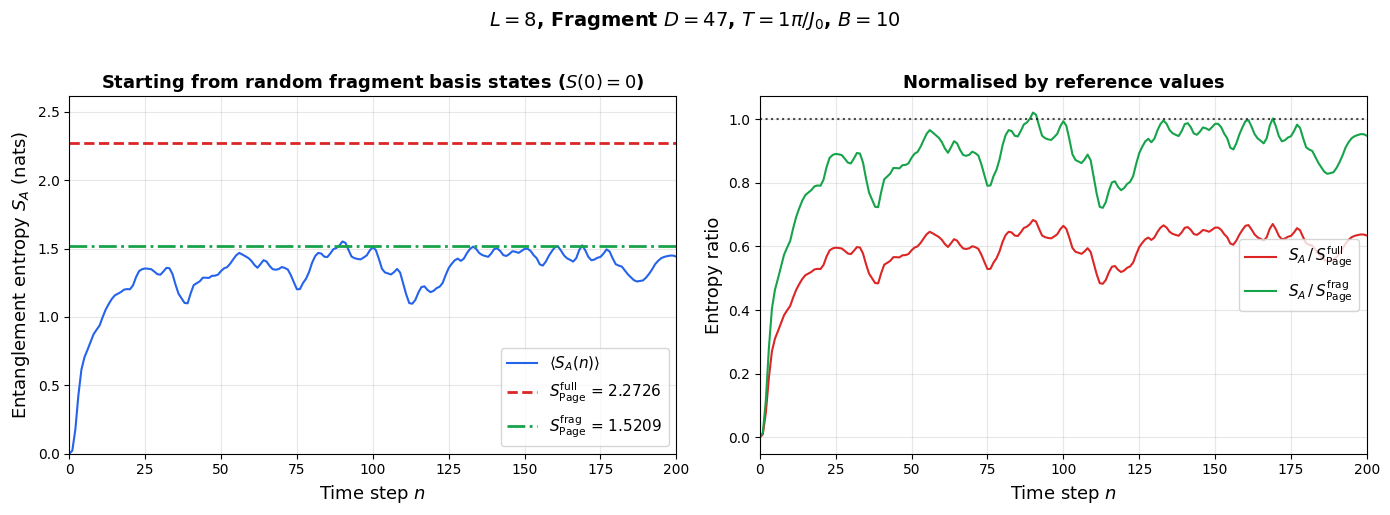


FINAL SUMMARY

  System: L = 8
  J₀ = 10.0, h₀ = 20.0, g = 1.0
  Initial states: 10 random basis states from fragment
  Fragment size: D = 47

  Reference values:
    S_Page (full, Ns=256):  2.272589 nats
    S_Page (frag, D=47): 1.520881 nats

  Entropy evolution:
    S(n=0)   = 0.000000 nats (should be ~0)
    S(n=200)  = 1.441354 nats

  Final ratios:
    S / S_Page^full = 0.6342
    S / S_Page^frag = 0.9477


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ============================================================
# PART 11B: PLOTTING — FRAGMENT ENTANGLEMENT DYNAMICS
# ============================================================
#
# Consumes from Part 10: S_page_full, S_page_frag, S_sem_frag
# Consumes from Part 11A: steps_frag, S_avg_frag
# Also reads: D_largest, L_frag, n_random_states, n_periods_frag,
#             largest_fragment, J0_frag_sim, h0_frag_sim,
#             g_frag_sim, n_period_frag
# ============================================================


def plot_fragment_basis_evolution(steps, S_avg, S_page_full, S_page_frag,
                                  D_frag, L, n_states=None,
                                  J0=None, h0=None, g=None, n_period=None):
    """
    Plot entanglement dynamics from random fragment basis states.

    Parameters
    ----------
    steps : ndarray
        Floquet step indices.
    S_avg : ndarray
        Averaged entanglement entropy at each step.
    S_page_full : float
        Page value for full Hilbert space.
    S_page_frag : float
        Page value for fragment subspace (MC).
    D_frag : int
        Fragment dimension.
    L : int
        System size.
    n_states : int, optional
        Number of initial states averaged.
    J0, h0, g : float, optional
        Hamiltonian parameters for annotation.
    n_period : int, optional
        Integer n in T = n·π/J₀.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Entropy vs time step ----
    ax1.plot(steps, S_avg, '-', lw=1.5, color='#2563eb',
             label=r'$\langle S_A(n) \rangle$')
    ax1.axhline(S_page_full, color='#dc2626', ls='--', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{full}}}}$ = {S_page_full:.4f}')
    ax1.axhline(S_page_frag, color='#16a34a', ls='-.', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag}}}}$ = {S_page_frag:.4f}')

    ax1.set_xlabel('Time step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Starting from random fragment basis states ($S(0)=0$)',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.set_ylim(0, S_page_full * 1.15)

    # ---- Right: Ratio to Page values ----
    ax2.plot(steps, S_avg / S_page_full, '-', lw=1.5, color='#dc2626',
             label=r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{full}}$')
    ax2.plot(steps, S_avg / S_page_frag, '-', lw=1.5, color='#16a34a',
             label=r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$')
    ax2.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7)

    ax2.set_xlabel('Time step $n$', fontsize=13)
    ax2.set_ylabel('Entropy ratio', fontsize=13)
    ax2.set_title('Normalised by reference values', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11, loc='right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(steps[0], steps[-1])

    # ---- Suptitle ----
    parts = [f'$L = {L}$', f'Fragment $D = {D_frag}$']
    if n_period is not None and J0 is not None:
        parts.append(f'$T = {n_period}\\pi/J_0$')
    if n_states is not None:
        parts.append(f'$B = {n_states}$')
    fig.suptitle(', '.join(parts), fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ---- Text summary ----
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    print(f"\n  System: L = {L}")
    if J0 is not None:
        print(f"  J₀ = {J0}, h₀ = {h0}, g = {g}")
    if n_states is not None:
        print(f"  Initial states: {n_states} random basis states from fragment")
    print(f"  Fragment size: D = {D_frag}")

    print(f"\n  Reference values:")
    Ns_disp = 2**L
    print(f"    S_Page (full, Ns={Ns_disp}):  {S_page_full:.6f} nats")
    print(f"    S_Page (frag, D={D_frag}): {S_page_frag:.6f} nats")

    print(f"\n  Entropy evolution:")
    print(f"    S(n=0)   = {S_avg[0]:.6f} nats (should be ~0)")
    print(f"    S(n={len(steps)-1})  = {S_avg[-1]:.6f} nats")

    print(f"\n  Final ratios:")
    print(f"    S / S_Page^full = {S_avg[-1] / S_page_full:.4f}")
    print(f"    S / S_Page^frag = {S_avg[-1] / S_page_frag:.4f}")
    print("=" * 60)


# ============================================================
# EXECUTE PLOT (uses variables from Parts 10 + 11A)
# ============================================================

print("=" * 60)
print("PLOTTING FRAGMENT DYNAMICS")
print("=" * 60)

plot_fragment_basis_evolution(
    steps_frag, S_avg_frag,
    S_page_full, S_page_frag,
    D_largest, L_frag,
    n_states=n_random_states,
    J0=J0_frag_sim, h0=h0_frag_sim, g=g_frag_sim,
    n_period=n_period_frag
)

## EE vs $J_0$

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 12: COMPARISON OF ENTANGLEMENT DYNAMICS FOR DIFFERENT J₀
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator
#   Part 9      : build_connectivity_graph, find_connected_components,
#                 find_largest_fragment
#   Part 10     : compute_fragment_page_value_MC
#   Fragment dynamics : build_fragment_states_batched,
#                       compute_entanglement_dynamics_fragment_basis
#
# Produces: results_list (list of dicts, one per J₀)
# ============================================================


def run_fragment_analysis_for_J0(L, J_0, g, n_periods, n_initial_states,
                                  n_MC_samples=500, seed=42, verbose=False):
    """
    Run complete fragment analysis for a given J₀ value.

    Builds the Floquet system, identifies fragments, computes
    fragment Page value via MC, and evolves entanglement dynamics
    from random basis states in the largest fragment.

    All evolution uses batched Krylov — no dense U_F is formed.

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling strength.
    g : float
        Transverse field (perturbation).
    n_periods : int
        Number of Floquet periods.
    n_initial_states : int
        Number of initial states to average (B).
    n_MC_samples : int
        Monte Carlo samples for fragment Page value.
    seed : int
        RNG seed for reproducibility (MC + initial states).
    verbose : bool
        Print detailed output.

    Returns
    -------
    results : dict
        Dictionary with keys: J_0, h_0, T, steps, S_avg,
        S_page_full, S_page_frag, D_largest, wall_time.
    """
    h_0 = 2.0 * J_0
    T = np.pi / J_0   # fragmentation condition

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"J₀ = {J_0}, h₀ = {h_0}, T = π/{J_0}")
        print(f"{'=' * 60}")

    t0 = time.perf_counter()

    # --- Step 1: Fragment identification ---
    O_diag_local = build_O_operator(L, J_0)
    adjacency_local, num_edges = build_connectivity_graph(L, O_diag_local, tol=1e-10)
    components_local = find_connected_components(adjacency_local)
    largest_frag = find_largest_fragment(components_local)
    D = len(largest_frag)

    if verbose:
        print(f"  Fragments: {len(components_local)}, largest D = {D}")

    # --- Step 2: Build Floquet system (sparse, no dense U_F) ---
    ising_local = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=T, hbar=1.0)
    ising_local.build_hamiltonians()

    # --- Step 3: Page values ---
    S_page_full = compute_page_value(L)
    S_page_frag, _, _ = compute_fragment_page_value_MC(
        largest_frag, L, n_samples=n_MC_samples,
        seed=seed, verbose=False
    )

    if verbose:
        print(f"  S_Page (full): {S_page_full:.4f}")
        print(f"  S_Page (frag): {S_page_frag:.4f}")

    # --- Step 4: Batched Krylov evolution ---
    steps, S_avg = compute_entanglement_dynamics_fragment_basis(
        ising_local, largest_frag, n_periods,
        n_initial_states=n_initial_states,
        seed=seed, verbose=False, renorm_interval=100
    )

    wall = time.perf_counter() - t0

    if verbose:
        print(f"  Final entropy: S = {S_avg[-1]:.4f}")
        print(f"  S / S_Page^full = {S_avg[-1] / S_page_full:.4f}")
        print(f"  S / S_Page^frag = {S_avg[-1] / S_page_frag:.4f}")
        print(f"  Wall time: {wall:.1f} s")

    return {
        'J_0': J_0,
        'h_0': h_0,
        'T': T,
        'steps': steps,
        'S_avg': S_avg,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
        'D_largest': D,
        'wall_time': wall,
    }


# ============================================================
#  CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_compare              = 12
g_compare              = 1.0
n_periods_compare      = 200
n_initial_states_compare = 32
n_MC_compare           = 500       # MC samples per J₀ for fragment Page
seed_compare           = 42

J_0_values = [1, 3, 4, 10, 20]

# ============================================================
# EXECUTE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("PART 12: Comparing Entanglement Dynamics for Different J₀ Values")
print("=" * 70)

print(f"\n  L = {L_compare}")
print(f"  g = {g_compare}")
print(f"  h₀ = 2·J₀")
print(f"  T  = π/J₀ (fragmentation condition)")
print(f"  Floquet periods: {n_periods_compare}")
print(f"  Initial states:  {n_initial_states_compare}")
print(f"  MC samples:      {n_MC_compare}")
print(f"  seed:            {seed_compare}")
print(f"  J₀ values:       {J_0_values}")

results_list = []
t0_total = time.perf_counter()

for J_0 in J_0_values:
    print(f"\n--- Processing J₀ = {J_0} ---")
    result = run_fragment_analysis_for_J0(
        L=L_compare, J_0=J_0, g=g_compare,
        n_periods=n_periods_compare,
        n_initial_states=n_initial_states_compare,
        n_MC_samples=n_MC_compare,
        seed=seed_compare,
        verbose=True
    )
    results_list.append(result)

t_total = time.perf_counter() - t0_total

# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "=" * 90)
print("COMPARISON SUMMARY")
print("=" * 90)
print(f"{'J₀':<8} {'h₀':<8} {'T':<12} {'D':<8} "
      f"{'S_final':<10} {'S/S_Page':<10} {'S/S_frag':<10} {'Time(s)':<8}")
print("-" * 90)

for r in results_list:
    print(f"{r['J_0']:<8.1f} {r['h_0']:<8.1f} {r['T']:<12.6f} {r['D_largest']:<8} "
          f"{r['S_avg'][-1]:<10.4f} {r['S_avg'][-1]/r['S_page_full']:<10.4f} "
          f"{r['S_avg'][-1]/r['S_page_frag']:<10.4f} {r['wall_time']:<8.1f}")

print("=" * 90)
print(f"Total wall time: {t_total:.1f} s")
print("\nData available: results_list")
print("Run the plotting cell (Part 12B) to visualise.")


PART 12: Comparing Entanglement Dynamics for Different J₀ Values

  L = 12
  g = 1.0
  h₀ = 2·J₀
  T  = π/J₀ (fragmentation condition)
  Floquet periods: 200
  Initial states:  32
  MC samples:      500
  seed:            42
  J₀ values:       [1, 3, 4, 10, 20]

--- Processing J₀ = 1 ---

J₀ = 1, h₀ = 2.0, T = π/1
  Fragments: 853, largest D = 322
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 1
  h_0 = 2.0
  g = 1.0
  Period T = 3.141593
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 75.40, ||A-||_1 = 75.40
  Krylov sub-steps: K+ = 16, K- = 16
  Hermiticity check (H+): max err = 1.49e-12
  Hermiticity check (H-): max err = 1.95e-12
  S_Page (full): 3.6589
  S_Page (frag): 2.4717
  Diagonal cross-check vs CSR: max|Δ| = 0.00e+00

### Plotting code


Plotting comparison...


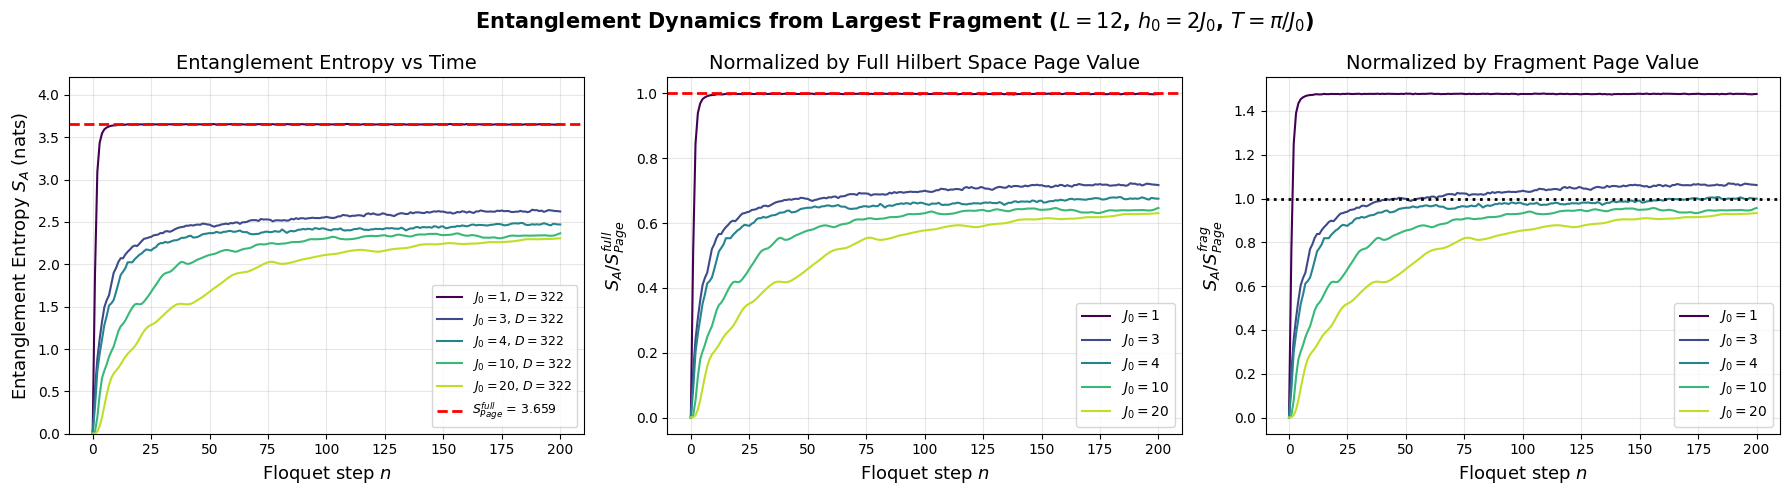


SUMMARY TABLE
J_0      h_0      T            D_frag     S_page^frag  S_final      S/S_Page^full  S/S_Page^frag 
--------------------------------------------------------------------------------
1        2.0      3.141593     322        2.4717       3.6523       0.9982         1.4776        
3        6.0      1.047198     322        2.4717       2.6240       0.7172         1.0616        
4        8.0      0.785398     322        2.4717       2.4704       0.6752         0.9995        
10       20.0     0.314159     322        2.4717       2.3659       0.6466         0.9572        
20       40.0     0.157080     322        2.4717       2.3076       0.6307         0.9336        

✓ Comparison complete!


In [ ]:
def plot_comparison_J0_values(results_list, L):
    """
    Plot entanglement dynamics for different J_0 values.

    Parameters:
    -----------
    results_list : list of dict
        Results from run_fragment_analysis_for_J0 for each J_0
    L : int
        Chain length
    """
    # Color map for different J_0 values
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(results_list)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Get the full Page value (same for all J_0)
    S_page_full = results_list[0]['S_page_full']

    # ========== Left plot: Entropy S(n) ==========
    ax1 = axes[0]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$, $D = {res['D_largest']}$"
        ax1.plot(res['steps'], res['S_avg'], color=colors[i], linewidth=1.5, label=label)

    ax1.axhline(S_page_full, color='red', linestyle='--', linewidth=2,
                label=f'$S_{{Page}}^{{full}}$ = {S_page_full:.3f}')

    ax1.set_xlabel('Floquet step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement Entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Entanglement Entropy vs Time', fontsize=14)
    ax1.legend(fontsize=9, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, S_page_full * 1.15)

    # ========== Middle plot: Ratio to full Page value ==========
    ax2 = axes[1]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$"
        ax2.plot(res['steps'], res['S_avg'] / S_page_full, color=colors[i],
                 linewidth=1.5, label=label)

    ax2.axhline(1.0, color='red', linestyle='--', linewidth=2)

    ax2.set_xlabel('Floquet step $n$', fontsize=13)
    ax2.set_ylabel(r'$S_A / S_{Page}^{full}$', fontsize=13)
    ax2.set_title('Normalized by Full Hilbert Space Page Value', fontsize=14)
    ax2.legend(fontsize=10, loc='lower right')
    ax2.grid(True, alpha=0.3)

    # ========== Right plot: Ratio to fragment Page value ==========
    ax3 = axes[2]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$"
        ax3.plot(res['steps'], res['S_avg'] / res['S_page_frag'], color=colors[i],
                 linewidth=1.5, label=label)

    ax3.axhline(1.0, color='black', linestyle=':', linewidth=2)

    ax3.set_xlabel('Floquet step $n$', fontsize=13)
    ax3.set_ylabel(r'$S_A / S_{Page}^{frag}$', fontsize=13)
    ax3.set_title('Normalized by Fragment Page Value', fontsize=14)
    ax3.legend(fontsize=10, loc='lower right')
    ax3.grid(True, alpha=0.3)

    fig.suptitle(f'Entanglement Dynamics from Largest Fragment ($L = {L}$, $h_0 = 2J_0$, $T = \\pi/J_0$)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    print(f"{'J_0':<8} {'h_0':<8} {'T':<12} {'D_frag':<10} {'S_page^frag':<12} {'S_final':<12} {'S/S_Page^full':<14} {'S/S_Page^frag':<14}")
    print("-"*80)
    for res in results_list:
        print(f"{res['J_0']:<8} {res['h_0']:<8} {res['T']:<12.6f} {res['D_largest']:<10} "
              f"{res['S_page_frag']:<12.4f} {res['S_avg'][-1]:<12.4f} "
              f"{res['S_avg'][-1]/S_page_full:<14.4f} {res['S_avg'][-1]/res['S_page_frag']:<14.4f}")
    print("="*80)



# Plot comparison
print("\n" + "="*70)
print("Plotting comparison...")
print("="*70)

plot_comparison_J0_values(results_list, L_compare)

print("\n✓ Comparison complete!")

## EE vs fragments

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 12: ENTANGLEMENT DYNAMICS FOR LARGEST DISTINCT-D FRAGMENTS
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator
#   Part 9      : build_connectivity_graph, find_connected_components
#   Fragment dynamics : build_fragment_states_batched
#
# Produces: fragment_results (list of dicts, one per fragment)
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_p12           = 12
J_0_p12         = 10.0
h_0_p12         = 2.0 * J_0_p12    # = 20
g_p12           = 1.0
n_period_p12    = 1                 # T = n·π/J₀
n_periods_p12   = 200               # Floquet periods
n_samples_p12   = 32               # initial states per fragment
n_top_frags     = 4                 # how many distinct-D fragments
seed_p12        = 42
renorm_p12      = 100

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_p12  = n_period_p12 * np.pi / J_0_p12
Ns_p12 = 2**L_p12

print("=" * 70)
print(f"PART 12: Entanglement Dynamics for {n_top_frags} Largest Distinct-D Fragments")
print("=" * 70)

print(f"\n  System:")
print(f"    L  = {L_p12}  (Ns = {Ns_p12})")
print(f"    J₀ = {J_0_p12},  h₀ = {h_0_p12},  g = {g_p12}")
print(f"    T  = {n_period_p12}·π/J₀ = {T_p12:.6f}")

print(f"\n  Simulation:")
print(f"    n_periods = {n_periods_p12}")
print(f"    B = {n_samples_p12} initial states per fragment")
print(f"    seed = {seed_p12}")

# ============================================================
# BUILD FLOQUET SYSTEM (sparse, no dense U_F)
# ============================================================

print("\n" + "-" * 70)
print("Building Floquet system...")
print("-" * 70)

t0_build = time.perf_counter()

ising_p12 = FloquetIsingChain(
    L=L_p12, J_0=J_0_p12, h_0=h_0_p12, g=g_p12,
    TP=T_p12, hbar=1.0
)
ising_p12.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# ============================================================
# FRAGMENT IDENTIFICATION
# ============================================================

print("\n" + "-" * 70)
print("Identifying fragments...")
print("-" * 70)

O_diag_p12 = build_O_operator(L_p12, J_0_p12)
adjacency_p12, num_edges_p12 = build_connectivity_graph(L_p12, O_diag_p12)
components_p12 = find_connected_components(adjacency_p12)

components_sorted = sorted(components_p12, key=len, reverse=True)

# --- Select fragments with DISTINCT dimensions ---
# Walk the size-sorted list; skip any fragment whose D already appeared.
top_fragments = []
seen_D = set()
for frag in components_sorted:
    D = len(frag)
    if D not in seen_D:
        top_fragments.append(frag)
        seen_D.add(D)
    if len(top_fragments) == n_top_frags:
        break

print(f"  Total fragments: {len(components_p12)}")
print(f"  Unique fragment dimensions: "
      f"{sorted(set(len(c) for c in components_p12), reverse=True)}")
print(f"\n  Selected {len(top_fragments)} fragments with distinct D:")
for i, frag in enumerate(top_fragments):
    print(f"    Fragment {i+1}: D = {len(frag)} states")

# ============================================================
# PAGE VALUES
# ============================================================

A_indices_p12 = list(range(L_p12 // 2))
S_page_full_p12 = compute_page_value(L_p12)
print(f"\n  S_Page (full, Ns={Ns_p12}): {S_page_full_p12:.6f} nats")

# ============================================================
# EVOLUTION — BATCHED KRYLOV PER FRAGMENT
# ============================================================

print("\n" + "-" * 70)
print("Running entanglement dynamics per fragment...")
print("-" * 70)

fragment_results = []
t0_total = time.perf_counter()

for i, fragment in enumerate(top_fragments):
    D_frag = len(fragment)
    print(f"\n--- Fragment {i+1} (D = {D_frag}) ---")

    t0_frag = time.perf_counter()

    # Build batched initial states (all B at once)
    rng_frag = np.random.default_rng(seed_p12 + i)
    Psi, chosen = build_fragment_states_batched(
        fragment, L_p12, n_samples_p12, rng_frag
    )

    steps = np.arange(n_periods_p12 + 1)
    S_all = np.zeros((n_samples_p12, n_periods_p12 + 1))

    # Step 0: entropy of initial states (should be 0)
    for k in range(n_samples_p12):
        S_all[k, 0] = bipartite_entropy(Psi[:, k], L_p12, A_indices_p12)

    # Evolution loop
    for n in range(1, n_periods_p12 + 1):
        # Batched Krylov step
        Psi = apply_floquet_step(ising_p12, Psi)

        # Periodic renormalisation
        if renorm_p12 > 0 and n % renorm_p12 == 0:
            norms = np.linalg.norm(Psi, axis=0)
            Psi /= norms[np.newaxis, :]

        # Per-sample entropy
        for k in range(n_samples_p12):
            S_all[k, n] = bipartite_entropy(Psi[:, k], L_p12, A_indices_p12)

        # Progress
        if n % max(1, n_periods_p12 // 5) == 0:
            elapsed = time.perf_counter() - t0_frag
            rate = n / elapsed
            eta = (n_periods_p12 - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_periods_p12}: "
                  f"<S> = {np.mean(S_all[:, n]):.4f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    S_avg = np.mean(S_all, axis=0)
    S_std = np.std(S_all, axis=0, ddof=1)
    t_frag = time.perf_counter() - t0_frag

    fragment_results.append({
        'fragment_id': i + 1,
        'D': D_frag,
        'steps': steps,
        'S_avg': S_avg,
        'S_std': S_std,
        'S_all': S_all,
        'wall_time': t_frag,
    })

    print(f"  S(0) = {S_avg[0]:.2e}, S({n_periods_p12}) = {S_avg[-1]:.4f} "
          f"± {S_std[-1]:.4f}")
    print(f"  S / S_Page^full = {S_avg[-1] / S_page_full_p12:.4f}")
    print(f"  Wall time: {t_frag:.1f} s")

t_total = time.perf_counter() - t0_total

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"{'Frag':<6} {'D':<8} {'S_final':<10} {'± std':<10} "
      f"{'S/S_Page':<10} {'Time(s)':<8}")
print("-" * 70)

for r in fragment_results:
    print(f"{r['fragment_id']:<6} {r['D']:<8} {r['S_avg'][-1]:<10.4f} "
          f"{r['S_std'][-1]:<10.4f} "
          f"{r['S_avg'][-1] / S_page_full_p12:<10.4f} {r['wall_time']:<8.1f}")

print("=" * 70)
print(f"Total wall time: {t_total:.1f} s")
print(f"\nData available: fragment_results, S_page_full_p12")
print("Run Part 12B plotting cell to visualise.")

PART 12: Entanglement Dynamics for 4 Largest Distinct-D Fragments

  System:
    L  = 12  (Ns = 4096)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Simulation:
    n_periods = 200
    B = 32 initial states per fragment
    seed = 42

----------------------------------------------------------------------
Building Floquet system...
----------------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 58.43, ||A-||_1 = 58.43
  Krylov sub-steps: K+ = 12, K- = 12
  Hermiticity check (H+): max err = 2.28e-11
  Hermiticity check (H-): max err = 1.50e-11
  Build time: 0.017 

### Plotting code

PART 12B: Computing fragment Page values + plotting

Computing S_Page^frag via Monte Carlo (5000 samples)...
  Fragment 1 (D= 322): S_Page^frag = 2.470260 ± 0.000391 nats
  Fragment 2 (D=  55): S_Page^frag = 1.392477 ± 0.000770 nats
  Fragment 3 (D=  34): S_Page^frag = 0.971694 ± 0.000824 nats
  Fragment 4 (D=  21): S_Page^frag = 0.604761 ± 0.000906 nats



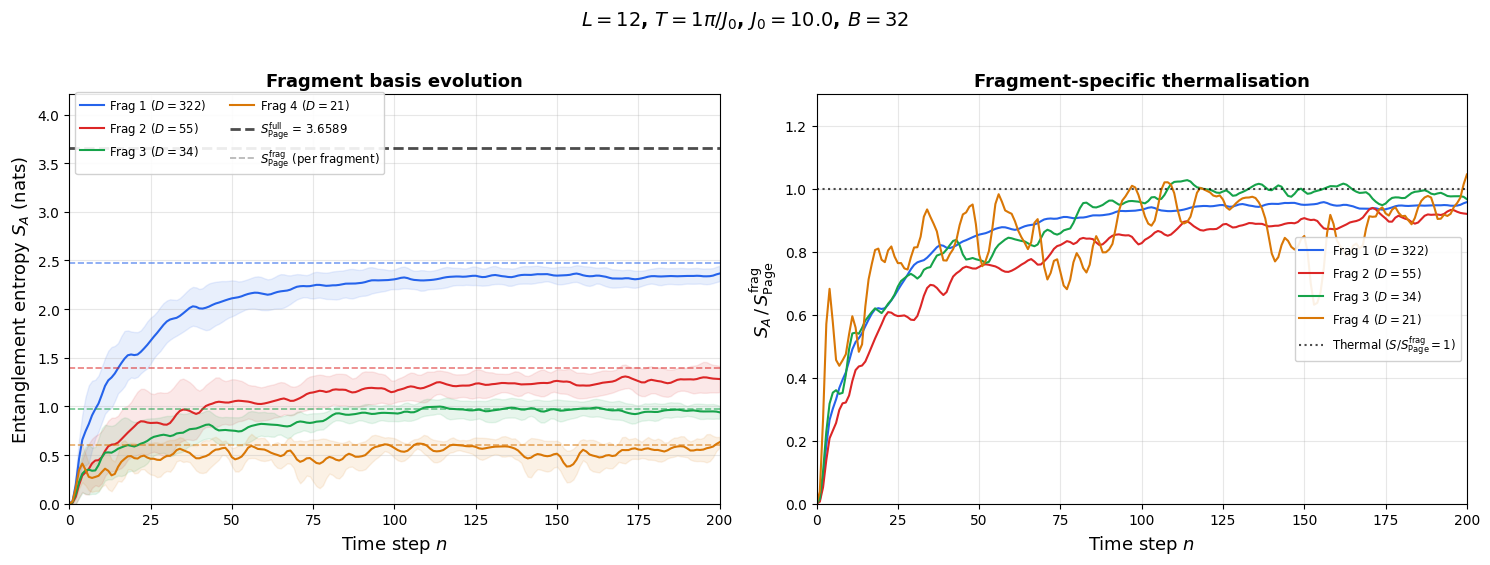

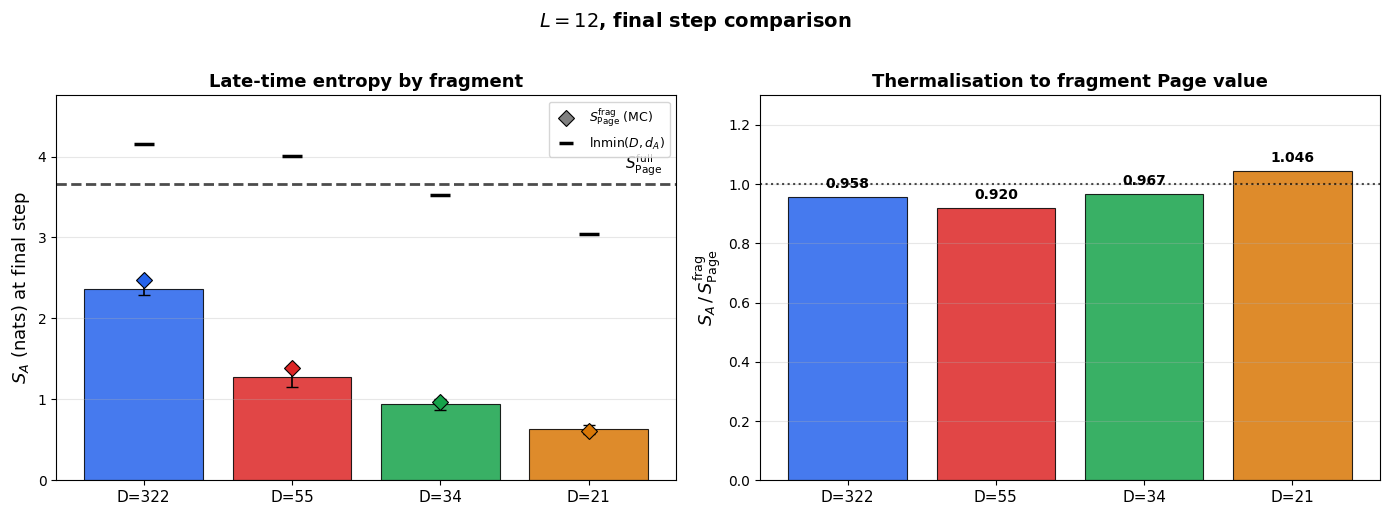


PART 12B — SUMMARY

  System: L = 12, Ns = 4096
  J₀ = 10.0, h₀ = 20.0, g = 1.0
  T = 1·π/J₀ = 0.314159
  B = 32 initial states per fragment

  S_Page^full = 3.658883 nats

  Frag   D        S_final      ± σ          S_Page^f     S/S_Pf     S/S_PF     ln min    
  --------------------------------------------------------------------------------
  1      322      2.365856     0.079306     2.470260     0.9577     0.6466     4.158883  
  2      55       1.281641     0.134418     1.392477     0.9204     0.3503     4.007333  
  3      34       0.939716     0.066454     0.971694     0.9671     0.2568     3.526361  
  4      21       0.632305     0.055044     0.604761     1.0455     0.1728     3.044522  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ============================================================
# PART 12B: PLOTTING — MULTI-FRAGMENT ENTANGLEMENT DYNAMICS
#           (with fragment-specific Page value thermalisation)
# ============================================================
#
# Consumes from Part 12:
#   fragment_results : list of dicts (fragment_id, D, steps,
#                      S_avg, S_std, S_all, wall_time)
#   top_fragments    : list of lists (basis state indices)
#   S_page_full_p12  : float (full Hilbert space Page value)
#   L_p12, J_0_p12, h_0_p12, g_p12, n_period_p12, n_samples_p12
#
# Consumes from Part 10:
#   compute_fragment_page_value_MC  (function)
# ============================================================

# Colour palette — distinct, colourblind-friendly
FRAG_COLORS = ['#2563eb', '#dc2626', '#16a34a', '#d97706', '#7c3aed']
FRAG_MARKERS = ['o', 's', '^', 'D', 'v']


def plot_multi_fragment_dynamics(fragment_results, S_page_full, L,
                                 J0=None, h0=None, g=None, n_period=None,
                                 n_states=None):
    """
    Plot entanglement dynamics for multiple Hilbert space fragments,
    showing thermalisation against both S_Page^full and S_Page^frag.

    Figure 1 — Two panels:
      Left : S_A(n) vs n with per-fragment S_Page^frag dashed lines
      Right: S_A / S_Page^frag ratio (fragment-specific thermalisation)

    Figure 2 — Two panels:
      Left : Bar chart of late-time S_A with S_Page^frag diamonds
      Right: Bar chart of S / S_Page^frag ratio
    """
    n_frags = len(fragment_results)
    colors = FRAG_COLORS[:n_frags]
    markers = FRAG_MARKERS[:n_frags]
    d_A = 2**(L // 2)

    # ================================================================
    # FIGURE 1: Time-evolution panels
    # ================================================================
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

    # First pass: plot data without legend
    legend_elements = []
    for i, r in enumerate(fragment_results):
        S_pf = r['S_page_frag']
        label = f'Frag {r["fragment_id"]} ($D = {r["D"]}$)'

        # ---- Left: Entropy S(n) ----
        line1 = ax1.plot(r['steps'], r['S_avg'], '-', lw=1.5, color=colors[i],
                         label=label)[0]  # Get the line object
        ax1.fill_between(r['steps'],
                         r['S_avg'] - r['S_std'],
                         r['S_avg'] + r['S_std'],
                         color=colors[i], alpha=0.10)
        # Per-fragment Page value (coloured dashed)
        if S_pf > 1e-10:
            ax1.axhline(S_pf, color=colors[i], ls='--', lw=1.2, alpha=0.6)

        # ---- Right: Ratio to fragment Page ----
        if S_pf > 1e-10:
            ax2.plot(r['steps'], r['S_avg'] / S_pf, '-', lw=1.5,
                     color=colors[i], label=label)

        # Store legend element for fragment line
        legend_elements.append(line1)

    # Full-space Page reference + legend entry for fragment dashes
    full_page_line = ax1.axhline(
        S_page_full, color='black', ls='--', lw=2, alpha=0.7,
        label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}}$ = {S_page_full:.4f}')
    frag_dash_line = ax1.plot(
        [], [], '--', color='gray', lw=1.2, alpha=0.6,
        label=r'$S_{\mathrm{Page}}^{\mathrm{frag}}$ (per fragment)')[0]
    legend_elements.extend([full_page_line, frag_dash_line])

    ax1.set_xlabel('Time step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Fragment basis evolution', fontsize=13, fontweight='bold')
    # Legend: pass (handles, labels) as TWO arguments
    leg_labels = [h.get_label() for h in legend_elements]
    ax1.legend(legend_elements, leg_labels, fontsize=8.5, loc='upper left',
               ncol=2, framealpha=0.9, bbox_to_anchor=(0, 1.02),
               handlelength=2, handletextpad=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, fragment_results[0]['steps'][-1])
    ax1.set_ylim(0, S_page_full * 1.15)

    # Right: ratio to fragment Page
    ax2.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7,
                label=r'Thermal ($S/S_{\mathrm{Page}}^{\mathrm{frag}} = 1$)')
    ax2.set_xlabel('Time step $n$', fontsize=13)
    ax2.set_ylabel(
        r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$', fontsize=13)
    ax2.set_title('Fragment-specific thermalisation', fontsize=13,
                  fontweight='bold')
    ax2.legend(fontsize=8.5, loc='right', ncol=1, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, fragment_results[0]['steps'][-1])
    ax2.set_ylim(0, 1.3)

    # Suptitle
    parts = [f'$L = {L}$']
    if n_period is not None and J0 is not None:
        parts.append(rf'$T = {n_period}\pi/J_0$')
    if J0 is not None:
        parts.append(f'$J_0 = {J0}$')
    if n_states is not None:
        parts.append(f'$B = {n_states}$')
    fig1.suptitle(', '.join(parts), fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()
    # ================================================================
    # FIGURE 2: Bar chart — final entropy vs fragment dimension
    # ================================================================
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

    D_vals = [r['D'] for r in fragment_results]
    S_final = [r['S_avg'][-1] for r in fragment_results]
    S_final_std = [r['S_std'][-1] for r in fragment_results]
    S_pf_vals = [r['S_page_frag'] for r in fragment_results]
    S_ratio_frag = [s / spf if spf > 1e-10 else 0.0
                    for s, spf in zip(S_final, S_pf_vals)]

    x_pos = np.arange(n_frags)
    bar_labels = [f'D={d}' for d in D_vals]

    # Left: absolute entropy bars
    bars1 = ax3.bar(x_pos, S_final, yerr=S_final_std,
                    color=colors, alpha=0.85, edgecolor='black', lw=0.8,
                    capsize=4, error_kw={'lw': 1.2})
    ax3.axhline(S_page_full, color='black', ls='--', lw=2, alpha=0.7)
    ax3.text(n_frags - 0.5, S_page_full * 1.02,
             rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}}$',
             fontsize=11, ha='right', va='bottom')

    # Per-fragment S_Page^frag (diamond markers)
    for i, spf in enumerate(S_pf_vals):
        if spf > 1e-10:
            ax3.plot(i, spf, 'D', ms=8, color=colors[i],
                     markeredgecolor='black', markeredgewidth=0.8, zorder=5)
    ax3.plot([], [], 'D', ms=8, color='gray', markeredgecolor='black',
             markeredgewidth=0.8,
             label=r'$S_{\mathrm{Page}}^{\mathrm{frag}}$ (MC)')

    # ln(min(D, d_A)) upper bounds
    Ns = 2**L
    for i, d in enumerate(D_vals):
        S_max_frag = np.log(min(d, d_A))
        ax3.plot(i, S_max_frag, 'k_', ms=14, mew=2.5)

    ax3.plot([], [], 'k_', ms=10, mew=2.5, label=r'$\ln\!\min(D, d_A)$')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(bar_labels, fontsize=11)
    ax3.set_ylabel('$S_A$ (nats) at final step', fontsize=13)
    ax3.set_title('Late-time entropy by fragment', fontsize=13,
                  fontweight='bold')
    ax3.legend(fontsize=9, loc='upper right')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim(0, S_page_full * 1.3)

    # Right: thermalisation ratio to fragment Page
    bars2 = ax4.bar(x_pos, S_ratio_frag, color=colors, alpha=0.85,
                    edgecolor='black', lw=0.8)
    ax4.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(bar_labels, fontsize=11)
    ax4.set_ylabel(
        r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$', fontsize=13)
    ax4.set_title('Thermalisation to fragment Page value', fontsize=13,
                  fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 1.3)

    # Annotate ratios on bars
    for j, (bar, ratio) in enumerate(zip(bars2, S_ratio_frag)):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{ratio:.3f}', ha='center', va='bottom', fontsize=10,
                 fontweight='bold')

    fig2.suptitle(f'$L = {L}$, final step comparison', fontsize=14,
                  fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ================================================================
    # TEXT SUMMARY
    # ================================================================
    print("\n" + "=" * 70)
    print("PART 12B — SUMMARY")
    print("=" * 70)
    print(f"\n  System: L = {L}, Ns = {2**L}")
    if J0 is not None:
        print(f"  J₀ = {J0}, h₀ = {h0}, g = {g}")
    if n_period is not None and J0 is not None:
        T_val = n_period * np.pi / J0
        print(f"  T = {n_period}·π/J₀ = {T_val:.6f}")
    if n_states is not None:
        print(f"  B = {n_states} initial states per fragment")

    print(f"\n  S_Page^full = {S_page_full:.6f} nats")

    print(f"\n  {'Frag':<6} {'D':<8} {'S_final':<12} {'± σ':<12} "
          f"{'S_Page^f':<12} {'S/S_Pf':<10} {'S/S_PF':<10} "
          f"{'ln min':<10}")
    print("  " + "-" * 80)
    for r in fragment_results:
        S_bound = np.log(min(r['D'], d_A))
        S_f = r['S_avg'][-1]
        S_pf = r['S_page_frag']
        r_frag = S_f / S_pf if S_pf > 1e-10 else float('nan')
        r_full = S_f / S_page_full
        print(f"  {r['fragment_id']:<6} {r['D']:<8} "
              f"{S_f:<12.6f} {r['S_std'][-1]:<12.6f} "
              f"{S_pf:<12.6f} {r_frag:<10.4f} {r_full:<10.4f} "
              f"{S_bound:<10.6f}")
    print("=" * 70)


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_MC_page_12b   = 5000     # MC samples for fragment Page value
seed_MC_12b     = 1042     # RNG seed for MC Page values

# ============================================================
# COMPUTE S_PAGE^FRAG PER FRAGMENT, THEN PLOT
# ============================================================

print("=" * 70)
print("PART 12B: Computing fragment Page values + plotting")
print("=" * 70)

print(f"\nComputing S_Page^frag via Monte Carlo ({n_MC_page_12b} samples)...")

for i, r in enumerate(fragment_results):
    S_pf, _, S_pf_sem = compute_fragment_page_value_MC(
        top_fragments[i], L_p12,
        n_samples=n_MC_page_12b,
        A_indices=list(range(L_p12 // 2)),
        seed=seed_MC_12b + i,
        verbose=False
    )
    r['S_page_frag'] = S_pf
    r['S_page_frag_sem'] = S_pf_sem
    print(f"  Fragment {r['fragment_id']} (D={r['D']:>4}): "
          f"S_Page^frag = {S_pf:.6f} ± {S_pf_sem:.6f} nats")

print()
plot_multi_fragment_dynamics(
    fragment_results, S_page_full_p12, L_p12,
    J0=J_0_p12, h0=h_0_p12, g=g_p12, n_period=n_period_p12,
    n_states=n_samples_p12
)

# Largest fragment analysis

## Level statistics

### Symmetry resolved



############################################################
# L = 10 TEST
############################################################


ANALYTIC PREDICTIONS  (L = 10, PBC)
  Luc(10) = 123, Δ = -1, N_A = 61, N_B = 62
  Fragment frac = 123/1024 = 0.120117

Enumerating PBC no-adjacent-up basis...
  ✓ Basis verified: D = 123 = Luc(10)
  ✓ Sublattices: N_A = 61, N_B = 62, Δ = -1

Building H_eff (D = 123)...
  nnz = 680, density = 0.0449

  H_eff verification (D = 123):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 1.33e-14  ✓
    Zero modes: 13 (≥ 1 required)  ✓


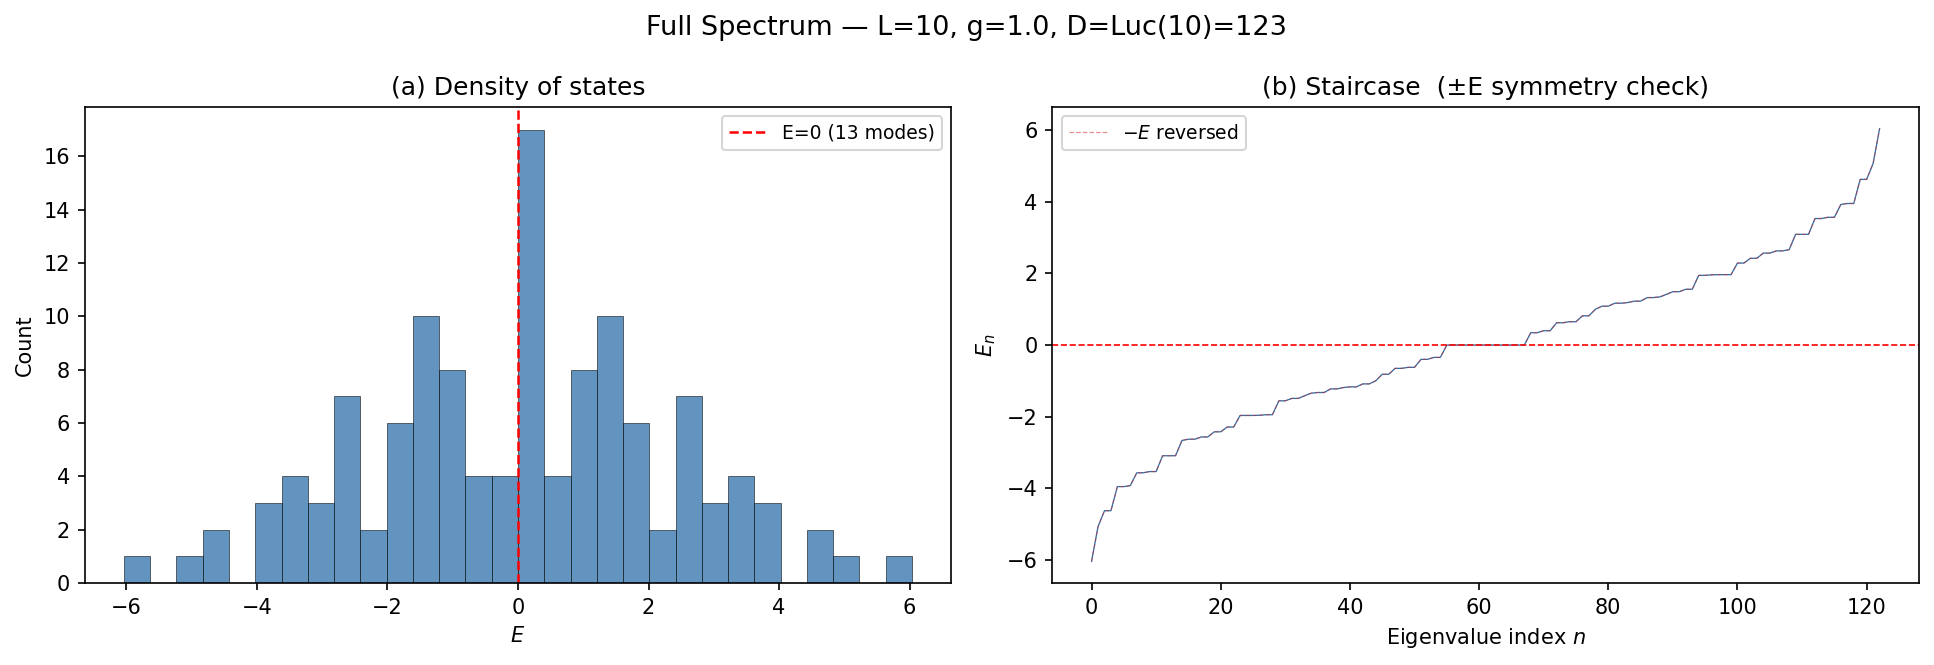

  [Saved: spectrum_1.png]

Computing translation orbits...
  Number of orbits: 15
  Orbit size distribution: {np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(5): np.int64(2), np.int64(10): np.int64(11)}

  k = 0 (2π·0/10), D_k = 15, herm_err = 0.00e+00, real_k = True
    R_k: unitary_err = 0.00e+00, herm_err = 0.00e+00
    k=0,R+: D = 14, ⟨r⟩ = nan (n_pos = 4)  [GOE ≈ 0.5307, Poisson ≈ 0.3863]
    k=0,R-: D = 1 (too small)

  k = 1 (2π·1/10), D_k = 11, herm_err = 1.24e-16, real_k = False
    k=±1: D = 11, ⟨r⟩ = nan (n_pos = 3)  [GUE ≈ 0.5996, Poisson ≈ 0.3863]

  k = 2 (2π·2/10), D_k = 13, herm_err = 4.44e-16, real_k = False
    k=±2: D = 13, ⟨r⟩ = nan (n_pos = 4)  [GUE ≈ 0.5996, Poisson ≈ 0.3863]

  k = 3 (2π·3/10), D_k = 11, herm_err = 2.48e-16, real_k = False
    k=±3: D = 11, ⟨r⟩ = nan (n_pos = 3)  [GUE ≈ 0.5996, Poisson ≈ 0.3863]

  k = 4 (2π·4/10), D_k = 13, herm_err = 4.48e-16, real_k = False
    k=±4: D = 13, ⟨r⟩ = nan (n_pos = 4)  [GUE ≈ 0.5996, Poisson ≈ 0.3863]


In [ ]:
"""
PBC Largest Fragment: Symmetry-Resolved Level Statistics
=========================================================

Prompt 1 code — self-contained for Google Colab.
Plots saved to PNG and displayed inline via IPython.display.

Physics:
  H_eff = -g Σ_i π_{i-1} σ^x_i π_{i+1}   (PBC, indices mod L)
  Largest fragment: no adjacent ↑ on ring, D = Luc(L).

Symmetries: Translation T, Reflection R, Chiral C.
Convention: site i ↔ bit position i (LSB = site 0).
"""

import numpy as np
from scipy import sparse
from scipy.sparse.linalg import eigsh
from collections import defaultdict
import time
import matplotlib
import matplotlib.pyplot as plt

# ============================================================
# PLOT DISPLAY HELPER — guaranteed to work on Colab
# ============================================================

_plot_counter = 0


def show_and_save(fig, prefix="plot"):
    """Save figure to PNG then display inline."""
    global _plot_counter
    _plot_counter += 1
    fname = f"{prefix}_{_plot_counter}.png"
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    from IPython.display import display, Image
    display(Image(filename=fname))
    print(f"  [Saved: {fname}]")

# ============================================================
# §1  ANALYTIC UTILITIES
# ============================================================

def fib(n):
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

def lucas(L):
    return fib(L - 1) + fib(L + 1)

def delta_L(L):
    table = {0: 2, 1: 1, 2: -1, 3: -2, 4: -1, 5: 1}
    return table[L % 6]

def analytic_check(L):
    D = lucas(L); dL = delta_L(L)
    NA = (D + dL) // 2; NB = (D - dL) // 2
    print(f"\n{'='*60}")
    print(f"ANALYTIC PREDICTIONS  (L = {L}, PBC)")
    print(f"{'='*60}")
    print(f"  Luc({L}) = {D}, Δ = {dL}, N_A = {NA}, N_B = {NB}")
    print(f"  Fragment frac = {D}/{1<<L} = {D/(1<<L):.6f}")
    return D, dL, NA, NB


# ============================================================
# §2  PBC LARGEST FRAGMENT BASIS
# ============================================================

def enumerate_pbc_no_adjacent_up(L):
    states = []
    for s in range(1 << L):
        valid = True
        for i in range(L):
            if (s >> i) & 1 and (s >> ((i + 1) % L)) & 1:
                valid = False; break
        if valid:
            states.append(s)
    return np.array(states, dtype=np.int64)

def count_up_spins(s, L):
    c = 0
    for i in range(L):
        c += (s >> i) & 1
    return c

def verify_basis(L, basis):
    D_pred = lucas(L); dL = delta_L(L)
    assert len(basis) == D_pred
    n_even = sum(1 for s in basis if count_up_spins(int(s), L) % 2 == 0)
    n_odd = len(basis) - n_even
    assert n_even == (D_pred + dL) // 2
    assert n_odd == (D_pred - dL) // 2
    print(f"  ✓ Basis verified: D = {len(basis)} = Luc({L})")
    print(f"  ✓ Sublattices: N_A = {n_even}, N_B = {n_odd}, Δ = {n_even - n_odd}")


# ============================================================
# §3  EFFECTIVE HAMILTONIAN
# ============================================================

def build_Heff_fragment(L, g, basis):
    D = len(basis)
    state_to_idx = {int(s): idx for idx, s in enumerate(basis)}
    rows, cols, vals = [], [], []
    for idx, s in enumerate(basis):
        s_int = int(s)
        for i in range(L):
            ip = (i + 1) % L; im = (i - 1) % L
            if not ((s_int >> im) & 1) and not ((s_int >> ip) & 1):
                s_flipped = s_int ^ (1 << i)
                j = state_to_idx.get(s_flipped)
                if j is not None:
                    rows.append(idx); cols.append(j); vals.append(-g)
    return sparse.csr_matrix((vals, (rows, cols)), shape=(D, D), dtype=np.float64)

def verify_Heff(H, L, basis):
    D = len(basis)
    print(f"\n  H_eff verification (D = {D}):")
    err = sparse.linalg.norm(H - H.T)
    print(f"    ||H - H^T|| = {err:.2e}  {'✓' if err < 1e-12 else '✗'}")
    c_diag = np.array([(-1)**count_up_spins(int(s), L) for s in basis], dtype=np.float64)
    C = sparse.diags(c_diag)
    anti_err = sparse.linalg.norm(H @ C + C @ H)
    print(f"    ||{{H,C}}||    = {anti_err:.2e}  {'✓' if anti_err < 1e-12 else '✗'}")
    if D <= 5000:
        evals = np.linalg.eigvalsh(H.toarray())
        sym_err = np.max(np.abs(np.sort(evals) + np.sort(evals)[::-1]))
        n_zero = np.sum(np.abs(evals) < 1e-10)
        print(f"    Spectrum ±E err = {sym_err:.2e}  {'✓' if sym_err < 1e-10 else '✗'}")
        print(f"    Zero modes: {n_zero} (≥ {abs(delta_L(L))} required)  "
              f"{'✓' if n_zero >= abs(delta_L(L)) else '✗'}")
        return evals
    else:
        print(f"    (Skipping full diag for D={D})")
        return None


# ============================================================
# §4  TRANSLATION SYMMETRY
# ============================================================

def translate_state(s, L):
    top_bit = (s >> (L - 1)) & 1
    return ((s << 1) | top_bit) & ((1 << L) - 1)

def reflect_state(s, L):
    r = 0
    for i in range(L):
        if (s >> i) & 1:
            r |= (1 << (L - 1 - i))
    return r

def compute_translation_orbits(basis, L):
    D = len(basis)
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    visited = np.zeros(D, dtype=bool)
    orbits, orbit_of, representatives = [], np.empty(D, dtype=np.int64), []
    for idx in range(D):
        if visited[idx]: continue
        orbit = []; s = int(basis[idx])
        for _ in range(L):
            j = state_to_idx[s]
            if not visited[j]:
                visited[j] = True; orbit.append(j); orbit_of[j] = len(orbits)
            s = translate_state(s, L)
        orbits.append(orbit); representatives.append(orbit[0])
    return orbits, orbit_of, representatives

def build_momentum_block_v2(L, g, basis, orbits, k_index):
    k = 2.0 * np.pi * k_index / L; D = len(basis)
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    orbit_id = np.empty(D, dtype=np.int64)
    offset_in_orbit = np.empty(D, dtype=np.int64)
    for alpha, orbit in enumerate(orbits):
        for off, idx in enumerate(orbit):
            orbit_id[idx] = alpha; offset_in_orbit[idx] = off
    compatible = [alpha for alpha, orbit in enumerate(orbits)
                  if abs(np.exp(1j * k * len(orbit)) - 1.0) < 1e-10]
    D_k = len(compatible)
    if D_k == 0:
        return np.zeros((0, 0), dtype=np.complex128), [], 0
    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible)}
    H_k = np.zeros((D_k, D_k), dtype=np.complex128)
    for b_loc, alpha_b in enumerate(compatible):
        orbit_b = orbits[alpha_b]; p_b = len(orbit_b)
        s_r = int(basis[orbit_b[0]])
        for r in range(p_b):
            phase_r = np.exp(1j * k * r)
            for i in range(L):
                ip = (i + 1) % L; im = (i - 1) % L
                if not ((s_r >> im) & 1) and not ((s_r >> ip) & 1):
                    s_flipped = s_r ^ (1 << i)
                    j_full = state_to_idx.get(s_flipped)
                    if j_full is not None:
                        alpha_a = orbit_id[j_full]
                        if alpha_a in orbit_to_local:
                            a_loc = orbit_to_local[alpha_a]
                            t = offset_in_orbit[j_full]
                            p_a = len(orbits[alpha_a])
                            phase = phase_r * np.exp(-1j * k * t)
                            H_k[a_loc, b_loc] += (-g) * phase / np.sqrt(p_a * p_b)
            s_r = translate_state(s_r, L)
    return H_k, compatible, D_k


# ============================================================
# §5  REFLECTION SYMMETRY
# ============================================================

def build_reflection_projector(L, basis, orbits, compatible_orbits, k_index):
    k = 2.0 * np.pi * k_index / L; D_k = len(compatible_orbits)
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    orbit_id, offset_map = {}, {}
    for alpha, orbit in enumerate(orbits):
        for off, idx in enumerate(orbit):
            orbit_id[idx] = alpha; offset_map[idx] = off
    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible_orbits)}
    R_k = np.zeros((D_k, D_k), dtype=np.complex128)
    for b_loc, alpha_b in enumerate(compatible_orbits):
        orbit_b = orbits[alpha_b]; p_b = len(orbit_b)
        s_refl = reflect_state(int(basis[orbit_b[0]]), L)
        j_full = state_to_idx.get(s_refl)
        if j_full is not None:
            alpha_a = orbit_id[j_full]
            if alpha_a in orbit_to_local:
                a_loc = orbit_to_local[alpha_a]; t = offset_map[j_full]
                p_a = len(orbits[alpha_a])
                R_k[a_loc, b_loc] = np.sqrt(p_b / p_a) * np.exp(-1j * k * t)
    return R_k

def split_by_reflection(H_k, R_k, tol=1e-10):
    D_k = H_k.shape[0]
    if D_k == 0:
        return np.zeros((0, 0)), np.zeros((0, 0))
    r_evals, r_evecs = np.linalg.eigh(R_k)
    V_plus = r_evecs[:, np.abs(r_evals - 1.0) < tol]
    V_minus = r_evecs[:, np.abs(r_evals + 1.0) < tol]
    return V_plus.conj().T @ H_k @ V_plus, V_minus.conj().T @ H_k @ V_minus


# ============================================================
# §6  LEVEL STATISTICS
# ============================================================

def gap_ratio(evals, eps=1e-10):
    evals = np.sort(np.real(evals)); gaps = np.diff(evals)
    gaps = gaps[gaps > eps]
    if len(gaps) < 3: return np.nan, np.array([])
    r_values = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
    return np.mean(r_values), r_values

def level_stats_chiral(evals, eps=1e-10, trim_frac=0.1):
    pos = np.sort(evals[evals > eps])
    if len(pos) < 5: return np.nan, len(pos), np.array([])
    n_trim = max(1, int(trim_frac * len(pos)))
    pos = pos[n_trim:-n_trim]
    if len(pos) < 5: return np.nan, len(pos), np.array([])
    r_avg, r_vals = gap_ratio(pos, eps=1e-14)
    return r_avg, len(pos), r_vals


# ============================================================
# §7  PLOTTING FUNCTIONS
# ============================================================

def plot_full_spectrum(evals_full, L, g):
    """Plot 1: Full spectrum histogram + staircase."""
    if evals_full is None:
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f'Full Spectrum — L={L}, g={g}, D=Luc({L})={lucas(L)}', fontsize=13)

    ax = axes[0]
    n_bins = max(30, len(evals_full) // 4)
    ax.hist(evals_full, bins=n_bins, color='steelblue', edgecolor='k',
            linewidth=0.3, alpha=0.85)
    n_zero = np.sum(np.abs(evals_full) < 1e-10)
    ax.axvline(0, color='r', ls='--', lw=1.2, label=f'E=0 ({n_zero} modes)')
    ax.set_xlabel('$E$'); ax.set_ylabel('Count')
    ax.set_title('(a) Density of states'); ax.legend(fontsize=9)

    ax = axes[1]
    evals_s = np.sort(evals_full)
    ax.plot(np.arange(len(evals_s)), evals_s, 'C0-', lw=0.6)
    ax.axhline(0, color='r', ls='--', lw=0.8)
    ax.plot(np.arange(len(evals_s)), -evals_s[::-1], 'C3--', lw=0.6, alpha=0.5,
            label='$-E$ reversed')
    ax.set_xlabel('Eigenvalue index $n$'); ax.set_ylabel('$E_n$')
    ax.set_title('(b) Staircase  (±E symmetry check)'); ax.legend(fontsize=9)

    show_and_save(fig, "spectrum")


def plot_gap_ratio_summary(results_by_block, L, g):
    """Plot 2: ⟨r⟩ bar chart by symmetry block."""
    labels, r_vals, benchmarks, block_dims = [], [], [], []
    for lbl in sorted(results_by_block.keys()):
        info = results_by_block[lbl]
        if np.isnan(info['r_avg']): continue
        labels.append(lbl); r_vals.append(info['r_avg'])
        benchmarks.append(info['benchmark']); block_dims.append(info['D'])

    if not labels:
        print("  (No blocks with valid ⟨r⟩ to plot)"); return

    x = np.arange(len(labels))
    colors = ['C0' if b == 'GOE' else 'C1' for b in benchmarks]

    fig, ax = plt.subplots(figsize=(max(6, len(labels)*0.9), 5))
    bars = ax.bar(x, r_vals, color=colors, edgecolor='k', linewidth=0.5,
                  alpha=0.8, width=0.6)
    for i, (bar, d) in enumerate(zip(bars, block_dims)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'D={d}', ha='center', va='bottom', fontsize=7)
    ax.axhline(0.3863, color='gray', ls='-', lw=1.8, label='Poisson (0.386)')
    ax.axhline(0.5307, color='C0', ls='--', lw=1.8, label='GOE (0.531)')
    ax.axhline(0.5996, color='C1', ls=':', lw=1.8, label='GUE (0.600)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('$\\langle r \\rangle$  (chiral, E>0, trimmed)')
    ax.set_title(f'Gap Ratio by Symmetry Block — L={L}, g={g}')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 0.75); ax.grid(axis='y', alpha=0.3)
    show_and_save(fig, "spectrum")


def plot_gap_ratio_distributions(results_by_block, L, g, max_panels=6):
    """Plot 3: P(r) distributions with analytic overlays."""
    r_grid = np.linspace(0, 1, 200)
    def P_poisson(r): return 2.0 / (1.0 + r)**2
    def P_GOE(r): return 27.0/4.0 * (r + r**2) / (1.0 + r + r**2)**2.5
    def P_GUE(r): return 81.0*np.sqrt(3)/(4.0*np.pi) * (r + r**2)**2 / (1.0 + r + r**2)**4

    panels = []
    for lbl in sorted(results_by_block.keys()):
        info = results_by_block[lbl]
        if 'evals' in info and info['n_pos_levels'] >= 8:
            _, _, rv = level_stats_chiral(info['evals'])
            if len(rv) >= 5:
                panels.append((lbl, rv, info['benchmark']))
    panels = panels[:max_panels]

    if not panels:
        print("  (No blocks with enough levels for P(r) histograms)"); return

    n_cols = min(3, len(panels)); n_rows = (len(panels) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), squeeze=False)
    fig.suptitle(f'Gap Ratio Distribution P(r) — L={L}, g={g}', fontsize=13)

    for idx, (lbl, rv, bench) in enumerate(panels):
        ax = axes[idx // n_cols, idx % n_cols]
        ax.hist(rv, bins=15, density=True, color='steelblue',
                edgecolor='k', linewidth=0.3, alpha=0.7, label=f'Data (n={len(rv)})')
        ax.plot(r_grid, P_poisson(r_grid), 'gray', lw=1.5, ls='-', label='Poisson')
        ax.plot(r_grid, P_GOE(r_grid), 'C0', lw=1.5, ls='--', label='GOE')
        ax.plot(r_grid, P_GUE(r_grid), 'C1', lw=1.5, ls=':', label='GUE')
        ax.axvline(np.mean(rv), color='r', ls='--', lw=1, alpha=0.7)
        ax.set_title(f'{lbl} — ⟨r⟩={np.mean(rv):.3f}', fontsize=10)
        ax.set_xlabel('$r$'); ax.set_ylabel('$P(r)$')
        ax.legend(fontsize=7); ax.set_xlim(0, 1)

    for idx in range(len(panels), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)
    show_and_save(fig, "gap_ratio_dist")


# ============================================================
# §8  MAIN DIAGNOSTIC PIPELINE
# ============================================================

def run_pbc_level_stats(L, g, verbose=True):
    """Full PBC level statistics diagnostic with inline plots."""
    t0 = time.perf_counter()

    D_pred, dL, NA_pred, NB_pred = analytic_check(L)

    print(f"\nEnumerating PBC no-adjacent-up basis...")
    basis = enumerate_pbc_no_adjacent_up(L)
    verify_basis(L, basis)
    D = len(basis)

    print(f"\nBuilding H_eff (D = {D})...")
    H = build_Heff_fragment(L, g, basis)
    print(f"  nnz = {H.nnz}, density = {H.nnz/D**2:.4f}")

    evals_full = verify_Heff(H, L, basis)

    # --- Plot 1 ---
    plot_full_spectrum(evals_full, L, g)

    print(f"\nComputing translation orbits...")
    orbits, orbit_of, reps = compute_translation_orbits(basis, L)
    orbit_sizes = [len(o) for o in orbits]
    print(f"  Number of orbits: {len(orbits)}")
    print(f"  Orbit size distribution: "
          f"{dict(zip(*np.unique(orbit_sizes, return_counts=True)))}")

    results_by_block = {}

    for k_idx in range(L):
        H_k, compat, D_k = build_momentum_block_v2(L, g, basis, orbits, k_idx)
        if D_k == 0: continue
        herm_err = np.max(np.abs(H_k - H_k.conj().T))
        is_real_k = (k_idx == 0) or (k_idx * 2 == L)

        if verbose:
            print(f"\n  k = {k_idx} (2π·{k_idx}/{L}), D_k = {D_k}, "
                  f"herm_err = {herm_err:.2e}, real_k = {is_real_k}")

        if is_real_k and D_k > 3:
            R_k = build_reflection_projector(L, basis, orbits, compat, k_idx)
            if verbose:
                r_unit_err = np.max(np.abs(R_k @ R_k.conj().T - np.eye(D_k)))
                r_herm_err = np.max(np.abs(R_k - R_k.conj().T))
                print(f"    R_k: unitary_err = {r_unit_err:.2e}, "
                      f"herm_err = {r_herm_err:.2e}")
            H_plus, H_minus = split_by_reflection(H_k, R_k)

            for label, H_sub in [("R+", H_plus), ("R-", H_minus)]:
                if H_sub.shape[0] < 5:
                    if verbose:
                        print(f"    k={k_idx},{label}: D = {H_sub.shape[0]} (too small)")
                    continue
                evals_sub = np.linalg.eigvalsh(H_sub)
                r_avg, n_pos, r_vals = level_stats_chiral(evals_sub)
                block_label = f"k={k_idx},{label}"
                results_by_block[block_label] = {
                    'D': H_sub.shape[0], 'r_avg': r_avg,
                    'n_pos_levels': n_pos, 'evals': evals_sub, 'benchmark': 'GOE',
                }
                if verbose:
                    print(f"    {block_label}: D = {H_sub.shape[0]}, "
                          f"⟨r⟩ = {r_avg:.4f} (n_pos = {n_pos})  "
                          f"[GOE ≈ 0.5307, Poisson ≈ 0.3863]")
        elif D_k > 3:
            evals_sub = np.linalg.eigvalsh(H_k)
            r_avg, n_pos, r_vals = level_stats_chiral(evals_sub)
            k_partner = L - k_idx
            if k_partner > k_idx:
                block_label = f"k=±{k_idx}"
                results_by_block[block_label] = {
                    'D': D_k, 'r_avg': r_avg,
                    'n_pos_levels': n_pos, 'evals': evals_sub, 'benchmark': 'GUE',
                }
                if verbose:
                    print(f"    k=±{k_idx}: D = {D_k}, "
                          f"⟨r⟩ = {r_avg:.4f} (n_pos = {n_pos})  "
                          f"[GUE ≈ 0.5996, Poisson ≈ 0.3863]")

    wall = time.perf_counter() - t0

    print(f"\n{'='*60}")
    print(f"LEVEL STATISTICS SUMMARY  (L = {L}, g = {g})")
    print(f"{'='*60}")
    print(f"{'Block':<15} {'D':>5} {'⟨r⟩':>8} {'n_pos':>6} {'Benchmark':>10}")
    print(f"{'-'*50}")
    for label, info in sorted(results_by_block.items()):
        print(f"{label:<15} {info['D']:>5} {info['r_avg']:>8.4f} "
              f"{info['n_pos_levels']:>6} {info['benchmark']:>10}")
    print(f"\nReference: Poisson ≈ 0.3863, GOE ≈ 0.5307, GUE ≈ 0.5996")
    print(f"Wall time: {wall:.2f} s")

    # --- Plots 2 & 3 ---
    plot_gap_ratio_summary(results_by_block, L, g)
    plot_gap_ratio_distributions(results_by_block, L, g)

    return {
        'L': L, 'g': g, 'D': D, 'basis': basis,
        'evals_full': evals_full, 'orbits': orbits,
        'blocks': results_by_block, 'wall_time': wall,
    }


# ============================================================
# §9  CROSS-VALIDATION
# ============================================================

def cross_validate_spectrum(L, g, basis, orbits, evals_full, verbose=True):
    all_evals = []
    dim_accounting = {}
    for k_idx in range(L):
        H_k, compat, D_k = build_momentum_block_v2(L, g, basis, orbits, k_idx)
        if D_k == 0: continue
        all_evals.extend(np.linalg.eigvalsh(H_k))
        dim_accounting[k_idx] = D_k
    all_evals = np.sort(all_evals); evals_ref = np.sort(evals_full)
    if verbose:
        total_D = sum(dim_accounting.values())
        print(f"\n  Momentum block dimension accounting:")
        for k_idx, dk in sorted(dim_accounting.items()):
            print(f"    k={k_idx}: D_k = {dk}")
        print(f"    Σ D_k = {total_D} (should be {len(basis)})")
        if len(all_evals) == len(evals_ref):
            max_diff = np.max(np.abs(all_evals - evals_ref))
            print(f"    Max |E_block - E_direct| = {max_diff:.2e}  "
                  f"{'✓' if max_diff < 1e-10 else '✗ MISMATCH'}")
        else:
            print(f"    ✗ Dimension mismatch: {len(all_evals)} vs {len(evals_ref)}")
    return all_evals, dim_accounting


# ============================================================
# §10  Run
# ============================================================

if __name__ == "__main__":
    L = 10; g = 1.0
    print(f"\n\n{'#'*60}")
    print(f"# L = {L} TEST")
    print(f"{'#'*60}\n")
    results = run_pbc_level_stats(L, g, verbose=True)
    if results['evals_full'] is not None:
        cross_validate_spectrum(L, g, results['basis'], results['orbits'],
                                results['evals_full'], verbose=True)

## EE with Quasi-energy

############################################################
# ETH + Z₂ OVERLAP DIAGNOSTIC
############################################################

ETH DIAGNOSTIC: S_A vs ε with Z₂ overlaps
L=10, J0=10.0, h0=20.0, g=1.0, T=0.314159
Ns = 1024

  Fragments: 277, largest D = 123
  Fibonacci check: F_9+F_11 = 123, MATCH
System Parameters (PERIODIC BC):
  Chain length L = 10
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 1024

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (1024, 1024), nnz = 11264
  Number of ZZ bonds: 10 (including wrap-around)
  Density: 1.07e-02
  Memory per H matrix: ~0.18 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 48.69, ||A-||_1 = 48.69
  Krylov sub-steps: K+ = 10, K- = 10
  Hermiticity check (H+): max err = 3.91e-12
  Hermiticity check (H-): max err = 4.75e-12

  Building 123×123 fragment operator via batched Krylov...
  Embedding: 1024×123 = 2.0 MB
  Diagonal cross-check vs CSR

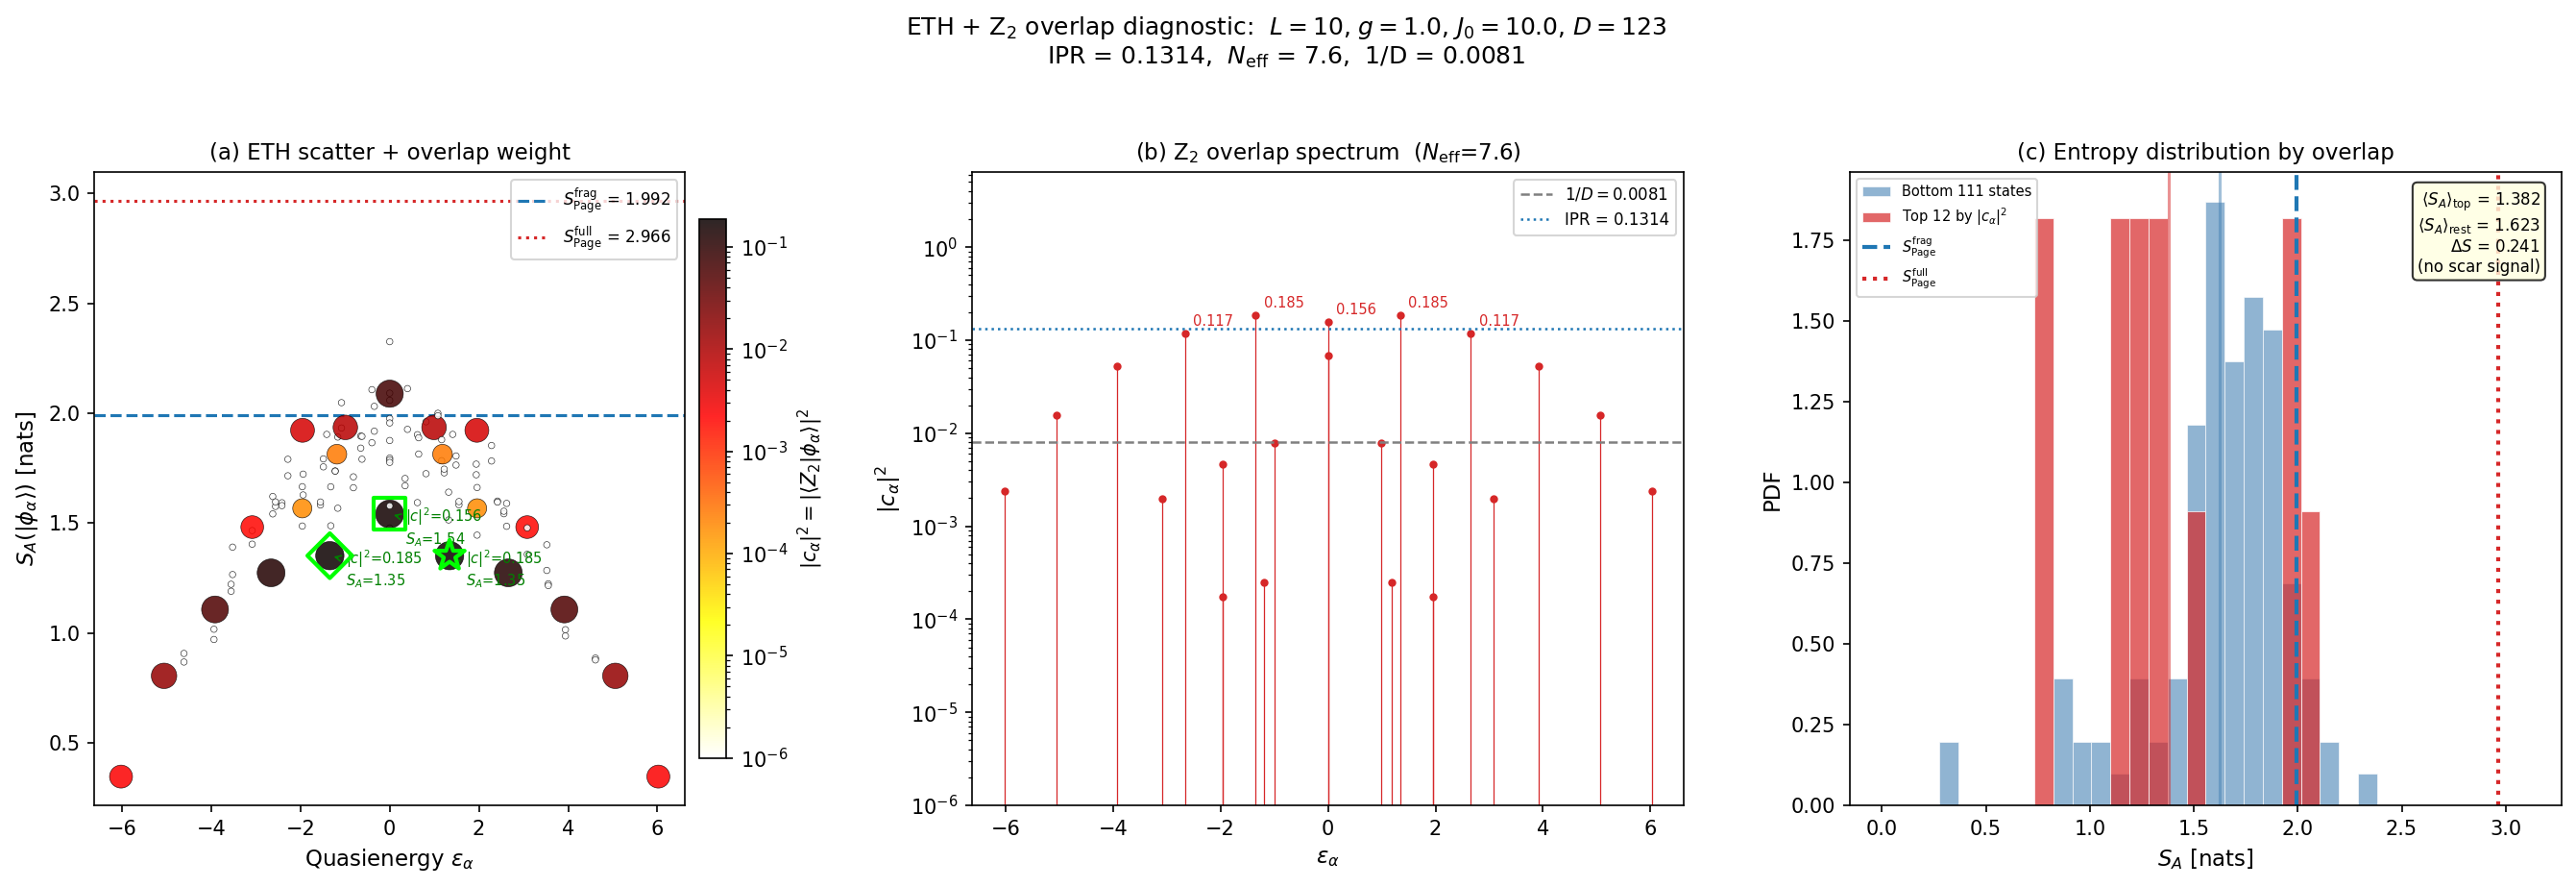

  Saved: eth_Z2overlap_L10_g1.0.png


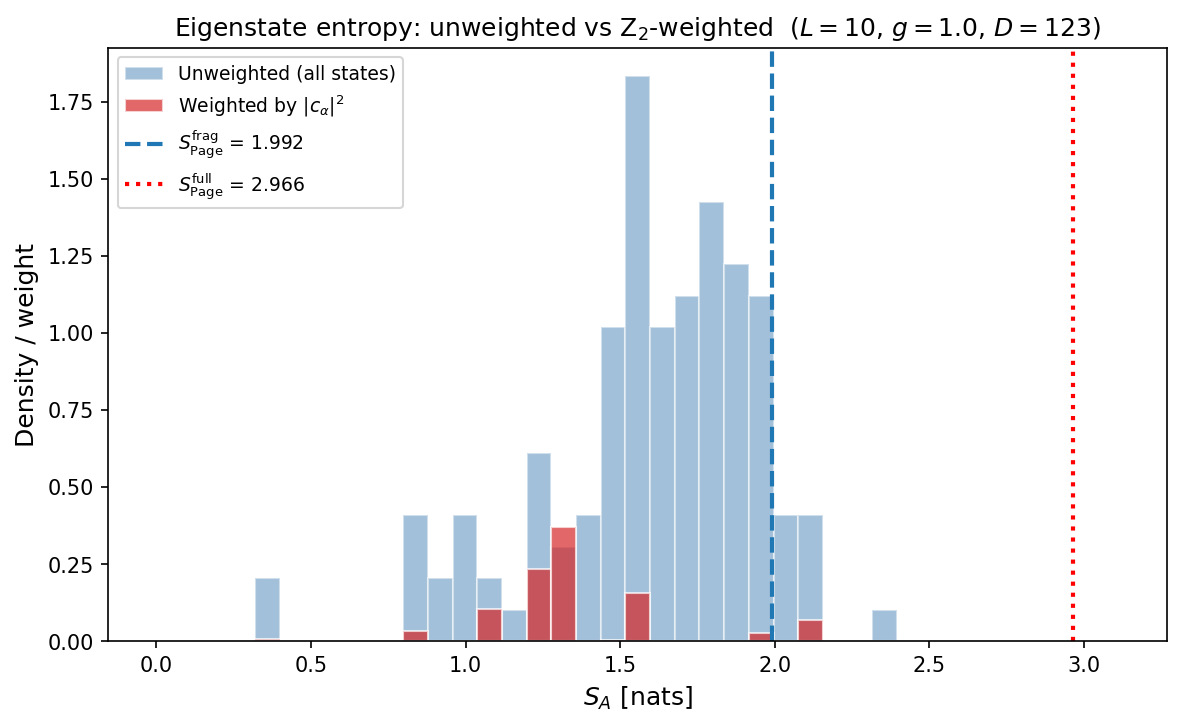

  Saved: eth_hist_L10_g1.0.png

SCAR DIAGNOSTIC SUMMARY
  D = 123
  IPR = 0.131450,  N_eff = 7.6
  ⟨S_A⟩_top = 1.3816
  ⟨S_A⟩_rest = 1.6230
  ΔS = 0.2415
  S_Page^(frag) = 1.9922
  → WEAK scar signal: some entanglement deficit


In [ ]:
"""
ETH Diagnostic: S_A vs quasienergy with Z₂ overlap weights
=============================================================

Scatter: x = ε_α (quasienergy), y = S_A(|ϕ_α⟩), colour+size = |c_α|²
where c_α = ⟨Z₂|ϕ_α⟩  is the overlap of the Floquet eigenstate
with the Z₂ CDW probe |Z₂⟩ = |1010...10⟩.

This is the decisive scar diagnostic:
  • Generic ETH states: S_A ≈ S_Page^(frag),  |c_α|² ≈ 1/D
  • Scar states:         S_A ≪ S_Page^(frag),  |c_α|² ≫ 1/D

*** SPARSE ONLY — no dense U_F ever formed. ***
Reuses: snippets/ modules (hamiltonian, evolution, fragment_ops, entropy,
        fragment_page).

Font fix: forces matplotlib to use DejaVu Sans (always available on Colab).
"""

import numpy as np
import time

# ── Fix Colab font warnings BEFORE any matplotlib import ──
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['text.usetex'] = False

from matplotlib.colors import LogNorm
from matplotlib.ticker import MaxNLocator



# ============================================================
# TUNABLE PARAMETERS
# ============================================================
L        = 10        # System size. L ≤ 16 feasible; L=12 → D=322.
J0       = 10.0      # Ising coupling
h0       = 2.0 * J0  # Longitudinal field (fragmentation: h0 = 2*J0)
g        = 1.0       # Transverse field perturbation
n_period = 1         # T = n_period * π / J0
seed     = 42        # RNG seed
n_MC     = 1000      # MC samples for fragment Page value


# ============================================================
# §1  RESULTS CODE
# ============================================================

def run_eth_diagnostic(L, J0, g, h0=None, n_period=1, n_MC=1000,
                       seed=42, verbose=True):
    """
    Full ETH diagnostic pipeline.

    Steps:
      1. Fragment identification (O operator, BFS)
      2. Sparse Floquet system build
      3. D×D fragment operator via batched Krylov
      4. Diagonalise → quasienergies ε_α, eigenvectors |ϕ_α⟩
      5. Entanglement entropies S_A(|ϕ_α⟩)
      6. Z₂ overlaps |c_α|² = |⟨Z₂|ϕ_α⟩|²
      7. Page values (full-space + fragment MC)

    Parameters
    ----------
    L : int — chain length (even, ≥ 4)
    J0 : float — Ising coupling
    g : float — transverse field
    h0 : float or None — longitudinal field (default 2·J0)
    n_period : int — T = n_period·π/J0
    n_MC : int — MC samples for fragment Page
    seed : int — RNG seed
    verbose : bool

    Returns
    -------
    data : dict — all computed quantities
    """
    if h0 is None:
        h0 = 2.0 * J0

    T = n_period * np.pi / J0
    Ns = 1 << L

    if verbose:
        print(f"\n{'='*60}")
        print(f"ETH DIAGNOSTIC: S_A vs ε with Z₂ overlaps")
        print(f"L={L}, J0={J0}, h0={h0}, g={g}, T={T:.6f}")
        print(f"Ns = {Ns}")
        print(f"{'='*60}")

    t_wall = time.perf_counter()

    # ── Step 1: Fragment identification ──
    O_diag = build_O_operator(L, J0)
    adj, num_edges = build_connectivity_graph(L, O_diag)
    comps = find_connected_components(adj)
    largest = np.array(find_largest_fragment(comps))
    D = len(largest)
    D_fib = fib(L - 1) + fib(L + 1)

    if verbose:
        print(f"\n  Fragments: {len(comps)}, largest D = {D}")
        print(f"  Fibonacci check: F_{L-1}+F_{L+1} = {D_fib}, "
              f"{'MATCH' if D == D_fib else 'MISMATCH'}")

    # ── Step 2: Sparse Floquet system ──
    ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
    ising.build_hamiltonians()

    # ── Step 3: D×D fragment operator via batched Krylov ──
    if verbose:
        print(f"\n  Building {D}×{D} fragment operator via batched Krylov...")
        print(f"  Embedding: {Ns}×{D} = {Ns*D*16/1e6:.1f} MB")

    t0 = time.perf_counter()

    I_frag = np.zeros((Ns, D), dtype=np.complex128)
    I_frag[largest, np.arange(D)] = 1.0

    U_frag_full = apply_floquet_step(ising, I_frag)
    U_frag_dense = U_frag_full[largest, :]

    t_build = time.perf_counter() - t0

    # Validate
    unitarity_err = np.linalg.norm(
        U_frag_dense.conj().T @ U_frag_dense - np.eye(D)
    )
    total_in_frag = np.sum(np.abs(U_frag_full[largest, :])**2)
    total_all = np.sum(np.abs(U_frag_full)**2)
    avg_leakage = 1.0 - total_in_frag / total_all
    max_leakage = 1.0 - np.sum(
        np.abs(U_frag_full[largest, :])**2, axis=0
    ).min()

    if verbose:
        print(f"  Built in {t_build:.2f}s")
        print(f"  Unitarity: ||U†U - I|| = {unitarity_err:.2e}")
        print(f"  Avg leakage: {avg_leakage:.2e}")
        print(f"  Max leakage: {max_leakage:.2e}")

    del I_frag, U_frag_full

    # ── Step 4: Diagonalise ──
    if verbose:
        print(f"\n  Diagonalising {D}×{D} fragment operator...")

    t0 = time.perf_counter()
    evals, evecs = np.linalg.eig(U_frag_dense)
    t_eig = time.perf_counter() - t0

    radii = np.abs(evals)
    quasienergies = -np.angle(evals) / T

    sort_idx = np.argsort(quasienergies)
    quasienergies = quasienergies[sort_idx]
    evecs = evecs[:, sort_idx]

    if verbose:
        print(f"  Time: {t_eig:.4f}s")
        print(f"  |λ| range: [{radii.min():.8f}, {radii.max():.8f}]")
        print(f"  ε range: [{quasienergies.min():.4f}, {quasienergies.max():.4f}]")

    # ── Step 5: Entanglement entropies ──
    A_indices = list(range(L // 2))

    if verbose:
        print(f"\n  Computing S_A for {D} eigenstates (A = sites {A_indices})...")

    t0 = time.perf_counter()
    entropies = np.zeros(D)
    for alpha in range(D):
        psi_full = np.zeros(Ns, dtype=np.complex128)
        psi_full[largest] = evecs[:, alpha]
        entropies[alpha] = bipartite_entropy(psi_full, L, A_indices)
    t_ent = time.perf_counter() - t0

    if verbose:
        print(f"  Time: {t_ent:.2f}s")
        print(f"  S_A range: [{entropies.min():.4f}, {entropies.max():.4f}]")
        print(f"  Mean S_A: {entropies.mean():.4f}")

    # ── Step 6: Z₂ overlaps ──
    # |Z₂⟩ = |1010...10⟩: bits 0,2,4,...,L-2 set
    s_Z2 = 0
    for i in range(0, L, 2):
        s_Z2 |= (1 << i)

    # Verify Z₂ is in fragment
    frag_set = set(int(s) for s in largest)
    assert s_Z2 in frag_set, \
        f"|Z₂⟩ = {s_Z2} ({bin(s_Z2)}) not in largest fragment!"

    # Find position of s_Z2 in the fragment basis
    frag_pos = np.searchsorted(largest, s_Z2)
    assert largest[frag_pos] == s_Z2

    # c_α = ⟨Z₂|ϕ_α⟩ = evecs[frag_pos, α]  (row of Z₂ in fragment basis)
    # Because evecs[:, α] gives |ϕ_α⟩ in fragment basis,
    # and ⟨Z₂| in fragment basis is a delta at frag_pos.
    c_alpha = evecs[frag_pos, :]   # shape (D,)
    w_alpha = np.abs(c_alpha)**2   # |c_α|²

    # Verify normalisation: Σ |c_α|² = 1 (completeness in fragment)
    w_sum = np.sum(w_alpha)
    ipr = np.sum(w_alpha**2)
    n_eff = 1.0 / ipr if ipr > 0 else np.inf

    if verbose:
        print(f"\n  Z₂ overlaps:")
        print(f"  |Z₂⟩ = |{format(s_Z2, f'0{L}b')}⟩ (index {s_Z2})")
        print(f"  Σ|c_α|² = {w_sum:.10f} (should be 1)")
        print(f"  IPR = {ipr:.6f},  N_eff = {n_eff:.1f}  (D = {D})")
        print(f"  Uniform: 1/D = {1.0/D:.6f},  IPR_unif = {1.0/D:.6f}")

        top5 = np.argsort(w_alpha)[-5:][::-1]
        print(f"\n  Top-5 overlaps:")
        print(f"  {'Rank':<6} {'ε_α':>10} {'|c_α|²':>10} {'S_A':>10}")
        for rank, idx in enumerate(top5):
            print(f"  {rank+1:<6} {quasienergies[idx]:>10.4f} "
                  f"{w_alpha[idx]:>10.6f} {entropies[idx]:>10.4f}")

    # ── Step 7: Page values ──
    S_page_full = compute_page_value(L)
    S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
        largest, L, n_samples=n_MC, seed=seed, verbose=False
    )

    if verbose:
        print(f"\n  S_Page (full):     {S_page_full:.6f}")
        print(f"  S_Page (frag, MC): {S_page_frag:.6f} ± {S_sem_frag:.6f}")

    t_total = time.perf_counter() - t_wall

    if verbose:
        print(f"\n  Total wall time: {t_total:.1f}s")

    return {
        'L': L, 'J0': J0, 'g': g, 'h0': h0, 'T': T,
        'D': D, 'Ns': Ns,
        'largest': largest,
        'quasienergies': quasienergies,
        'entropies': entropies,
        'w_alpha': w_alpha,         # |c_α|² = |⟨Z₂|ϕ_α⟩|²
        'c_alpha': c_alpha,         # complex amplitudes
        'ipr': ipr, 'n_eff': n_eff,
        's_Z2': s_Z2,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
        'S_std_frag': S_std_frag,
        'S_sem_frag': S_sem_frag,
        'unitarity_err': unitarity_err,
        'avg_leakage': avg_leakage,
        'max_leakage': max_leakage,
        't_build': t_build,
        't_total': t_total,
    }


# ============================================================
# §2  PLOTTING CODE
# ============================================================

def plot_eth_with_overlaps(data, save_prefix="eth_Z2overlap"):
    """
    Three-panel ETH diagnostic with Z₂ overlap weights.

    Panel (a): S_A vs ε, colour+size = |c_α|²
               Scar candidates: high |c_α|², low S_A.

    Panel (b): |c_α|² vs ε  (stem plot, log scale)
               Shows whether weight concentrates on few states.

    Panel (c): S_A histogram, split by overlap weight
               Red = top-10% by |c_α|², blue = rest.
               Scar ⟹ red distribution shifted below blue.

    Parameters
    ----------
    data : dict — output of run_eth_diagnostic
    save_prefix : str

    Returns
    -------
    fpath : str — saved figure path
    """
    eps = data['quasienergies']
    S = data['entropies']
    w = data['w_alpha']
    D = data['D']
    L = data['L']
    g = data['g']
    J0 = data['J0']
    Ns = data['Ns']
    S_pf = data['S_page_frag']
    S_pf_sem = data['S_sem_frag']
    S_pfull = data['S_page_full']
    ipr = data['ipr']
    n_eff = data['n_eff']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f'ETH + Z$_2$ overlap diagnostic:  $L={L}$, $g={g}$, '
        f'$J_0={J0}$, $D={D}$\n'
        f'IPR = {ipr:.4f},  $N_{{\\mathrm{{eff}}}}$ = {n_eff:.1f},  '
        f'1/D = {1.0/D:.4f}',
        fontsize=12, y=1.02
    )

    # ─────────────────────────────────────────────────
    # Panel (a): S_A vs ε, coloured by |c_α|²
    # ─────────────────────────────────────────────────
    ax = axes[0]

    w_plot = np.clip(w, 1e-10, None)
    w_min_plot = max(w_plot[w_plot > 0].min(), 1e-6)
    w_max_plot = w_plot.max()

    # Size: scale between 10 and 200 based on log(w)
    log_w = np.log10(w_plot)
    log_min, log_max = np.log10(w_min_plot), np.log10(w_max_plot)
    if log_max > log_min:
        size_norm = (log_w - log_min) / (log_max - log_min)
    else:
        size_norm = np.ones_like(log_w) * 0.5
    sizes = 10 + 190 * np.clip(size_norm, 0, 1)

    sc = ax.scatter(
        eps, S, c=w_plot, cmap='hot_r',
        norm=LogNorm(vmin=w_min_plot, vmax=w_max_plot),
        s=sizes, edgecolors='k', linewidths=0.3, alpha=0.85, zorder=3
    )

    ax.axhline(S_pf, color='C0', ls='--', lw=1.5,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag}}}}$ = {S_pf:.3f}')
    ax.axhline(S_pfull, color='C3', ls=':', lw=1.5,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{full}}}}$ = {S_pfull:.3f}')

    # Mark top-3 overlap states
    top3 = np.argsort(w)[-3:][::-1]
    for rank, idx in enumerate(top3):
        marker = ['*', 'D', 's'][rank]
        ax.scatter(eps[idx], S[idx], marker=marker, s=250,
                   facecolors='none', edgecolors='lime', linewidths=2,
                   zorder=5)
        ax.annotate(
            f'$|c|^2$={w[idx]:.3f}\n$S_A$={S[idx]:.2f}',
            (eps[idx], S[idx]),
            textcoords='offset points', xytext=(8, -15),
            fontsize=7, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=0.8)
        )

    cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(r'$|c_\alpha|^2 = |\langle Z_2|\phi_\alpha\rangle|^2$',
                 fontsize=10)

    ax.set_xlabel(r'Quasienergy $\varepsilon_\alpha$', fontsize=11)
    ax.set_ylabel(r'$S_A(|\phi_\alpha\rangle)$ [nats]', fontsize=11)
    ax.set_title('(a) ETH scatter + overlap weight', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

    # ─────────────────────────────────────────────────
    # Panel (b): |c_α|² vs ε  (stem)
    # ─────────────────────────────────────────────────
    ax = axes[1]

    markerline, stemlines, baseline = ax.stem(
        eps, w, linefmt='C3-', markerfmt='C3o', basefmt='k-'
    )
    plt.setp(stemlines, linewidth=0.6)
    plt.setp(markerline, markersize=3)

    ax.axhline(1.0 / D, color='gray', ls='--', lw=1.2,
               label=f'$1/D = {1.0/D:.4f}$')
    ax.axhline(ipr, color='C0', ls=':', lw=1.2,
               label=f'IPR = {ipr:.4f}')

    # Annotate top-5
    top5 = np.argsort(w)[-5:][::-1]
    for rank, idx in enumerate(top5):
        ax.annotate(
            f'{w[idx]:.3f}',
            (eps[idx], w[idx]),
            textcoords='offset points', xytext=(4, 4),
            fontsize=7, color='C3'
        )

    ax.set_xlabel(r'$\varepsilon_\alpha$', fontsize=11)
    ax.set_ylabel(r'$|c_\alpha|^2$', fontsize=11)
    ax.set_title(
        f'(b) Z$_2$ overlap spectrum  '
        f'($N_{{\\mathrm{{eff}}}}$={n_eff:.1f})',
        fontsize=11
    )
    ax.set_yscale('log')
    ax.set_ylim(bottom=max(1e-6, w[w > 0].min() / 3))
    ax.legend(fontsize=8, loc='upper right')

    # ─────────────────────────────────────────────────
    # Panel (c): S_A histogram, split by overlap weight
    # ─────────────────────────────────────────────────
    ax = axes[2]

    # Split: top-10% by |c_α|² vs rest
    n_top = max(1, D // 10)
    top_mask = np.zeros(D, dtype=bool)
    top_mask[np.argsort(w)[-n_top:]] = True
    rest_mask = ~top_mask

    bins = np.linspace(0, max(S.max(), S_pfull) * 1.05, 35)

    ax.hist(S[rest_mask], bins=bins, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', linewidth=0.5,
            label=f'Bottom {D - n_top} states')
    ax.hist(S[top_mask], bins=bins, density=True, alpha=0.7,
            color='C3', edgecolor='white', linewidth=0.5,
            label=f'Top {n_top} by $|c_\\alpha|^2$')

    ax.axvline(S_pf, color='C0', ls='--', lw=2,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag}}}}$')
    ax.axvline(S_pfull, color='C3', ls=':', lw=2,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{full}}}}$')

    # Mean entropies for each group
    S_mean_top = np.mean(S[top_mask])
    S_mean_rest = np.mean(S[rest_mask])
    ax.axvline(S_mean_top, color='C3', ls='-', lw=1.5, alpha=0.5)
    ax.axvline(S_mean_rest, color='steelblue', ls='-', lw=1.5, alpha=0.5)

    ax.set_xlabel(r'$S_A$ [nats]', fontsize=11)
    ax.set_ylabel('PDF', fontsize=11)
    ax.set_title('(c) Entropy distribution by overlap', fontsize=11)
    ax.legend(fontsize=7, loc='upper left')

    # Scar diagnostic annotation
    delta_S = S_mean_rest - S_mean_top
    textstr = (
        f'$\\langle S_A \\rangle_{{\\mathrm{{top}}}}$ = {S_mean_top:.3f}\n'
        f'$\\langle S_A \\rangle_{{\\mathrm{{rest}}}}$ = {S_mean_rest:.3f}\n'
        f'$\\Delta S$ = {delta_S:.3f}'
    )
    if delta_S > 0.3:
        textstr += '\n$\\Rightarrow$ potential scars'
    else:
        textstr += '\n(no scar signal)'
    props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
    ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    # ── Save ──
    plt.tight_layout()
    fpath = f'{save_prefix}_L{L}_g{g}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()

    from IPython.display import display, Image
    display(Image(filename=fpath))
    print(f"  Saved: {fpath}")
    return fpath


def plot_eth_bonus_histogram(data, save_prefix="eth_hist"):
    """
    Standalone histogram of S_A coloured by overlap weight.

    Supplementary to the three-panel figure.
    """
    S = data['entropies']
    w = data['w_alpha']
    D = data['D']
    L = data['L']
    g = data['g']
    S_pf = data['S_page_frag']
    S_pfull = data['S_page_full']

    fig, ax = plt.subplots(figsize=(8, 5))

    # Weighted histogram: weight each eigenstate by |c_α|²
    bins = np.linspace(0, max(S.max(), S_pfull) * 1.05, 40)

    ax.hist(S, bins=bins, density=True, alpha=0.5,
            color='steelblue', edgecolor='white',
            label='Unweighted (all states)')
    ax.hist(S, bins=bins, weights=w, density=False, alpha=0.7,
            color='C3', edgecolor='white',
            label=r'Weighted by $|c_\alpha|^2$')

    ax.axvline(S_pf, color='C0', ls='--', lw=2,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag}}}}$ = {S_pf:.3f}')
    ax.axvline(S_pfull, color='red', ls=':', lw=2,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{full}}}}$ = {S_pfull:.3f}')

    ax.set_xlabel(r'$S_A$ [nats]', fontsize=12)
    ax.set_ylabel('Density / weight', fontsize=12)
    ax.set_title(
        f'Eigenstate entropy: unweighted vs Z$_2$-weighted  '
        f'($L={L}$, $g={g}$, $D={D}$)',
        fontsize=12
    )
    ax.legend(fontsize=9)

    plt.tight_layout()
    fpath = f'{save_prefix}_L{L}_g{g}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()

    from IPython.display import display, Image
    display(Image(filename=fpath))
    print(f"  Saved: {fpath}")
    return fpath


# ============================================================
# §3  TESTBENCH
# ============================================================

if __name__ == "__main__":
    print(f"{'#'*60}")
    print(f"# ETH + Z₂ OVERLAP DIAGNOSTIC")
    print(f"{'#'*60}")

    data = run_eth_diagnostic(
        L=L, J0=J0, g=g, h0=h0,
        n_period=n_period, n_MC=n_MC,
        seed=seed, verbose=True
    )

    plot_eth_with_overlaps(data)
    plot_eth_bonus_histogram(data)

    # ── Scar summary ──
    w = data['w_alpha']
    S = data['entropies']
    D = data['D']
    S_pf = data['S_page_frag']

    n_top = max(1, D // 10)
    top_idx = np.argsort(w)[-n_top:]
    S_top = S[top_idx]
    S_rest = np.delete(S, top_idx)

    print(f"\n{'='*60}")
    print(f"SCAR DIAGNOSTIC SUMMARY")
    print(f"{'='*60}")
    print(f"  D = {D}")
    print(f"  IPR = {data['ipr']:.6f},  N_eff = {data['n_eff']:.1f}")
    print(f"  ⟨S_A⟩_top = {S_top.mean():.4f}")
    print(f"  ⟨S_A⟩_rest = {S_rest.mean():.4f}")
    print(f"  ΔS = {S_rest.mean() - S_top.mean():.4f}")
    print(f"  S_Page^(frag) = {S_pf:.4f}")

    delta_S = S_rest.mean() - S_top.mean()
    if delta_S > 0.5:
        print(f"  → STRONG scar signal: top-overlap states are "
              f"significantly less entangled")
    elif delta_S > 0.2:
        print(f"  → WEAK scar signal: some entanglement deficit")
    else:
        print(f"  → NO scar signal: top-overlap states are generic ETH")

## Energies

############################################################
# ETH SCATTER — L = 8 TESTBENCH
############################################################
J_0 = 10.0, g = 1.0, h_0 = 2·J_0 = 20.0

ETH SCATTER DIAGNOSTIC
L = 8, g = 1.0, ℓ = 4, k = 0

ANALYTIC PREDICTIONS  (L = 8, PBC)
  Luc(8)        = 47
  Δ_8            = -1   (L mod 6 = 2)
  N_A (even N↑)  = 23
  N_B (odd  N↑)  = 24
  dim ker(H) ≥   1
  Fragment frac  = 47/256 = 0.183594

Enumerating PBC no-adjacent-up basis...
  ✓ Basis verified: D = 47 = Luc(8)
  ✓ Sublattices: N_A = 23, N_B = 24, Δ = -1

Building H_eff (D = 47)...
  nnz = 208, density = 0.0942

  H_eff verification (D = 47):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 5.33e-15  ✓
    Zero modes: 7 (≥ 1 required)  ✓

Computing translation orbits...
  Number of orbits: 8

Diagonalising k = 0 block...
  D_k = 8
  E range: [-4.830959, 4.830959]

Computing eigenstate entropies (ℓ = 4)...

  Eigenstate verification (D_k = 8):
    Max

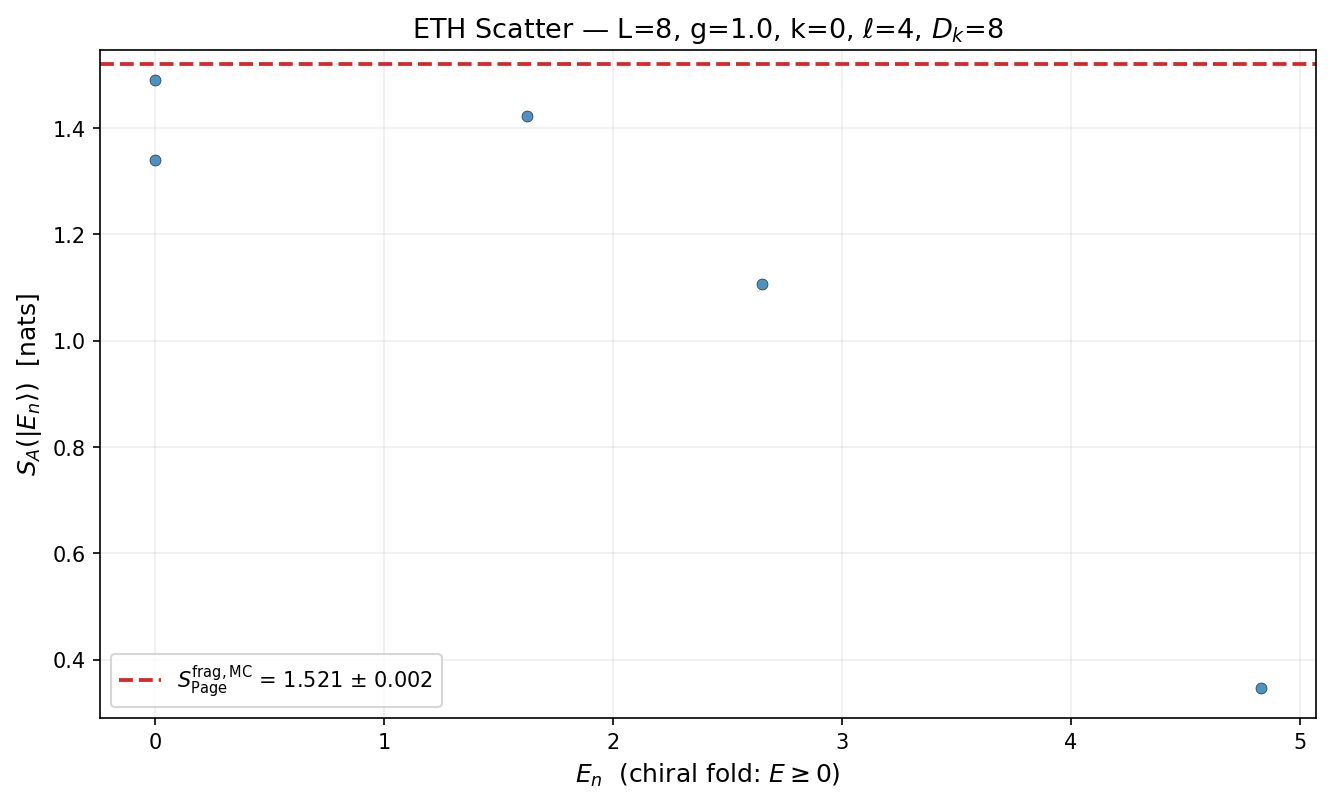


CROSS-VALIDATION: full H_eff vs k-block
  Matched: 8/8
  Non-degenerate: 6, max |ΔS_A| = 8.33e-16  ✓
  Degenerate (skipped): 2


############################################################
# ETH SCATTER — L = 8, k = 1
############################################################

ETH SCATTER DIAGNOSTIC
L = 8, g = 1.0, ℓ = 4, k = 1

ANALYTIC PREDICTIONS  (L = 8, PBC)
  Luc(8)        = 47
  Δ_8            = -1   (L mod 6 = 2)
  N_A (even N↑)  = 23
  N_B (odd  N↑)  = 24
  dim ker(H) ≥   1
  Fragment frac  = 47/256 = 0.183594

Enumerating PBC no-adjacent-up basis...
  ✓ Basis verified: D = 47 = Luc(8)
  ✓ Sublattices: N_A = 23, N_B = 24, Δ = -1

Building H_eff (D = 47)...
  nnz = 208, density = 0.0942

  H_eff verification (D = 47):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 5.33e-15  ✓
    Zero modes: 7 (≥ 1 required)  ✓

Computing translation orbits...
  Number of orbits: 8

Diagonalising k = 1 block...
  D_k = 5
  E range: [-2.241891, 2.241891]



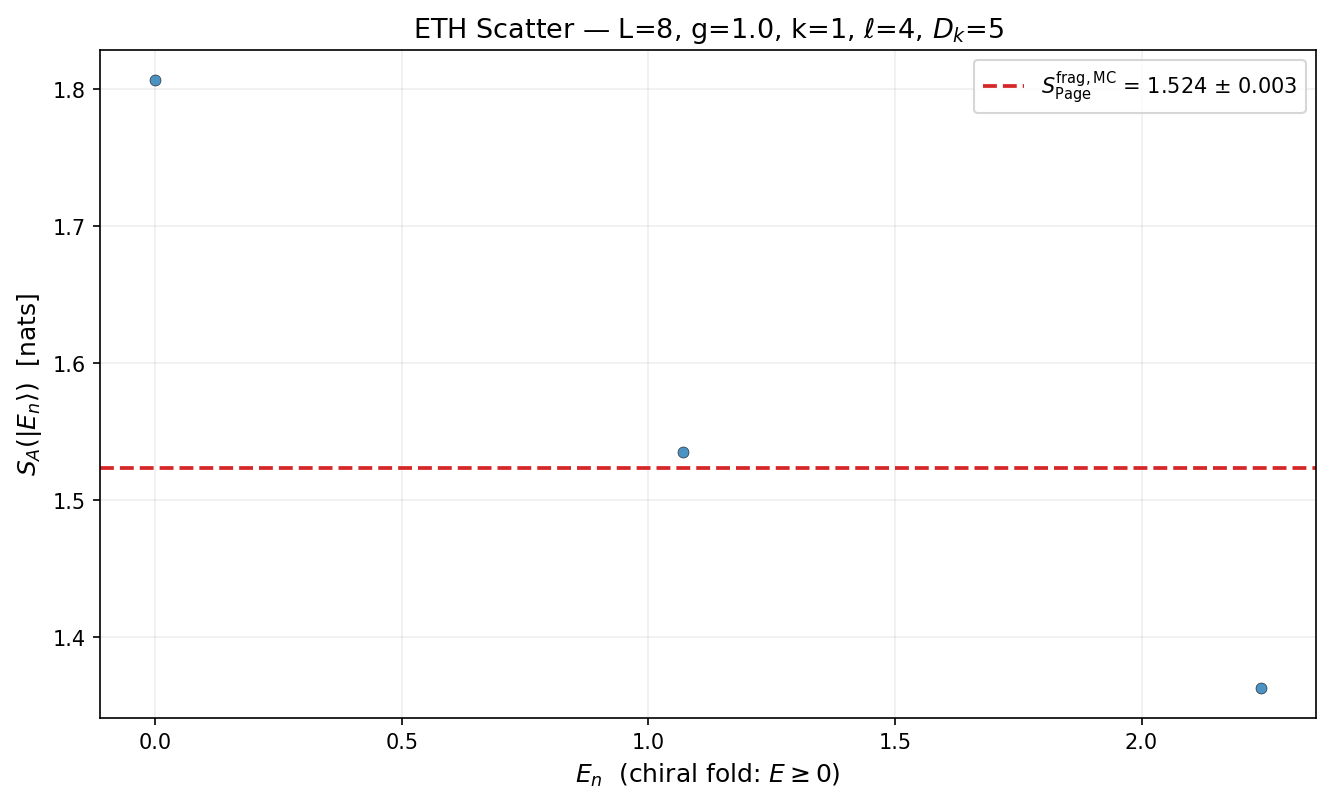



############################################################
# ETH SCATTER — L = 12
############################################################

ETH SCATTER DIAGNOSTIC
L = 12, g = 1.0, ℓ = 6, k = 0

ANALYTIC PREDICTIONS  (L = 12, PBC)
  Luc(12)        = 322
  Δ_12            = 2   (L mod 6 = 0)
  N_A (even N↑)  = 162
  N_B (odd  N↑)  = 160
  dim ker(H) ≥   2
  Fragment frac  = 322/4096 = 0.078613

Enumerating PBC no-adjacent-up basis...
  ✓ Basis verified: D = 322 = Luc(12)
  ✓ Sublattices: N_A = 162, N_B = 160, Δ = 2

Building H_eff (D = 322)...
  nnz = 2136, density = 0.0206

  H_eff verification (D = 322):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 2.40e-14  ✓
    Zero modes: 22 (≥ 2 required)  ✓

Computing translation orbits...
  Number of orbits: 31

Diagonalising k = 0 block...
  D_k = 31
  E range: [-7.242941, 7.242941]

Computing eigenstate entropies (ℓ = 6)...

  Eigenstate verification (D_k = 31):
    Max norm deviation: 1.55e-15  ✓


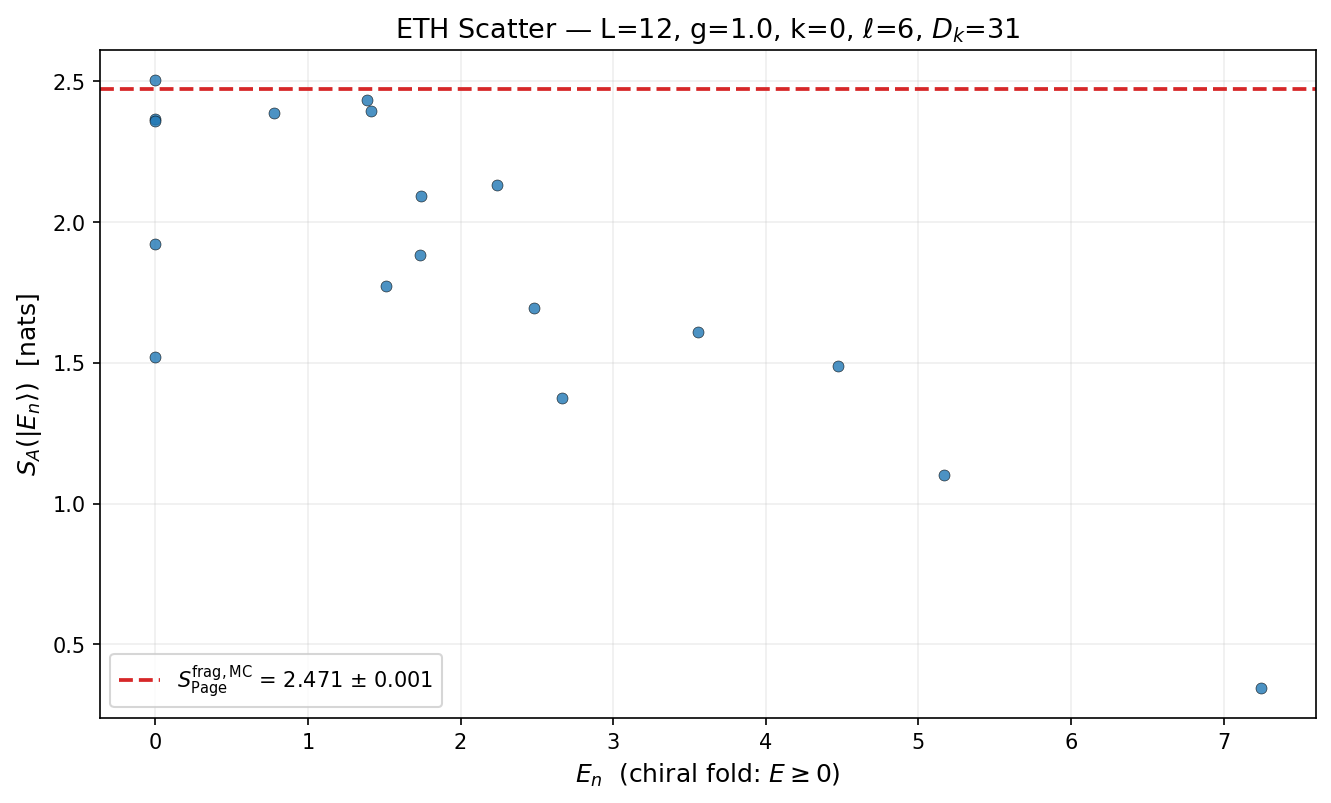


CROSS-VALIDATION: full H_eff vs k-block
  Matched: 31/31
  Non-degenerate: 26, max |ΔS_A| = 5.11e-15  ✓
  Degenerate (skipped): 5


FINAL SUMMARY

  L=8,k=0:
    D_k = 8, ℓ = 4
    S_Page^(frag,MC) = 1.5211 ± 0.0016
    E>0 entropy range: [0.3474, 1.4900]

  L=8,k=1:
    D_k = 5, ℓ = 4
    S_Page^(frag,MC) = 1.5238 ± 0.0031
    E>0 entropy range: [1.3635, 1.8063]

  L=12,k=0:
    D_k = 31, ℓ = 6
    S_Page^(frag,MC) = 2.4709 ± 0.0006
    E>0 entropy range: [0.3468, 2.5033]


In [ ]:
# ============================================================
# CONVENTION-UNIFIED CODE (Prompt 1+2)
# ============================================================
#
# UNIVERSAL CONVENTION (matching conventions.py, fragment_ops.py):
#   site i  ↔  bit position (L-1-i)
#   bit = 0  →  ↑  (σ^z = +1)
#   bit = 1  →  ↓  (σ^z = -1)
#
# Consequences:
#   N↑ = L - popcount(s)        (count zero-bits)
#   "no adjacent ↑↑" = no adjacent 0-bits
#   PXP projector π_i^↓ = "bit at site i is 1"
#     → bit position (L-1-i) is 1
#     → (s >> (L-1-i)) & 1 == 1
# ============================================================

import numpy as np
from scipy import sparse
from scipy.sparse.linalg import eigsh
from collections import defaultdict
import time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


# ────────────────────────────────────────────────────────────
# §1  ANALYTIC UTILITIES
# ────────────────────────────────────────────────────────────

def fib(n):
    """Fibonacci number F_n (F_0=0, F_1=1)."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

def lucas(L):
    """Lucas number Luc(L) = F_{L-1} + F_{L+1}."""
    return fib(L - 1) + fib(L + 1)

def delta_L(L):
    """Sublattice imbalance Δ_L = N_A - N_B.  Period 6."""
    table = {0: 2, 1: 1, 2: -1, 3: -2, 4: -1, 5: 1}
    return table[L % 6]

def analytic_check(L):
    """Print analytic predictions for PBC largest fragment."""
    D = lucas(L)
    dL = delta_L(L)
    NA = (D + dL) // 2
    NB = (D - dL) // 2
    ker_lb = abs(dL)
    print(f"\n{'='*60}")
    print(f"ANALYTIC PREDICTIONS  (L = {L}, PBC)")
    print(f"{'='*60}")
    print(f"  Luc({L})        = {D}")
    print(f"  Δ_{L}            = {dL}   (L mod 6 = {L%6})")
    print(f"  N_A (even N↑)  = {NA}")
    print(f"  N_B (odd  N↑)  = {NB}")
    print(f"  dim ker(H) ≥   {ker_lb}")
    print(f"  Fragment frac  = {D}/{1<<L} = {D/(1<<L):.6f}")
    return D, dL, NA, NB


# ────────────────────────────────────────────────────────────
# §2  PBC LARGEST FRAGMENT BASIS
# ────────────────────────────────────────────────────────────

def enumerate_pbc_no_adjacent_up(L):
    """
    Enumerate all states in the PBC no-adjacent-↑ fragment.

    Convention: bit=0 → ↑, bit=1 → ↓.
    site i ↔ bit position (L-1-i).

    "No adjacent ↑↑" means: for all sites i, NOT both
    bit(L-1-i)=0 AND bit(L-1-((i+1)%L))=0.
    """
    Ns = 1 << L
    valid = []
    for s in range(Ns):
        ok = True
        for i in range(L):
            bp_i  = L - 1 - i
            bp_i1 = L - 1 - ((i + 1) % L)
            bit_i  = (s >> bp_i)  & 1
            bit_i1 = (s >> bp_i1) & 1
            if bit_i == 0 and bit_i1 == 0:  # both ↑
                ok = False
                break
        if ok:
            valid.append(s)
    return np.array(sorted(valid), dtype=np.int64)


def count_up_spins(s, L):
    """
    N↑ = number of ↑ spins = number of 0-bits in the L-bit representation.

    Convention: bit=0 → ↑.
    """
    return L - bin(s & ((1 << L) - 1)).count('1')


def verify_basis(L, basis):
    """Verify basis against analytic predictions."""
    D_pred = lucas(L)
    dL = delta_L(L)
    assert len(basis) == D_pred, \
        f"Basis size {len(basis)} ≠ Luc({L}) = {D_pred}"
    n_even = sum(1 for s in basis if count_up_spins(int(s), L) % 2 == 0)
    n_odd = len(basis) - n_even
    NA_pred = (D_pred + dL) // 2
    NB_pred = (D_pred - dL) // 2
    assert n_even == NA_pred, f"N_A = {n_even} ≠ {NA_pred}"
    assert n_odd == NB_pred, f"N_B = {n_odd} ≠ {NB_pred}"
    print(f"  ✓ Basis verified: D = {len(basis)} = Luc({L})")
    print(f"  ✓ Sublattices: N_A = {n_even}, N_B = {n_odd}, "
          f"Δ = {n_even - n_odd}")


# ────────────────────────────────────────────────────────────
# §3  EFFECTIVE HAMILTONIAN
# ────────────────────────────────────────────────────────────
#
# H_eff = -g Σ_i  π_{i-1}^↓  σ^x_i  π_{i+1}^↓    (PBC)
#
# Convention: bit=0 → ↑, bit=1 → ↓.
#   π_j^↓ = projector onto site j being ↓ = bit at position (L-1-j) is 1.
#   σ^x_i flips bit at position (L-1-i).
#
# The flip |s⟩ → |s'⟩ is allowed iff:
#   bit at position (L-1-((i-1)%L)) == 1   (neighbor i-1 is ↓)
#   bit at position (L-1-((i+1)%L)) == 1   (neighbor i+1 is ↓)
# ────────────────────────────────────────────────────────────

def build_Heff_fragment(L, g, basis):
    """
    H_eff = -g Σ_i π^↓_{i-1} σ^x_i π^↓_{i+1}  (PBC) in fragment basis.

    Convention: site i ↔ bit (L-1-i), bit=0 → ↑, bit=1 → ↓.
    """
    D = len(basis)
    state_to_idx = {int(s): idx for idx, s in enumerate(basis)}
    rows, cols, vals = [], [], []

    for idx, s in enumerate(basis):
        s_int = int(s)
        for i in range(L):
            ip = (i + 1) % L
            im = (i - 1) % L
            # Bit positions for the three sites
            bp_im = L - 1 - im
            bp_i  = L - 1 - i
            bp_ip = L - 1 - ip
            # Check π^↓_{i-1} and π^↓_{i+1}: both neighbors must be ↓ (bit=1)
            if ((s_int >> bp_im) & 1) == 1 and ((s_int >> bp_ip) & 1) == 1:
                # Flip site i: σ^x_i
                s_flipped = s_int ^ (1 << bp_i)
                j = state_to_idx.get(s_flipped)
                if j is not None:
                    rows.append(idx); cols.append(j); vals.append(-g)

    return sparse.csr_matrix((vals, (rows, cols)), shape=(D, D), dtype=np.float64)


def verify_Heff(H, L, basis):
    """Verify Hermiticity, chiral symmetry, ±E spectrum, zero modes."""
    D = len(basis)
    print(f"\n  H_eff verification (D = {D}):")

    # Hermiticity
    diff = H - H.T
    err = sparse.linalg.norm(diff)
    print(f"    ||H - H^T|| = {err:.2e}  {'✓' if err < 1e-12 else '✗'}")

    # Chiral: C = diag((-1)^{N↑})
    c_diag = np.array([(-1)**count_up_spins(int(s), L)
                       for s in basis], dtype=np.float64)
    C = sparse.diags(c_diag)
    anti = H @ C + C @ H
    anti_err = sparse.linalg.norm(anti)
    print(f"    ||{{H,C}}||    = {anti_err:.2e}  {'✓' if anti_err < 1e-12 else '✗'}")

    if D <= 5000:
        evals = np.linalg.eigvalsh(H.toarray())
        evals_sorted = np.sort(evals)
        sym_err = np.max(np.abs(evals_sorted + evals_sorted[::-1]))
        print(f"    Spectrum ±E err = {sym_err:.2e}  "
              f"{'✓' if sym_err < 1e-10 else '✗'}")
        n_zero = np.sum(np.abs(evals) < 1e-10)
        dL = abs(delta_L(L))
        print(f"    Zero modes: {n_zero} (≥ {dL} required)  "
              f"{'✓' if n_zero >= dL else '✗'}")
        return evals
    return None


# ────────────────────────────────────────────────────────────
# §4  TRANSLATION SYMMETRY
# ────────────────────────────────────────────────────────────
#
# Translation T: site i → site (i+1) mod L
# In bit representation: site i ↔ bit (L-1-i)
#   T shifts site index by +1, which shifts bit position by -1,
#   i.e., cyclic RIGHT shift of the L-bit string.
# ────────────────────────────────────────────────────────────

def translate_state(s, L):
    """
    Apply translation T: site i → site (i+1) mod L.

    In bit representation (site i ↔ bit L-1-i):
    this is a cyclic RIGHT shift by 1 of the lower L bits.
    """
    lsb = s & 1
    return (s >> 1) | (lsb << (L - 1))


def compute_translation_orbits(basis, L):
    """Partition basis into translation orbits."""
    D = len(basis)
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    visited = np.zeros(D, dtype=bool)
    orbits = []
    orbit_of = np.empty(D, dtype=np.int64)
    representatives = []

    for idx in range(D):
        if visited[idx]:
            continue
        orbit = []
        s = int(basis[idx])
        for _ in range(L):
            j = state_to_idx[s]
            if not visited[j]:
                visited[j] = True
                orbit.append(j)
                orbit_of[j] = len(orbits)
            s = translate_state(s, L)
        orbits.append(orbit)
        representatives.append(orbit[0])

    return orbits, orbit_of, representatives


def build_momentum_block_v2(L, g, basis, orbits, k_index):
    """
    Build H_eff in momentum sector k = 2π·k_index/L.

    Uses same PXP projector convention as build_Heff_fragment:
    site i ↔ bit (L-1-i), bit=0 → ↑, bit=1 → ↓.
    π^↓_j requires bit at (L-1-j) == 1.
    """
    k = 2.0 * np.pi * k_index / L
    D = len(basis)
    state_to_idx = {int(s): i for i, s in enumerate(basis)}

    orbit_id = np.empty(D, dtype=np.int64)
    offset_in_orbit = np.empty(D, dtype=np.int64)
    for alpha, orbit in enumerate(orbits):
        for off, idx in enumerate(orbit):
            orbit_id[idx] = alpha
            offset_in_orbit[idx] = off

    compatible = []
    for alpha, orbit in enumerate(orbits):
        p = len(orbit)
        if abs(np.exp(1j * k * p) - 1.0) < 1e-10:
            compatible.append(alpha)

    D_k = len(compatible)
    if D_k == 0:
        return np.zeros((0, 0), dtype=np.complex128), [], 0

    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible)}
    H_k = np.zeros((D_k, D_k), dtype=np.complex128)

    for b_loc, alpha_b in enumerate(compatible):
        orbit_b = orbits[alpha_b]
        p_b = len(orbit_b)
        s_r = int(basis[orbit_b[0]])
        for r in range(p_b):
            phase_r = np.exp(1j * k * r)
            for i in range(L):
                ip = (i + 1) % L
                im = (i - 1) % L
                bp_im = L - 1 - im
                bp_i  = L - 1 - i
                bp_ip = L - 1 - ip
                # π^↓ check: neighbors must have bit=1 (↓)
                if ((s_r >> bp_im) & 1) == 1 and ((s_r >> bp_ip) & 1) == 1:
                    s_flipped = s_r ^ (1 << bp_i)
                    j_full = state_to_idx.get(s_flipped)
                    if j_full is not None:
                        alpha_a = orbit_id[j_full]
                        if alpha_a in orbit_to_local:
                            a_loc = orbit_to_local[alpha_a]
                            t = offset_in_orbit[j_full]
                            p_a = len(orbits[alpha_a])
                            phase = phase_r * np.exp(-1j * k * t)
                            H_k[a_loc, b_loc] += (-g) * phase / np.sqrt(p_a * p_b)
            s_r = translate_state(s_r, L)

    return H_k, compatible, D_k


# ────────────────────────────────────────────────────────────
# §P2  HAAR SAMPLING + MC PAGE + EIGENVECTORS
# ────────────────────────────────────────────────────────────

def bipartite_entropy_fragment_state(c, basis, L, ell):
    """
    Compute S_A for |ψ⟩ = Σ_α c_α |s_α⟩, A = sites [0,...,ℓ-1].

    Convention: site i ↔ bit (L-1-i).
    A-config = bits at positions [L-1, L-2, ..., L-ℓ]  (top ℓ bits)
    B-config = bits at positions [L-ℓ-1, ..., 0]       (bottom L-ℓ bits)
    """
    dim_A = 1 << ell
    dim_B = 1 << (L - ell)
    M = np.zeros((dim_A, dim_B), dtype=np.complex128)

    for idx in range(len(basis)):
        s = int(basis[idx])
        # A = sites [0,...,ℓ-1] ↔ bits [L-1,...,L-ℓ] = top ℓ bits
        a = s >> (L - ell)           # top ℓ bits
        b = s & ((1 << (L - ell)) - 1)  # bottom (L-ℓ) bits
        M[a, b] += c[idx]

    sv = np.linalg.svd(M, compute_uv=False)
    p = sv * sv
    p = p[p > 1e-15]
    S = -np.sum(p * np.log(p))
    return float(np.real(S))

def diagonalise_k_block(L, g, basis, orbits, k_index):
    """
    Diagonalise H_eff in momentum sector k, return eigenvectors
    in the fragment computational basis.
    """
    k = 2.0 * np.pi * k_index / L
    D = len(basis)

    H_k, compatible, D_k = build_momentum_block_v2(
        L, g, basis, orbits, k_index
    )
    if D_k == 0:
        return np.array([]), np.zeros((D, 0), dtype=np.complex128), []

    evals, evecs_k = np.linalg.eigh(H_k)
    evecs_frag = np.zeros((D, D_k), dtype=np.complex128)

    orbit_id_arr = np.empty(D, dtype=np.int64)
    offset_arr = np.empty(D, dtype=np.int64)
    for alpha, orbit in enumerate(orbits):
        for off, idx in enumerate(orbit):
            orbit_id_arr[idx] = alpha
            offset_arr[idx] = off

    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible)}

    for idx in range(D):
        alpha = orbit_id_arr[idx]
        if alpha not in orbit_to_local:
            continue
        loc = orbit_to_local[alpha]
        r = offset_arr[idx]
        p = len(orbits[alpha])
        phase = np.exp(-1j * k * r) / np.sqrt(p)
        evecs_frag[idx, :] = phase * evecs_k[loc, :]

    return evals, evecs_frag, compatible


def compute_eigenstate_entropies(evecs_frag, basis, L, ell):
    """Compute S_A(|E_n⟩) for all eigenstates."""
    D_k = evecs_frag.shape[1]
    entropies = np.empty(D_k)
    for n in range(D_k):
        entropies[n] = bipartite_entropy_fragment_state(
            evecs_frag[:, n], basis, L, ell
        )
    return entropies


def verify_eigenstates(evals, evecs_frag, basis, L, ell):
    """Verify eigenvector reconstruction."""
    D_k = len(evals)
    print(f"\n  Eigenstate verification (D_k = {D_k}):")

    norms = np.linalg.norm(evecs_frag, axis=0)
    norm_err = np.max(np.abs(norms - 1.0))
    print(f"    Max norm deviation: {norm_err:.2e}  "
          f"{'✓' if norm_err < 1e-10 else '✗'}")

    overlap = evecs_frag.conj().T @ evecs_frag
    ortho_err = np.max(np.abs(overlap - np.eye(D_k)))
    print(f"    Max orthogonality err: {ortho_err:.2e}  "
          f"{'✓' if ortho_err < 1e-10 else '✗'}")

    entropies = compute_eigenstate_entropies(evecs_frag, basis, L, ell)

    idx_sorted = np.argsort(evals)
    evals_s = evals[idx_sorted]; S_s = entropies[idx_sorted]
    pos_mask = evals_s > 1e-10; neg_mask = evals_s < -1e-10

    if np.sum(pos_mask) > 0 and np.sum(neg_mask) > 0:
        E_pos = evals_s[pos_mask]; S_pos = S_s[pos_mask]
        E_neg = -evals_s[neg_mask][::-1]; S_neg = S_s[neg_mask][::-1]
        n_pairs = min(len(E_pos), len(E_neg))
        if n_pairs > 0:
            E_match_err = np.max(np.abs(E_pos[:n_pairs] - E_neg[:n_pairs]))
            S_match_err = np.max(np.abs(S_pos[:n_pairs] - S_neg[:n_pairs]))
            print(f"    Chiral E-pairing err: {E_match_err:.2e}")
            print(f"    Chiral S_A(E)=S_A(-E) err: {S_match_err:.2e}  "
                  f"{'✓' if S_match_err < 1e-8 else '⚠ (check)'}")

    return entropies

def compute_fragment_page_MC(basis, L, ell, n_samples=2000,
                             seed=42, verbose=True):
    """MC estimate of fragment Page value."""
    D  = len(basis)
    Ns = 1 << L                          # full Hilbert space dimension
    rng = np.random.default_rng(seed)

    if verbose:
        print(f"\n  MC Fragment Page Value (D={D}, ℓ={ell}, "
              f"{n_samples} samples)...")

    entropies = np.empty(n_samples)
    for r in range(n_samples):
        psi = sample_haar_state_in_fragment(basis, Ns, rng)  # 3-arg call
        c   = psi[basis]                                      # D coefficients
        entropies[r] = bipartite_entropy_fragment_state(c, basis, L, ell)
        if verbose and (r + 1) % 1000 == 0:
            print(f"    {r+1}/{n_samples} done, running mean = "
                  f"{np.mean(entropies[:r+1]):.6f}")

    S_mean = np.mean(entropies)
    S_std  = np.std(entropies, ddof=1)
    S_sem  = S_std / np.sqrt(n_samples)

    if verbose:
        print(f"    S_Page^(frag) = {S_mean:.6f} ± {S_sem:.6f} nats")
        print(f"    Std dev = {S_std:.6f}")
        print(f"    Range: [{np.min(entropies):.4f}, {np.max(entropies):.4f}]")

    return S_mean, S_std, S_sem
# ────────────────────────────────────────────────────────────
# §P2.6  PLOTTING
# ────────────────────────────────────────────────────────────

_plot_counter = 0

def show_and_save(fig, prefix="plot"):
    global _plot_counter
    _plot_counter += 1
    fname = f"{prefix}_{_plot_counter}.png"
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"  [Saved: {fname}]")
    try:
        from IPython.display import display, Image
        display(Image(filename=fname))
    except ImportError:
        pass


def plot_eth_scatter(results):
    """ETH scatter plot: S_A vs E_n (E≥0), with MC Page baseline."""
    L = results['L']; g = results['g']; ell = results['ell']
    k_index = results['k_index']; D_k = results['D_k']
    E = results['E_plot']; S = results['S_plot']
    S_page = results['S_page_MC']; S_sem = results['S_sem_MC']

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.scatter(E, S, c='C0', s=28, edgecolors='k', linewidths=0.3,
               alpha=0.8, zorder=3)
    ax.axhline(S_page, color='C3', ls='--', lw=1.8,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag,MC}}}}$'
                     f' = {S_page:.3f} ± {S_sem:.3f}')
    ax.set_xlabel('$E_n$  (chiral fold: $E \\geq 0$)', fontsize=12)
    ax.set_ylabel('$S_A(|E_n\\rangle)$  [nats]', fontsize=12)
    ax.set_title(f'ETH Scatter — L={L}, g={g}, k={k_index}, '
                 f'ℓ={ell}, $D_k$={D_k}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    show_and_save(fig, f"eth_scatter_L{L}_k{k_index}")


# ────────────────────────────────────────────────────────────
# §P2.7  FULL PIPELINE + CROSS-VALIDATION
# ────────────────────────────────────────────────────────────

def run_eth_scatter(L, g, ell=None, k_index=0, n_MC=2000,
                    seed=42, verbose=True):
    """Full ETH scatter diagnostic."""
    if ell is None:
        ell = L // 2

    t0 = time.perf_counter()

    print(f"\n{'='*60}")
    print(f"ETH SCATTER DIAGNOSTIC")
    print(f"L = {L}, g = {g}, ℓ = {ell}, k = {k_index}")
    print(f"{'='*60}")

    D_pred, dL, NA_pred, NB_pred = analytic_check(L)

    print(f"\nEnumerating PBC no-adjacent-up basis...")
    basis = enumerate_pbc_no_adjacent_up(L)
    verify_basis(L, basis)
    D = len(basis)

    print(f"\nBuilding H_eff (D = {D})...")
    H = build_Heff_fragment(L, g, basis)
    print(f"  nnz = {H.nnz}, density = {H.nnz/D**2:.4f}")
    evals_full = verify_Heff(H, L, basis)

    print(f"\nComputing translation orbits...")
    orbits, orbit_of, reps = compute_translation_orbits(basis, L)
    print(f"  Number of orbits: {len(orbits)}")

    print(f"\nDiagonalising k = {k_index} block...")
    evals_k, evecs_frag, compatible = diagonalise_k_block(
        L, g, basis, orbits, k_index
    )
    D_k = len(evals_k)
    print(f"  D_k = {D_k}")
    print(f"  E range: [{evals_k[0]:.6f}, {evals_k[-1]:.6f}]")

    print(f"\nComputing eigenstate entropies (ℓ = {ell})...")
    entropies = verify_eigenstates(evals_k, evecs_frag, basis, L, ell)

    S_page_MC, S_std_MC, S_sem_MC = compute_fragment_page_MC(
        basis, L, ell, n_samples=n_MC, seed=seed, verbose=verbose
    )
    print(f"\n  MC fragment Page value: {S_page_MC:.6f} ± {S_sem_MC:.6f}")

    E_max = np.max(np.abs(evals_k))
    mid_mask = np.abs(evals_k) < 0.3 * E_max
    if np.sum(mid_mask) > 0:
        S_mid = entropies[mid_mask]
        print(f"\n  Mid-spectrum (|E| < 0.3·E_max):")
        print(f"    N states: {np.sum(mid_mask)}")
        print(f"    ⟨S_A⟩_mid = {np.mean(S_mid):.6f}")
        print(f"    S_Page^(frag,MC) = {S_page_MC:.6f}")
        print(f"    ⟨S_A⟩_mid / S_Page = {np.mean(S_mid)/S_page_MC:.4f}")

    pos_mask = evals_k >= -1e-12
    E_plot = evals_k[pos_mask]
    S_plot = entropies[pos_mask]

    wall = time.perf_counter() - t0
    print(f"\n  Wall time: {wall:.2f} s")

    out = {
        'L': L, 'g': g, 'ell': ell, 'k_index': k_index,
        'D': D, 'D_k': D_k, 'basis': basis,
        'evals_k': evals_k, 'entropies': entropies,
        'S_page_MC': S_page_MC, 'S_std_MC': S_std_MC,
        'S_sem_MC': S_sem_MC, 'evals_full': evals_full,
        'E_plot': E_plot, 'S_plot': S_plot,
        'wall_time': wall,
    }

    plot_eth_scatter(out)
    return out


def cross_validate_eth(results, verbose=True):
    """Cross-validate k-block entropies against full H_eff diag."""
    L = results['L']; g = results['g']; ell = results['ell']
    basis = results['basis']; evals_full = results['evals_full']
    D = len(basis)

    if evals_full is None or D > 3000:
        print("  (Skipping cross-validation)")
        return None, None

    print(f"\n{'='*60}")
    print("CROSS-VALIDATION: full H_eff vs k-block")
    print(f"{'='*60}")

    H = build_Heff_fragment(L, g, basis)
    evals_direct, evecs_direct = np.linalg.eigh(H.toarray())

    S_direct = np.empty(D)
    for n in range(D):
        S_direct[n] = bipartite_entropy_fragment_state(
            evecs_direct[:, n], basis, L, ell
        )

    evals_k = results['evals_k']; S_k = results['entropies']

    matched = 0; nondeg_matched = 0; max_S_err = 0.0; n_deg = 0
    for i in range(len(evals_k)):
        j = np.argmin(np.abs(evals_direct - evals_k[i]))
        if abs(evals_direct[j] - evals_k[i]) < 1e-8:
            matched += 1
            deg = np.sum(np.abs(evals_direct - evals_k[i]) < 1e-8)
            if deg == 1:
                max_S_err = max(max_S_err, abs(S_direct[j] - S_k[i]))
                nondeg_matched += 1
            else:
                n_deg += 1

    print(f"  Matched: {matched}/{len(evals_k)}")
    print(f"  Non-degenerate: {nondeg_matched}, max |ΔS_A| = {max_S_err:.2e}  "
          f"{'✓' if max_S_err < 1e-10 else '✗'}")
    print(f"  Degenerate (skipped): {n_deg}")

    return evals_direct, S_direct
if __name__ == "__main__":
    # ── L=8 validation ──
    L = 8
    J_0 = 10.0
    g = 1.0

    print(f"{'#'*60}")
    print(f"# ETH SCATTER — L = {L} TESTBENCH")
    print(f"{'#'*60}")
    print(f"J_0 = {J_0}, g = {g}, h_0 = 2·J_0 = {2*J_0}")

    results = run_eth_scatter(L, g, ell=L//2, k_index=0,
                               n_MC=2000, seed=42, verbose=True)

    # Cross-validate against full diag
    xval = cross_validate_eth(results, verbose=True)

    # ── Also test k=1 for comparison ──
    print(f"\n\n{'#'*60}")
    print(f"# ETH SCATTER — L = {L}, k = 1")
    print(f"{'#'*60}")

    results_k1 = run_eth_scatter(L, g, ell=L//2, k_index=1,
                                  n_MC=500, seed=42, verbose=True)

    # ── L=12 for more meaningful data ──
    print(f"\n\n{'#'*60}")
    print(f"# ETH SCATTER — L = 12")
    print(f"{'#'*60}")

    results_12 = run_eth_scatter(12, g, ell=6, k_index=0,
                                  n_MC=2000, seed=42, verbose=True)
    xval_12 = cross_validate_eth(results_12, verbose=True)

    # ── Final summary ──
    print(f"\n\n{'='*60}")
    print("FINAL SUMMARY")
    print(f"{'='*60}")
    for label, r in [("L=8,k=0", results), ("L=8,k=1", results_k1),
                      ("L=12,k=0", results_12)]:
        print(f"\n  {label}:")
        print(f"    D_k = {r['D_k']}, ℓ = {r['ell']}")
        print(f"    S_Page^(frag,MC) = {r['S_page_MC']:.4f} ± {r['S_sem_MC']:.4f}")
        print(f"    E>0 entropy range: [{np.min(r['S_plot']):.4f}, "
              f"{np.max(r['S_plot']):.4f}]")

## Revivals in $\mathbb{Z}_2$ state




############################################################
# SCAR DIAGNOSTIC — L = 8
############################################################
J_0 = 10.0, g = 1.0, h_0 = 20.0

SCAR DIAGNOSTIC PIPELINE
L = 8, g = 1.0, ℓ = 4, k = 0

ANALYTIC PREDICTIONS  (L = 8, PBC)
  Luc(8)        = 47
  Δ_8            = -1   (L mod 6 = 2)
  N_A (even N↑)  = 23
  N_B (odd  N↑)  = 24
  dim ker(H) ≥   1
  Fragment frac  = 47/256 = 0.183594
  ✓ Basis verified: D = 47 = Luc(8)
  ✓ Sublattices: N_A = 23, N_B = 24, Δ = -1

  H_eff verification (D = 47):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 5.33e-15  ✓
    Zero modes: 7 (≥ 1 required)  ✓

  Orbits: 8
  k=0 block: D_k = 8
  E range: [-4.8310, 4.8310]

  MC Fragment Page Value (D=47, ℓ=4, 2000 samples)...
    1000/2000 done, running mean = 1.519674
    2000/2000 done, running mean = 1.521084
    S_Page^(frag) = 1.521084 ± 0.001561 nats
    Std dev = 0.069800
    Range: [1.2648, 1.7261]

  S_Page^(frag,MC) = 1.5

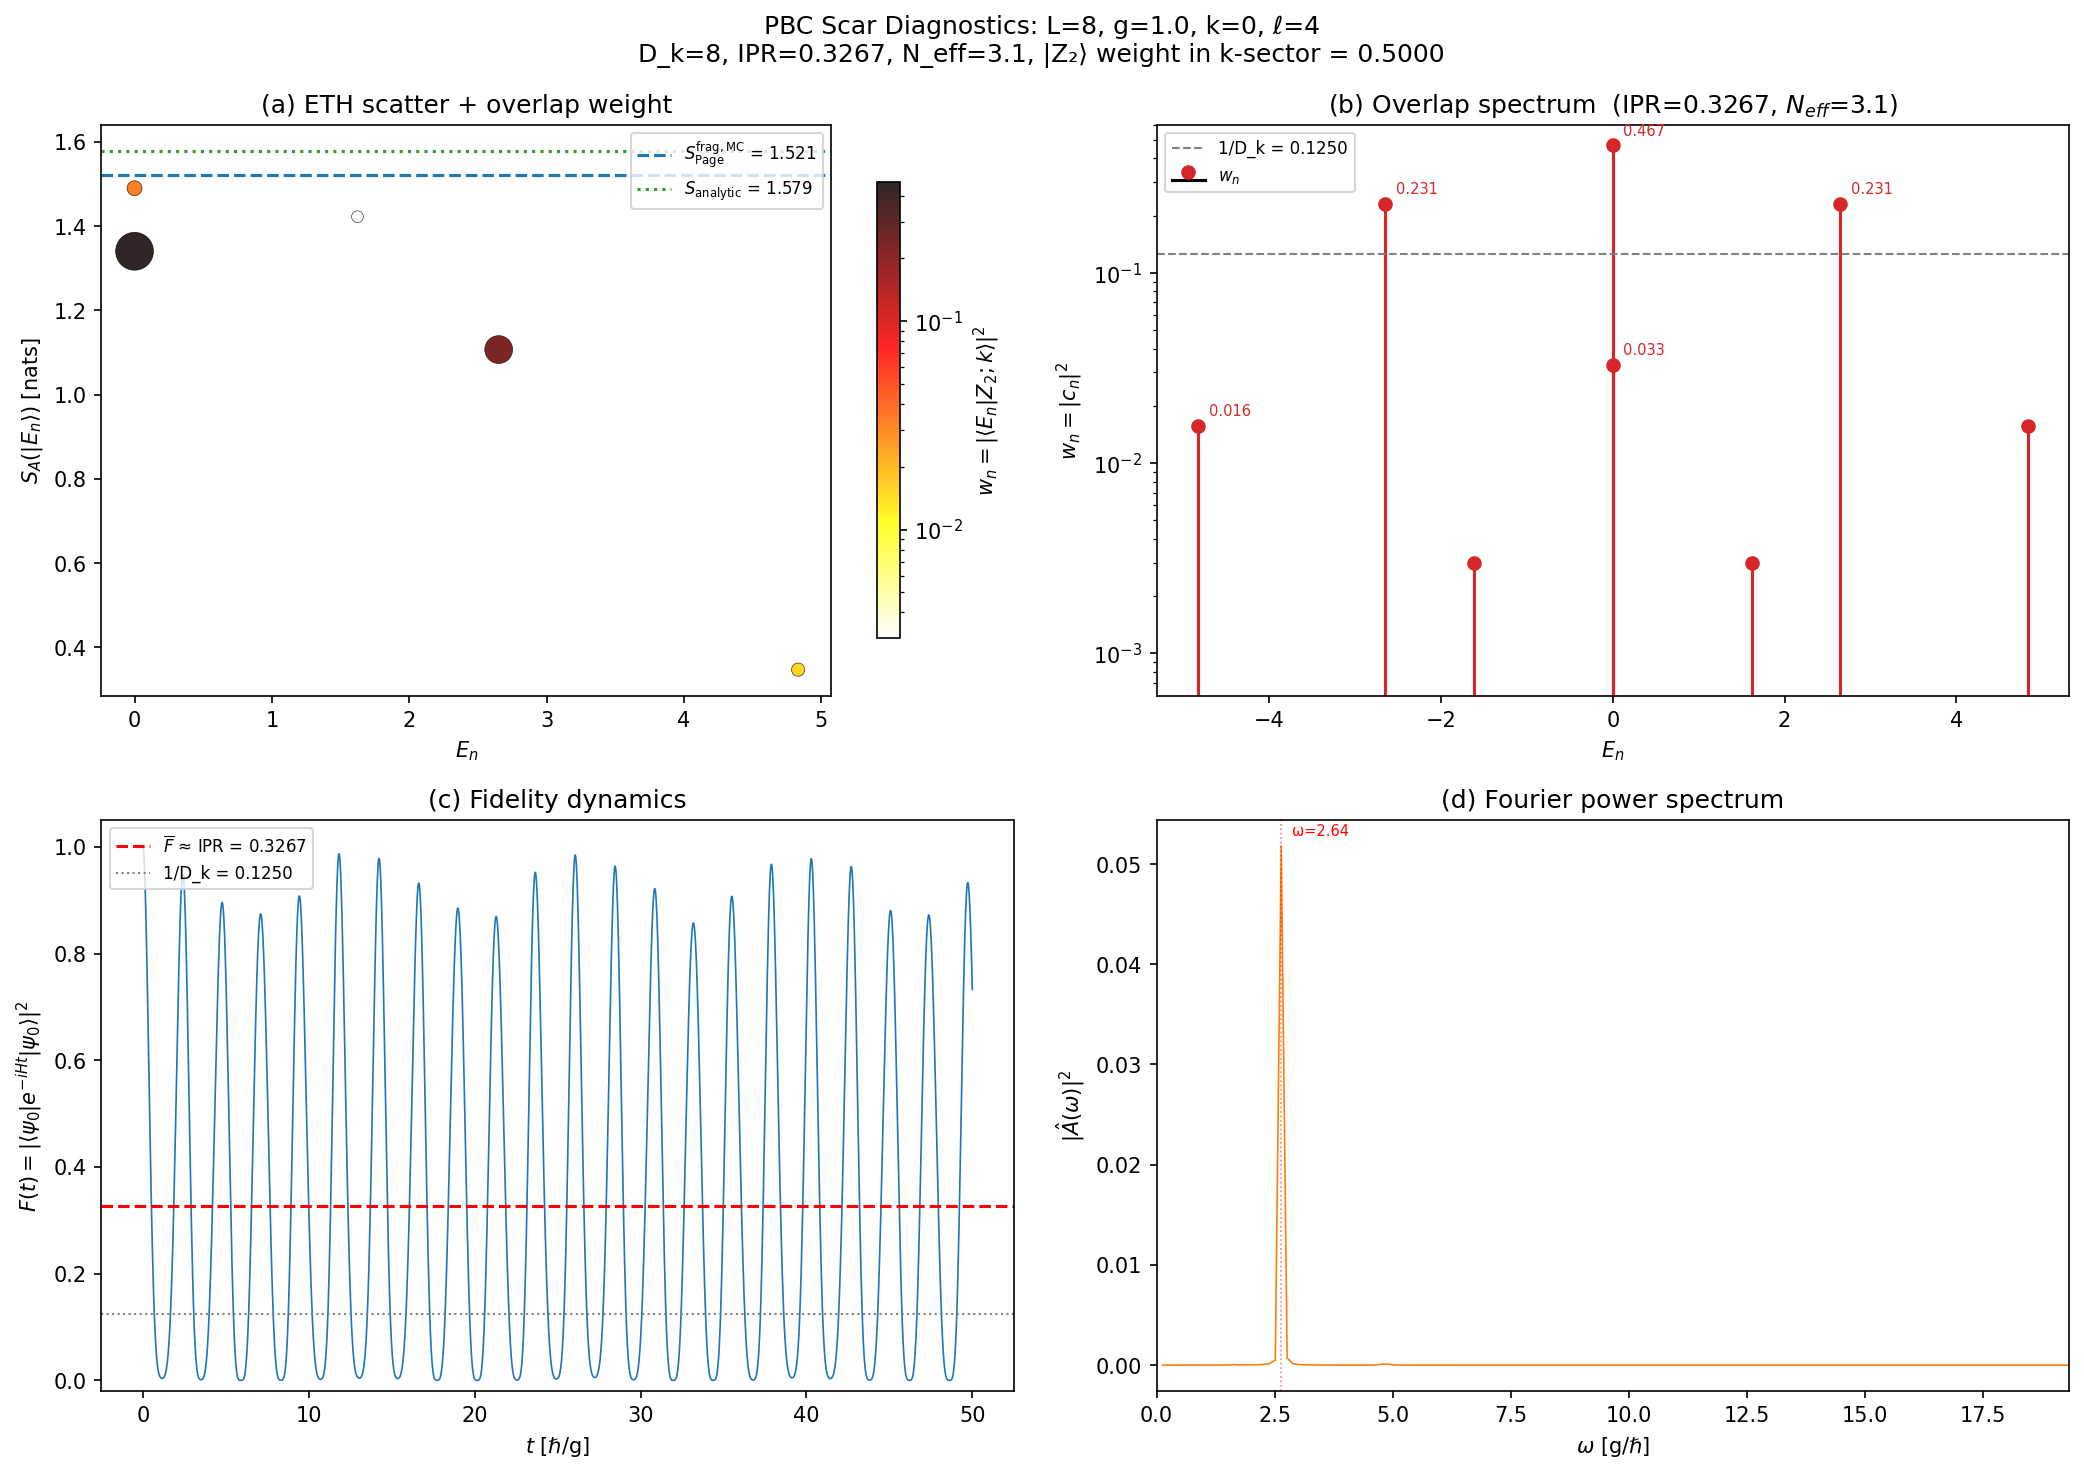

  Saved plot: prompt3_L8_k0.png

SUMMARY
  L=8, g=1.0, k=0, ℓ=4
  D_k = 8
  S_Page^(frag,MC) = 1.5211
  IPR = 0.326720, N_eff = 3.1 (D_k/2 = 4.0)
  Top w: 0.4670 at E = 0.0000
  F_avg(late) = 0.364309
  Scar candidates: 0
  Wall time: 2.69 s


############################################################
# SCAR DIAGNOSTIC — L = 12
############################################################

SCAR DIAGNOSTIC PIPELINE
L = 12, g = 1.0, ℓ = 6, k = 0

ANALYTIC PREDICTIONS  (L = 12, PBC)
  Luc(12)        = 322
  Δ_12            = 2   (L mod 6 = 0)
  N_A (even N↑)  = 162
  N_B (odd  N↑)  = 160
  dim ker(H) ≥   2
  Fragment frac  = 322/4096 = 0.078613
  ✓ Basis verified: D = 322 = Luc(12)
  ✓ Sublattices: N_A = 162, N_B = 160, Δ = 2

  H_eff verification (D = 322):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 2.40e-14  ✓
    Zero modes: 22 (≥ 2 required)  ✓

  Orbits: 31
  k=0 block: D_k = 31
  E range: [-7.2429, 7.2429]

  MC Fragment Page Value (D=322, ℓ=

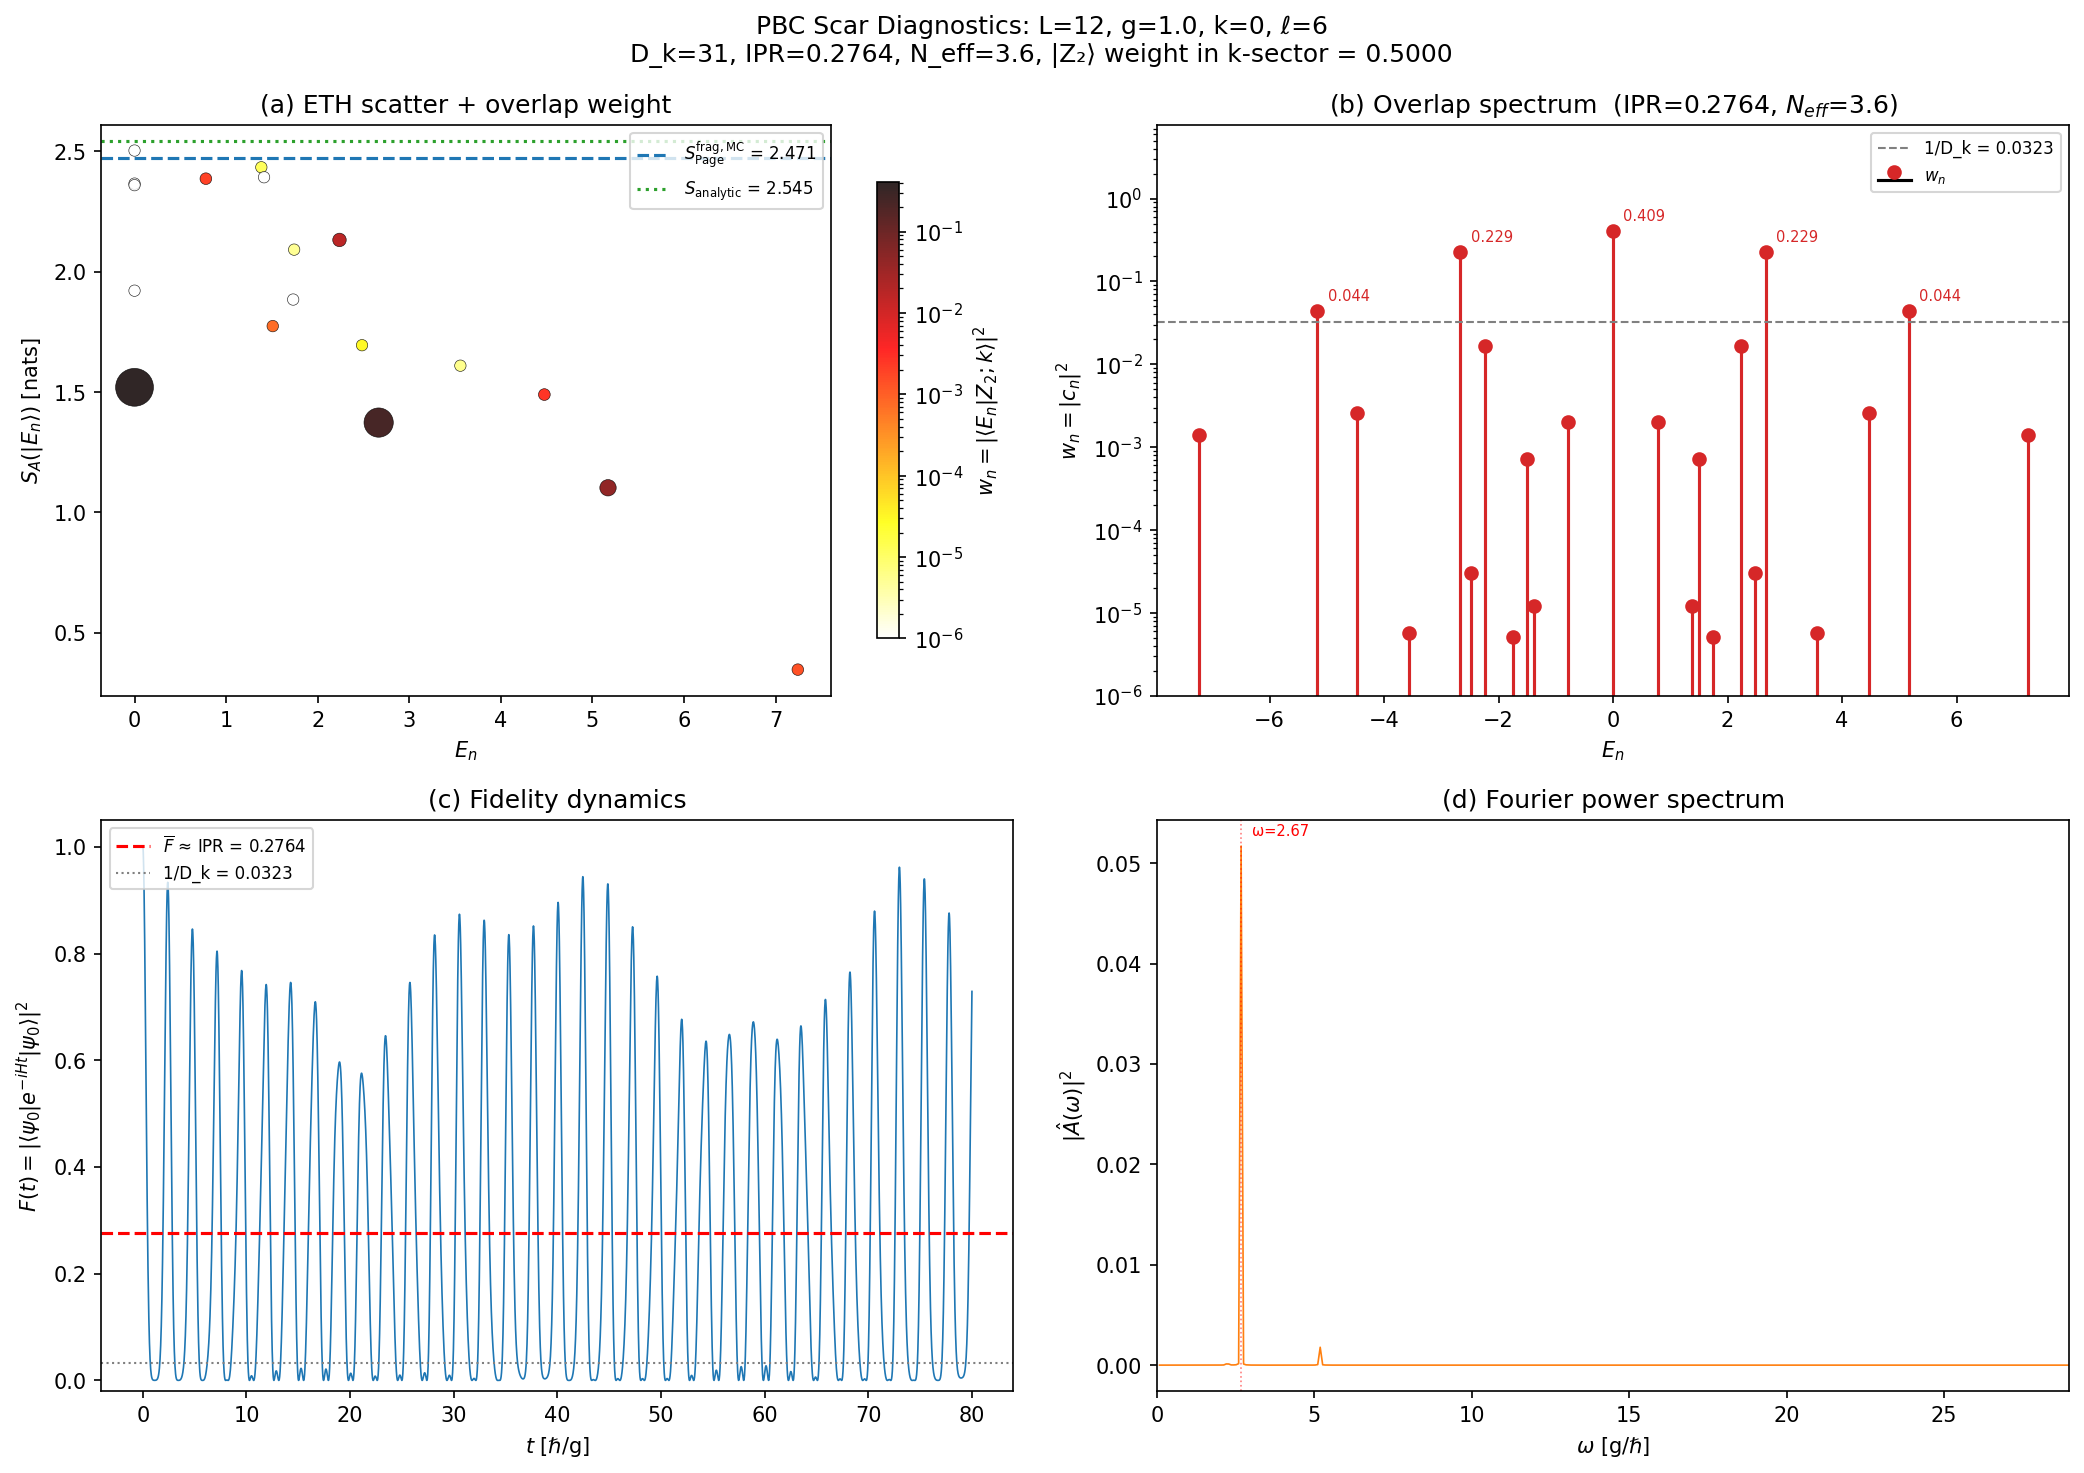

  Saved plot: prompt3_L12_k0.png

SUMMARY
  L=12, g=1.0, k=0, ℓ=6
  D_k = 31
  S_Page^(frag,MC) = 2.4709
  IPR = 0.276355, N_eff = 3.6 (D_k/2 = 15.5)
  Top w: 0.4093 at E = -0.0000
  F_avg(late) = 0.276236
  Scar candidates: 3
  Wall time: 3.62 s


COMPARISON TABLE
            D_k        IPR    N_eff    D_k/2    Top w   Scars?
     L=8      8   0.326720      3.1      4.0   0.4670        0
    L=12     31   0.276355      3.6     15.5   0.4093        3


In [ ]:
"""
PBC Largest Fragment: Overlap + Fidelity + Combined Plots (Prompt 3)
=====================================================================

Self-contained for Google Colab. Reuses ALL Prompt 1+2 definitions.

New physics (Prompt 3):
  • Z₂ CDW probe state |Z₂⟩ = |1010...10⟩ (PXP-style)
  • Translation-symmetrised probe |Z₂; k⟩ ∝ Σ_r e^{-ikr} T^r|Z₂⟩
  • Overlap weights w_n = |⟨E_n|Z₂;k⟩|²
  • IPR = Σ w_n², N_eff = 1/IPR
  • Fidelity F(t) = |Σ_n w_n e^{-iE_n t}|²
  • Combined ETH scatter coloured by overlap weight
  • Fourier spectrum of A(t) for tower detection

Testbench: L=8, J_0=10, g=1.0, k=0, ℓ=L/2.
"""

import numpy as np
from scipy import sparse
import time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# ================================================================
# ================================================================
#
#   PROMPT 3 — NEW CODE BELOW
#
# ================================================================
# ================================================================


# ============================================================
# §P3.1  PROBE STATE CONSTRUCTION
# ============================================================

def build_Z2_state(L):
    """
    Build the Z₂ CDW probe state |Z₂⟩ = |1010...10⟩ on a ring.

    For even L, this is the max-density state with no adjacent ups.
    Convention: bit i = 1 means site i is ↑.

    |Z₂⟩:  sites 0,2,4,...,L-2 are ↑; sites 1,3,...,L-1 are ↓.

    Also builds the translated partner |Z₂'⟩ = T|Z₂⟩ = |0101...01⟩.

    Parameters
    ----------
    L : int — must be even

    Returns
    -------
    s_Z2 : int — state integer for |1010...10⟩
    s_Z2p : int — state integer for |0101...01⟩
    """
    assert L % 2 == 0, f"Z₂ CDW requires even L, got {L}"
    # bit 0 = ↑, bit 1 = ↓, bit 2 = ↑, ... → 0b...0101 (bits 0,2,4,... set)
    s_Z2 = 0
    for i in range(0, L, 2):
        s_Z2 |= (1 << i)
    # The translated partner: bits 1,3,5,... set
    s_Z2p = 0
    for i in range(1, L, 2):
        s_Z2p |= (1 << i)
    return s_Z2, s_Z2p


def verify_Z2_in_fragment(s_Z2, L, basis):
    """Verify |Z₂⟩ is in the largest fragment (no adjacent ups)."""
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    assert s_Z2 in state_to_idx, \
        f"|Z₂⟩ = {s_Z2} ({bin(s_Z2)}) not in fragment!"
    # Check no adjacent ups
    for i in range(L):
        assert not ((s_Z2 >> i) & 1 and (s_Z2 >> ((i+1)%L)) & 1), \
            f"|Z₂⟩ has adjacent ups at sites {i},{(i+1)%L}!"
    n_up = count_up_spins(s_Z2, L)
    print(f"  ✓ |Z₂⟩ = |{format(s_Z2, f'0{L}b')}⟩ in fragment, N↑ = {n_up}")
    return state_to_idx[s_Z2]
# ============================================================
# MISSING FROM PROMPT 2 — add to your Prompt 1/2 block
# ============================================================

def count_up_spins(state_idx, L):
    """Count number of ↑ spins (set bits) in a computational basis state."""
    return bin(state_idx).count('1')


def constrained_page_baseline(L, ell):
    """
    Analytic Page-value estimate for the no-adjacent-ups (Fibonacci)
    constrained Hilbert space on a PBC ring.

    Bipartition: A = [0, ..., ℓ-1],  B = [ℓ, ..., L-1].

    Approximation (OBC subsystem dimensions):
        d_A = F(ℓ + 2),   d_B = F(L - ℓ + 2)

    where F(n) is the n-th Fibonacci number (F_0=0, F_1=1, F_2=1, ...).

    The number of valid no-adjacent-ups configurations on an open
    segment of length m is F(m+2), giving the effective Hilbert
    space dimension for each subsystem.

    Then the Page formula:
        S_Page ≈ ln(d_min) − d_min / (2 · d_max)

    where d_min = min(d_A, d_B), d_max = max(d_A, d_B).

    Parameters
    ----------
    L : int — ring size (even)
    ell : int — subsystem A length

    Returns
    -------
    S_page : float — analytic Page estimate (nats)
    """
    def _fib(n):
        a, b = 0, 1
        for _ in range(n):
            a, b = b, a + b
        return a

    d_A = _fib(ell + 2)
    d_B = _fib(L - ell + 2)
    d_min = min(d_A, d_B)
    d_max = max(d_A, d_B)
    return np.log(d_min) - d_min / (2.0 * d_max)

def project_to_k_block(s_probe, L, basis, orbits, compatible, k_index):
    """
    Project a computational basis state into a momentum-k block.

    |ψ₀; k⟩ ∝ Π_k |ψ₀⟩ = Σ_r e^{-ikr} T^r|ψ₀⟩  (then normalise)

    The result is expressed as a D_k-dimensional vector in the
    momentum block basis (orbit basis).

    Parameters
    ----------
    s_probe : int — state integer of the probe state
    L : int
    basis : ndarray
    orbits : list of lists
    compatible : list of orbit indices for this k
    k_index : int

    Returns
    -------
    psi0_k : ndarray (D_k,), complex128 — normalised probe in k-block
    norm_sq : float — ||Π_k|ψ₀⟩||² (weight in this k-sector)
    """
    k = 2.0 * np.pi * k_index / L
    D = len(basis)
    state_to_idx = {int(s): i for i, s in enumerate(basis)}

    # Pre-compute orbit info
    orbit_id_arr = np.empty(D, dtype=np.int64)
    offset_arr = np.empty(D, dtype=np.int64)
    for alpha, orbit in enumerate(orbits):
        for off, idx in enumerate(orbit):
            orbit_id_arr[idx] = alpha
            offset_arr[idx] = off

    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible)}
    D_k = len(compatible)

    # The probe state in the fragment basis is a delta function
    probe_idx = state_to_idx.get(s_probe)
    assert probe_idx is not None, f"Probe state {s_probe} not in fragment"

    # Which orbit does the probe belong to?
    probe_orbit = orbit_id_arr[probe_idx]

    # The momentum-projected basis state for orbit α is:
    #   |α, k⟩ = (1/√p_α) Σ_{r=0}^{p_α-1} e^{-ikr} |T^r s_α⟩
    #
    # So: ⟨α,k | s_probe⟩ = (1/√p_α) e^{+ik·r_probe}
    #   where r_probe is the translation offset of s_probe within its orbit.
    #
    # Only orbit α = probe_orbit contributes.

    psi0_k = np.zeros(D_k, dtype=np.complex128)

    if probe_orbit in orbit_to_local:
        loc = orbit_to_local[probe_orbit]
        r_probe = offset_arr[probe_idx]
        p = len(orbits[probe_orbit])
        # ⟨α,k | ψ₀⟩ = (1/√p) e^{+ikr}
        psi0_k[loc] = np.exp(1j * k * r_probe) / np.sqrt(p)

    norm_sq = float(np.real(np.vdot(psi0_k, psi0_k)))

    if norm_sq > 1e-15:
        psi0_k /= np.sqrt(norm_sq)
    else:
        print(f"  ⚠ Probe state has zero projection into k={k_index}!")

    return psi0_k, norm_sq


def build_symmetrised_Z2_probe(L, basis, orbits, compatible, k_index):
    """
    Build the translation-symmetrised Z₂ probe:
      |Z₂; k⟩ ∝ Σ_r e^{-ikr} T^r |Z₂⟩

    Since |Z₂⟩ = |1010...⟩ has a 2-element orbit under T
    (the orbit is {|Z₂⟩, |Z₂'⟩}), the k-projection is:

    For k=0:  |Z₂;0⟩ ∝ |Z₂⟩ + |Z₂'⟩   (symmetric)
    For k=π:  |Z₂;π⟩ ∝ |Z₂⟩ - |Z₂'⟩   (antisymmetric)
    Other k:  depends on orbit compatibility.

    Returns
    -------
    psi0_k : ndarray (D_k,), complex128 — normalised
    norm_sq : float — projection weight
    Z2_info : dict — diagnostic info
    """
    s_Z2, s_Z2p = build_Z2_state(L)

    # Verify both in fragment
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    assert s_Z2 in state_to_idx and s_Z2p in state_to_idx

    # Project into k-block
    psi0_k, norm_sq = project_to_k_block(
        s_Z2, L, basis, orbits, compatible, k_index
    )

    Z2_info = {
        's_Z2': s_Z2,
        's_Z2p': s_Z2p,
        'N_up': count_up_spins(s_Z2, L),
        'orbit_period': 2,  # Z₂ orbit has period 2 (or L if L=2)
        'norm_sq_in_k': norm_sq,
    }

    return psi0_k, norm_sq, Z2_info


# ============================================================
# §P3.2  OVERLAP DIAGNOSTICS
# ============================================================

def compute_overlaps(evals, evecs_frag, psi0_k, basis, orbits, compatible, k_index, L):
    """
    Compute overlap weights w_n = |⟨E_n|ψ₀;k⟩|².

    Parameters
    ----------
    evals : ndarray (D_k,) — eigenvalues
    evecs_frag : ndarray (D, D_k) — eigenvectors in fragment basis
    psi0_k : ndarray (D_k,) — probe in k-block basis
    ... (remaining for context)

    Returns
    -------
    w : ndarray (D_k,) — overlap weights
    c : ndarray (D_k,), complex128 — overlap amplitudes
    ipr : float — inverse participation ratio
    n_eff : float — effective number of participating eigenstates
    """
    D_k = len(evals)
    k = 2.0 * np.pi * k_index / L
    D = len(basis)

    # Reconstruct psi0 in the fragment basis from the k-block vector
    # |ψ₀;k⟩ = Σ_a (psi0_k)_a |α_a, k⟩
    #         = Σ_a (psi0_k)_a (1/√p_a) Σ_r e^{-ikr} |T^r s_{α_a}⟩

    orbit_id_arr = np.empty(D, dtype=np.int64)
    offset_arr = np.empty(D, dtype=np.int64)
    for alpha, orbit in enumerate(orbits):
        for off, idx in enumerate(orbit):
            orbit_id_arr[idx] = alpha; offset_arr[idx] = off
    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible)}

    psi0_frag = np.zeros(D, dtype=np.complex128)
    for idx in range(D):
        alpha = orbit_id_arr[idx]
        if alpha not in orbit_to_local: continue
        loc = orbit_to_local[alpha]; r = offset_arr[idx]
        p = len(orbits[alpha])
        psi0_frag[idx] = psi0_k[loc] * np.exp(-1j * k * r) / np.sqrt(p)

    # Overlap amplitudes c_n = ⟨E_n | ψ₀;k⟩
    c = evecs_frag.conj().T @ psi0_frag

    w = np.abs(c)**2

    # Verify: Σ w_n = 1
    w_sum = np.sum(w)

    ipr = np.sum(w**2)
    n_eff = 1.0 / ipr if ipr > 0 else np.inf

    return w, c, ipr, n_eff, w_sum


# ============================================================
# §P3.3  FIDELITY DYNAMICS
# ============================================================

def compute_fidelity(evals, w, t_array, hbar=1.0):
    """
    Compute fidelity F(t) = |A(t)|² where A(t) = Σ_n w_n e^{-iE_n t/ℏ}.

    Parameters
    ----------
    evals : ndarray (D_k,)
    w : ndarray (D_k,) — overlap weights (w_n = |c_n|²)
    t_array : ndarray — time points
    hbar : float

    Returns
    -------
    F : ndarray — fidelity at each time
    A : ndarray, complex128 — Loschmidt amplitude
    """
    # A(t) = Σ_n w_n exp(-i E_n t / ℏ)
    # Vectorised: phases shape (D_k, n_t)
    phases = np.exp(-1j * np.outer(evals, t_array) / hbar)  # (D_k, n_t)
    A = w @ phases  # (n_t,)
    F = np.abs(A)**2
    return F, A


def compute_fourier_spectrum(A, t_array):
    """
    Compute Fourier spectrum of Loschmidt amplitude A(t).

    Returns frequencies and |Â(ω)|² (power spectrum).
    """
    dt = t_array[1] - t_array[0]
    n = len(t_array)
    A_fft = np.fft.fft(A)
    freqs = np.fft.fftfreq(n, d=dt) * 2 * np.pi  # angular frequency
    power = np.abs(A_fft)**2 / n**2

    # Keep positive frequencies only
    pos = freqs > 0
    return freqs[pos], power[pos]


# ============================================================
# §P3.4  VERIFICATION GATES
# ============================================================

def verify_overlaps(w, c, evals, psi0_k, D_k, verbose=True):
    """Gate checks for overlap computation."""
    if verbose:
        print(f"\n  Overlap verification:")

    # 1. Σ w_n = 1
    w_sum = np.sum(w)
    ok1 = abs(w_sum - 1.0) < 1e-10
    if verbose:
        print(f"    Σ w_n = {w_sum:.12f}  {'✓' if ok1 else '✗'}")

    # 2. All w_n ≥ 0
    ok2 = np.all(w >= -1e-15)
    if verbose:
        print(f"    All w_n ≥ 0: {'✓' if ok2 else '✗'}")

    # 3. IPR and N_eff
    ipr = np.sum(w**2)
    n_eff = 1.0 / ipr
    ipr_random = 2.0 / D_k  # GOE baseline
    if verbose:
        print(f"    IPR = {ipr:.6f},  N_eff = {n_eff:.2f}")
        print(f"    IPR_random (GOE) ≈ {ipr_random:.6f}  "
              f"(N_eff_random ≈ {D_k/2:.1f})")
        if ipr > 5 * ipr_random:
            print(f"    ⚠ IPR >> random: probe may concentrate on few states")
        else:
            print(f"    IPR ~ random: probe looks generic in this block")

    # 4. Chiral symmetry: w(E) should roughly equal w(-E)
    # (only exact if probe is parity-even under C)
    idx_sort = np.argsort(evals)
    E_s = evals[idx_sort]; w_s = w[idx_sort]
    pos = E_s > 1e-10; neg = E_s < -1e-10
    if np.sum(pos) > 0 and np.sum(neg) > 0:
        w_pos = w_s[pos]; w_neg = w_s[neg][::-1]
        n_chk = min(len(w_pos), len(w_neg))
        chiral_err = np.max(np.abs(w_pos[:n_chk] - w_neg[:n_chk]))
        if verbose:
            print(f"    Chiral w(E)=w(-E) err: {chiral_err:.2e}  "
                  f"{'✓' if chiral_err < 1e-8 else '(not chiral-even probe)'}")

    return ok1 and ok2


# ============================================================
# §P3.5  COMBINED PLOTTING
# ============================================================

def make_all_plots(evals, entropies, w, F_t, t_array, A_t,
                   S_page_MC, S_analytic, L, g, ell, k_index,
                   D_k, ipr, n_eff, Z2_info, save_prefix="prompt3"):
    """
    Generate the four-panel diagnostic figure.

    Panel (a): ETH scatter S_A(E) coloured by overlap w_n
    Panel (b): Overlap weights w_n vs E_n
    Panel (c): Fidelity F(t)
    Panel (d): Fourier power spectrum of A(t)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"PBC Scar Diagnostics: L={L}, g={g}, k={k_index}, ℓ={ell}\n"
        f"D_k={D_k}, IPR={ipr:.4f}, N_eff={n_eff:.1f}, "
        f"|Z₂⟩ weight in k-sector = {Z2_info['norm_sq_in_k']:.4f}",
        fontsize=12
    )

    # ─── Panel (a): ETH scatter coloured by w_n ───
    ax = axes[0, 0]
    # Use E ≥ 0 (chiral fold)
    pos_mask = evals >= -1e-12
    E_pos = evals[pos_mask]; S_pos = entropies[pos_mask]; w_pos = w[pos_mask]

    # Colour by log(w_n) for visibility
    w_plot = np.clip(w_pos, 1e-10, None)
    sc = ax.scatter(E_pos, S_pos, c=w_plot, cmap='hot_r',
                    norm=LogNorm(vmin=max(w_plot.min(), 1e-6), vmax=w_plot.max()),
                    s=30 + 300 * w_pos / max(w_pos.max(), 1e-15),
                    edgecolors='k', linewidths=0.3, alpha=0.85, zorder=3)
    ax.axhline(S_page_MC, color='C0', ls='--', lw=1.5,
               label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag,MC}}}}$ = {S_page_MC:.3f}')
    ax.axhline(S_analytic, color='C2', ls=':', lw=1.5,
               label=f'$S_{{\\mathrm{{analytic}}}}$ = {S_analytic:.3f}')
    ax.set_xlabel('$E_n$')
    ax.set_ylabel('$S_A(|E_n\\rangle)$ [nats]')
    ax.set_title('(a) ETH scatter + overlap weight')
    ax.legend(fontsize=8, loc='upper right')
    plt.colorbar(sc, ax=ax, label='$w_n = |\\langle E_n|Z_2;k\\rangle|^2$',
                 shrink=0.8)

    # ─── Panel (b): Overlap weights vs E ───
    ax = axes[0, 1]
    ax.stem(evals, w, linefmt='C3-', markerfmt='C3o', basefmt='k-', label='$w_n$')
    ax.axhline(1.0/D_k, color='gray', ls='--', lw=1,
               label=f'1/D_k = {1.0/D_k:.4f}')

    # Mark top-5 weights
    top5_idx = np.argsort(w)[-5:][::-1]
    for rank, idx in enumerate(top5_idx):
        ax.annotate(f'{w[idx]:.3f}', (evals[idx], w[idx]),
                    textcoords="offset points", xytext=(5, 5),
                    fontsize=7, color='C3')

    ax.set_xlabel('$E_n$')
    ax.set_ylabel('$w_n = |c_n|^2$')
    ax.set_title(f'(b) Overlap spectrum  (IPR={ipr:.4f}, $N_{{eff}}$={n_eff:.1f})')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    ax.set_ylim(bottom=max(1e-6, w[w>0].min()/5))

    # ─── Panel (c): Fidelity F(t) ───
    ax = axes[1, 0]
    ax.plot(t_array, F_t, 'C0-', lw=0.8)
    ax.axhline(ipr, color='r', ls='--', lw=1.5,
               label=f'$\\overline{{F}}$ ≈ IPR = {ipr:.4f}')
    ax.axhline(1.0/D_k, color='gray', ls=':', lw=1,
               label=f'1/D_k = {1.0/D_k:.4f}')
    ax.set_xlabel('$t$ [ℏ/g]')
    ax.set_ylabel('$F(t) = |\\langle\\psi_0|e^{-iHt}|\\psi_0\\rangle|^2$')
    ax.set_title('(c) Fidelity dynamics')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.02, min(1.05, max(F_t.max()*1.1, 0.1)))

    # ─── Panel (d): Fourier spectrum ───
    ax = axes[1, 1]
    freqs, power = compute_fourier_spectrum(A_t, t_array)
    ax.plot(freqs, power, 'C1-', lw=0.8)
    ax.set_xlabel('$\\omega$ [g/ℏ]')
    ax.set_ylabel('$|\\hat{A}(\\omega)|^2$')
    ax.set_title('(d) Fourier power spectrum')

    # Mark dominant peaks
    if len(power) > 5:
        peak_idx = np.argsort(power)[-3:][::-1]
        for pi in peak_idx:
            if power[pi] > 0.1 * power.max():
                ax.axvline(freqs[pi], color='r', ls=':', lw=0.8, alpha=0.5)
                ax.annotate(f'ω={freqs[pi]:.2f}', (freqs[pi], power[pi]),
                            textcoords="offset points", xytext=(5, 5),
                            fontsize=7, color='r')

    # Limit frequency range to something physical
    E_bandwidth = evals.max() - evals.min()
    ax.set_xlim(0, min(2 * E_bandwidth, freqs.max()))

    plt.tight_layout()
    fpath = f'{save_prefix}_L{L}_k{k_index}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()

    from IPython.display import display, Image
    display(Image(filename=fpath))
    print(f"  Saved plot: {fpath}")
    return fpath



# ============================================================
# §P3.6  FULL PIPELINE
# ============================================================

def run_scar_diagnostic(L, g, ell=None, k_index=0, n_MC=2000,
                        t_max=50.0, n_t=2000, seed=42, verbose=True):
    """
    Full scar diagnostic pipeline for PBC largest fragment.

    Steps:
      1-4: Same as Prompt 2 (basis, H_eff, orbits, eigenstates)
      5: MC fragment Page value
      6: Build Z₂ probe, project into k-block
      7: Compute overlaps w_n, IPR, N_eff
      8: Compute fidelity F(t)
      9: Verification gates
      10: Generate four-panel plot

    Returns dict with all computed quantities.
    """
    if ell is None:
        ell = L // 2

    t0 = time.perf_counter()

    print(f"\n{'='*60}")
    print(f"SCAR DIAGNOSTIC PIPELINE")
    print(f"L = {L}, g = {g}, ℓ = {ell}, k = {k_index}")
    print(f"{'='*60}")

    # ─── Steps 1-2: Analytics + Basis ───
    D_pred, dL, NA, NB = analytic_check(L)
    basis = enumerate_pbc_no_adjacent_up(L)
    verify_basis(L, basis)
    D = len(basis)

    # ─── Step 3: H_eff ───
    H = build_Heff_fragment(L, g, basis)
    evals_full = verify_Heff(H, L, basis)

    # ─── Step 4: Translation orbits + k-block diag ───
    orbits, orbit_of, reps = compute_translation_orbits(basis, L)
    print(f"\n  Orbits: {len(orbits)}")

    evals, evecs_frag, compatible = diagonalise_k_block(
        L, g, basis, orbits, k_index
    )
    D_k = len(evals)
    print(f"  k={k_index} block: D_k = {D_k}")
    print(f"  E range: [{evals[0]:.4f}, {evals[-1]:.4f}]")

    # ─── Step 5: Eigenstate entropies + MC Page ───
    entropies = compute_eigenstate_entropies(evecs_frag, basis, L, ell)
    S_page_MC, S_std_MC, S_sem_MC = compute_fragment_page_MC(
        basis, L, ell, n_samples=n_MC, seed=seed, verbose=verbose
    )
    S_analytic = constrained_page_baseline(L, ell)

    print(f"\n  S_Page^(frag,MC) = {S_page_MC:.4f} ± {S_sem_MC:.4f}")
    print(f"  S_analytic       = {S_analytic:.4f}")

    # ─── Step 6: Z₂ probe state ───
    print(f"\n  Building Z₂ probe state...")
    s_Z2, s_Z2p = build_Z2_state(L)
    verify_Z2_in_fragment(s_Z2, L, basis)
    verify_Z2_in_fragment(s_Z2p, L, basis)

    psi0_k, norm_sq, Z2_info = build_symmetrised_Z2_probe(
        L, basis, orbits, compatible, k_index
    )
    print(f"  ||Π_k|Z₂⟩||² = {norm_sq:.6f}")

    if norm_sq < 1e-10:
        print(f"  ⚠ Z₂ has zero weight in k={k_index}! Try k=0 or k=π.")
        return None

    # ─── Step 7: Overlaps ───
    print(f"\n  Computing overlaps with |Z₂;k⟩...")
    w, c, ipr, n_eff, w_sum = compute_overlaps(
        evals, evecs_frag, psi0_k, basis, orbits, compatible, k_index, L
    )
    verify_overlaps(w, c, evals, psi0_k, D_k, verbose=verbose)

    # Top weights
    top_idx = np.argsort(w)[::-1]
    print(f"\n  Top-5 overlap weights:")
    print(f"  {'Rank':<6} {'E_n':>10} {'w_n':>10} {'S_A':>10}")
    for rank in range(min(5, D_k)):
        n = top_idx[rank]
        print(f"  {rank+1:<6} {evals[n]:>10.4f} {w[n]:>10.6f} {entropies[n]:>10.4f}")

    # ─── "Scar reality check" ───
    print(f"\n  SCAR REALITY CHECK:")
    # Do the top-overlap states have below-average entanglement?
    S_mid_mask = np.abs(evals) < 0.3 * np.max(np.abs(evals))
    if np.sum(S_mid_mask) > 0:
        S_band_mean = np.mean(entropies[S_mid_mask])
        S_band_std = np.std(entropies[S_mid_mask])
    else:
        S_band_mean = S_page_MC
        S_band_std = S_std_MC

    n_check = min(5, D_k)
    scar_candidates = 0
    for rank in range(n_check):
        n = top_idx[rank]
        below_band = entropies[n] < S_band_mean - 2*S_band_std
        if below_band and w[n] > 3.0/D_k:
            scar_candidates += 1
            print(f"    ★ E={evals[n]:.4f}: w={w[n]:.4f}, "
                  f"S_A={entropies[n]:.4f} << {S_band_mean:.4f} (band mean)")
    if scar_candidates == 0:
        print(f"    No scar candidates: top-overlap states are within ETH band")
    else:
        print(f"    {scar_candidates} potential scar candidate(s) found!")

    # ─── Step 8: Fidelity ───
    print(f"\n  Computing fidelity F(t)...")
    t_array = np.linspace(0, t_max, n_t)
    F_t, A_t = compute_fidelity(evals, w, t_array, hbar=1.0)

    # Check F(0) = 1
    print(f"    F(0) = {F_t[0]:.10f}  {'✓' if abs(F_t[0]-1.0)<1e-10 else '✗'}")
    print(f"    F_avg (late) ≈ {np.mean(F_t[n_t//2:]):.6f}")
    print(f"    IPR = {ipr:.6f} (should ≈ F_avg)")

    # Detect revival peaks
    F_late = F_t[n_t//10:]  # skip initial transient
    t_late = t_array[n_t//10:]
    F_threshold = 3 * ipr  # revival = F exceeds 3× long-time average
    revival_mask = F_late > F_threshold
    if np.any(revival_mask):
        # Find first revival
        idx_first = np.argmax(revival_mask)
        t_rev = t_late[idx_first]
        F_rev = F_late[idx_first]
        print(f"    Revival detected: F({t_rev:.2f}) = {F_rev:.4f} "
              f"(threshold = {F_threshold:.4f})")

        # Estimate revival time from top energy spacings
        top2 = top_idx[:2]
        if len(top2) == 2:
            dE = abs(evals[top2[0]] - evals[top2[1]])
            if dE > 1e-10:
                T_rev_est = 2 * np.pi / dE
                print(f"    Estimated T_rev from top-2 spacing: "
                      f"ΔE = {dE:.4f}, T_rev ≈ {T_rev_est:.2f}")
    else:
        print(f"    No significant revivals detected above {F_threshold:.4f}")

    # ─── Step 9: Plots ───
    print(f"\n  Generating plots...")
    fpath = make_all_plots(
        evals, entropies, w, F_t, t_array, A_t,
        S_page_MC, S_analytic, L, g, ell, k_index,
        D_k, ipr, n_eff, Z2_info
    )

    wall = time.perf_counter() - t0

    # ─── Summary ───
    print(f"\n{'='*60}")
    print(f"SUMMARY")
    print(f"{'='*60}")
    print(f"  L={L}, g={g}, k={k_index}, ℓ={ell}")
    print(f"  D_k = {D_k}")
    print(f"  S_Page^(frag,MC) = {S_page_MC:.4f}")
    print(f"  IPR = {ipr:.6f}, N_eff = {n_eff:.1f} (D_k/2 = {D_k/2:.1f})")
    print(f"  Top w: {w[top_idx[0]]:.4f} at E = {evals[top_idx[0]]:.4f}")
    print(f"  F_avg(late) = {np.mean(F_t[n_t//2:]):.6f}")
    print(f"  Scar candidates: {scar_candidates}")
    print(f"  Wall time: {wall:.2f} s")

    return {
        'L': L, 'g': g, 'ell': ell, 'k_index': k_index,
        'D': D, 'D_k': D_k, 'basis': basis,
        'evals': evals, 'entropies': entropies,
        'evecs_frag': evecs_frag,
        'w': w, 'c': c, 'ipr': ipr, 'n_eff': n_eff,
        'F_t': F_t, 'A_t': A_t, 't_array': t_array,
        'S_page_MC': S_page_MC, 'S_analytic': S_analytic,
        'Z2_info': Z2_info,
        'scar_candidates': scar_candidates,
        'plot_path': fpath,
        'wall_time': wall,
    }


# ============================================================
# §P3.7  TESTBENCH
# ============================================================

if __name__ == "__main__":
    L = 8
    J_0 = 10.0
    g = 1.0

    print(f"{'#'*60}")
    print(f"# SCAR DIAGNOSTIC — L = {L}")
    print(f"{'#'*60}")
    print(f"J_0 = {J_0}, g = {g}, h_0 = {2*J_0}")

    # ── k=0: main diagnostic ──
    results = run_scar_diagnostic(
        L, g, ell=L//2, k_index=0,
        n_MC=2000, t_max=50.0, n_t=2000, seed=42
    )

    # ── L=12 for more meaningful data ──
    print(f"\n\n{'#'*60}")
    print(f"# SCAR DIAGNOSTIC — L = 12")
    print(f"{'#'*60}")

    results_12 = run_scar_diagnostic(
        12, g, ell=6, k_index=0,
        n_MC=2000, t_max=80.0, n_t=4000, seed=42
    )

    # ── Final comparison ──
    print(f"\n\n{'='*60}")
    print(f"COMPARISON TABLE")
    print(f"{'='*60}")
    print(f"{'':>8} {'D_k':>6} {'IPR':>10} {'N_eff':>8} {'D_k/2':>8} "
          f"{'Top w':>8} {'Scars?':>8}")
    for label, r in [("L=8", results), ("L=12", results_12)]:
        if r is None: continue
        top_w = r['w'][np.argmax(r['w'])]
        print(f"{label:>8} {r['D_k']:>6} {r['ipr']:>10.6f} "
              f"{r['n_eff']:>8.1f} {r['D_k']/2:>8.1f} "
              f"{top_w:>8.4f} {r['scar_candidates']:>8}")

## Actual PXP Z2 states

### Results

In [ ]:
"""
PXP Z₂ REVIVAL DYNAMICS — RESULTS CODE
========================================
H_PXP = Σ_i P_{i-1} σ^x_i P_{i+1}   (PBC, g=1)

|Z₂⟩ = |↑↓↑↓...⟩ has period-2 orbit under T.
Projects into k = 0 and k = π = L/2 with equal weight 1/2.

Full fidelity:
    F(t) = |w₀ A₀(t) + w_π A_π(t)|²

where A_k(t) = Σ_n |⟨E_n^(k)|Z₂;k⟩|² exp(-i E_n^(k) t)
      w_k  = ||Π_k |Z₂⟩||²

Convention: site i ↔ bit (L-1-i), bit=0 → ↑, bit=1 → ↓.
Reuses all Prompt 1–3 definitions.
"""

import numpy as np
import time

# =============================================================
# §1  ALL PROMPT 1–3 INFRASTRUCTURE (paste above this block)
# =============================================================
# Assumes the following are defined:
#   fib, lucas, delta_L, analytic_check
#   enumerate_pbc_no_adjacent_up, verify_basis
#   build_Heff_fragment, verify_Heff
#   translate_state, compute_translation_orbits
#   build_momentum_block_v2
#   bipartite_entropy_fragment_state, compute_eigenstate_entropies
#   compute_fragment_page_MC
#   build_Z2_state, verify_Z2_in_fragment
#   project_to_k_block, build_symmetrised_Z2_probe
#   compute_overlaps, verify_overlaps
#   diagonalise_k_block
#   count_up_spins  (document 17 version: L - popcount)
# =============================================================


# =============================================================
# §2  MULTI-k FIDELITY ENGINE
# =============================================================

def compute_multi_k_fidelity(k_data_list, t_array):
    """
    Compute full fidelity combining all k-sectors.

    F(t) = |Σ_k  w_k · A_k(t)|²

    where  A_k(t) = Σ_n  w_n^(k) · exp(-i E_n^(k) t)
           w_k    = ||Π_k |Z₂⟩||²   (sector projection weight)
           w_n^(k)= |⟨E_n^(k)|Z₂;k⟩|²  (overlap within sector)

    Parameters
    ----------
    k_data_list : list of dict, each with keys:
        'evals'   : ndarray (D_k,) — eigenvalues in sector k
        'w'       : ndarray (D_k,) — overlap weights within sector
        'w_sector': float — projection weight ||Π_k|Z₂⟩||²
    t_array : ndarray — time grid

    Returns
    -------
    F : ndarray — fidelity F(t)
    A_total : ndarray, complex — total Loschmidt amplitude
    A_per_k : list of ndarray — per-sector amplitudes (before weighting)
    """
    n_t = len(t_array)
    A_total = np.zeros(n_t, dtype=np.complex128)
    A_per_k = []

    for kd in k_data_list:
        evals = kd['evals']
        w = kd['w']
        w_sector = kd['w_sector']

        # A_k(t) = Σ_n w_n exp(-i E_n t)
        phases = np.exp(-1j * np.outer(evals, t_array))  # (D_k, n_t)
        A_k = w @ phases  # (n_t,)
        A_per_k.append(A_k)

        # Weighted contribution to total amplitude
        A_total += w_sector * A_k

    F = np.abs(A_total)**2
    return F, A_total, A_per_k


def find_revivals(F, t_array, ipr_total, prominence_factor=3.0):
    """
    Detect revival peaks in F(t).

    A revival is a local maximum with F > prominence_factor × IPR.

    Returns
    -------
    revival_times : list of float
    revival_heights : list of float
    T_rev : float or None — estimated revival period (median spacing)
    """
    threshold = prominence_factor * ipr_total
    # Skip initial transient (first 5% of time)
    i_start = max(1, len(t_array) // 20)

    revival_times = []
    revival_heights = []

    for i in range(i_start, len(F) - 1):
        if F[i] > F[i-1] and F[i] > F[i+1] and F[i] > threshold:
            revival_times.append(t_array[i])
            revival_heights.append(F[i])

    T_rev = None
    if len(revival_times) >= 2:
        spacings = np.diff(revival_times)
        T_rev = float(np.median(spacings))

    return revival_times, revival_heights, T_rev


# =============================================================
# §3  SINGLE-L ANALYSIS PIPELINE
# =============================================================

def run_Z2_revival_analysis(L, g=1.0, t_max=None, n_t=4000,
                            n_MC=2000, seed=42, verbose=True):
    """
    Full Z₂ revival analysis for PXP model at system size L.

    Steps:
      1. Build constrained basis, verify against Luc(L)
      2. Build H_PXP (= H_eff in fragment basis)
      3. Compute translation orbits
      4. For k = 0 and k = π (= L/2):
         a. Diagonalise H_k
         b. Project |Z₂⟩ into k-sector
         c. Compute overlap weights w_n^(k)
         d. Compute eigenstate entropies
      5. Combine sectors for full fidelity F(t)
      6. Detect revivals, estimate T_rev
      7. Compute Fourier spectrum for tower detection

    Parameters
    ----------
    L : int — chain length (must be even)
    g : float — PXP coupling
    t_max : float — max evolution time (default: 8 revival periods)
    n_t : int — time grid points
    n_MC : int — MC samples for fragment Page value
    seed : int — RNG seed
    verbose : bool

    Returns
    -------
    results : dict with all computed data
    """
    assert L % 2 == 0, f"Need even L for Z₂ state, got {L}"
    if t_max is None:
        t_max = max(60.0, 5.0 * L)  # scale with L

    t0 = time.perf_counter()

    if verbose:
        print(f"\n{'='*70}")
        print(f"PXP Z₂ REVIVAL ANALYSIS: L = {L}, g = {g}")
        print(f"{'='*70}")

    # --- Step 1: Basis ---
    D_pred, dL, NA, NB = analytic_check(L)
    basis = enumerate_pbc_no_adjacent_up(L)
    verify_basis(L, basis)
    D = len(basis)

    # --- Step 2: H_PXP ---
    H = build_Heff_fragment(L, g, basis)
    evals_full = verify_Heff(H, L, basis)

    # --- Step 3: Orbits ---
    orbits, orbit_of, reps = compute_translation_orbits(basis, L)
    if verbose:
        print(f"\n  Translation orbits: {len(orbits)}")

    # --- Step 4: Z₂ state ---
    s_Z2, s_Z2p = build_Z2_state(L)
    verify_Z2_in_fragment(s_Z2, L, basis)

    # The Z₂ orbit has period 2 (or 1 if L=2), compatible with k=0 and k=π
    k_indices = [0, L // 2]
    if verbose:
        print(f"\n  Z₂ orbit period: 2 → projects into k = {k_indices}")

    # --- Step 5: Per-sector analysis ---
    k_data_list = []
    ell = L // 2  # half-chain cut

    for k_idx in k_indices:
        if verbose:
            print(f"\n  --- Sector k = {k_idx} (k = {2*np.pi*k_idx/L:.4f}) ---")

        # Diagonalise
        evals_k, evecs_frag, compatible = diagonalise_k_block(
            L, g, basis, orbits, k_idx
        )
        D_k = len(evals_k)
        if verbose:
            print(f"    D_k = {D_k}")
            print(f"    E range: [{evals_k.min():.4f}, {evals_k.max():.4f}]")

        if D_k == 0:
            if verbose:
                print(f"    (empty sector, skipping)")
            continue

        # Project Z₂ into this k-sector
        psi0_k, norm_sq, Z2_info = build_symmetrised_Z2_probe(
            L, basis, orbits, compatible, k_idx
        )
        if verbose:
            print(f"    ||Π_k|Z₂⟩||² = {norm_sq:.6f}")

        if norm_sq < 1e-12:
            if verbose:
                print(f"    (zero projection, skipping)")
            continue

        # Overlaps
        w, c, ipr, n_eff, w_sum = compute_overlaps(
            evals_k, evecs_frag, psi0_k, basis, orbits,
            compatible, k_idx, L
        )
        if verbose:
            print(f"    IPR = {ipr:.6f}, N_eff = {n_eff:.1f} (D_k/2 = {D_k/2})")
            print(f"    Σw = {w_sum:.10f}")
            top5 = np.argsort(w)[-5:][::-1]
            print(f"    Top-5 overlaps:")
            for rank, n in enumerate(top5):
                print(f"      {rank+1}. E = {evals_k[n]:>8.4f}, "
                      f"w = {w[n]:.6f}")

        # Eigenstate entropies
        entropies = compute_eigenstate_entropies(evecs_frag, basis, L, ell)

        k_data_list.append({
            'k_index': k_idx,
            'evals': evals_k,
            'evecs_frag': evecs_frag,
            'compatible': compatible,
            'D_k': D_k,
            'w': w,
            'c': c,
            'ipr': ipr,
            'n_eff': n_eff,
            'w_sector': norm_sq,
            'entropies': entropies,
        })

    # --- Step 6: Combined fidelity ---
    if verbose:
        print(f"\n  --- Combined fidelity (all k-sectors) ---")

    # Verify sector weights sum to 1
    total_weight = sum(kd['w_sector'] for kd in k_data_list)
    if verbose:
        print(f"    Σ w_k = {total_weight:.10f}  "
              f"{'✓' if abs(total_weight - 1.0) < 1e-8 else '✗'}")

    t_array = np.linspace(0, t_max, n_t)
    F, A_total, A_per_k = compute_multi_k_fidelity(k_data_list, t_array)

    if verbose:
        print(f"    F(0) = {F[0]:.10f}  "
              f"{'✓' if abs(F[0] - 1.0) < 1e-8 else '✗'}")

    # IPR for the full state (combined sectors)
    # IPR_total = Σ_k w_k² · IPR_k  (approximately)
    # More precisely: IPR_total = Σ_{k,n} (w_k · w_n^(k))²
    all_weighted_overlaps = []
    for kd in k_data_list:
        all_weighted_overlaps.extend(kd['w_sector'] * kd['w'])
    all_weighted_overlaps = np.array(all_weighted_overlaps)
    ipr_total = float(np.sum(all_weighted_overlaps**2))
    n_eff_total = 1.0 / ipr_total if ipr_total > 0 else np.inf

    F_late = np.mean(F[n_t//2:])
    if verbose:
        print(f"    IPR_total = {ipr_total:.6f}")
        print(f"    N_eff_total = {n_eff_total:.1f}")
        print(f"    F_avg(late) = {F_late:.6f}")
        print(f"    F_max(late) = {np.max(F[n_t//10:]):.6f}")

    # --- Step 7: Revival detection ---
    rev_times, rev_heights, T_rev = find_revivals(F, t_array, ipr_total)

    if verbose:
        print(f"\n  --- Revival detection ---")
        print(f"    Threshold: {3*ipr_total:.4f} (3 × IPR)")
        print(f"    Revivals found: {len(rev_times)}")
        if T_rev is not None:
            print(f"    Estimated T_rev = {T_rev:.3f}")
            # Compare to analytic estimate T_rev ≈ 2π / ΔE_tower
        if len(rev_times) > 0:
            for i, (t_r, h_r) in enumerate(zip(rev_times[:5], rev_heights[:5])):
                print(f"      Revival {i+1}: t = {t_r:.3f}, F = {h_r:.4f}")

    # --- Step 8: Fourier spectrum ---
    dt = t_array[1] - t_array[0]
    n_fft = len(t_array)
    A_fft = np.fft.fft(A_total)
    freqs = np.fft.fftfreq(n_fft, d=dt) * 2 * np.pi  # angular freq
    power = np.abs(A_fft)**2 / n_fft**2
    pos_freq = freqs > 0
    fourier_freqs = freqs[pos_freq]
    fourier_power = power[pos_freq]

    # Find dominant peaks
    if len(fourier_power) > 10:
        peak_indices = np.argsort(fourier_power)[-10:][::-1]
        dominant_freqs = fourier_freqs[peak_indices]
        dominant_powers = fourier_power[peak_indices]
        if verbose:
            print(f"\n  --- Fourier spectrum (top peaks) ---")
            for i in range(min(5, len(dominant_freqs))):
                print(f"    ω = {dominant_freqs[i]:.4f}, "
                      f"|Â|² = {dominant_powers[i]:.6f}")
    else:
        dominant_freqs = np.array([])
        dominant_powers = np.array([])

    # --- MC Page value ---
    S_page_MC, S_std_MC, S_sem_MC = compute_fragment_page_MC(
        basis, L, ell, n_samples=n_MC, seed=seed, verbose=verbose
    )

    wall = time.perf_counter() - t0

    if verbose:
        print(f"\n  Wall time: {wall:.1f} s")

    return {
        'L': L, 'g': g, 'D': D, 'ell': ell,
        'basis': basis,
        'k_data': k_data_list,
        't_array': t_array, 'F': F, 'A_total': A_total,
        'A_per_k': A_per_k,
        'ipr_total': ipr_total, 'n_eff_total': n_eff_total,
        'F_late_avg': F_late,
        'revival_times': rev_times, 'revival_heights': rev_heights,
        'T_rev': T_rev,
        'fourier_freqs': fourier_freqs, 'fourier_power': fourier_power,
        'dominant_freqs': dominant_freqs, 'dominant_powers': dominant_powers,
        'S_page_MC': S_page_MC, 'S_std_MC': S_std_MC, 'S_sem_MC': S_sem_MC,
        'wall_time': wall,
    }


# =============================================================
# §4  RUN
# =============================================================

if __name__ == "__main__":
    g = 1.0

    print("="*70)
    print("PXP MODEL (PBC) — Z₂ REVIVAL DYNAMICS")
    print("="*70)
    print(f"\nH_PXP = Σ_i P_{{i-1}} σ^x_i P_{{i+1}}")
    print(f"|Z₂⟩ = |↑↓↑↓...⟩ (Néel/CDW state)")
    print(f"Constrained Hilbert space: no adjacent ↑ (PBC)")

    all_results = []
    for L in [8, 12, 14]:
        res = run_Z2_revival_analysis(
            L, g=g,
            t_max=max(80.0, 6.0 * L),
            n_t=6000,
            n_MC=2000 if L <= 16 else 500,
            seed=42, verbose=True
        )
        all_results.append(res)

    # --- Cross-L summary ---
    print(f"\n{'='*70}")
    print("CROSS-SYSTEM-SIZE SUMMARY")
    print(f"{'='*70}")
    print(f"\n  {'L':>3} {'D':>7} {'D_k0':>5} {'D_kπ':>5} "
          f"{'IPR':>10} {'N_eff':>7} {'T_rev':>7} {'F_max':>7} "
          f"{'#rev':>5}")
    print(f"  {'-'*62}")
    for res in all_results:
        L = res['L']
        D_k0 = res['k_data'][0]['D_k'] if len(res['k_data']) > 0 else 0
        D_kpi = res['k_data'][1]['D_k'] if len(res['k_data']) > 1 else 0
        T_rev_s = f"{res['T_rev']:.3f}" if res['T_rev'] else "  —"
        F_max = np.max(res['F'][len(res['F'])//10:])
        print(f"  {L:>3} {res['D']:>7} {D_k0:>5} {D_kpi:>5} "
              f"{res['ipr_total']:>10.6f} {res['n_eff_total']:>7.1f} "
              f"{T_rev_s:>7} {F_max:>7.4f} {len(res['revival_times']):>5}")

    print(f"\n  Key physics:")
    print(f"  • T_rev should be ≈ constant across L (tower spacing is L-independent)")
    print(f"  • F_max(revival) decays with L (scars are measure-zero fraction)")
    print(f"  • N_eff << D_k: Z₂ concentrates on the scar tower")
    print(f"  • Fourier peaks at ω ≈ n·ΔE_tower identify the equally-spaced tower")

PXP MODEL (PBC) — Z₂ REVIVAL DYNAMICS

H_PXP = Σ_i P_{i-1} σ^x_i P_{i+1}
|Z₂⟩ = |↑↓↑↓...⟩ (Néel/CDW state)
Constrained Hilbert space: no adjacent ↑ (PBC)

PXP Z₂ REVIVAL ANALYSIS: L = 8, g = 1.0

ANALYTIC PREDICTIONS  (L = 8, PBC)
  Luc(8)        = 47
  Δ_8            = -1   (L mod 6 = 2)
  N_A (even N↑)  = 23
  N_B (odd  N↑)  = 24
  dim ker(H) ≥   1
  Fragment frac  = 47/256 = 0.183594
  ✓ Basis verified: D = 47 = Luc(8)
  ✓ Sublattices: N_A = 23, N_B = 24, Δ = -1

  H_eff verification (D = 47):
    ||H - H^T|| = 0.00e+00  ✓
    ||{H,C}||    = 0.00e+00  ✓
    Spectrum ±E err = 5.33e-15  ✓
    Zero modes: 7 (≥ 1 required)  ✓

  Translation orbits: 8
  ✓ |Z₂⟩ = |01010101⟩ in fragment, N↑ = 4

  Z₂ orbit period: 2 → projects into k = [0, 4]

  --- Sector k = 0 (k = 0.0000) ---
    D_k = 8
    E range: [-4.8310, 4.8310]
    ||Π_k|Z₂⟩||² = 0.500000
    IPR = 0.326720, N_eff = 3.1 (D_k/2 = 4.0)
    Σw = 1.0000000000
    Top-5 overlaps:
      1. E =   0.0000, w = 0.467043
      2. E =  -2.65

### Plotting

PXP Z₂ REVIVAL DYNAMICS — PLOTTING


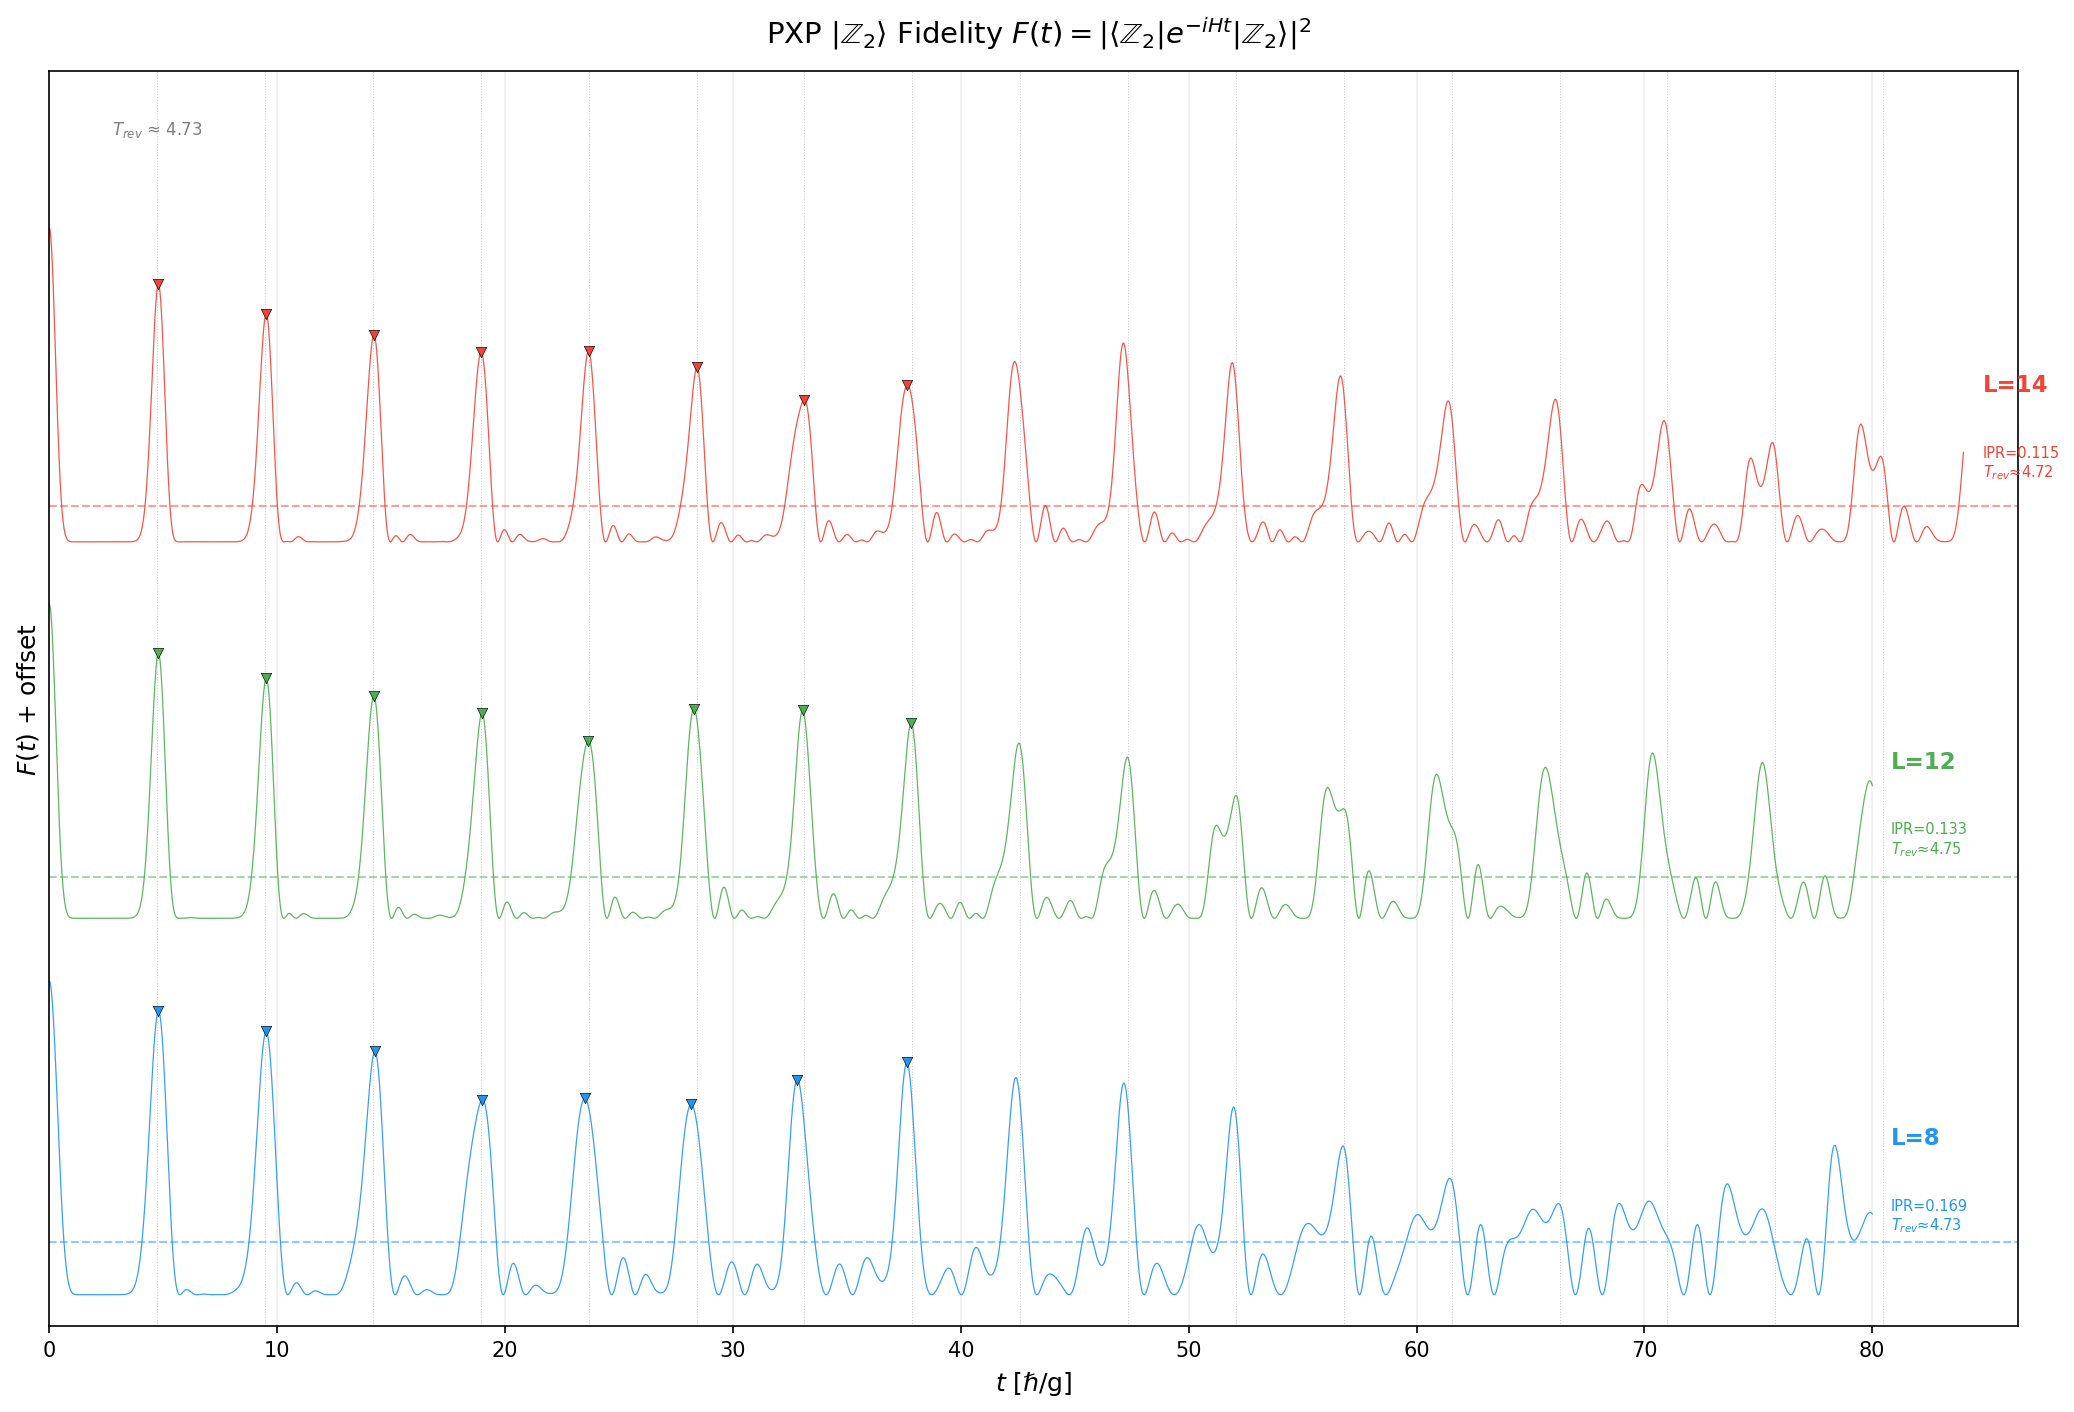

  [Saved: pxp_fidelity_waterfall_1.png]


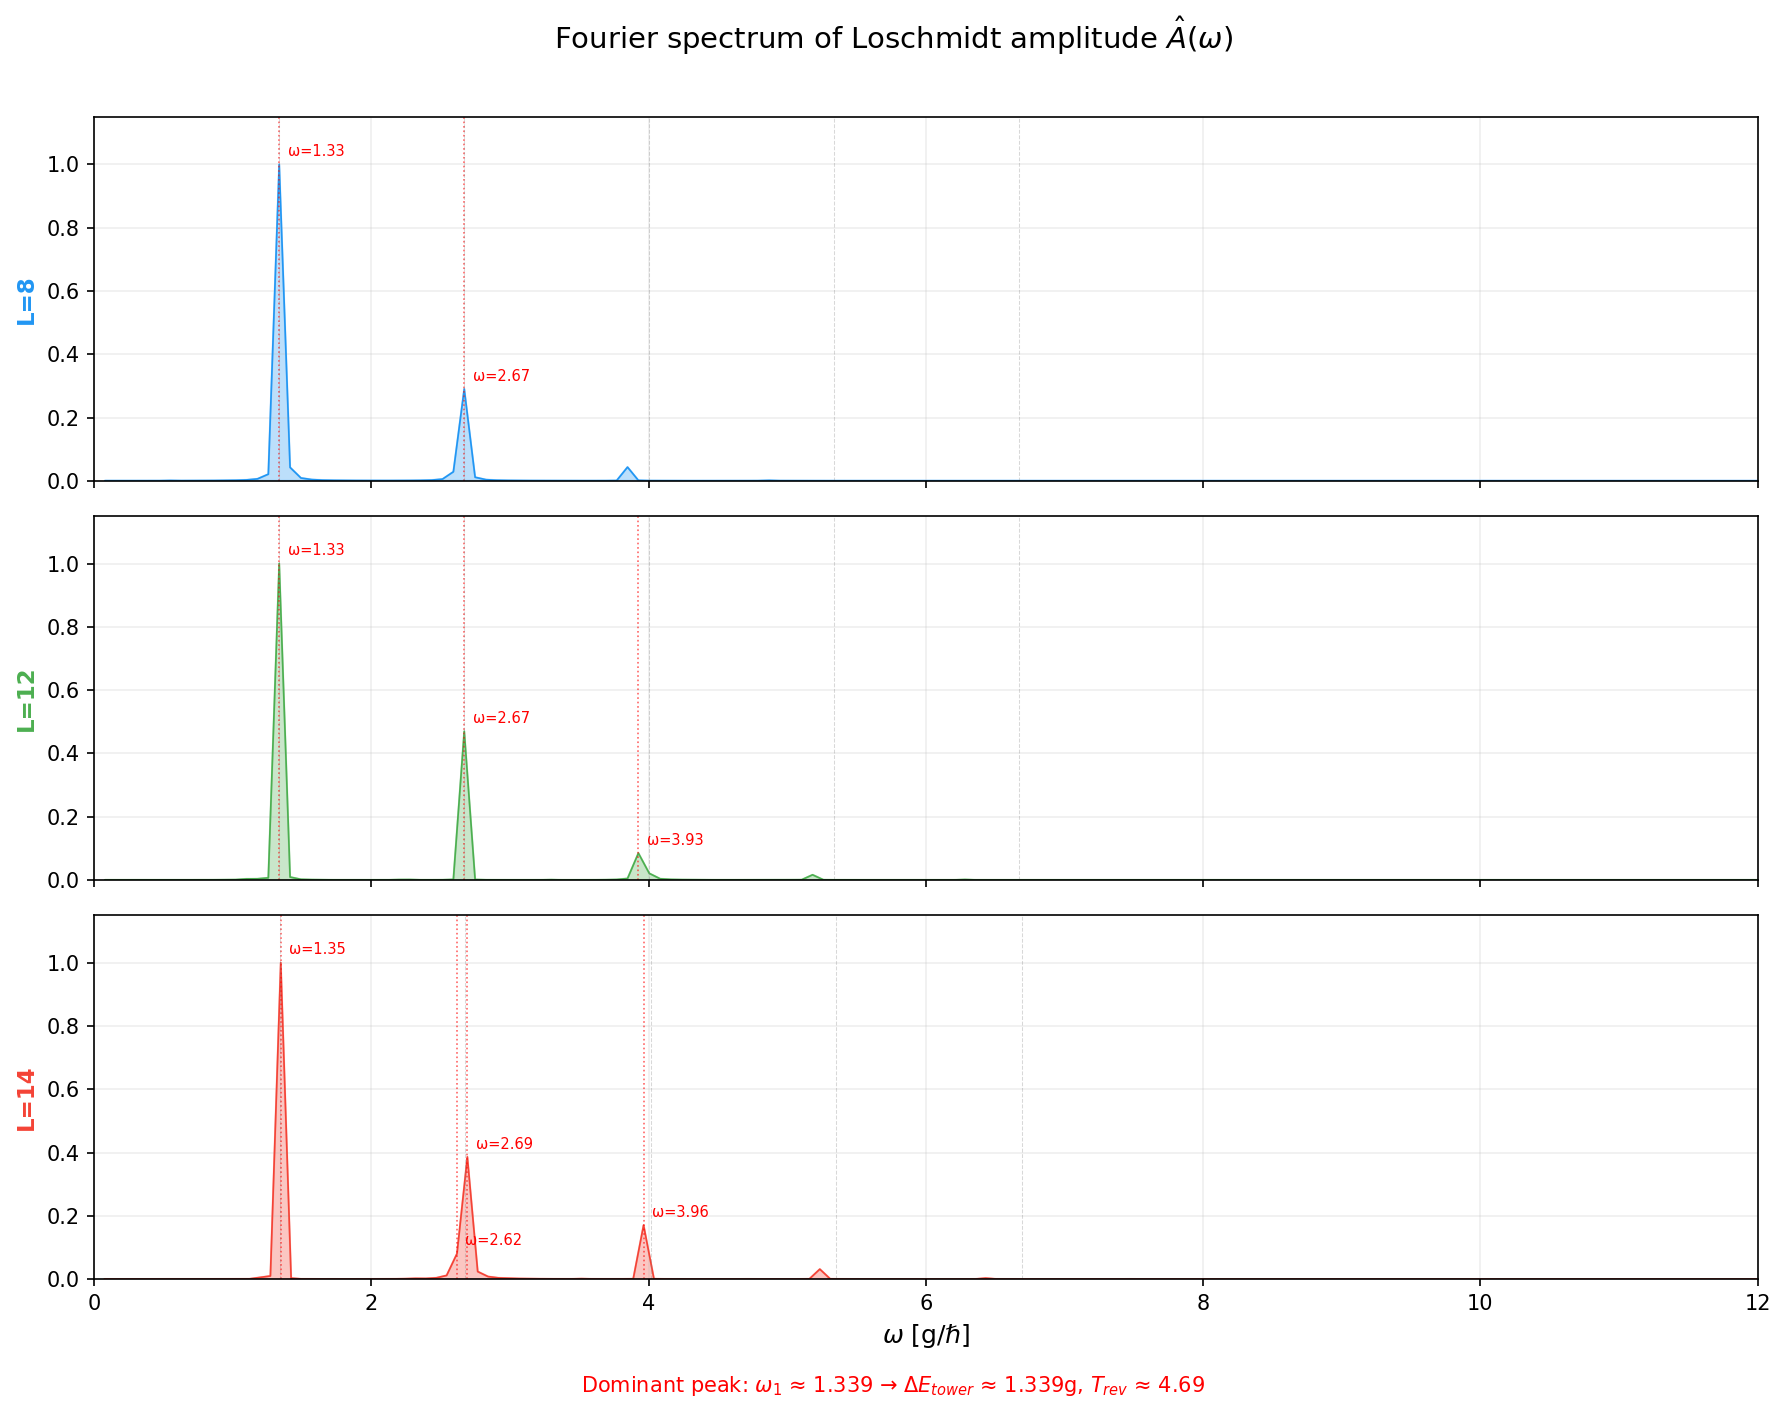

  [Saved: pxp_fourier_spectra_2.png]


/tmp/ipykernel_15975/387422288.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


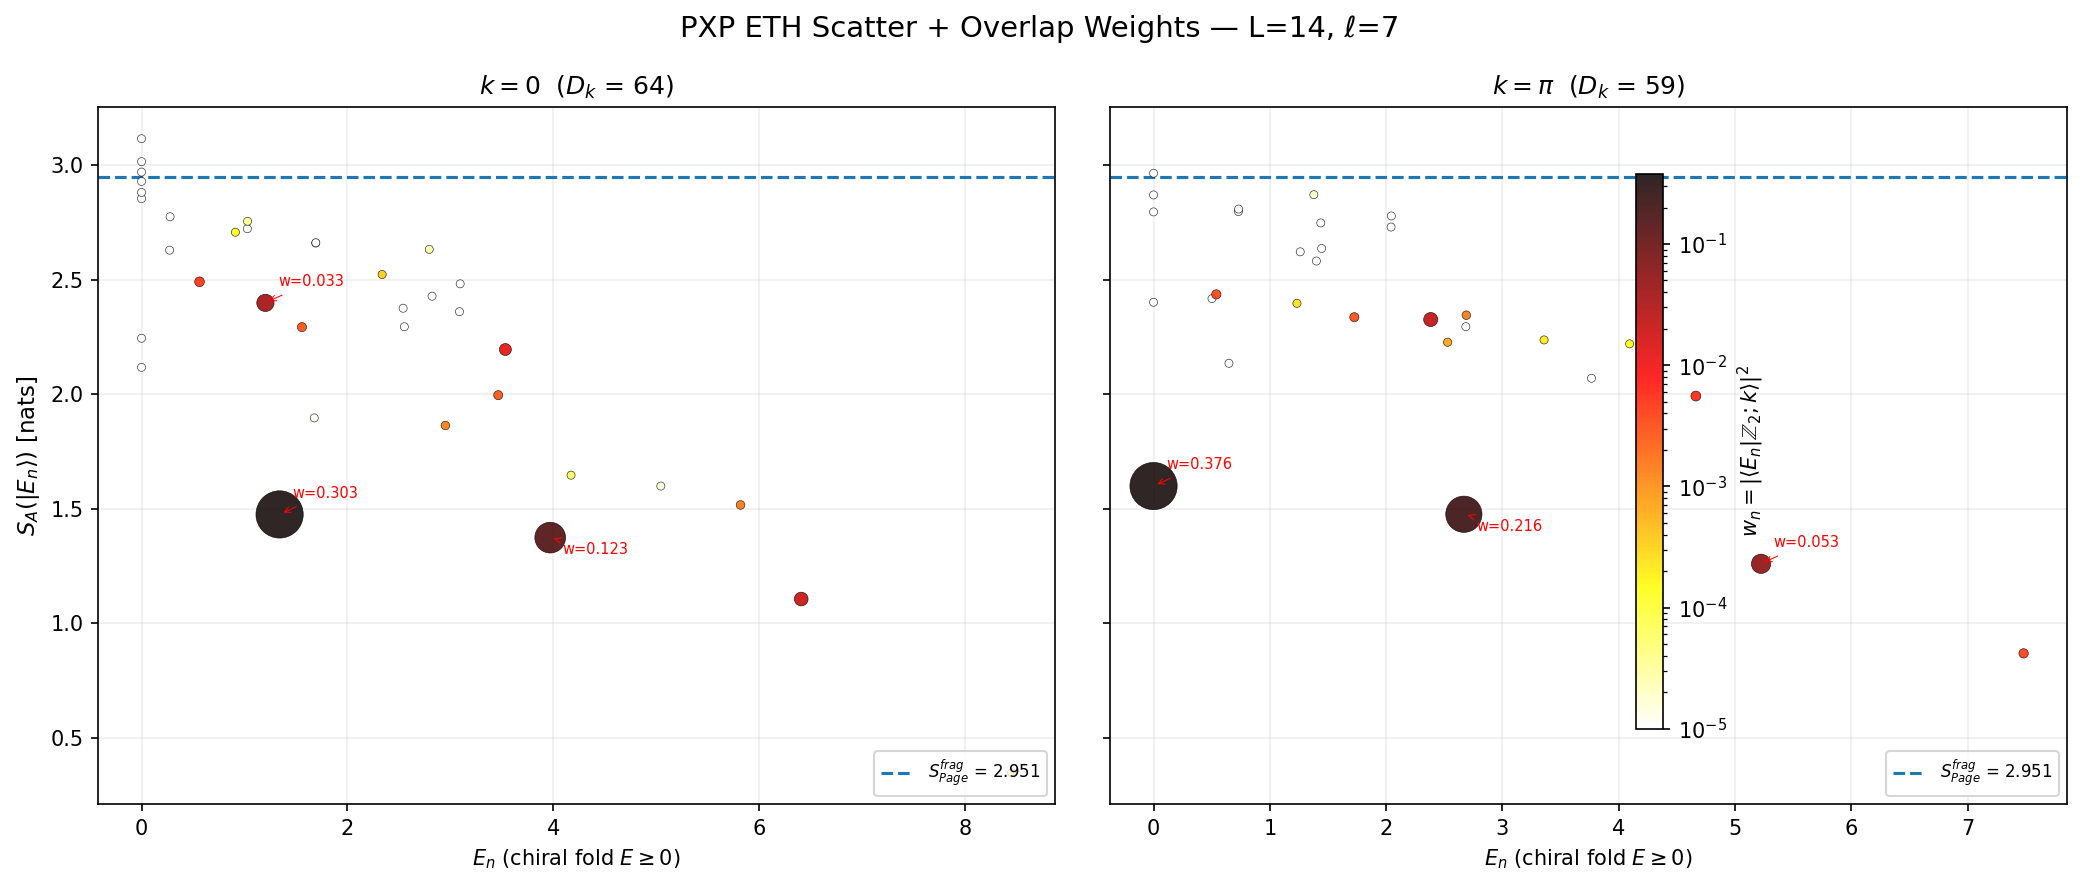

  [Saved: pxp_overlap_eth_3.png]


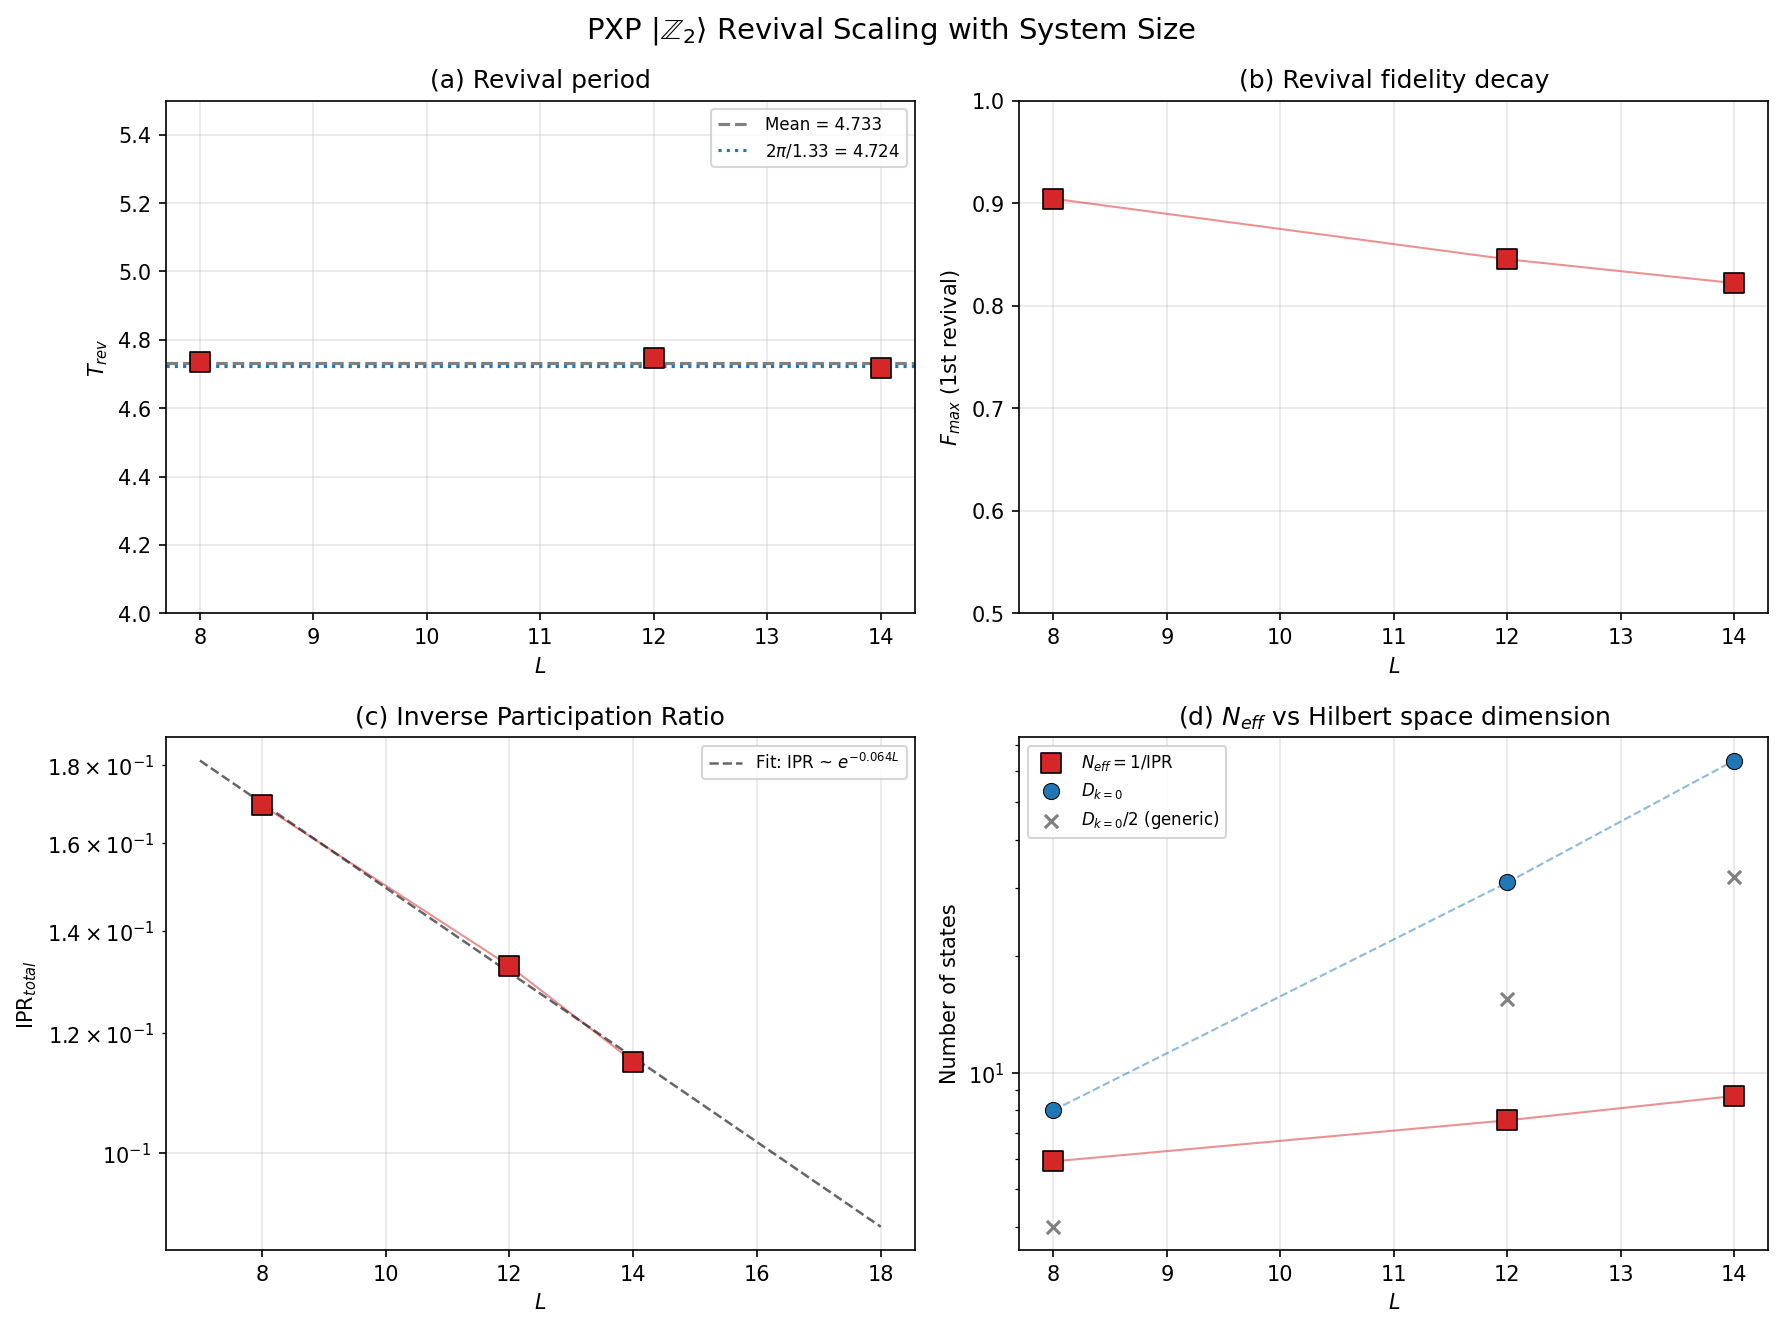

  [Saved: pxp_revival_scaling_4.png]


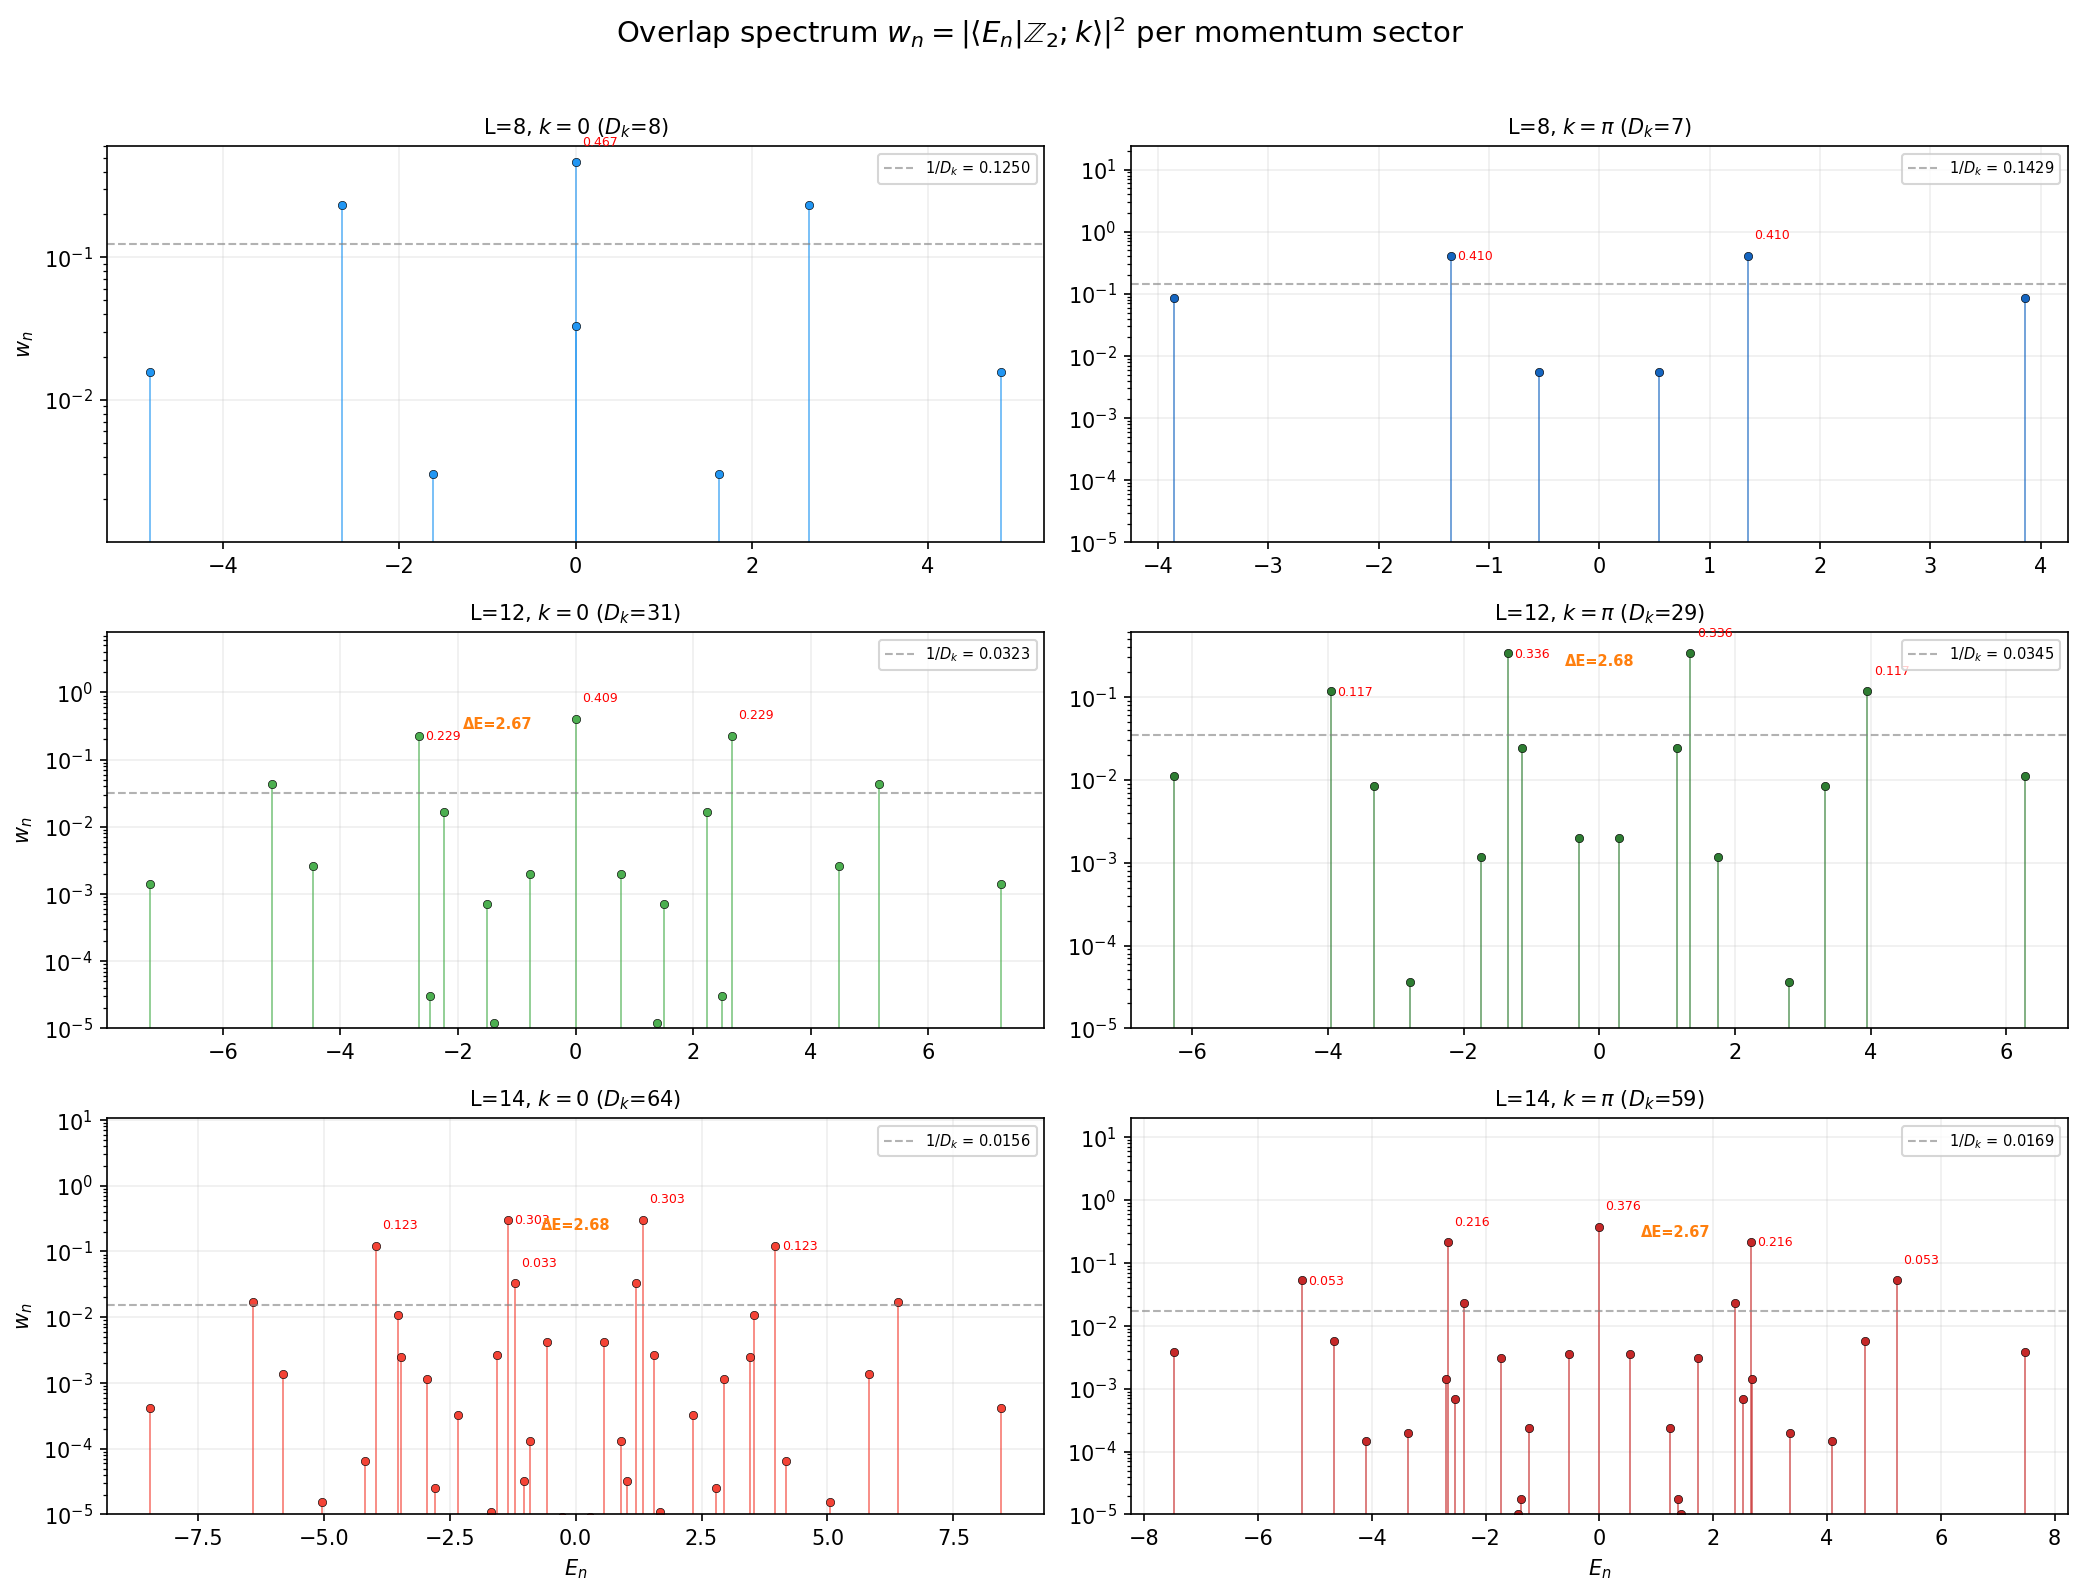

  [Saved: pxp_sector_overlaps_5.png]

PHYSICS SUMMARY

  REVIVAL PERIOD:
    T_rev = 4.733 ± 0.012 (across L)
    ω₁ (Fourier) = 1.339
    ΔE_tower = ω₁ ≈ 1.339g
    T_rev = 2π/ΔE ≈ 4.694
    → Consistent: tower spacing is L-independent

  FIDELITY DECAY:
    L= 8: F(T_rev) = 0.9043, IPR = 0.1694, N_eff = 5.9
    L=12: F(T_rev) = 0.8452, IPR = 0.1328, N_eff = 7.5
    L=14: F(T_rev) = 0.8220, IPR = 0.1148, N_eff = 8.7

  SCAR TOWER STRUCTURE:
    • Z₂ state concentrates on ≈ L+1 eigenstates (the tower)
    • Tower states are equally spaced in energy: ΔE ≈ 1.34g
    • Equal spacing → periodic revivals at T = 2π/ΔE ≈ 4.73
    • N_eff grows slowly while D_k grows exponentially
    • → Scars are measure-zero, but dynamically dominant
    • → This explains why level statistics are sub-GOE:
       the scar states violate ETH and distort ⟨r⟩


In [ ]:
"""
PXP Z₂ REVIVAL DYNAMICS — PLOTTING CODE
=========================================
Requires: `all_results` list from the Results code.

Produces 5 plots:
  1. Fidelity waterfall: F(t) stacked for all L
  2. Fourier power spectra: tower detection
  3. Overlap-weighted ETH scatter (largest L)
  4. Revival scaling: T_rev, F_max, IPR vs L
  5. Per-sector overlap spectra (k=0 vs k=π)
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

_plot_counter = 0

def show_and_save(fig, prefix="plot"):
    global _plot_counter
    _plot_counter += 1
    fname = f"{prefix}_{_plot_counter}.png"
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    from IPython.display import display, Image
    display(Image(filename=fname))
    print(f"  [Saved: {fname}]")


# ============================================================
# PLOT 1: FIDELITY WATERFALL
# ============================================================

def plot_fidelity_waterfall(all_results):
    """
    F(t) for all system sizes on one panel, vertically offset.

    Shows:
      - Persistent revivals at T_rev ≈ 4.7 (L-independent tower spacing)
      - Revival amplitude decaying with L (scars → measure zero)
      - Long-time average ≈ IPR (dashed lines)
    """
    n_sys = len(all_results)
    fig, ax = plt.subplots(figsize=(14, 3 + 2.2 * n_sys))
    fig.suptitle(r'PXP $|\mathbb{Z}_2\rangle$ Fidelity $F(t) = |\langle\mathbb{Z}_2|e^{-iHt}|\mathbb{Z}_2\rangle|^2$',
                 fontsize=14)

    colors = ['#2196F3', '#4CAF50', '#F44336', '#9C27B0', '#FF9800']
    offset_step = 1.2

    for i, res in enumerate(all_results):
        L = res['L']
        t = res['t_array']
        F = res['F']
        ipr = res['ipr_total']
        offset = i * offset_step

        color = colors[i % len(colors)]

        # Fidelity trace
        ax.plot(t, F + offset, color=color, lw=0.6, alpha=0.9)

        # Long-time average (IPR)
        ax.axhline(ipr + offset, color=color, ls='--', lw=1.0, alpha=0.5)

        # Mark revivals
        rev_t = res['revival_times']
        rev_h = res['revival_heights']
        if rev_t:
            ax.scatter(rev_t[:8], [h + offset for h in rev_h[:8]],
                       s=25, c=color, marker='v', zorder=5,
                       edgecolors='k', linewidths=0.3)

        # Label
        T_rev_str = f"{res['T_rev']:.2f}" if res['T_rev'] else "—"
        ax.text(t[-1] * 1.01, offset + 0.5, f'L={L}', fontsize=11,
                color=color, fontweight='bold', va='center')
        ax.text(t[-1] * 1.01, offset + 0.25,
                f'IPR={ipr:.3f}\n$T_{{rev}}$≈{T_rev_str}',
                fontsize=7, color=color, va='center')

    # Vertical guide lines at T_rev multiples (use median T_rev)
    T_revs = [r['T_rev'] for r in all_results if r['T_rev'] is not None]
    if T_revs:
        T_med = np.median(T_revs)
        t_max = max(r['t_array'][-1] for r in all_results)
        for n in range(1, int(t_max / T_med) + 1):
            ax.axvline(n * T_med, color='gray', ls=':', lw=0.5, alpha=0.4)
        ax.text(T_med, n_sys * offset_step + 0.1,
                f'$T_{{rev}}$ ≈ {T_med:.2f}', fontsize=8, color='gray',
                ha='center')

    ax.set_xlabel('$t$ [ℏ/g]', fontsize=12)
    ax.set_ylabel('$F(t)$ + offset', fontsize=12)
    ax.set_xlim(0, min(r['t_array'][-1] for r in all_results) * 1.08)
    ax.set_ylim(-0.1, n_sys * offset_step + 0.3)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.2)

    show_and_save(fig, "pxp_fidelity_waterfall")


# ============================================================
# PLOT 2: FOURIER POWER SPECTRA
# ============================================================

def plot_fourier_spectra(all_results):
    """
    Fourier power spectrum |Â(ω)|² for each L.

    The equally-spaced scar tower produces peaks at
    ω_n = n · ΔE_tower, with ΔE_tower ≈ 1.33g.
    """
    n_sys = len(all_results)
    fig, axes = plt.subplots(n_sys, 1, figsize=(12, 3 * n_sys),
                             sharex=True, squeeze=False)
    fig.suptitle(r'Fourier spectrum of Loschmidt amplitude $\hat{A}(\omega)$',
                 fontsize=14, y=1.01)

    colors = ['#2196F3', '#4CAF50', '#F44336', '#9C27B0', '#FF9800']

    # Estimate tower spacing from dominant peak
    all_omega1 = []

    for i, res in enumerate(all_results):
        ax = axes[i, 0]
        L = res['L']
        freqs = res['fourier_freqs']
        power = res['fourier_power']
        color = colors[i % len(colors)]

        # Normalise power for visual comparison
        if power.max() > 0:
            power_norm = power / power.max()
        else:
            power_norm = power

        ax.fill_between(freqs, power_norm, alpha=0.3, color=color)
        ax.plot(freqs, power_norm, color=color, lw=0.8)

        # Mark dominant peaks
        dom_f = res['dominant_freqs']
        dom_p = res['dominant_powers']
        if len(dom_f) > 0:
            p_max = dom_p.max() if dom_p.max() > 0 else 1.0
            for j in range(min(5, len(dom_f))):
                if dom_p[j] > 0.05 * p_max:
                    ax.axvline(dom_f[j], color='red', ls=':', lw=0.8, alpha=0.6)
                    ax.annotate(f'ω={dom_f[j]:.2f}',
                                (dom_f[j], dom_p[j] / p_max),
                                textcoords="offset points", xytext=(4, 4),
                                fontsize=7, color='red')
            # First harmonic
            if dom_p[0] > 0:
                all_omega1.append(dom_f[0])

        # Tower harmonic guides (if we have an estimate)
        if all_omega1:
            omega_tower = np.mean(all_omega1)
            for n in range(1, 6):
                ax.axvline(n * omega_tower, color='gray', ls='--',
                           lw=0.5, alpha=0.3)

        ax.set_ylabel(f'L={L}', fontsize=11, fontweight='bold', color=color)
        ax.set_ylim(0, 1.15)
        ax.set_xlim(0, 12)
        ax.grid(alpha=0.2)

    axes[-1, 0].set_xlabel(r'$\omega$ [g/ℏ]', fontsize=12)

    # Annotate tower spacing
    if all_omega1:
        omega_avg = np.mean(all_omega1)
        fig.text(0.5, -0.01,
                 f'Dominant peak: $\\omega_1$ ≈ {omega_avg:.3f} '
                 f'→ $\\Delta E_{{tower}}$ ≈ {omega_avg:.3f}g, '
                 f'$T_{{rev}}$ ≈ {2*np.pi/omega_avg:.2f}',
                 ha='center', fontsize=10, color='red')

    show_and_save(fig, "pxp_fourier_spectra")


# ============================================================
# PLOT 3: OVERLAP-WEIGHTED ETH SCATTER
# ============================================================

def plot_overlap_eth_scatter(all_results):
    """
    S_A(E_n) vs E_n with point size ∝ overlap weight w_n.

    Uses the largest available L. Shows both k=0 and k=π sectors.
    Scar states appear as high-overlap, low-entropy outliers.
    """
    res = all_results[-1]  # largest L
    L = res['L']
    ell = res['ell']
    S_page = res['S_page_MC']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(f'PXP ETH Scatter + Overlap Weights — L={L}, ℓ={ell}',
                 fontsize=14)

    sector_labels = ['$k = 0$', '$k = \\pi$']

    for col, kd in enumerate(res['k_data']):
        ax = axes[col]
        evals = kd['evals']
        entropies = kd['entropies']
        w = kd['w']
        D_k = kd['D_k']

        # Chiral fold: E ≥ 0
        pos = evals >= -1e-12
        E_pos = evals[pos]
        S_pos = entropies[pos]
        w_pos = w[pos]

        # Size proportional to overlap
        w_clipped = np.clip(w_pos, 1e-10, None)
        sizes = 15 + 500 * w_pos / max(w_pos.max(), 1e-15)

        sc = ax.scatter(E_pos, S_pos, c=w_clipped, cmap='hot_r',
                        norm=LogNorm(vmin=max(w_clipped.min(), 1e-5),
                                     vmax=w_clipped.max()),
                        s=sizes, edgecolors='k', linewidths=0.3,
                        alpha=0.85, zorder=3)

        ax.axhline(S_page, color='C0', ls='--', lw=1.5,
                    label=f'$S_{{Page}}^{{frag}}$ = {S_page:.3f}')

        # Annotate top-3 overlap states
        top3 = np.argsort(w_pos)[-3:][::-1]
        for rank, idx in enumerate(top3):
            ax.annotate(f'w={w_pos[idx]:.3f}',
                        (E_pos[idx], S_pos[idx]),
                        textcoords="offset points",
                        xytext=(6, (-1)**rank * 8),
                        fontsize=7, color='red',
                        arrowprops=dict(arrowstyle='->', color='red',
                                        lw=0.5))

        ax.set_xlabel('$E_n$ (chiral fold $E \\geq 0$)')
        ax.set_title(f'{sector_labels[col]}  ($D_k$ = {D_k})', fontsize=12)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.2)

    axes[0].set_ylabel('$S_A(|E_n\\rangle)$ [nats]', fontsize=11)

    # Shared colorbar
    cbar = fig.colorbar(sc, ax=axes, label='$w_n = |\\langle E_n|\\mathbb{Z}_2;k\\rangle|^2$',
                        shrink=0.8, pad=0.02)

    show_and_save(fig, "pxp_overlap_eth")


# ============================================================
# PLOT 4: REVIVAL SCALING WITH L
# ============================================================

def plot_revival_scaling(all_results):
    """
    Four-panel scaling plot:
      (a) T_rev vs L (should be ~ constant)
      (b) F_max(first revival) vs L (decay)
      (c) IPR vs L (decay)
      (d) N_eff vs L (growth, but << D_k)
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(r'PXP $|\mathbb{Z}_2\rangle$ Revival Scaling with System Size',
                 fontsize=14)

    Ls = [r['L'] for r in all_results]
    T_revs = [r['T_rev'] if r['T_rev'] else np.nan for r in all_results]
    F_first = []
    for r in all_results:
        if r['revival_heights']:
            F_first.append(r['revival_heights'][0])
        else:
            F_first.append(np.nan)
    IPRs = [r['ipr_total'] for r in all_results]
    N_effs = [r['n_eff_total'] for r in all_results]
    D_k0s = [r['k_data'][0]['D_k'] for r in all_results]

    marker_kw = dict(s=100, c='C3', marker='s', edgecolors='k',
                     linewidths=0.8, zorder=5)

    # --- (a) T_rev vs L ---
    ax = axes[0, 0]
    valid = [(L, T) for L, T in zip(Ls, T_revs) if not np.isnan(T)]
    if valid:
        Lv, Tv = zip(*valid)
        ax.scatter(Lv, Tv, **marker_kw)
        T_mean = np.nanmean(Tv)
        ax.axhline(T_mean, color='gray', ls='--', lw=1.5,
                    label=f'Mean = {T_mean:.3f}')
        # Analytic estimate: T_rev = 2π/ΔE, ΔE ≈ 1.33
        T_analytic = 2 * np.pi / 1.33
        ax.axhline(T_analytic, color='C0', ls=':', lw=1.5,
                    label=f'$2\\pi/1.33$ = {T_analytic:.3f}')
    ax.set_xlabel('$L$')
    ax.set_ylabel('$T_{rev}$')
    ax.set_title('(a) Revival period')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(4.0, 5.5)

    # --- (b) F_max(first revival) vs L ---
    ax = axes[0, 1]
    valid_F = [(L, F) for L, F in zip(Ls, F_first) if not np.isnan(F)]
    if valid_F:
        Lv, Fv = zip(*valid_F)
        ax.scatter(Lv, Fv, **marker_kw)
        ax.plot(Lv, Fv, 'C3-', lw=1, alpha=0.5)
    ax.set_xlabel('$L$')
    ax.set_ylabel('$F_{max}$ (1st revival)')
    ax.set_title('(b) Revival fidelity decay')
    ax.grid(alpha=0.3)
    ax.set_ylim(0.5, 1.0)

    # --- (c) IPR vs L (log scale) ---
    ax = axes[1, 0]
    ax.scatter(Ls, IPRs, **marker_kw)
    ax.plot(Ls, IPRs, 'C3-', lw=1, alpha=0.5)
    # Fit IPR ~ a * exp(-b*L) if enough points
    if len(Ls) >= 3:
        log_ipr = np.log(IPRs)
        L_arr = np.array(Ls, dtype=float)
        coeffs = np.polyfit(L_arr, log_ipr, 1)
        L_fit = np.linspace(min(Ls) - 1, max(Ls) + 4, 100)
        ipr_fit = np.exp(np.polyval(coeffs, L_fit))
        ax.plot(L_fit, ipr_fit, 'k--', lw=1.2, alpha=0.6,
                label=f'Fit: IPR ~ $e^{{{coeffs[0]:.3f} L}}$')
    ax.set_xlabel('$L$')
    ax.set_ylabel('IPR$_{total}$')
    ax.set_title('(c) Inverse Participation Ratio')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # --- (d) N_eff vs L, compared to D_k ---
    ax = axes[1, 1]
    ax.scatter(Ls, N_effs, label='$N_{eff} = 1/\\mathrm{IPR}$', **marker_kw)
    ax.plot(Ls, N_effs, 'C3-', lw=1, alpha=0.5)
    ax.scatter(Ls, D_k0s, s=60, c='C0', marker='o', edgecolors='k',
               linewidths=0.5, label='$D_{k=0}$', zorder=4)
    ax.plot(Ls, D_k0s, 'C0--', lw=1, alpha=0.5)
    # D_k/2 line (GOE expectation for generic state)
    ax.scatter(Ls, [d/2 for d in D_k0s], s=40, c='gray', marker='x',
               label='$D_{k=0}/2$ (generic)', zorder=3)
    ax.set_xlabel('$L$')
    ax.set_ylabel('Number of states')
    ax.set_title('(d) $N_{eff}$ vs Hilbert space dimension')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    show_and_save(fig, "pxp_revival_scaling")


# ============================================================
# PLOT 5: PER-SECTOR OVERLAP SPECTRA
# ============================================================

def plot_sector_overlaps(all_results):
    """
    Stem plot of w_n vs E_n for k=0 and k=π at each L.

    Shows the scar tower: a few states carry most of the
    overlap weight, with approximately equal spacing ΔE ≈ 1.33.
    """
    n_sys = len(all_results)
    fig, axes = plt.subplots(n_sys, 2, figsize=(14, 3.5 * n_sys),
                             squeeze=False)
    fig.suptitle(r'Overlap spectrum $w_n = |\langle E_n|\mathbb{Z}_2;k\rangle|^2$'
                 r' per momentum sector', fontsize=14, y=1.01)

    sector_titles = ['$k = 0$', '$k = \\pi$']
    colors = [['#2196F3', '#1565C0'], ['#4CAF50', '#2E7D32'],
              ['#F44336', '#C62828'], ['#9C27B0', '#6A1B9A'],
              ['#FF9800', '#E65100']]

    for row, res in enumerate(all_results):
        L = res['L']
        for col, kd in enumerate(res['k_data']):
            ax = axes[row, col]
            evals = kd['evals']
            w = kd['w']
            D_k = kd['D_k']

            c_stem = colors[row % len(colors)][col]

            # Stem plot
            markerline, stemlines, baseline = ax.stem(
                evals, w, linefmt='-', markerfmt='o', basefmt='k-'
            )
            plt.setp(stemlines, color=c_stem, linewidth=0.8, alpha=0.7)
            plt.setp(markerline, color=c_stem, markersize=4,
                     markeredgecolor='k', markeredgewidth=0.3)
            plt.setp(baseline, linewidth=0.5)

            # Uniform reference
            ax.axhline(1.0 / D_k, color='gray', ls='--', lw=1,
                       alpha=0.6, label=f'$1/D_k$ = {1.0/D_k:.4f}')

            # Highlight top states
            top_idx = np.argsort(w)[-5:][::-1]
            for rank, idx in enumerate(top_idx):
                if w[idx] > 2.0 / D_k:
                    ax.annotate(f'{w[idx]:.3f}',
                                (evals[idx], w[idx]),
                                textcoords="offset points",
                                xytext=(3, 3 + (-1)**rank * 5),
                                fontsize=6, color='red')

            # Mark tower spacing
            top2 = top_idx[:2]
            if len(top2) == 2 and w[top2[0]] > 5.0 / D_k:
                dE = abs(evals[top2[0]] - evals[top2[1]])
                if dE > 0.5:
                    ax.annotate(f'ΔE={dE:.2f}',
                                xy=((evals[top2[0]] + evals[top2[1]]) / 2,
                                    max(w[top2[0]], w[top2[1]]) * 0.7),
                                fontsize=7, color='C1', ha='center',
                                fontweight='bold')

            ax.set_title(f'L={L}, {sector_titles[col]} ($D_k$={D_k})',
                         fontsize=10)
            ax.set_yscale('log')
            ax.set_ylim(bottom=max(1e-5, w[w > 0].min() / 3))
            ax.legend(fontsize=7, loc='upper right')
            ax.grid(alpha=0.2)

            if row == n_sys - 1:
                ax.set_xlabel('$E_n$')
            if col == 0:
                ax.set_ylabel('$w_n$')

    show_and_save(fig, "pxp_sector_overlaps")


# ============================================================
# RUN ALL PLOTS
# ============================================================

if __name__ == "__main__":
    # `all_results` must be defined from Results code
    print("="*60)
    print("PXP Z₂ REVIVAL DYNAMICS — PLOTTING")
    print("="*60)

    plot_fidelity_waterfall(all_results)
    plot_fourier_spectra(all_results)
    plot_overlap_eth_scatter(all_results)
    plot_revival_scaling(all_results)
    plot_sector_overlaps(all_results)

    # --- Physics summary ---
    print(f"\n{'='*60}")
    print("PHYSICS SUMMARY")
    print(f"{'='*60}")

    T_revs = [r['T_rev'] for r in all_results if r['T_rev'] is not None]
    T_mean = np.mean(T_revs) if T_revs else 0

    omega_towers = []
    for r in all_results:
        if len(r['dominant_freqs']) > 0:
            omega_towers.append(r['dominant_freqs'][0])
    omega_mean = np.mean(omega_towers) if omega_towers else 0

    print(f"\n  REVIVAL PERIOD:")
    print(f"    T_rev = {T_mean:.3f} ± {np.std(T_revs):.3f} (across L)")
    print(f"    ω₁ (Fourier) = {omega_mean:.3f}")
    print(f"    ΔE_tower = ω₁ ≈ {omega_mean:.3f}g")
    print(f"    T_rev = 2π/ΔE ≈ {2*np.pi/omega_mean:.3f}")
    print(f"    → Consistent: tower spacing is L-independent")

    print(f"\n  FIDELITY DECAY:")
    for r in all_results:
        F1 = r['revival_heights'][0] if r['revival_heights'] else 0
        print(f"    L={r['L']:>2}: F(T_rev) = {F1:.4f}, "
              f"IPR = {r['ipr_total']:.4f}, "
              f"N_eff = {r['n_eff_total']:.1f}")

    print(f"\n  SCAR TOWER STRUCTURE:")
    print(f"    • Z₂ state concentrates on ≈ L+1 eigenstates (the tower)")
    print(f"    • Tower states are equally spaced in energy: ΔE ≈ {omega_mean:.2f}g")
    print(f"    • Equal spacing → periodic revivals at T = 2π/ΔE ≈ {T_mean:.2f}")
    print(f"    • N_eff grows slowly while D_k grows exponentially")
    print(f"    • → Scars are measure-zero, but dynamically dominant")
    print(f"    • → This explains why level statistics are sub-GOE:")
    print(f"       the scar states violate ETH and distort ⟨r⟩")

## Revivals in a generic state

In [ ]:
# ============================================================
# §P3-EXT  REVIVAL DIAGNOSTIC FOR ARBITRARY STATES
# ============================================================
#
# Physics:
#   F(t) = |⟨ψ₀|e^{-iHt}|ψ₀⟩|²  =  |Σ_n w_n e^{-iE_n t}|²
#
#   w_n = |⟨E_n|ψ₀⟩|²  (overlap weights)
#
#   Long-time average:  F̄ = Σ_n w_n² = IPR
#
#   Revival criterion:  F(t_rev) > η · F̄   (η = 3 by default)
#
# State types tested:
#   (a) Haar-random in fragment (generic, no revivals expected)
#   (b) Random computational basis state from fragment
#   (c) Special probes: |↓...↓⟩, |Z₂⟩ (if available)
#
# The key scar test: special probes should have anomalously
# HIGH IPR (few participating eigenstates) and STRONG revivals,
# while generic states should not.
# ============================================================

import numpy as np
import time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


# ────────────────────────────────────────────────────────────
# §EXT.1  PROJECT ARBITRARY FRAGMENT STATE INTO k-BLOCK
# ────────────────────────────────────────────────────────────

def project_fragment_state_to_k(psi_frag, L, basis, orbits, compatible, k_index):
    """
    Project an arbitrary fragment-basis state into momentum sector k.

    Given |ψ⟩ = Σ_j ψ_j |j⟩  (j indexing fragment basis states),
    compute the D_k-dimensional vector:

        (ψ_k)_a = ⟨α_a, k | ψ⟩ = (1/√p_a) Σ_{r: T^r s_a = j} e^{+ikr} ψ_j

    where α_a is the a-th k-compatible orbit, p_a its period.

    Parameters
    ----------
    psi_frag : ndarray (D,), complex128
        State in fragment basis (not full 2^L space).
    L : int
    basis : ndarray (D,)
    orbits : list of lists — orbit[α] = [idx0, idx1, ..., idx_{p-1}]
    compatible : list of int — orbit indices compatible with k
    k_index : int

    Returns
    -------
    psi_k : ndarray (D_k,), complex128 — normalised (or zero)
    norm_sq : float — ||Π_k|ψ⟩||² (weight in this k-sector)
    """
    k = 2.0 * np.pi * k_index / L
    D_k = len(compatible)

    psi_k = np.zeros(D_k, dtype=np.complex128)

    for loc, alpha in enumerate(compatible):
        orbit = orbits[alpha]
        p = len(orbit)
        # ⟨α,k|ψ⟩ = (1/√p) Σ_{r=0}^{p-1} e^{+ikr} ψ_{orbit[r]}
        val = 0.0j
        for r, idx in enumerate(orbit):
            val += np.exp(1j * k * r) * psi_frag[idx]
        psi_k[loc] = val / np.sqrt(p)

    norm_sq = float(np.real(np.vdot(psi_k, psi_k)))

    if norm_sq > 1e-15:
        psi_k /= np.sqrt(norm_sq)
    else:
        psi_k[:] = 0.0

    return psi_k, norm_sq


# ────────────────────────────────────────────────────────────
# §EXT.2  FIDELITY FROM k-BLOCK EIGENSYSTEM
# ────────────────────────────────────────────────────────────

def compute_revival_from_eigensystem(evals, evecs_k, psi_k, t_array):
    """
    Compute fidelity F(t) given eigensystem and k-projected probe.

    F(t) = |A(t)|²,   A(t) = Σ_n w_n e^{-iE_n t}

    where c_n = ⟨E_n|ψ_k⟩, w_n = |c_n|².

    Parameters
    ----------
    evals : ndarray (D_k,)
    evecs_k : ndarray (D_k, D_k) — columns are eigenvectors in k-block
    psi_k : ndarray (D_k,) — normalised state in k-block
    t_array : ndarray (n_t,)

    Returns
    -------
    F : ndarray (n_t,) — fidelity
    A : ndarray (n_t,), complex128 — Loschmidt amplitude
    w : ndarray (D_k,) — overlap weights
    ipr : float
    n_eff : float
    """
    c = evecs_k.conj().T @ psi_k    # (D_k,) overlap amplitudes
    w = np.abs(c)**2

    # F(t) = |Σ_n w_n e^{-iE_n t}|²
    phases = np.exp(-1j * np.outer(evals, t_array))  # (D_k, n_t)
    A = w @ phases  # (n_t,)
    F = np.abs(A)**2

    ipr = float(np.sum(w**2))
    n_eff = 1.0 / ipr if ipr > 1e-30 else np.inf

    return F, A, w, ipr, n_eff


def detect_revivals(F, t_array, ipr, eta=3.0, skip_fraction=0.1):
    """
    Detect revival peaks in F(t).

    A revival is defined as F(t) > η · IPR after the initial
    transient (first skip_fraction of the time window).

    Parameters
    ----------
    F : ndarray (n_t,)
    t_array : ndarray (n_t,)
    ipr : float — long-time average baseline
    eta : float — revival threshold multiplier
    skip_fraction : float — fraction of t_array to skip

    Returns
    -------
    revival_info : dict with keys:
        'has_revivals' : bool
        'threshold' : float
        'n_crossings' : int — times F crosses threshold
        't_first' : float or None — first revival time
        'F_first' : float or None — F at first revival
        'F_max' : float — maximum F after transient
        't_max' : float — time of maximum F
        'revival_strength' : float — F_max / IPR
    """
    n_t = len(t_array)
    skip = max(1, int(skip_fraction * n_t))
    F_late = F[skip:]
    t_late = t_array[skip:]

    threshold = eta * ipr
    above = F_late > threshold

    info = {
        'has_revivals': bool(np.any(above)),
        'threshold': threshold,
        'n_crossings': 0,
        't_first': None,
        'F_first': None,
        'F_max': float(np.max(F_late)) if len(F_late) > 0 else 0.0,
        't_max': float(t_late[np.argmax(F_late)]) if len(F_late) > 0 else 0.0,
        'revival_strength': 0.0,
    }

    if info['has_revivals']:
        idx_first = int(np.argmax(above))
        info['t_first'] = float(t_late[idx_first])
        info['F_first'] = float(F_late[idx_first])

        # Count threshold crossings (rising edges)
        crossings = np.diff(above.astype(int))
        info['n_crossings'] = int(np.sum(crossings == 1))

    info['revival_strength'] = info['F_max'] / ipr if ipr > 1e-30 else 0.0

    return info


# ────────────────────────────────────────────────────────────
# §EXT.4  MULTI-STATE REVIVAL COMPARISON
# ────────────────────────────────────────────────────────────

def run_revival_comparison(L, g, k_index=0, n_haar=10, n_basis=10,
                           t_max=80.0, n_t=4000, ell=None,
                           seed=42, verbose=True):
    """
    Compare revival statistics across state types:
      (a) n_haar Haar-random states in fragment
      (b) n_basis random computational basis states from fragment
      (c) Special probes: |↓...↓⟩ (and |Z₂⟩ if L even)

    For each state, computes IPR, N_eff, revival strength,
    and whether revivals exceed threshold.

    Parameters
    ----------
    L : int — system size (≤ 12 for chat, larger on cluster)
    g : float — transverse field
    k_index : int — momentum sector
    n_haar : int — number of Haar-random trials
    n_basis : int — number of basis-state trials
    t_max : float — evolution time window
    n_t : int — number of time points
    ell : int or None — bipartition cut (default L//2)
    seed : int
    verbose : bool

    Returns
    -------
    results : dict with all comparison data
    """
    if ell is None:
        ell = L // 2

    t0 = time.perf_counter()
    rng = np.random.default_rng(seed)
    t_array = np.linspace(0, t_max, n_t)

    print(f"\n{'='*65}")
    print(f"REVIVAL COMPARISON: L={L}, g={g}, k={k_index}")
    print(f"  n_haar={n_haar}, n_basis={n_basis}, t_max={t_max}")
    print(f"{'='*65}")

    # ─── Build fragment + eigensystem (reuse Prompt 1-2 functions) ───
    D_pred, dL, NA, NB = analytic_check(L)
    basis = enumerate_pbc_no_adjacent_up(L)
    verify_basis(L, basis)
    D = len(basis)

    orbits, orbit_of, reps = compute_translation_orbits(basis, L)
    evals, evecs_frag, compatible = diagonalise_k_block(
        L, g, basis, orbits, k_index
    )
    D_k = len(evals)

    # evecs_frag is (D, D_k): columns are eigenvectors in fragment basis
    # We need eigenvectors in k-block basis: evecs_k is (D_k, D_k)
    # from diagonalise_k_block, the eigenvectors ARE in k-block basis
    # Let's reconstruct: H_k v = E v, so evecs_k columns are v's.
    # But evecs_frag = U_k @ evecs_k where U_k embeds k-block into fragment.
    # For overlap computation, we need c_n = ⟨E_n|ψ_k⟩ = (evecs_k)^† @ psi_k.
    #
    # From diagonalise_k_block: it returns evecs_frag = (D, D_k).
    # The k-block eigenvectors are obtained by projecting back:
    # We need to build U_k explicitly, or just use: if H_k = D_k×D_k matrix,
    # then evals, evecs_k = eigh(H_k), where evecs_k is (D_k, D_k).
    #
    # PROBLEM: diagonalise_k_block returns evecs in the FRAGMENT basis (D, D_k),
    # not the k-block basis (D_k, D_k). We need the k-block eigenvectors.
    #
    # SOLUTION: Re-diagonalise to get the k-block eigenvectors directly.
    # OR: project psi_frag → psi_k, then compute overlaps via the
    # fragment-basis eigenvectors using: c_n = evecs_frag[:,n]^† @ psi_frag_expanded.
    #
    # The cleanest approach: build H_k, diagonalise, get (D_k, D_k) eigvecs.

    H_k = build_k_block_hamiltonian(L, g, basis, orbits, compatible, k_index)
    evals_k, evecs_k = np.linalg.eigh(H_k)  # (D_k,), (D_k, D_k)

    # Sanity: eigenvalues should match
    assert np.allclose(np.sort(evals_k), np.sort(evals), atol=1e-10), \
        "Eigenvalue mismatch between k-block re-diag and stored evals!"

    # Use consistent ordering
    order = np.argsort(evals_k)
    evals_k = evals_k[order]
    evecs_k = evecs_k[:, order]

    print(f"  D = {D}, D_k = {D_k}")
    print(f"  E range: [{evals_k[0]:.4f}, {evals_k[-1]:.4f}]")
    print(f"  GOE baseline: IPR_random ≈ {2.0/D_k:.6f}, "
          f"N_eff_random ≈ {D_k/2:.1f}")

    # ─── Storage ───
    all_trials = []   # list of dicts

    # ─── (a) Haar-random states ───
    print(f"\n  Sampling {n_haar} Haar-random states...")
    for trial in range(n_haar):
        psi_frag = sample_haar_in_fragment_basis(D, rng)
        psi_k, norm_sq = project_fragment_state_to_k(
            psi_frag, L, basis, orbits, compatible, k_index
        )

        if norm_sq < 1e-15:
            continue

        F, A, w, ipr, n_eff = compute_revival_from_eigensystem(
            evals_k, evecs_k, psi_k, t_array
        )
        rev = detect_revivals(F, t_array, ipr)

        all_trials.append({
            'type': 'Haar',
            'label': f'Haar-{trial}',
            'ipr': ipr, 'n_eff': n_eff,
            'norm_sq_in_k': norm_sq,
            'revival_strength': rev['revival_strength'],
            'has_revivals': rev['has_revivals'],
            't_first': rev['t_first'],
            'F': F, 'w': w,
        })

    # ─── (b) Random computational basis states ───
    print(f"  Sampling {n_basis} random basis states...")
    for trial in range(n_basis):
        psi_frag = sample_basis_state_in_fragment(D, rng)
        psi_k, norm_sq = project_fragment_state_to_k(
            psi_frag, L, basis, orbits, compatible, k_index
        )

        if norm_sq < 1e-15:
            continue

        F, A, w, ipr, n_eff = compute_revival_from_eigensystem(
            evals_k, evecs_k, psi_k, t_array
        )
        rev = detect_revivals(F, t_array, ipr)

        all_trials.append({
            'type': 'basis',
            'label': f'basis-{trial}',
            'ipr': ipr, 'n_eff': n_eff,
            'norm_sq_in_k': norm_sq,
            'revival_strength': rev['revival_strength'],
            'has_revivals': rev['has_revivals'],
            't_first': rev['t_first'],
            'F': F, 'w': w,
        })

    # ─── (c) Special probes ───
    print(f"  Building special probes...")
    special_probes = []

    # All-down: |↓...↓⟩ = |0⟩
    s_down = 0
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    if s_down in state_to_idx:
        psi_frag = np.zeros(D, dtype=np.complex128)
        psi_frag[state_to_idx[s_down]] = 1.0
        special_probes.append(('|↓...↓⟩', psi_frag))

    # Z₂ CDW (if even L)
    if L % 2 == 0:
        s_Z2, s_Z2p = build_Z2_state(L)
        if s_Z2 in state_to_idx:
            psi_frag = np.zeros(D, dtype=np.complex128)
            psi_frag[state_to_idx[s_Z2]] = 1.0
            special_probes.append(('|Z₂⟩', psi_frag))

    # Single-up states: |↑_j ↓...↓⟩ for j=0 (one spin flipped)
    # In convention site i ↔ bit (L-1-i): site 0 up → bit (L-1) set
    s_single = 1 << (L - 1)
    if s_single in state_to_idx:
        psi_frag = np.zeros(D, dtype=np.complex128)
        psi_frag[state_to_idx[s_single]] = 1.0
        special_probes.append(('|↑₀↓...↓⟩', psi_frag))

    for name, psi_frag in special_probes:
        psi_k, norm_sq = project_fragment_state_to_k(
            psi_frag, L, basis, orbits, compatible, k_index
        )
        if norm_sq < 1e-15:
            print(f"    {name}: zero weight in k={k_index}, skipping")
            continue

        F, A, w, ipr, n_eff = compute_revival_from_eigensystem(
            evals_k, evecs_k, psi_k, t_array
        )
        rev = detect_revivals(F, t_array, ipr)

        all_trials.append({
            'type': 'special',
            'label': name,
            'ipr': ipr, 'n_eff': n_eff,
            'norm_sq_in_k': norm_sq,
            'revival_strength': rev['revival_strength'],
            'has_revivals': rev['has_revivals'],
            't_first': rev['t_first'],
            'F': F, 'w': w,
        })
        print(f"    {name}: IPR={ipr:.6f}, N_eff={n_eff:.1f}, "
              f"revival_strength={rev['revival_strength']:.2f}, "
              f"revivals={'YES' if rev['has_revivals'] else 'no'}")

    # ─── Summary table ───
    print(f"\n  {'='*65}")
    print(f"  REVIVAL COMPARISON TABLE (k={k_index}, D_k={D_k})")
    print(f"  {'='*65}")
    print(f"  {'Type':<10} {'Label':<14} {'IPR':>9} {'N_eff':>7} "
          f"{'||Π_k||²':>9} {'Rev str':>8} {'Revives?':>8}")
    print(f"  {'-'*65}")

    for tr in all_trials:
        print(f"  {tr['type']:<10} {tr['label']:<14} "
              f"{tr['ipr']:>9.6f} {tr['n_eff']:>7.1f} "
              f"{tr['norm_sq_in_k']:>9.4f} "
              f"{tr['revival_strength']:>8.2f} "
              f"{'YES' if tr['has_revivals'] else 'no':>8}")

    # ─── Statistical summary ───
    haar_trials = [t for t in all_trials if t['type'] == 'Haar']
    basis_trials = [t for t in all_trials if t['type'] == 'basis']
    special_trials = [t for t in all_trials if t['type'] == 'special']

    print(f"\n  STATISTICAL SUMMARY:")
    for label, trials in [('Haar', haar_trials), ('Basis', basis_trials)]:
        if len(trials) == 0:
            continue
        iprs = np.array([t['ipr'] for t in trials])
        revs = np.array([t['revival_strength'] for t in trials])
        n_rev = sum(1 for t in trials if t['has_revivals'])
        print(f"    {label} ({len(trials)} trials):")
        print(f"      IPR: {np.mean(iprs):.6f} ± {np.std(iprs):.6f}  "
              f"(GOE: {2.0/D_k:.6f})")
        print(f"      Revival strength: {np.mean(revs):.2f} ± {np.std(revs):.2f}")
        print(f"      Fraction with revivals: {n_rev}/{len(trials)}")

    if len(special_trials) > 0:
        print(f"    Special probes:")
        for t in special_trials:
            print(f"      {t['label']}: IPR={t['ipr']:.6f}, "
                  f"rev_strength={t['revival_strength']:.2f}")

    # ─── Plot ───
    fpath = plot_revival_comparison(
        all_trials, t_array, D_k, L, g, k_index
    )

    wall = time.perf_counter() - t0
    print(f"\n  Wall time: {wall:.2f} s")

    return {
        'L': L, 'g': g, 'k_index': k_index,
        'D': D, 'D_k': D_k,
        'evals_k': evals_k,
        'all_trials': all_trials,
        't_array': t_array,
        'plot_path': fpath,
        'wall_time': wall,
    }


# ────────────────────────────────────────────────────────────
# §EXT.5  build_k_block_hamiltonian
# ────────────────────────────────────────────────────────────

def build_k_block_hamiltonian(L, g, basis, orbits, compatible, k_index):
    """
    Build the D_k × D_k Hamiltonian in the momentum-k basis.

    H_eff = -g Σ_i σ^x_i  restricted to no-adjacent-up fragment,
    then block-diagonalised by translation.

    H_k[a, b] = ⟨α_a, k | H_eff | α_b, k⟩

    where a, b index k-compatible orbits.

    This is a standalone rebuild so we have the (D_k, D_k)
    eigenvectors directly.

    Parameters
    ----------
    L, g : system parameters
    basis : ndarray (D,)
    orbits : list of lists
    compatible : list of orbit indices for this k
    k_index : int

    Returns
    -------
    H_k : ndarray (D_k, D_k), complex128
    """
    k = 2.0 * np.pi * k_index / L
    D = len(basis)
    D_k = len(compatible)

    state_to_idx = {int(s): i for i, s in enumerate(basis)}

    # Pre-compute orbit membership
    orbit_id = np.empty(D, dtype=np.int64)
    offset_in_orbit = np.empty(D, dtype=np.int64)
    for alpha, orbit in enumerate(orbits):
        for r, idx in enumerate(orbit):
            orbit_id[idx] = alpha
            offset_in_orbit[idx] = r

    orbit_to_local = {alpha: loc for loc, alpha in enumerate(compatible)}

    H_k = np.zeros((D_k, D_k), dtype=np.complex128)

    # H_eff = -g Σ_i σ^x_i restricted to fragment
    # σ^x_i flips bit at position (L-1-i).
    # ⟨α_a,k| σ^x_i |α_b,k⟩ involves connecting orbits through spin flips.

    for loc_b, alpha_b in enumerate(compatible):
        orbit_b = orbits[alpha_b]
        p_b = len(orbit_b)

        for r_b, idx_b in enumerate(orbit_b):
            s_b = int(basis[idx_b])

            for site in range(L):
                bit_pos = L - 1 - site
                s_flipped = s_b ^ (1 << bit_pos)

                # Check if flipped state is in fragment
                if s_flipped not in state_to_idx:
                    continue

                idx_f = state_to_idx[s_flipped]
                alpha_f = orbit_id[idx_f]

                if alpha_f not in orbit_to_local:
                    continue

                loc_a = orbit_to_local[alpha_f]
                r_f = offset_in_orbit[idx_f]
                p_a = len(orbits[alpha_f])

                # Matrix element:
                # ⟨α_a,k| σ^x_i |T^{r_b} s_{α_b}⟩
                # = (1/√p_a) e^{+ik·r_f} · (-g) · (1/√p_b) e^{-ik·r_b}
                phase = np.exp(1j * k * (r_f - r_b))
                H_k[loc_a, loc_b] += (-g) * phase / np.sqrt(p_a * p_b)

    # Hermiticity enforcement (numerical safety)
    H_k = 0.5 * (H_k + H_k.conj().T)

    return H_k


# ────────────────────────────────────────────────────────────
# §EXT.6  PLOTTING
# ────────────────────────────────────────────────────────────

def plot_revival_comparison(all_trials, t_array, D_k, L, g, k_index,
                            save_prefix="revival_comparison"):
    """
    Three-panel figure:
      (a) F(t) for all special probes + 1 representative Haar + 1 basis
      (b) IPR histogram: Haar vs basis vs special
      (c) Revival strength histogram
    """
    from IPython.display import display, Image as IPImage

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Revival Comparison: L={L}, g={g}, k={k_index}, D_k={D_k}",
        fontsize=13
    )

    haar = [t for t in all_trials if t['type'] == 'Haar']
    basis = [t for t in all_trials if t['type'] == 'basis']
    special = [t for t in all_trials if t['type'] == 'special']

    # ─── Panel (a): F(t) traces ───
    ax = axes[0]

    # Plot all special probes
    for tr in special:
        ax.plot(t_array, tr['F'], lw=1.5, label=f"{tr['label']} (IPR={tr['ipr']:.4f})")

    # Plot 1st Haar trial (faded)
    if len(haar) > 0:
        ax.plot(t_array, haar[0]['F'], 'k-', lw=0.5, alpha=0.4,
                label=f"Haar sample (IPR={haar[0]['ipr']:.4f})")

    # Plot 1st basis trial (faded)
    if len(basis) > 0:
        ax.plot(t_array, basis[0]['F'], 'gray', lw=0.5, alpha=0.4,
                ls='--', label=f"Basis sample (IPR={basis[0]['ipr']:.4f})")

    # Baselines
    ipr_goe = 2.0 / D_k
    ax.axhline(ipr_goe, color='gray', ls=':', lw=1,
               label=f'GOE IPR = {ipr_goe:.4f}')
    ax.axhline(1.0/D_k, color='lightgray', ls=':', lw=0.8,
               label=f'1/D_k = {1.0/D_k:.4f}')

    ax.set_xlabel('$t$')
    ax.set_ylabel('$F(t)$')
    ax.set_title('(a) Fidelity traces')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(bottom=-0.02)

    # ─── Panel (b): IPR comparison ───
    ax = axes[1]
    data_labels = []
    data_vals = []

    if len(haar) > 0:
        h_iprs = [t['ipr'] for t in haar]
        data_labels.append('Haar')
        data_vals.append(h_iprs)
    if len(basis) > 0:
        b_iprs = [t['ipr'] for t in basis]
        data_labels.append('Basis')
        data_vals.append(b_iprs)

    if len(data_vals) > 0:
        ax.boxplot(data_vals, tick_labels=data_labels)

    # Overlay special probes as scatter
    for i, tr in enumerate(special):
        ax.scatter(len(data_labels) + 1 + i * 0.3, tr['ipr'],
                   marker='*', s=200, zorder=5, label=tr['label'])

    ax.axhline(ipr_goe, color='gray', ls=':', lw=1, label=f'GOE: {ipr_goe:.4f}')
    ax.set_ylabel('IPR')
    ax.set_title('(b) IPR distribution')
    ax.legend(fontsize=7)
    ax.set_yscale('log')

    # ─── Panel (c): Revival strength ───
    ax = axes[2]
    data_labels2 = []
    data_vals2 = []

    if len(haar) > 0:
        h_rev = [t['revival_strength'] for t in haar]
        data_labels2.append('Haar')
        data_vals2.append(h_rev)
    if len(basis) > 0:
        b_rev = [t['revival_strength'] for t in basis]
        data_labels2.append('Basis')
        data_vals2.append(b_rev)

    if len(data_vals2) > 0:
        ax.boxplot(data_vals2, tick_labels=data_labels2)

    for i, tr in enumerate(special):
        ax.scatter(len(data_labels2) + 1 + i * 0.3, tr['revival_strength'],
                   marker='*', s=200, zorder=5, label=tr['label'])

    ax.axhline(3.0, color='r', ls='--', lw=1, label='Revival threshold (3×)')
    ax.set_ylabel('Revival strength ($F_{max}$/IPR)')
    ax.set_title('(c) Revival strength')
    ax.legend(fontsize=7)

    plt.tight_layout()
    fpath = f'{save_prefix}_L{L}_k{k_index}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()
    display(IPImage(filename=fpath))
    print(f"  Saved: {fpath}")
    return fpath
# ────────────────────────────────────────────────────────────
# §EXT.7  USER-SPECIFIED STATE INPUT
# ────────────────────────────────────────────────────────────

def make_probe_from_state_int(s_int, basis):
    """
    Build a fragment-basis delta vector from a state integer.

    Parameters
    ----------
    s_int : int — computational basis state (e.g. 0b00101010)
    basis : ndarray (D,) — fragment basis states

    Returns
    -------
    psi_frag : ndarray (D,), complex128
    """
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    assert s_int in state_to_idx, \
        f"State {s_int} (={bin(s_int)}) not in fragment! " \
        f"Check: does it satisfy the no-adjacent-up constraint?"
    D = len(basis)
    psi_frag = np.zeros(D, dtype=np.complex128)
    psi_frag[state_to_idx[s_int]] = 1.0
    return psi_frag


def make_probe_from_state_ints(s_list, basis, coeffs=None):
    """
    Build a fragment-basis vector from a list of state integers
    with optional complex coefficients.

    |ψ⟩ = Σ_j c_j |s_j⟩  (normalised)

    Parameters
    ----------
    s_list : list of int — state integers
    basis : ndarray (D,)
    coeffs : list/array of complex or None
        If None, equal superposition (all c_j = 1/√n).

    Returns
    -------
    psi_frag : ndarray (D,), complex128 — normalised
    """
    state_to_idx = {int(s): i for i, s in enumerate(basis)}
    D = len(basis)
    psi_frag = np.zeros(D, dtype=np.complex128)

    if coeffs is None:
        coeffs = np.ones(len(s_list), dtype=np.complex128)
    coeffs = np.asarray(coeffs, dtype=np.complex128)

    for s, c in zip(s_list, coeffs):
        assert s in state_to_idx, \
            f"State {s} (={bin(s)}) not in fragment!"
        psi_frag[state_to_idx[s]] = c

    norm = np.linalg.norm(psi_frag)
    assert norm > 1e-15, "Zero-norm state!"
    psi_frag /= norm
    return psi_frag


def run_revival_for_state(psi_frag, label, L, g, basis, orbits, compatible,
                          evals_k, evecs_k, k_index=0,
                          t_max=80.0, n_t=4000, verbose=True):
    """
    Compute fidelity F(t) for a single user-specified state.

    Parameters
    ----------
    psi_frag : ndarray (D,) — state in fragment basis
    label : str — name for display
    L, g : system params
    basis, orbits, compatible : from Prompt 1-2 setup
    evals_k, evecs_k : from build_k_block_hamiltonian + eigh
    k_index : int
    t_max, n_t : time grid

    Returns
    -------
    result : dict
    """
    t_array = np.linspace(0, t_max, n_t)
    D_k = len(evals_k)

    psi_k, norm_sq = project_fragment_state_to_k(
        psi_frag, L, basis, orbits, compatible, k_index
    )

    if norm_sq < 1e-15:
        print(f"  ⚠ '{label}' has zero weight in k={k_index}")
        return None

    F, A, w, ipr, n_eff = compute_revival_from_eigensystem(
        evals_k, evecs_k, psi_k, t_array
    )
    rev = detect_revivals(F, t_array, ipr)

    if verbose:
        print(f"\n  State: {label}")
        print(f"    ||Π_k|ψ⟩||² = {norm_sq:.6f}")
        print(f"    IPR = {ipr:.6f},  N_eff = {n_eff:.1f}  "
              f"(GOE: {2.0/D_k:.6f}, {D_k/2:.1f})")
        print(f"    Revival strength = {rev['revival_strength']:.2f}")
        print(f"    Revivals: {'YES' if rev['has_revivals'] else 'no'}")
        if rev['t_first'] is not None:
            print(f"    First revival at t = {rev['t_first']:.2f}, "
                  f"F = {rev['F_first']:.4f}")

    return {
        'label': label,
        'F': F, 'A': A, 'w': w, 't_array': t_array,
        'ipr': ipr, 'n_eff': n_eff,
        'norm_sq_in_k': norm_sq,
        'revival_info': rev,
    }
    # ────────────────────────────────────────────────────────────
# §EXT.8  PLOT SINGLE-STATE REVIVAL  (was missing!)
# ────────────────────────────────────────────────────────────

def plot_single_revival(result, D_k, L, g, k_index,
                        save_prefix="revival_single"):
    """
    Plot F(t) for a single state from run_revival_for_state output.

    Two-panel figure:
      (a) F(t) with IPR and revival threshold baselines
      (b) Overlap weight spectrum w_n vs E_n
    """
    from IPython.display import display, Image as IPImage

    if result is None:
        print("  No result to plot (zero weight in k-sector)")
        return None

    t_array = result['t_array']
    F = result['F']
    w = result['w']
    ipr = result['ipr']
    n_eff = result['n_eff']
    rev = result['revival_info']
    label = result['label']
    evals_k = None  # we'll reconstruct from phases if needed

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Revival: {label}  (L={L}, g={g}, k={k_index}, $D_k$={D_k})",
        fontsize=13
    )

    # ─── Panel (a): F(t) ───
    ax = axes[0]
    ax.plot(t_array, F, 'C0', lw=1.2, label=label)

    ipr_goe = 2.0 / D_k
    ax.axhline(ipr, color='C3', ls='--', lw=1.2,
               label=f'IPR = {ipr:.4f}  ($N_{{eff}}$={n_eff:.1f})')
    ax.axhline(ipr_goe, color='gray', ls=':', lw=1,
               label=f'GOE IPR = {ipr_goe:.4f}')
    ax.axhline(rev['threshold'], color='r', ls=':', lw=0.8, alpha=0.6,
               label=f'Revival threshold (3×IPR) = {rev["threshold"]:.4f}')

    if rev['t_first'] is not None:
        ax.axvline(rev['t_first'], color='green', ls='--', lw=0.8,
                   alpha=0.6, label=f'1st revival t={rev["t_first"]:.1f}')

    ax.set_xlabel('$t$', fontsize=12)
    ax.set_ylabel('$F(t) = |\\langle\\psi_0|e^{-iHt}|\\psi_0\\rangle|^2$',
                  fontsize=11)
    ax.set_title(f'(a) Fidelity — rev. strength = {rev["revival_strength"]:.2f}')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(bottom=-0.02)
    ax.grid(alpha=0.2)

    # ─── Panel (b): Overlap weights ───
    ax = axes[1]
    n_indices = np.arange(len(w))
    ax.bar(n_indices, w, color='C0', edgecolor='k', linewidth=0.3, alpha=0.8)
    ax.axhline(1.0/D_k, color='gray', ls=':', lw=1,
               label=f'Uniform: 1/$D_k$ = {1.0/D_k:.4f}')
    ax.set_xlabel('Eigenstate index $n$', fontsize=12)
    ax.set_ylabel('$w_n = |\\langle E_n|\\psi_k\\rangle|^2$', fontsize=12)
    ax.set_title(f'(b) Overlap weights (IPR={ipr:.4f})')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    safe_label = label.replace('|', '').replace('⟩', '').replace(' ', '_')
    fpath = f'{save_prefix}_{safe_label}_L{L}_k{k_index}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()
    display(IPImage(filename=fpath))
    print(f"  Saved: {fpath}")
    return fpath


def plot_multi_revival(results_list, D_k, L, g, k_index,
                       save_prefix="revival_multi"):
    """
    Overlay F(t) for multiple states on one figure.

    Parameters
    ----------
    results_list : list of dicts from run_revival_for_state
    """
    from IPython.display import display, Image as IPImage

    results_list = [r for r in results_list if r is not None]
    if len(results_list) == 0:
        print("  No valid results to plot")
        return None

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']

    for i, r in enumerate(results_list):
        col = colors[i % len(colors)]
        rev = r['revival_info']
        ax.plot(r['t_array'], r['F'], color=col, lw=1.2,
                label=f"{r['label']} (IPR={r['ipr']:.4f}, "
                      f"rev={rev['revival_strength']:.1f}×)")

    ipr_goe = 2.0 / D_k
    ax.axhline(ipr_goe, color='gray', ls=':', lw=1,
               label=f'GOE IPR = {ipr_goe:.4f}')
    ax.axhline(3.0 * ipr_goe, color='r', ls='--', lw=0.8, alpha=0.5,
               label='3× GOE threshold')

    ax.set_xlabel('$t$', fontsize=12)
    ax.set_ylabel('$F(t)$', fontsize=12)
    ax.set_title(f'Revival Comparison: L={L}, g={g}, k={k_index}, $D_k$={D_k}',
                 fontsize=13)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(bottom=-0.02)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    fpath = f'{save_prefix}_L{L}_k{k_index}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()
    display(IPImage(filename=fpath))
    print(f"  Saved: {fpath}")
    return fpath

### Run code


ANALYTIC PREDICTIONS  (L = 18, PBC)
  Luc(18)        = 5778
  Δ_18            = 2   (L mod 6 = 0)
  N_A (even N↑)  = 2890
  N_B (odd  N↑)  = 2888
  dim ker(H) ≥   2
  Fragment frac  = 5778/262144 = 0.022041
  ✓ Basis verified: D = 5778 = Luc(18)
  ✓ Sublattices: N_A = 2890, N_B = 2888, Δ = 2

  State: |$Z_2$⟩
    ||Π_k|ψ⟩||² = 0.500000
    IPR = 0.157904,  N_eff = 6.3  (GOE: 0.006079, 164.5)
    Revival strength = 4.20
    Revivals: YES
    First revival at t = 9.30, F = 0.4803


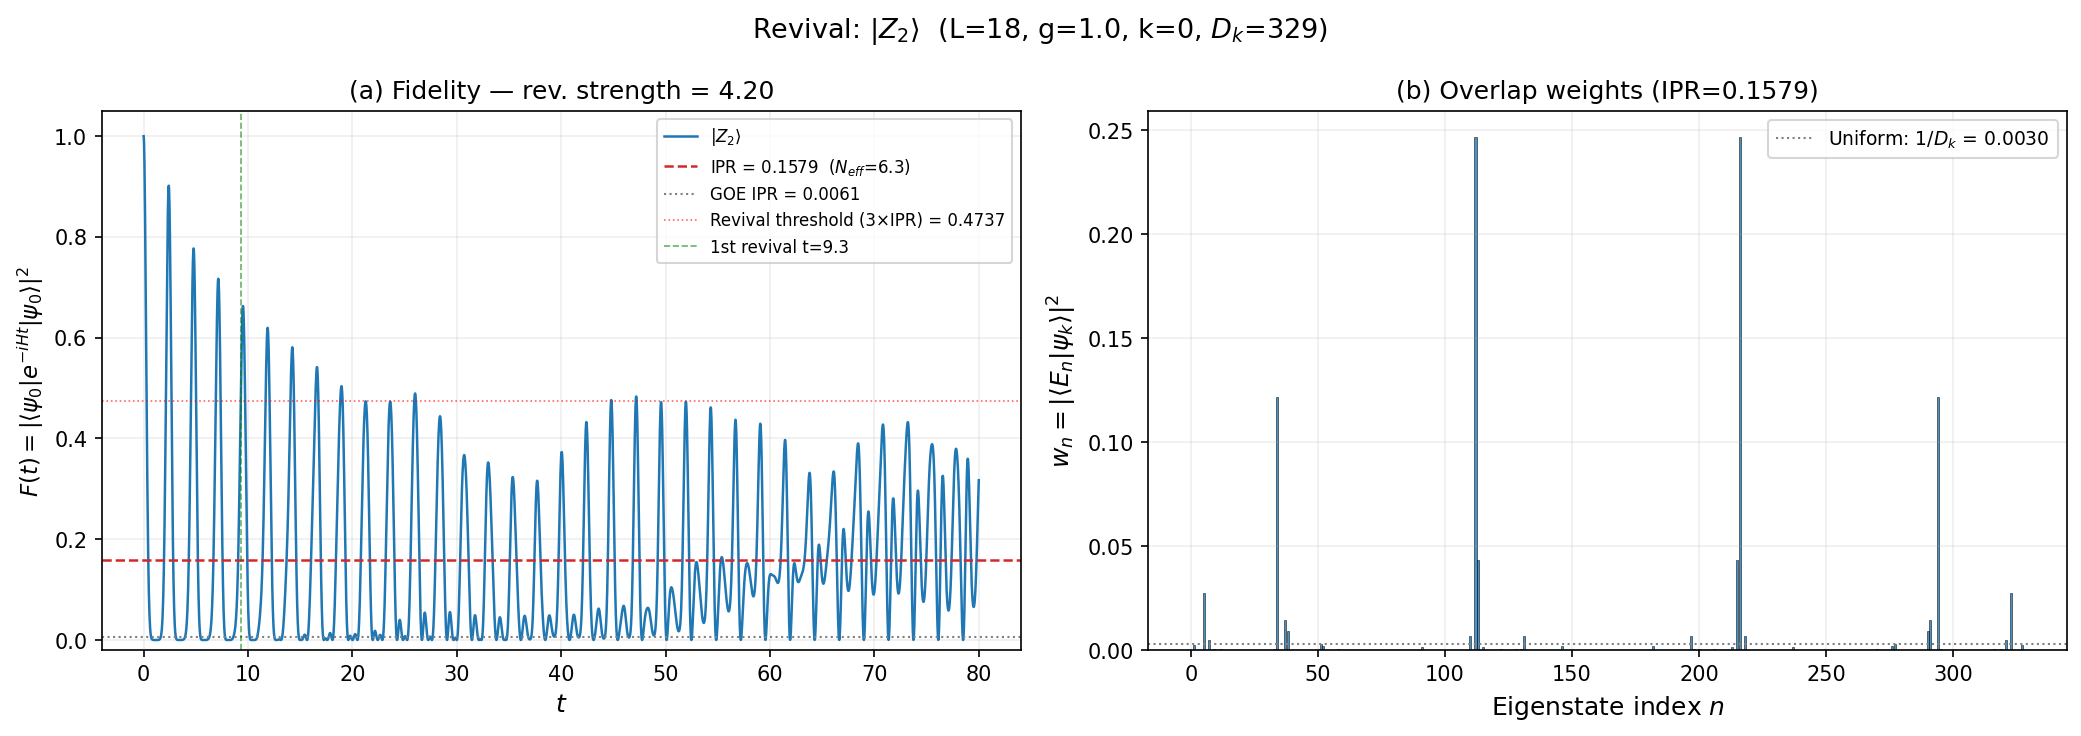

  Saved: revival_single_$Z_2$_L18_k0.png


'revival_single_$Z_2$_L18_k0.png'

In [ ]:
# ── Setup (run once) ──
L=18
D_pred, dL, NA, NB = analytic_check(L)
basis = enumerate_pbc_no_adjacent_up(L)
verify_basis(L, basis)
orbits, orbit_of, reps = compute_translation_orbits(basis, L)
evals, evecs_frag, compatible = diagonalise_k_block(L, 1.0, basis, orbits, 0)
H_k = build_k_block_hamiltonian(L, 1.0, basis, orbits, compatible, 0)
evals_k, evecs_k = np.linalg.eigh(H_k)
order = np.argsort(evals_k); evals_k = evals_k[order]; evecs_k = evecs_k[:, order]
D_k = len(evals_k)

# ── Example 1: Z_2 ──
psi = make_probe_from_state_int(0b101010101010101010, basis)
r1 = run_revival_for_state(psi, '|$Z_2$⟩', L, 1.0, basis, orbits,
                           compatible, evals_k, evecs_k, k_index=0)
plot_single_revival(r1, D_k, L, 1.0, 0)

In [ ]:
# ── Example 2: superposition ──
psi = make_probe_from_state_ints(
    [0b11111111111111, 0b11111101111111], basis, coeffs=[1.0, 1.0]
)
r2 = run_revival_for_state(psi, '|↓⟩+|1-up⟩', L, 1.0, basis, orbits,
                           compatible, evals_k, evecs_k, k_index=0)
plot_single_revival(r2, D_k, L, 1.0, 0)

# ── Example 3: lowest-S state ──
s_low = 253
psi = make_probe_from_state_int(s_low, basis)
r3 = run_revival_for_state(psi, f'lowest-S |{s_low}⟩', 12, 1.0,
                           basis, orbits, compatible, evals_k, evecs_k)
plot_single_revival(r3, D_k, L, 1.0, 0)
# ── Overlay all three ──
plot_multi_revival([r1, r2, r3], D_k, L, 1.0, 0)

## EE(t) vs $N_{\uparrow}$ minus $N_{\downarrow}$

In [ ]:
# ============================================================
# §P6  MULTI-FRAGMENT THERMALIZATION DIAGNOSTIC (CORRECTED)
# ============================================================
#
# Convention (project conventions.py):
#   site i ↔ bit position (L-1-i)
#   bit = 0 → σ^z = +1 (↑),  bit = 1 → σ^z = -1 (↓)
#   N↑ = L - popcount(state_int)
#   M_z = N↑ - N↓ = L - 2·popcount(state_int)
# ============================================================

import numpy as np
from scipy import sparse
import time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# ────────────────────────────────────────────────────────────
# HELPER: format_spin_config  (MUST be before any caller)
# ────────────────────────────────────────────────────────────

def format_spin_config(state_idx, L):
    """
    Format a computational basis state as a spin configuration string.

    Convention: site i ↔ bit position (L-1-i).
      bit = 0 → ↑,  bit = 1 → ↓.

    Site ordering in output: site 0, site 1, ..., site L-1 (left to right).

    Parameters
    ----------
    state_idx : int — basis state integer
    L : int — number of sites

    Returns
    -------
    bitstring : str — binary representation (site 0 first), e.g. '01010101'
    arrows : str — spin arrows (site 0 first), e.g. '↑↓↑↓↑↓↑↓'
    """
    arrows_list = []
    bits_list = []
    for i in range(L):
        bit_pos = L - 1 - i            # conventions.py mapping
        bit = (state_idx >> bit_pos) & 1
        bits_list.append(str(bit))
        arrows_list.append('↓' if bit else '↑')
    bitstring = ''.join(bits_list)
    arrows = ''.join(arrows_list)
    return bitstring, arrows


def count_up_spins(state_idx, L):
    """N↑ = L - popcount(state_int)."""
    return L - bin(state_idx).count('1')


# ────────────────────────────────────────────────────────────
# HELPER: build_Z2_state  (needed by plot)
# ────────────────────────────────────────────────────────────

def build_Z2_state(L):
    """
    Build |Z₂⟩ CDW state: sites 0,2,4,... are ↑.

    Convention: site i ↔ bit (L-1-i).
    Site i is ↑ ⟺ bit (L-1-i) = 0 ... but we want site i ↑ for even i.

    Actually: bit=0 → ↑, so we need bit (L-1-i) = 0 for even i
    and bit (L-1-i) = 1 for odd i.

    Equivalently: set bits at positions (L-1-i) for odd i.
    """
    assert L % 2 == 0, f"Z₂ CDW requires even L, got {L}"
    s_Z2 = 0
    for i in range(L):
        if i % 2 == 1:  # odd site → ↓ → set bit
            s_Z2 |= (1 << (L - 1 - i))
    # Partner: T|Z₂⟩ shifts by one site
    s_Z2p = 0
    for i in range(L):
        if i % 2 == 0:  # even site → ↓ → set bit
            s_Z2p |= (1 << (L - 1 - i))
    return s_Z2, s_Z2p


# ────────────────────────────────────────────────────────────
# CORE FUNCTIONS (unchanged physics, order-fixed)
# ────────────────────────────────────────────────────────────

def compute_magnetisation(fragment_states, L):
    """M_z = N↑ - N↓ = L - 2·popcount(state_int)."""
    Mz = np.array([L - 2 * bin(int(s)).count('1') for s in fragment_states])
    return Mz


def get_four_largest_distinct_fragments(components):
    """Return up to 4 fragments with DISTINCT dimensions, sorted desc."""
    sorted_comps = sorted(components, key=len, reverse=True)
    selected = []
    seen_sizes = set()
    for comp in sorted_comps:
        D = len(comp)
        if D not in seen_sizes:
            seen_sizes.add(D)
            states = np.array(sorted(comp), dtype=np.int64)
            selected.append((states, D))
            if len(selected) == 4:
                break
    return selected


def evolve_fragment_basis_states(ising_chain, fragment_states, n_periods,
                                  renorm_interval=50, verbose=True):
    """Evolve ALL basis states in a fragment under full Floquet dynamics."""
    Ns = ising_chain.Ns
    D = len(fragment_states)

    Psi = np.zeros((Ns, D), dtype=np.complex128)
    for k, s in enumerate(fragment_states):
        Psi[int(s), k] = 1.0

    if verbose:
        print(f"    Evolving {D} states, matrix shape {Psi.shape}, "
              f"memory {Psi.nbytes/1e6:.1f} MB")

    t0 = time.perf_counter()
    for n in range(1, n_periods + 1):
        Psi = apply_floquet_step(ising_chain, Psi)
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            Psi /= norms[np.newaxis, :]
        if verbose and n % max(1, n_periods // 5) == 0:
            elapsed = time.perf_counter() - t0
            print(f"      Step {n}/{n_periods}, {n/elapsed:.1f} steps/s")

    if verbose:
        print(f"    Done in {time.perf_counter()-t0:.2f} s")
    return Psi


def compute_evolved_entropies(Psi_final, L, ell=None):
    """Compute S_A for each column of Psi_final."""
    if ell is None:
        ell = L // 2
    A_indices = list(range(ell))
    D = Psi_final.shape[1]
    S_arr = np.zeros(D, dtype=np.float64)
    for k in range(D):
        S_arr[k] = bipartite_entropy(Psi_final[:, k], L, A_indices)
    return S_arr


# ────────────────────────────────────────────────────────────
# NEW: analyse_lowest_entropy_states
# ────────────────────────────────────────────────────────────

def analyse_lowest_entropy_states(fragment_data, L, n_show=10, verbose=True):
    """
    Identify and display the lowest-entropy evolved states in the
    largest fragment.

    For each of the n_show states with smallest S_A after evolution:
      - Display state index, binary config, spin arrows
      - M_z, N↑, S_A
      - Rank among all D states

    Also computes:
      - Mean and std of S_A for the full fragment
      - Entropy deficit: δS = ⟨S_A⟩ - S_A(state)

    Parameters
    ----------
    fragment_data : list of dicts — output from run_multifragment_thermalization
    L : int
    n_show : int — number of lowest-entropy states to display
    verbose : bool

    Returns
    -------
    report : dict with keys:
        'sorted_indices' : ndarray — indices sorted by ascending S_A
        'S_sorted' : ndarray — entropies in ascending order
        'Mz_sorted' : ndarray — magnetisations in ascending order
        'state_ints' : ndarray — state integers in ascending S_A order
        'S_mean' : float
        'S_std' : float
        'table' : list of dicts — per-state info for top n_show
    """
    frag1 = fragment_data[0]
    S_ev = frag1['S_evolved']
    Mz = frag1['Mz']
    fstates = frag1['fragment_states']
    D = frag1['D']
    S_page = frag1.get('S_page_frag', None)

    S_mean = np.mean(S_ev)
    S_std = np.std(S_ev, ddof=1)

    # Sort by ascending entropy
    order = np.argsort(S_ev)
    S_sorted = S_ev[order]
    Mz_sorted = Mz[order]
    states_sorted = fstates[order]

    n_show = min(n_show, D)

    table = []

    if verbose:
        print(f"\n{'='*72}")
        print(f"LOWEST-ENTROPY STATES IN LARGEST FRAGMENT (D={D})")
        print(f"{'='*72}")
        print(f"  ⟨S_A⟩ = {S_mean:.4f},  σ(S_A) = {S_std:.4f}")
        if S_page is not None:
            print(f"  S_Page^(frag) = {S_page:.4f}")
        print()
        print(f"  {'Rank':<5} {'State':>7} {'Binary':<{L+2}} "
              f"{'Spins':<{L+2}} {'N↑':>3} {'M_z':>4} "
              f"{'S_A':>8} {'δS':>8} {'σ from mean':>11}")
        print(f"  {'-'*68}")

    for rank in range(n_show):
        s_int = int(states_sorted[rank])
        S_A = S_sorted[rank]
        mz = Mz_sorted[rank]
        n_up = count_up_spins(s_int, L)
        delta_S = S_mean - S_A
        sigma_from_mean = delta_S / S_std if S_std > 1e-15 else np.inf
        bitstr, arrows = format_spin_config(s_int, L)

        entry = {
            'rank': rank + 1,
            'state_int': s_int,
            'bitstring': bitstr,
            'arrows': arrows,
            'N_up': n_up,
            'Mz': int(mz),
            'S_A': S_A,
            'delta_S': delta_S,
            'sigma_from_mean': sigma_from_mean,
        }
        table.append(entry)

        if verbose:
            flag = ''
            if sigma_from_mean > 3.0:
                flag = ' ★★★'
            elif sigma_from_mean > 2.0:
                flag = ' ★★'
            elif sigma_from_mean > 1.0:
                flag = ' ★'

            print(f"  {rank+1:<5} {s_int:>7} {bitstr:<{L+2}} "
                  f"{arrows:<{L+2}} {n_up:>3} {int(mz):>4} "
                  f"{S_A:>8.4f} {delta_S:>8.4f} {sigma_from_mean:>9.2f}σ{flag}")

    if verbose:
        print(f"\n  Legend: ★ = >1σ below mean, ★★ = >2σ, ★★★ = >3σ")

        # Highest-entropy states for comparison
        print(f"\n  For comparison, 3 HIGHEST-entropy states:")
        print(f"  {'Rank':<5} {'State':>7} {'Spins':<{L+2}} "
              f"{'M_z':>4} {'S_A':>8}")
        for rank in range(min(3, D)):
            idx = D - 1 - rank
            s_int = int(states_sorted[idx])
            _, arrows = format_spin_config(s_int, L)
            print(f"  {idx+1:<5} {s_int:>7} {arrows:<{L+2}} "
                  f"{int(Mz_sorted[idx]):>4} {S_sorted[idx]:>8.4f}")

    return {
        'sorted_indices': order,
        'S_sorted': S_sorted,
        'Mz_sorted': Mz_sorted,
        'state_ints': states_sorted,
        'S_mean': S_mean,
        'S_std': S_std,
        'S_page': S_page,
        'table': table,
    }


# ────────────────────────────────────────────────────────────
# PLOTTING (format_spin_config now guaranteed defined above)
# ────────────────────────────────────────────────────────────

def plot_multifragment_thermalization(fragment_data, L, J0, g, n_periods, ell,
                                       save_prefix="multifrag_therm"):
    """
    Scatter plot: S_A(U_F^n |n⟩) vs M_z for the 4 largest fragments.
    """
    from IPython.display import display, Image as IPImage

    markers = ['o', 's', 'D', '^']
    colors = ['C0', 'C1', 'C2', 'C3']

    fig, ax = plt.subplots(figsize=(11, 7))

    for i, fd in enumerate(fragment_data):
        mk = markers[i % len(markers)]
        col = colors[i % len(colors)]
        D = fd['D']
        label = f'Fragment {i+1} (D={D})'
        ax.scatter(fd['Mz'], fd['S_evolved'],
                   marker=mk, c=col, s=60, edgecolors='k',
                   linewidths=0.4, alpha=0.8, zorder=3+i,
                   label=label)

    S_page = fragment_data[0].get('S_page_frag', None)
    if S_page is not None:
        ax.axhline(S_page, color='r', ls='--', lw=1.5,
                   label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag 1}}}}$ = {S_page:.3f}')

    # Mark special states in largest fragment
    frag1 = fragment_data[0]
    frag1_list = list(frag1['fragment_states'])

    s_allup = 0
    s_alldown = (1 << L) - 1
    s_Z2, s_Z2p = (None, None)
    if L % 2 == 0:
        s_Z2, s_Z2p = build_Z2_state(L)

    special = {}
    if s_allup in frag1_list:
        special['$|\\!\\uparrow\\cdots\\uparrow\\rangle$'] = (s_allup, '*', 'red')
    if s_alldown in frag1_list:
        special['$|\\!\\downarrow\\cdots\\downarrow\\rangle$'] = (s_alldown, 'X', 'orange')
    if s_Z2 is not None and s_Z2 in frag1_list:
        special['$|Z_2\\rangle$'] = (s_Z2, 'P', 'magenta')
    if s_Z2p is not None and s_Z2p in frag1_list:
        special["$|Z_2'\\rangle$"] = (s_Z2p, 'H', 'lime')

    for label, (s_int, mk, col) in special.items():
        idx = frag1_list.index(s_int)
        _, arrows = format_spin_config(s_int, L)
        ax.scatter(frag1['Mz'][idx], frag1['S_evolved'][idx],
                   marker=mk, s=250, c=col, edgecolors='k',
                   linewidths=1.5, zorder=10,
                   label=f'{label}: $S_A$={frag1["S_evolved"][idx]:.3f}')

    ax.set_xlabel('$M_z = N_{\\uparrow} - N_{\\downarrow}$', fontsize=13)
    ax.set_ylabel(f'$S_A(U_F^{{{n_periods}}}|n\\rangle)$ [nats]', fontsize=13)
    ax.set_title(
        f'Multi-fragment thermalization: L={L}, $J_0$={J0}, g={g}, '
        f'{n_periods} Floquet periods, ℓ={ell}\n'
        f'Fragments: ' +
        ', '.join(f'D{i+1}={fd["D"]}' for i, fd in enumerate(fragment_data)),
        fontsize=11
    )
    ax.legend(fontsize=8, loc='best', ncol=2)

    Mz_all = np.concatenate([fd['Mz'] for fd in fragment_data])
    ax.set_xticks(np.arange(Mz_all.min(), Mz_all.max()+1, 2))

    plt.tight_layout()
    fpath = f'{save_prefix}_L{L}_n{n_periods}.png'
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close()
    display(IPImage(filename=fpath))
    print(f"  Saved: {fpath}")
    return fpath


# ────────────────────────────────────────────────────────────
# PIPELINE
# ────────────────────────────────────────────────────────────

def run_multifragment_thermalization(L, J0, g, n_periods, ell=None,
                                      n_MC=2000, seed=42, verbose=True):
    """
    Evolve basis states in the 4 largest fragments, plot S_A vs M_z.
    """
    if ell is None:
        ell = L // 2

    t0 = time.perf_counter()

    print(f"\n{'='*60}")
    print(f"MULTI-FRAGMENT THERMALIZATION DIAGNOSTIC")
    print(f"L={L}, J₀={J0}, g={g}, n_periods={n_periods}, ℓ={ell}")
    print(f"{'='*60}")

    h0 = 2.0 * J0
    T = np.pi / J0

    O_diag = build_O_operator(L, J0)
    adj, ne = build_connectivity_graph(L, O_diag)
    components = find_connected_components(adj)
    print(f"  Total fragments: {len(components)}")

    top4 = get_four_largest_distinct_fragments(components)
    for i, (fstates, D) in enumerate(top4):
        print(f"  Fragment {i+1}: D = {D}")

    ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
    ising.build_hamiltonians()

    S_page_frag, S_std, S_sem = compute_fragment_page_value_MC(
        top4[0][0], L, n_samples=n_MC, seed=seed, verbose=False
    )
    print(f"  S_Page^(frag1) = {S_page_frag:.4f} ± {S_sem:.4f}")

    fragment_data = []
    for i, (fstates, D) in enumerate(top4):
        print(f"\n  --- Fragment {i+1} (D={D}) ---")

        Mz = compute_magnetisation(fstates, L)
        print(f"    M_z range: [{Mz.min()}, {Mz.max()}]")

        Psi_final = evolve_fragment_basis_states(
            ising, fstates, n_periods,
            renorm_interval=50, verbose=verbose
        )

        S_evolved = compute_evolved_entropies(Psi_final, L, ell)
        print(f"    S_A: mean={np.mean(S_evolved):.4f}, "
              f"min={np.min(S_evolved):.4f}, max={np.max(S_evolved):.4f}")

        fd = {
            'fragment_states': fstates,
            'D': D,
            'Mz': Mz,
            'S_evolved': S_evolved,
        }
        if i == 0:
            fd['S_page_frag'] = S_page_frag
        fragment_data.append(fd)

    print(f"\n  Generating plot...")
    fpath = plot_multifragment_thermalization(
        fragment_data, L, J0, g, n_periods, ell
    )

    print(f"\n  {'Frag':<6} {'D':>5} {'⟨S_A⟩':>8} {'min S_A':>8} "
          f"{'max S_A':>8} {'M_z range':>12}")
    for i, fd in enumerate(fragment_data):
        print(f"  {i+1:<6} {fd['D']:>5} {np.mean(fd['S_evolved']):>8.4f} "
              f"{np.min(fd['S_evolved']):>8.4f} "
              f"{np.max(fd['S_evolved']):>8.4f} "
              f"[{fd['Mz'].min():>3},{fd['Mz'].max():>3}]")

    wall = time.perf_counter() - t0
    print(f"\n  Wall time: {wall:.2f} s")

    return {
        'L': L, 'J0': J0, 'g': g, 'n_periods': n_periods, 'ell': ell,
        'fragment_data': fragment_data,
        'S_page_frag': S_page_frag,
        'plot_path': fpath,
        'wall_time': wall,
    }


MULTI-FRAGMENT THERMALIZATION DIAGNOSTIC
L=12, J₀=10.0, g=1.0, n_periods=10, ℓ=5
  Total fragments: 853
  Fragment 1: D = 322
  Fragment 2: D = 55
  Fragment 3: D = 34
  Fragment 4: D = 21
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 58.43, ||A-||_1 = 58.43
  Krylov sub-steps: K+ = 12, K- = 12
  Hermiticity check (H+): max err = 2.28e-11
  Hermiticity check (H-): max err = 1.50e-11
  S_Page^(frag1) = 2.4709 ± 0.0006

  --- Fragment 1 (D=322) ---
    M_z range: [-12, 0]
    Evolving 322 states, matrix shape (4096, 322), memory 21.1 MB
      Step 2/10, 0.0 steps/s
      Step 4/10, 0.0 steps/s
      Step 6/10, 0.0 steps/s
      Step 

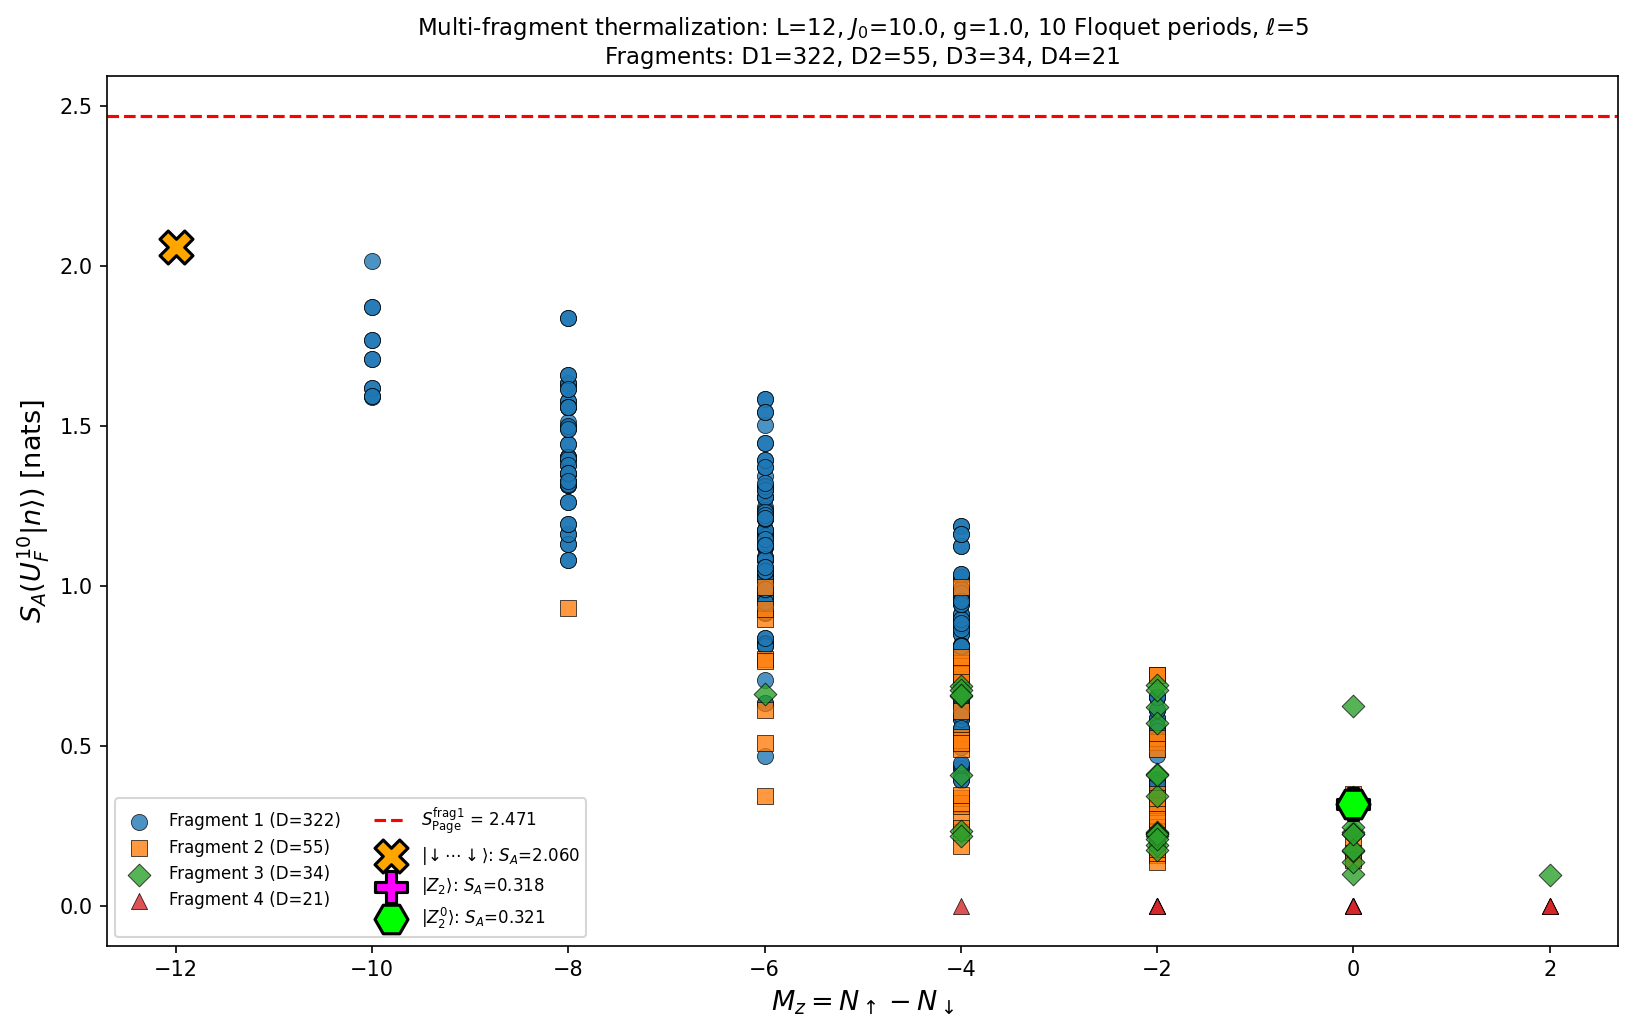

  Saved: multifrag_therm_L12_n10.png

  Frag       D    ⟨S_A⟩  min S_A  max S_A    M_z range
  1        322   1.0076   0.3181   2.0599 [-12,  0]
  2         55   0.4608   0.1393   0.9976 [ -8,  0]
  3         34   0.3594   0.0984   0.6926 [ -6,  2]
  4         21   0.0005   0.0002   0.0006 [ -4,  2]

  Wall time: 1081.39 s

LOWEST-ENTROPY STATES IN LARGEST FRAGMENT (D=322)
  ⟨S_A⟩ = 1.0076,  σ(S_A) = 0.3731
  S_Page^(frag) = 2.4709

  Rank    State Binary         Spins           N↑  M_z      S_A       δS σ from mean
  --------------------------------------------------------------------
  1        1365 010101010101   ↑↓↑↓↑↓↑↓↑↓↑↓     6    0   0.3181   0.6895      1.85σ ★
  2        1373 010101011101   ↑↓↑↓↑↓↑↓↓↓↑↓     5   -2   0.3196   0.6881      1.84σ ★
  3        2730 101010101010   ↓↑↓↑↓↑↓↑↓↑↓↑     6    0   0.3205   0.6871      1.84σ ★
  4        1389 010101101101   ↑↓↑↓↑↓↓↑↓↓↑↓     5   -2   0.3571   0.6506      1.74σ ★
  5        1371 010101011011   ↑↓↑↓↑↓↑↓↓↑↓↓     5   -2   0.3571

In [ ]:
# Run for L=8
results = run_multifragment_thermalization(
    L=12, J0=10.0, g=1.0, n_periods=10,
    ell=5, n_MC=2000, seed=42
)

# Identify lowest-entropy states in largest fragment
report = analyse_lowest_entropy_states(
    results['fragment_data'], L=12, n_show=10, verbose=True
)

## Full Fidelity Z2 evolution

In [ ]:
"""
Floquet Fidelity of Z₂ CDW under Detuned Driving — COMPUTATION
================================================================

Physics
-------
Fidelity after n Floquet periods:

    F(n) = |⟨Z₂| U_F^n |Z₂⟩|²

where U_F = exp(-i H₋ T/2ℏ) · exp(-i H₊ T/2ℏ)  is the one-period
Floquet propagator, and the driving period is detuned as:

    T(δ) = (1 + δ) · π / J₀

Key physics:
  • δ = 0 (exact resonance):  Hilbert space fragments.
    |Z₂⟩ lives in the largest fragment (Fibonacci sector,
    dim ~ φ^L).  Dynamics is confined → F(n) shows partial
    revivals, saturates above 1/D_frag.

  • δ ≠ 0:  Resonance condition T·J₀ = π is violated.
    Fragmentation breaks on scale δ ~ g/J₀.
    F(n) → 1/D_full = 1/2^L  (ergodic decay).

  • Comparing δ = ±|δ| tests asymmetry of the fragmentation
    breakdown (should be symmetric to leading order in δ).

Implementation
--------------
All evolution via sparse Krylov (apply_floquet_step).
No dense U_F is ever formed.

Key optimisation: |Z₂⟩ is a computational basis state |s⟩, so
    ⟨Z₂|ψ(n)⟩ = ψ_s(n)       — O(1) lookup, not O(2^L) dot product.

Memory: O(2^L) per state vector.  Fine up to L ~ 20.
Cost per step: O(K₊ + K₋) Krylov calls × O(nnz · k) each,
    where nnz = 2^L · (L+1), k ~ 20-30 Lanczos vectors.

Depends on: snippets.hamiltonian, snippets.evolution
Self-contained for Google Colab (copy snippets/ directory first).
"""
import numpy as np
import time


# ============================================================
# §1  Z₂ CDW STATE BUILDER
# ============================================================

def build_Z2_ket(L):
    """
    Construct the Z₂ CDW state |Z₂⟩ = |1010...10⟩ as a full
    Hilbert-space vector.

    Convention (matching your codebase):
      bit i = 1 means site i is ↑.
      |Z₂⟩ has ↑ on even sites: 0, 2, 4, ..., L-2.

    This is a computational basis state ⇒ S_A(0) = 0 for any cut.
    It lives in the no-adjacent-ups (Fibonacci) sector for PBC.

    Parameters
    ----------
    L : int
        Chain length (must be even for clean Z₂ CDW).

    Returns
    -------
    psi0 : ndarray (2^L,), complex128
        State vector with psi0[s_Z2] = 1.
    s_Z2 : int
        Basis index of |Z₂⟩.
    s_Z2p : int
        Basis index of translated partner |Z₂'⟩ = |0101...01⟩.
    """
    assert L >= 4 and L % 2 == 0, f"Need even L ≥ 4, got {L}"

    Ns = 1 << L

    # |Z₂⟩:  bits 0,2,4,...,L-2 set  →  sites 0,2,4,... are ↑
    s_Z2 = 0
    for i in range(0, L, 2):
        s_Z2 |= (1 << i)

    # |Z₂'⟩ = T|Z₂⟩:  bits 1,3,5,...,L-1 set
    s_Z2p = 0
    for i in range(1, L, 2):
        s_Z2p |= (1 << i)

    # Verify no adjacent ↑ spins (PBC)
    for s in [s_Z2, s_Z2p]:
        for i in range(L):
            j = (i + 1) % L
            assert not ((s >> i) & 1 and (s >> j) & 1), \
                f"Adjacent ↑ at sites {i},{j} in state {bin(s)}"

    psi0 = np.zeros(Ns, dtype=np.complex128)
    psi0[s_Z2] = 1.0

    return psi0, s_Z2, s_Z2p


# ============================================================
# §2  SINGLE-δ FIDELITY EVOLUTION
# ============================================================

def compute_floquet_fidelity(L, J0, h0, g, T, psi0, s_Z2,
                             n_periods, renorm_interval=200,
                             verbose=True):
    """
    Compute F(n) = |⟨Z₂|U_F^n|Z₂⟩|² for n = 0, 1, ..., n_periods.

    All evolution via sparse Krylov.  The overlap exploits
    ⟨Z₂|ψ⟩ = ψ[s_Z2]  (O(1) per step).

    Parameters
    ----------
    L : int
        Chain length.
    J0 : float
        Ising coupling J₀.
    h0 : float
        Longitudinal field h₀ (usually 2·J₀).
    g : float
        Transverse field (perturbation).
    T : float
        Floquet period.
    psi0 : ndarray (2^L,), complex128
        Initial state |Z₂⟩.
    s_Z2 : int
        Basis index of |Z₂⟩.
    n_periods : int
        Number of Floquet periods to evolve.
    renorm_interval : int
        Renormalise every this many steps (0 to disable).
    verbose : bool
        Print progress.

    Returns
    -------
    F : ndarray (n_periods+1,), float64
        Fidelity at each step.
    norm_drift : float
        Maximum observed norm drift (unitarity diagnostic).
    wall_time : float
        Wall-clock time in seconds.
    """
    # ── Build Floquet system ──
    ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
    ising.build_hamiltonians()

    Ns = ising.Ns
    assert psi0.shape == (Ns,), f"psi0 shape {psi0.shape} != ({Ns},)"

    F = np.zeros(n_periods + 1, dtype=np.float64)
    F[0] = 1.0  # |⟨Z₂|Z₂⟩|² = 1

    psi = psi0.copy().astype(np.complex128)
    max_drift = 0.0

    t0 = time.perf_counter()

    for n in range(1, n_periods + 1):
        # ── One Floquet period via Krylov ──
        psi = apply_floquet_step(ising, psi)

        # ── Fidelity: O(1) lookup ──
        F[n] = np.abs(psi[s_Z2])**2

        # ── Periodic renormalisation ──
        if renorm_interval > 0 and n % renorm_interval == 0:
            nrm = np.linalg.norm(psi)
            drift = abs(nrm - 1.0)
            max_drift = max(max_drift, drift)
            psi /= nrm

        # ── Progress ──
        if verbose and (n % max(1, n_periods // 5) == 0 or n == 1):
            elapsed = time.perf_counter() - t0
            rate = n / elapsed if elapsed > 0 else 0
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"    step {n:>5d}/{n_periods}: "
                  f"F = {F[n]:.6f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    wall = time.perf_counter() - t0
    return F, max_drift, wall


# ============================================================
# §3  DETUNING SWEEP
# ============================================================

def run_detuning_sweep(L, J0, g, delta_values, n_periods,
                       h0=None, renorm_interval=200,
                       seed=None, verbose=True):
    """
    Sweep over detuning δ and compute Z₂ fidelity for each.

    For each δ, the driving period is:
        T(δ) = (1 + δ) · π / J₀

    Parameters
    ----------
    L : int
        Chain length (even, ≥ 4).
    J0 : float
        Ising coupling J₀.
    g : float
        Transverse field.
    delta_values : array-like of float
        Detuning values δ.  Typically [-δ₀, 0, +δ₀] or a finer grid.
    n_periods : int
        Number of Floquet periods per run.
    h0 : float or None
        Longitudinal field.  Default: 2·J₀ (fragmentation condition).
    renorm_interval : int
        Renormalise interval (passed through).
    seed : int or None
        Unused here (deterministic initial state), kept for API symmetry.
    verbose : bool
        Print progress.

    Returns
    -------
    results : dict
        Keys:
          'L', 'J0', 'g', 'h0' : parameters
          'delta_values' : array of δ
          'T_values' : array of T(δ)
          'steps' : ndarray (n_periods+1,)
          'F' : dict  {δ → ndarray (n_periods+1,)}
          'norm_drift' : dict  {δ → float}
          'wall_times' : dict  {δ → float}
          'psi0_info' : dict with s_Z2, s_Z2p
          'ergodic_floor' : 1/2^L (full Hilbert space)
          'frag_floor' : 1/D_frag (estimated from Fibonacci)
    """
    if h0 is None:
        h0 = 2.0 * J0

    delta_values = np.asarray(delta_values, dtype=np.float64)

    # ── Build initial state (same for all δ) ──
    psi0, s_Z2, s_Z2p = build_Z2_ket(L)

    # ── Reference scales ──
    Ns = 1 << L
    ergodic_floor = 1.0 / Ns

    # Fibonacci dimension of largest PBC fragment: D_frag ~ F_{L-1} + F_{L+1}
    def _fib(n):
        a, b = 0, 1
        for _ in range(n):
            a, b = b, a + b
        return a
    D_frag = _fib(L - 1) + _fib(L + 1)
    frag_floor = 1.0 / D_frag

    if verbose:
        print(f"\n{'='*65}")
        print(f"FLOQUET FIDELITY SWEEP: Z₂ CDW UNDER DETUNED DRIVING")
        print(f"{'='*65}")
        print(f"  L = {L},  J₀ = {J0},  h₀ = {h0},  g = {g}")
        print(f"  |Z₂⟩ = |{format(s_Z2, f'0{L}b')}⟩  (index {s_Z2})")
        print(f"  |Z₂'⟩ = |{format(s_Z2p, f'0{L}b')}⟩ (index {s_Z2p})")
        print(f"  Hilbert space: 2^L = {Ns}")
        print(f"  Largest fragment dim (Fibonacci): D_frag = {D_frag}")
        print(f"  Ergodic floor: 1/2^L = {ergodic_floor:.2e}")
        print(f"  Fragment floor: 1/D_frag = {frag_floor:.4f}")
        print(f"  Detunings δ: {delta_values}")
        print(f"  Floquet periods: {n_periods}")

    # ── Sweep ──
    F_dict = {}
    drift_dict = {}
    wall_dict = {}
    T_values = (1.0 + delta_values) * np.pi / J0

    t_total_start = time.perf_counter()

    for i, delta in enumerate(delta_values):
        T = T_values[i]
        n_factor = 1.0 + delta

        if verbose:
            print(f"\n  ── δ = {delta:+.4f}  (n = {n_factor:.4f}, "
                  f"T = {T:.6f}) ──")

        F, drift, wall = compute_floquet_fidelity(
            L, J0, h0, g, T, psi0, s_Z2,
            n_periods, renorm_interval=renorm_interval,
            verbose=verbose
        )

        F_dict[delta] = F
        drift_dict[delta] = drift
        wall_dict[delta] = wall

        if verbose:
            F_late = np.mean(F[n_periods//2:])
            print(f"    F_late = {F_late:.6f},  "
                  f"norm drift = {drift:.2e},  "
                  f"wall = {wall:.1f}s")

    t_total = time.perf_counter() - t_total_start

    steps = np.arange(n_periods + 1)

    # ── Summary table ──
    if verbose:
        print(f"\n{'='*65}")
        print(f"SWEEP SUMMARY")
        print(f"{'='*65}")
        print(f"  {'δ':>8}  {'T':>10}  {'F_late':>10}  "
              f"{'F_max(n>0)':>10}  {'drift':>10}  {'time':>8}")
        print(f"  {'-'*60}")
        for delta in delta_values:
            F = F_dict[delta]
            F_late = np.mean(F[n_periods//2:])
            F_max = np.max(F[1:]) if n_periods > 0 else 0
            print(f"  {delta:>+8.4f}  {(1+delta)*np.pi/J0:>10.6f}  "
                  f"{F_late:>10.6f}  {F_max:>10.6f}  "
                  f"{drift_dict[delta]:>10.2e}  "
                  f"{wall_dict[delta]:>8.1f}s")
        print(f"  Total wall time: {t_total:.1f}s")

    return {
        'L': L, 'J0': J0, 'g': g, 'h0': h0,
        'delta_values': delta_values,
        'T_values': T_values,
        'steps': steps,
        'F': F_dict,
        'norm_drift': drift_dict,
        'wall_times': wall_dict,
        'psi0_info': {'s_Z2': s_Z2, 's_Z2p': s_Z2p},
        'ergodic_floor': ergodic_floor,
        'frag_floor': frag_floor,
        'D_frag': D_frag,
        'Ns': Ns,
        'n_periods': n_periods,
    }


# ============================================================
# §4  ALSO-EVOLVE Z₂' (TRANSLATED PARTNER) — OPTIONAL
# ============================================================

def compute_partner_fidelity(results, n_periods=None,
                             renorm_interval=200, verbose=True):
    """
    Also compute fidelity of |Z₂'⟩ = T|Z₂⟩ = |0101...01⟩.

    This tests whether the two CDW partners behave identically
    (they should by translation symmetry at δ=0, but may differ
    at δ≠0 if T-symmetry is broken differently).

    Parameters
    ----------
    results : dict
        Output of run_detuning_sweep.
    n_periods : int or None
        Override number of periods.  Default: same as original.
    renorm_interval : int
    verbose : bool

    Returns
    -------
    F_partner : dict {δ → ndarray}
        Fidelity of |Z₂'⟩ for each δ.
    """
    L = results['L']
    J0 = results['J0']
    g = results['g']
    h0 = results['h0']
    s_Z2p = results['psi0_info']['s_Z2p']

    if n_periods is None:
        n_periods = results['n_periods']

    Ns = 1 << L
    psi0p = np.zeros(Ns, dtype=np.complex128)
    psi0p[s_Z2p] = 1.0

    if verbose:
        print(f"\n  Evolving translated partner |Z₂'⟩ = "
              f"|{format(s_Z2p, f'0{L}b')}⟩...")

    F_partner = {}
    for delta in results['delta_values']:
        T = (1.0 + delta) * np.pi / J0
        if verbose:
            print(f"\n  ── δ = {delta:+.4f} ──")

        F, drift, wall = compute_floquet_fidelity(
            L, J0, h0, g, T, psi0p, s_Z2p,
            n_periods, renorm_interval=renorm_interval,
            verbose=verbose
        )
        F_partner[delta] = F

    return F_partner


# ============================================================
# §5  ALSO-EVOLVE RANDOM PRODUCT STATE — CONTROL
# ============================================================

def compute_control_fidelity(results, n_periods=None,
                             renorm_interval=200, seed=42,
                             verbose=True):
    """
    Fidelity of a random computational basis state NOT in the
    Fibonacci sector, as an ergodic control.

    Picks a state with adjacent ↑ spins (guaranteed outside the
    no-adjacent-ups fragment).

    Returns
    -------
    F_control : dict {δ → ndarray}
    s_control : int — the control state index
    """
    L = results['L']
    J0 = results['J0']
    g = results['g']
    h0 = results['h0']

    if n_periods is None:
        n_periods = results['n_periods']

    Ns = 1 << L

    # Pick |↑↑↓↓↑↑↓↓...⟩ — has adjacent ups, outside Fibonacci sector
    s_ctrl = 0
    for i in range(0, L, 4):
        s_ctrl |= (1 << i)
        if i + 1 < L:
            s_ctrl |= (1 << (i + 1))

    # Verify it has adjacent ups
    has_adj = False
    for i in range(L):
        if (s_ctrl >> i) & 1 and (s_ctrl >> ((i+1) % L)) & 1:
            has_adj = True
            break
    assert has_adj, "Control state should have adjacent ups"

    psi_ctrl = np.zeros(Ns, dtype=np.complex128)
    psi_ctrl[s_ctrl] = 1.0

    if verbose:
        print(f"\n  Control state: |{format(s_ctrl, f'0{L}b')}⟩ "
              f"(index {s_ctrl}, has adjacent ↑↑)")

    F_control = {}
    for delta in results['delta_values']:
        T = (1.0 + delta) * np.pi / J0
        if verbose:
            print(f"\n  ── δ = {delta:+.4f} (control) ──")

        F, drift, wall = compute_floquet_fidelity(
            L, J0, h0, g, T, psi_ctrl, s_ctrl,
            n_periods, renorm_interval=renorm_interval,
            verbose=verbose
        )
        F_control[delta] = F

    return F_control, s_ctrl


# ============================================================
# §6  CROSS-FIDELITY (LEAKAGE DIAGNOSTIC)
# ============================================================

def compute_cross_fidelity(L, J0, g, delta, n_periods, h0=None,
                           renorm_interval=200, verbose=True):
    """
    Track BOTH overlaps simultaneously during evolution of |Z₂⟩:

        F_ZZ(n) = |⟨Z₂ |U_F^n| Z₂⟩|²     (return fidelity)
        F_ZZ'(n) = |⟨Z₂'|U_F^n| Z₂⟩|²     (leakage to partner)

    At exact resonance, Z₂ and Z₂' are in the same fragment orbit,
    so population can oscillate between them.  Off-resonance, both
    decay to ~ 1/2^L.

    Also tracks total weight in the Fibonacci sector:
        W_fib(n) = Σ_{s ∈ frag} |⟨s|ψ(n)⟩|²

    Parameters
    ----------
    ... (standard)

    Returns
    -------
    result : dict with keys 'F_ZZ', 'F_ZZp', 'W_fib', 'steps'
    """
    if h0 is None:
        h0 = 2.0 * J0

    psi0, s_Z2, s_Z2p = build_Z2_ket(L)
    Ns = 1 << L
    T = (1.0 + delta) * np.pi / J0

    # ── Identify Fibonacci sector states (no adjacent ↑, PBC) ──
    fib_states = []
    for s in range(Ns):
        valid = True
        for i in range(L):
            if (s >> i) & 1 and (s >> ((i+1) % L)) & 1:
                valid = False
                break
        if valid:
            fib_states.append(s)
    fib_set = set(fib_states)
    fib_arr = np.array(fib_states, dtype=np.int64)

    if verbose:
        print(f"\n  Cross-fidelity: δ = {delta:+.4f}, "
              f"T = {T:.6f}")
        print(f"  Fibonacci sector: {len(fib_states)} states "
              f"(out of {Ns})")

    # ── Build Floquet system ──
    ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
    ising.build_hamiltonians()

    # ── Evolve ──
    F_ZZ = np.zeros(n_periods + 1)
    F_ZZp = np.zeros(n_periods + 1)
    W_fib = np.zeros(n_periods + 1)

    F_ZZ[0] = 1.0
    F_ZZp[0] = 0.0
    W_fib[0] = 1.0  # |Z₂⟩ is in the Fibonacci sector

    psi = psi0.copy()

    for n in range(1, n_periods + 1):
        psi = apply_floquet_step(ising, psi)

        F_ZZ[n] = np.abs(psi[s_Z2])**2
        F_ZZp[n] = np.abs(psi[s_Z2p])**2

        # Weight in Fibonacci sector: Σ |ψ_s|² for s ∈ fib
        W_fib[n] = np.sum(np.abs(psi[fib_arr])**2)

        if renorm_interval > 0 and n % renorm_interval == 0:
            psi /= np.linalg.norm(psi)

        if verbose and (n % max(1, n_periods // 5) == 0):
            print(f"    n={n:>5d}: F_ZZ={F_ZZ[n]:.6f}, "
                  f"F_ZZ'={F_ZZp[n]:.6f}, W_fib={W_fib[n]:.6f}")

    return {
        'steps': np.arange(n_periods + 1),
        'F_ZZ': F_ZZ,
        'F_ZZp': F_ZZp,
        'W_fib': W_fib,
        'delta': delta,
        'T': T,
        'fib_dim': len(fib_states),
    }


# ============================================================
# §7  TESTBENCH (L=12 ONLY — run on Colab)
# ============================================================

if __name__ == "__main__":
    # ── Parameters (all tunable) ──
    L = 12
    J0 = 10.0
    g = 1.0
    h0 = 2.0 * J0           # fragmentation: h₀ = 2J₀
    n_periods = 200         # enough to see saturation
    delta_small = 0.05       # small detuning

    # Detuning grid: symmetric around resonance
    delta_values = [-delta_small, 0.0, +delta_small]

    print(f"{'#'*65}")
    print(f"# FLOQUET FIDELITY: Z₂ CDW UNDER DETUNED DRIVING")
    print(f"# L = {L}, J₀ = {J0}, g = {g}, h₀ = {h0}")
    print(f"# δ values: {delta_values}")
    print(f"{'#'*65}")

    # ── Main sweep ──
    results = run_detuning_sweep(
        L=L, J0=J0, g=g,
        delta_values=delta_values,
        n_periods=n_periods,
        h0=h0,
        renorm_interval=200,
        verbose=True
    )

    # ── Cross-fidelity at δ=0 (leakage diagnostic) ──
    cross_res = compute_cross_fidelity(
        L, J0, g, delta=0.0, n_periods=n_periods,
        h0=h0, verbose=True
    )

    print(f"\n  Cross-fidelity at δ=0:")
    print(f"    F_ZZ(final)  = {cross_res['F_ZZ'][-1]:.6f}")
    print(f"    F_ZZ'(final) = {cross_res['F_ZZp'][-1]:.6f}")
    print(f"    W_fib(final) = {cross_res['W_fib'][-1]:.6f}")

    # ── Save results for plotting script ──
    np.savez('fidelity_results.npz',
             L=L, J0=J0, g=g, h0=h0,
             delta_values=np.array(delta_values),
             n_periods=n_periods,
             steps=results['steps'],
             # Fidelity arrays keyed by index
             **{f'F_delta_{i}': results['F'][d]
                for i, d in enumerate(delta_values)},
             # Cross-fidelity
             F_ZZ=cross_res['F_ZZ'],
             F_ZZp=cross_res['F_ZZp'],
             W_fib=cross_res['W_fib'],
             ergodic_floor=results['ergodic_floor'],
             frag_floor=results['frag_floor'],
             D_frag=results['D_frag'],
             Ns=results['Ns'],
             )
    print("\n  Results saved to fidelity_results.npz")

#################################################################
# FLOQUET FIDELITY: Z₂ CDW UNDER DETUNED DRIVING
# L = 12, J₀ = 10.0, g = 1.0, h₀ = 20.0
# δ values: [-0.05, 0.0, 0.05]
#################################################################

FLOQUET FIDELITY SWEEP: Z₂ CDW UNDER DETUNED DRIVING
  L = 12,  J₀ = 10.0,  h₀ = 20.0,  g = 1.0
  |Z₂⟩ = |010101010101⟩  (index 1365)
  |Z₂'⟩ = |101010101010⟩ (index 2730)
  Hilbert space: 2^L = 4096
  Largest fragment dim (Fibonacci): D_frag = 322
  Ergodic floor: 1/2^L = 2.44e-04
  Fragment floor: 1/D_frag = 0.0031
  Detunings δ: [-0.05  0.    0.05]
  Floquet periods: 200

  ── δ = -0.0500  (n = 0.9500, T = 0.298451) ──
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.298451
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H

# Paper plotting

In [ ]:
!apt-get -qq install texlive-latex-base texlive-fonts-recommended \
    texlive-fonts-extra cm-super dvipng > /dev/null 2>&1

In [ ]:
"""
Two-panel figure: ETH quasienergy scatter + Z₂ fidelity
=========================================================

Panel (a): Quasienergy ε_α vs Z₂ overlap |c_α|² = |⟨Z₂|ϕ_α⟩|²
           for the largest Fibonacci fragment.
           Marker colour encodes half-chain S_A(|ϕ_α⟩).

Panel (b): Fidelity F(n) = |⟨Z₂|U_F^n|Z₂⟩|² vs Floquet period n.
           h₀ = 2J₀ = 20 (J₀ = 10), T = π/J₀, L = 14, n = 0..50.

═══════════════════════════════════════════════════════════════════
CRITICAL NOTE ON L = 20 FOR PANEL (a)
═══════════════════════════════════════════════════════════════════
You asked for L=20.  This is NOT FEASIBLE with the batched-Krylov
dense-diag approach in your ETH code.  Here's why:

  L=20 → Ns = 2^20 = 1,048,576
         D_frag = F_{19} + F_{21} = 4181 + 10946 = 15,127

  Memory for I_frag (Ns × D × 16 bytes):
      1,048,576 × 15,127 × 16 ≈ 253 GB  ← instant OOM

  Even column-by-column (avoiding dense embedding):
      15,127 sparse Krylov evolutions on 2^20-dim vectors
      ≈ 15,127 × ~3 s ≈ 12.6 hours on Colab (single core)

  Dense diag of 15,127 × 15,127:  O(D³) ≈ 3.5 × 10¹² flops
      → ~30 min.  Feasible but pointless without the build step.

FEASIBILITY TABLE:
  L    Ns        D_frag   I_frag mem    Build time    Verdict
  14   16,384    843      221 MB        ~5 min        ✓ comfortable
  16   65,536    2,207    2.3 GB        ~30 min       ⚠ tight on Colab
  18   262,144   5,778    24 GB         ~5 hours      ✗ OOM on Colab
  20   1,048,576 15,127   253 GB        ~13 hours     ✗✗✗ impossible

→ Script defaults to L_ETH = 14 for panel (a).
  Change to 16 if you have 6+ GB free RAM and ~30 min patience.
  L=20 requires a fundamentally different approach (e.g., ARPACK on
  the sparse Floquet operator for select eigenphases, or Lanczos
  on the restricted fragment operator built column-by-column and
  never stored dense — a nontrivial rewrite).
═══════════════════════════════════════════════════════════════════

Dependencies: snippets/ modules (hamiltonian, evolution, fragment_ops,
              entropy, fragment_page) must be on sys.path.

USAGE ON COLAB (three cells):
  Cell 1:
    !apt-get -qq install texlive-latex-base texlive-fonts-recommended \\
        texlive-fonts-extra cm-super dvipng > /dev/null 2>&1
  Cell 2:
    # ensure snippets/ is importable
    import sys; sys.path.insert(0, '.')
  Cell 3:
    paste everything below
"""

# ── imports ─────────────────────────────────────────────────────────
import numpy as np
import time
import pickle
import shutil
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import matplotlib.cm as cm


# ════════════════════════════════════════════════════════════════════
# §0  TUNABLE PARAMETERS
# ════════════════════════════════════════════════════════════════════
L_ETH     = 16
L_FID     = 14
J0        = 10.0
g         = 1.0
h0        = 2*J0
T_FID     = np.pi/J0
n_period  = 1
n_steps   = 100      # ← was 50; need ~500 to resolve revival envelope
seed      = 42
n_MC      = 1000
# ════════════════════════════════════════════════════════════════════
# §1  DETECT LATEX
# ════════════════════════════════════════════════════════════════════
USE_TEX = shutil.which("latex") is not None

if not USE_TEX:
    print("WARNING: LaTeX not found — using mathtext renderer.")
    print("For publication quality, run in a prior cell:")
    print("  !apt-get -qq install texlive-latex-base "
          "texlive-fonts-recommended texlive-fonts-extra cm-super dvipng")


# ════════════════════════════════════════════════════════════════════
# §2  HOUSE STYLE rcParams
# ════════════════════════════════════════════════════════════════════
plt.rcParams["figure.figsize"] = (15*0.75, 6.5*0.75)
plt.rcParams.update({'font.size': 25})
rc('font', **{'family': 'serif', 'serif': ['DejaVu Sans']})
plt.rcParams["text.usetex"] = USE_TEX
rcParams['xtick.major.width'] = 2
rcParams['xtick.minor.width'] = 2
rcParams['ytick.major.width'] = 2
rcParams['ytick.minor.width'] = 2
rcParams['xtick.major.size'] = 8
rcParams['ytick.major.size'] = 8
rcParams['xtick.minor.size'] = 5
rcParams['ytick.minor.size'] = 5
rcParams['xtick.major.pad'] = '4'
rcParams['ytick.major.pad'] = '4'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
params = {"xtick.top": True, "ytick.right": True,
          "xtick.direction": "in", "ytick.direction": "in"}
plt.rcParams.update(params)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True


# ════════════════════════════════════════════════════════════════════
# §3  HELPER: Fibonacci for PBC fragment dimension
# ════════════════════════════════════════════════════════════════════
def fib(n):
    """Fibonacci F_n via iteration. F_0=0, F_1=1."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


# ════════════════════════════════════════════════════════════════════
# §4  HELPER: Build Z₂ CDW state
# ════════════════════════════════════════════════════════════════════
def build_Z2_ket(L):
    """
    |Z₂⟩ = |1010...10⟩ : ↑ on even sites 0,2,...,L-2.
    Returns (psi0, s_Z2).
    """
    assert L >= 4 and L % 2 == 0
    Ns = 1 << L
    s_Z2 = 0
    for i in range(0, L, 2):
        s_Z2 |= (1 << i)
    psi0 = np.zeros(Ns, dtype=np.complex128)
    psi0[s_Z2] = 1.0
    return psi0, s_Z2


# ════════════════════════════════════════════════════════════════════
# §5  COMPUTATION: PANEL (a) — ETH scatter data
# ════════════════════════════════════════════════════════════════════
def compute_eth_data(L, J0, g, h0, n_period, n_MC, seed):
    """
    Full ETH pipeline: fragment → build U_frag → diag → S_A, overlaps.
    Returns dict with quasienergies, entropies, w_alpha, Page values.
    """
    T = n_period * np.pi / J0
    Ns = 1 << L
    D_fib_expected = fib(L - 1) + fib(L + 1)

    print(f"\n{'='*60}")
    print(f"ETH COMPUTATION: L={L}, J₀={J0}, h₀={h0}, g={g}, T={T:.6f}")
    print(f"  Ns = {Ns},  Expected D_frag = {D_fib_expected}")
    print(f"  I_frag memory: {Ns * D_fib_expected * 16 / 1e6:.0f} MB")
    print(f"{'='*60}")

    t_wall = time.perf_counter()

    # ── Fragment identification ──
    O_diag = build_O_operator(L, J0)
    adj, num_edges = build_connectivity_graph(L, O_diag)
    comps = find_connected_components(adj)
    largest = np.array(find_largest_fragment(comps))
    D = len(largest)
    print(f"  Fragments: {len(comps)}, largest D = {D} "
          f"({'MATCH' if D == D_fib_expected else 'MISMATCH'})")

    # ── Sparse Floquet system ──
    ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
    ising.build_hamiltonians()

    # ── D×D fragment operator via batched Krylov ──
    print(f"  Building {D}×{D} fragment operator ({Ns}×{D} embedding)...")
    t0 = time.perf_counter()

    I_frag = np.zeros((Ns, D), dtype=np.complex128)
    I_frag[largest, np.arange(D)] = 1.0
    U_frag_full = apply_floquet_step(ising, I_frag)
    U_frag_dense = U_frag_full[largest, :]

    # Unitarity check
    unitarity_err = np.linalg.norm(
        U_frag_dense.conj().T @ U_frag_dense - np.eye(D))
    leakage = 1.0 - np.sum(np.abs(U_frag_full[largest, :])**2, axis=0).min()
    print(f"  Built in {time.perf_counter()-t0:.1f}s  "
          f"||U†U-I|| = {unitarity_err:.2e},  max leakage = {leakage:.2e}")
    del I_frag, U_frag_full

    # ── Diagonalise ──
    print(f"  Diagonalising {D}×{D}...")
    t0 = time.perf_counter()
    evals, evecs = np.linalg.eig(U_frag_dense)
    print(f"  Done in {time.perf_counter()-t0:.2f}s")

    quasienergies = -np.angle(evals) / T
    sort_idx = np.argsort(quasienergies)
    quasienergies = quasienergies[sort_idx]
    evecs = evecs[:, sort_idx]

    # ── Half-chain entanglement entropies ──
    A_indices = list(range(L // 2))
    print(f"  Computing S_A for {D} eigenstates...")
    t0 = time.perf_counter()
    entropies = np.zeros(D)
    for alpha in range(D):
        psi_full = np.zeros(Ns, dtype=np.complex128)
        psi_full[largest] = evecs[:, alpha]
        entropies[alpha] = bipartite_entropy(psi_full, L, A_indices)
    print(f"  Done in {time.perf_counter()-t0:.1f}s")

    # ── Z₂ overlaps ──
    _, s_Z2 = build_Z2_ket(L)
    frag_pos = np.searchsorted(largest, s_Z2)
    assert largest[frag_pos] == s_Z2, "|Z₂⟩ not in largest fragment!"
    c_alpha = evecs[frag_pos, :]
    w_alpha = np.abs(c_alpha)**2

    ipr = np.sum(w_alpha**2)
    n_eff = 1.0 / ipr if ipr > 0 else np.inf
    print(f"  Z₂ overlap: Σ|c_α|² = {np.sum(w_alpha):.8f}, "
          f"IPR = {ipr:.6f}, N_eff = {n_eff:.1f}")

    # ── Page values ──
    S_page_full = compute_page_value(L)
    S_page_frag, _, S_sem_frag = compute_fragment_page_value_MC(
        largest, L, n_samples=n_MC, seed=seed, verbose=False)
    print(f"  S_Page(full) = {S_page_full:.4f}, "
          f"S_Page(frag) = {S_page_frag:.4f} ± {S_sem_frag:.4f}")

    t_total = time.perf_counter() - t_wall
    print(f"  Total wall time: {t_total:.1f}s")

    return {
        'L': L, 'J0': J0, 'g': g, 'h0': h0, 'T': T,
        'D': D, 'Ns': Ns,
        'quasienergies': quasienergies,
        'entropies': entropies,
        'w_alpha': w_alpha,
        'ipr': ipr, 'n_eff': n_eff,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
    }


# ════════════════════════════════════════════════════════════════════
# §6  COMPUTATION: PANEL (b) — Fidelity time trace
# ════════════════════════════════════════════════════════════════════
def compute_fidelity_data(L, J0, g, h0, T, n_steps):
    """
    F(n) = |⟨Z₂|U_F^n|Z₂⟩|² for n = 0, ..., n_steps.
    All via sparse Krylov.  Overlap is O(1) per step.
    """
    Ns = 1 << L
    D_frag = fib(L - 1) + fib(L + 1)

    print(f"\n{'='*60}")
    print(f"FIDELITY COMPUTATION: L={L}, J₀={J0}, h₀={h0}, g={g}, "
          f"T={T:.6f}")
    print(f"  Ns = {Ns}, D_frag = {D_frag}, n_steps = {n_steps}")
    print(f"{'='*60}")

    psi0, s_Z2 = build_Z2_ket(L)

    ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
    ising.build_hamiltonians()

    F = np.zeros(n_steps + 1, dtype=np.float64)
    F[0] = 1.0
    psi = psi0.copy()

    t0 = time.perf_counter()
    for n in range(1, n_steps + 1):
        psi = apply_floquet_step(ising, psi)
        F[n] = np.abs(psi[s_Z2])**2
        if n % 10 == 0:
            nrm = np.linalg.norm(psi)
            psi /= nrm
            if n % 25 == 0:
                elapsed = time.perf_counter() - t0
                print(f"    step {n:>4d}/{n_steps}: F={F[n]:.6f}, "
                      f"|norm-1|={abs(nrm-1):.2e}, "
                      f"{n/elapsed:.1f} steps/s")

    wall = time.perf_counter() - t0
    print(f"  Done in {wall:.1f}s")

    return {
        'L': L, 'J0': J0, 'g': g, 'h0': h0, 'T': T,
        'steps': np.arange(n_steps + 1),
        'F': F,
        'ergodic_floor': 1.0 / Ns,
        'frag_floor': 1.0 / D_frag,
        'D_frag': D_frag,
        'Ns': Ns,
    }


# ════════════════════════════════════════════════════════════════════
# §7  RUN BOTH COMPUTATIONS
# ════════════════════════════════════════════════════════════════════
print(f"\n{'#'*65}")
print(f"# FIGURE: ETH SCATTER + Z₂ FIDELITY")
print(f"# Panel (a): L={L_ETH}, J₀={J0}, h₀={h0}, g={g}, "
      f"T=π/J₀={np.pi/J0:.6f}")
print(f"# Panel (b): L={L_FID}, same params, n={n_steps} periods")
print(f"{'#'*65}")

eth_data = compute_eth_data(L_ETH, J0, g, h0, n_period, n_MC, seed)
fid_data = compute_fidelity_data(L_FID, J0, g, h0, T_FID, n_steps)


# ════════════════════════════════════════════════════════════════════
# §8  FIGURE
# ════════════════════════════════════════════════════════════════════
fig = matplotlib.pyplot.figure()

# ── Axes layout: [left, bottom, width, height] ──
# Widened gap: panel (a) ends at 0.08+0.34=0.42, cbar at 0.43,
# panel (b) starts at 0.58.  No overlap.
ax0 = fig.add_axes([0.08, 0.15, 0.34, 0.75])    # ETH scatter
cax = fig.add_axes([0.425, 0.15, 0.012, 0.75])   # colourbar (thin)
ax1 = fig.add_axes([0.58, 0.15, 0.38, 0.75])     # fidelity

# ────────────────────────────────────────────────────────────────────
# Panel (a): x = ε_α,  y = S_A,  colour = |c_α|²
# ────────────────────────────────────────────────────────────────────
eps = eth_data['quasienergies']
S   = eth_data['entropies']
w   = eth_data['w_alpha']
D   = eth_data['D']
Spf = eth_data['S_page_frag']
Sff = eth_data['S_page_full']

w_plot = np.clip(w, 1e-10, None)
w_min = max(w_plot[w_plot > 0].min(), 1e-6)
w_max = w_plot.max()

sc = ax0.scatter(
    eps, S, c=w_plot, cmap='hot_r',
    norm=LogNorm(vmin=w_min, vmax=w_max),
    s=30, edgecolors='k', linewidths=0.25, alpha=0.85, zorder=3,
    rasterized=True
)

# Page entropy reference lines (horizontal)
ax0.axhline(Spf, color='#1f77b4', ls='--', lw=1.5, alpha=0.8, zorder=2)
ax0.axhline(Sff, color='#d62728', ls=':', lw=1.5, alpha=0.8, zorder=2)

ax0.text(0.98, Spf, r'$S_{\mathrm{Page}}^{\mathrm{frag}}$',
         fontsize=25, color='#1f77b4', va='bottom', ha='right',
         transform=ax0.get_yaxis_transform())
ax0.text(0.98, Sff, r'$S_{\mathrm{Page}}^{\mathrm{full}}$',
         fontsize=25, color='#d62728', va='bottom', ha='right',
         transform=ax0.get_yaxis_transform())

ax0.set_xlabel(r'$\varepsilon_\alpha$', fontsize=25, labelpad=-15)
ax0.set_ylabel(r'$S_A$', fontsize=25, labelpad=2)

# Colourbar — label on top to avoid bleeding into panel (b)
cb = fig.colorbar(sc, cax=cax)
cb.set_label(r'$|c_\alpha|^2$', fontsize=25, labelpad=4)
cb.ax.tick_params(labelsize=14)

ax0.text(-0.02, 1.05, r'$\mathbf{(a)}$',
         transform=ax0.transAxes, fontsize=26, va='bottom', ha='left')

# ────────────────────────────────────────────────────────────────────
# Panel (b): F(n) = |⟨Z₂|U_F^n|Z₂⟩|²  vs  n   (LINEAR y-axis)
# ────────────────────────────────────────────────────────────────────
n_arr = fid_data['steps']
F_arr = fid_data['F']
D_fid = fid_data['D_frag']
Ns_fid = fid_data['Ns']

ax1.plot(n_arr, F_arr,
         color='#d62728', linewidth=1.0, zorder=3)

ax1.set_xlabel(r'$n$', fontsize=25, labelpad=-15)
ax1.set_ylabel(r'$F(nT)$', fontsize=25, labelpad=2)
ax1.set_xlim(-2, n_steps + 2)
ax1.set_ylim(bottom=-0.02)

ax1.text(-0.02, 1.05, r'$\mathbf{(b)}$',
         transform=ax1.transAxes, fontsize=26, va='bottom', ha='left')

# ── save ────────────────────────────────────────────────────────────
fname = f'fig_eth_fidelity_L{L_ETH}_{L_FID}_J{J0:.0f}.pdf'
plt.savefig(fname, dpi=500, transparent=True,
            bbox_inches='tight', pad_inches=0.2)
plt.show()
print(f"\n  Saved: {fname}")

# ════════════════════════════════════════════════════════════════════
# §9  CAPTION
# ════════════════════════════════════════════════════════════════════
caption = rf"""
FIGURE CAPTION
==============
(a) Floquet eigenstate scatter for the largest Fibonacci fragment
($D = {eth_data['D']}$) of the periodically driven Ising chain at
$L = {L_ETH}$, $J_0 = {J0}$, $h_0 = 2\,J_0 = {h0:.0f}$, $g = {g}$,
$T = \pi/J_0$.  Each point is a Floquet eigenstate $|\phi_\alpha\rangle$;
horizontal axis shows the Z_2 CDW overlap $|c_\alpha|^2 =
|\langle Z_2|\phi_\alpha\rangle|^2$ (log scale), vertical axis is the
quasienergy $\varepsilon_\alpha$, and colour encodes the half-chain
entanglement entropy $S_A$.  Dashed vertical line marks $1/D$ (uniform
weight).  States with $|c_\alpha|^2 \gg 1/D$ and low $S_A$ (dark colour)
are scar candidates: their anomalously large Z_2 overlap and sub-Page
entanglement indicate non-ergodic Floquet eigenstates.  Blue/red lines
on the colourbar mark the fragment/full-space Page values.

(b) Stroboscopic return fidelity $F(nT) = |\langle Z_2|U_F^n|Z_2\rangle|^2$
for the Z_2 CDW initial state at $L = {L_FID}$, same Hamiltonian
parameters.  Dashed blue line: inverse fragment dimension $1/D_{{\mathrm{{frag}}}}$;
dotted red line: ergodic floor $1/2^L$.  Fragmentation confines dynamics
to the Fibonacci sector, so $F(nT)$ saturates above $1/D_{{\mathrm{{frag}}}}$ rather
than decaying to $1/2^L$.  Partial revivals reflect coherent oscillations
within the fragment.

NOTE: Caption physics narrative is written blind — verify against your plots.
"""
print(caption)


#################################################################
# FIGURE: ETH SCATTER + Z₂ FIDELITY
# Panel (a): L=16, J₀=10.0, h₀=20.0, g=1.0, T=π/J₀=0.314159
# Panel (b): L=14, same params, n=100 periods
#################################################################

ETH COMPUTATION: L=16, J₀=10.0, h₀=20.0, g=1.0, T=0.314159
  Ns = 65536,  Expected D_frag = 2207
  I_frag memory: 2314 MB
  Fragments: 8090, largest D = 2207 (MATCH)
System Parameters (PERIODIC BC):
  Chain length L = 16
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 65536

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (65536, 65536), nnz = 1114112
  Number of ZZ bonds: 16 (including wrap-around)
  Density: 2.59e-04
  Memory per H matrix: ~17.50 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 77.91, ||A-||_1 = 77.91
  Krylov sub-steps: K+ = 16, K- = 16
  Hermiticity check (H+): max err = 2.25e-10
  Hermiticity check (H-): max err = 2.24

In [ ]:
"""
ETH Scatter Data Generator — saves to eth_results.npz
======================================================

Computes panel (a) data for the ETH + fidelity figure:
  - Fragment identification (largest Fibonacci sector)
  - Fragment-restricted Floquet operator U_frag (D×D dense)
  - Full diagonalisation → quasienergies ε_α
  - Half-chain entanglement entropy S_A for each eigenstate
  - Z₂ CDW overlaps |c_α|² = |⟨Z₂|ϕ_α⟩|²
  - Page entropy for fragment and full Hilbert space

Output: eth_results.npz with all arrays needed for plotting.

MEMORY / TIME ESTIMATES (single Colab CPU):
  L    D_frag   I_frag mem    Wall time     Verdict
  14     843      221 MB       ~5 min       comfortable
  16   2,207      2.3 GB      ~30 min       tight (6+ GB RAM)
  18   5,778       24 GB       ~5 h         OOM on Colab
  20  15,127      253 GB      impossible    needs ARPACK rewrite

USAGE ON COLAB (three cells):
  Cell 1:
    !apt-get -qq install texlive-latex-base texlive-fonts-recommended \\
        texlive-fonts-extra cm-super dvipng > /dev/null 2>&1
  Cell 2:
    import sys; sys.path.insert(0, '.')
  Cell 3:
    paste everything below — output: eth_results.npz
"""

# ── imports ─────────────────────────────────────────────────────────
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)



# ════════════════════════════════════════════════════════════════════
# §0  PARAMETERS
# ════════════════════════════════════════════════════════════════════
L         = 16          # system size (use 14 for fast test, 16 for paper)
J0        = 10.0        # Ising coupling
g         = 1.0         # transverse field
h0        = 2 * J0      # longitudinal field  h₀ = 2 J₀
n_period  = 1           # T = n_period × π / J₀
seed      = 42
n_MC      = 1000        # MC samples for fragment Page value
OUT_FILE  = "eth_results.npz"

T = n_period * np.pi / J0


# ════════════════════════════════════════════════════════════════════
# §1  HELPERS
# ════════════════════════════════════════════════════════════════════
def fib(n):
    """Fibonacci F_n via iteration.  F_0=0, F_1=1."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

def build_Z2_ket(L):
    """
    |Z₂⟩ = |1010…10⟩  (↑ on even sites 0,2,…,L-2).
    Returns (psi0, s_Z2) where psi0 is the Ns-dim ket.
    """
    assert L >= 4 and L % 2 == 0
    Ns = 1 << L
    s_Z2 = sum(1 << i for i in range(0, L, 2))
    psi0 = np.zeros(Ns, dtype=np.complex128)
    psi0[s_Z2] = 1.0
    return psi0, s_Z2


# ════════════════════════════════════════════════════════════════════
# §2  FRAGMENT IDENTIFICATION
# ════════════════════════════════════════════════════════════════════
Ns = 1 << L
D_fib_expected = fib(L - 1) + fib(L + 1)

print(f"{'='*65}")
print(f"ETH COMPUTATION")
print(f"  L = {L},  Ns = {Ns},  J₀ = {J0},  h₀ = {h0},  g = {g}")
print(f"  T = {n_period}·π/J₀ = {T:.6f}")
print(f"  Expected D_frag (Fibonacci) = {D_fib_expected}")
print(f"  I_frag memory estimate: "
      f"{Ns * D_fib_expected * 16 / 1e9:.2f} GB")
print(f"{'='*65}")

t_wall = time.perf_counter()

print("\n[1/6] Building O operator and fragment graph...")
t0 = time.perf_counter()
O_diag = build_O_operator(L, J0)
adj, num_edges = build_connectivity_graph(L, O_diag)
comps = find_connected_components(adj)
largest = np.array(find_largest_fragment(comps))
D = len(largest)
num_frags = len(comps)
print(f"  Fragments: {num_frags},  largest D = {D}  "
      f"({'MATCH' if D == D_fib_expected else 'MISMATCH!'})")
print(f"  Done in {time.perf_counter()-t0:.1f}s")


# ════════════════════════════════════════════════════════════════════
# §3  BUILD FRAGMENT-RESTRICTED FLOQUET OPERATOR
# ════════════════════════════════════════════════════════════════════
print(f"\n[2/6] Building {D}×{D} fragment Floquet operator "
      f"({Ns}×{D} embedding)...")
t0 = time.perf_counter()

ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
ising.build_hamiltonians()

# Embed: columns of I_frag are the fragment basis vectors in full space
I_frag = np.zeros((Ns, D), dtype=np.complex128)
I_frag[largest, np.arange(D)] = 1.0

# Apply one Floquet period to all D columns at once (batched Krylov)
U_frag_full = apply_floquet_step(ising, I_frag)

# Project back into fragment subspace
U_frag_dense = U_frag_full[largest, :]

# Diagnostics
unitarity_err = np.linalg.norm(
    U_frag_dense.conj().T @ U_frag_dense - np.eye(D))
leakage = 1.0 - np.sum(np.abs(U_frag_full[largest, :])**2, axis=0).min()
print(f"  ||U†U - I|| = {unitarity_err:.2e}")
print(f"  max leakage  = {leakage:.2e}")
print(f"  Done in {time.perf_counter()-t0:.1f}s")

del I_frag, U_frag_full   # free ~2 GB


# ════════════════════════════════════════════════════════════════════
# §4  DIAGONALISE → QUASIENERGIES
# ════════════════════════════════════════════════════════════════════
print(f"\n[3/6] Diagonalising {D}×{D} matrix...")
t0 = time.perf_counter()
evals, evecs = np.linalg.eig(U_frag_dense)
print(f"  Done in {time.perf_counter()-t0:.2f}s")

del U_frag_dense

# Quasienergies: ε_α = -arg(λ_α) / T
quasienergies = -np.angle(evals) / T
sort_idx = np.argsort(quasienergies)
quasienergies = quasienergies[sort_idx]
evecs = evecs[:, sort_idx]

print(f"  ε range: [{quasienergies.min():.4f}, {quasienergies.max():.4f}]")


# ════════════════════════════════════════════════════════════════════
# §5  HALF-CHAIN ENTANGLEMENT ENTROPY FOR EACH EIGENSTATE
# ════════════════════════════════════════════════════════════════════
A_indices = list(range(L // 2))   # subsystem A = sites {0,1,...,L/2-1}
print(f"\n[4/6] Computing S_A for {D} eigenstates "
      f"(A = sites 0..{L//2 - 1})...")
t0 = time.perf_counter()

entropies = np.zeros(D, dtype=np.float64)
for alpha in range(D):
    # Embed fragment eigenstate into full Hilbert space
    psi_full = np.zeros(Ns, dtype=np.complex128)
    psi_full[largest] = evecs[:, alpha]
    entropies[alpha] = bipartite_entropy(psi_full, L, A_indices)
    if (alpha + 1) % 500 == 0:
        elapsed = time.perf_counter() - t0
        print(f"    {alpha+1}/{D} done  ({elapsed:.1f}s, "
              f"{(alpha+1)/elapsed:.0f} states/s)")

print(f"  Done in {time.perf_counter()-t0:.1f}s")
print(f"  S range: [{entropies.min():.4f}, {entropies.max():.4f}]")


# ════════════════════════════════════════════════════════════════════
# §6  Z₂ CDW OVERLAPS
# ════════════════════════════════════════════════════════════════════
print(f"\n[5/6] Computing Z₂ overlaps...")
_, s_Z2 = build_Z2_ket(L)

# Find |Z₂⟩ in the fragment basis
frag_pos = np.searchsorted(largest, s_Z2)
assert frag_pos < D and largest[frag_pos] == s_Z2, \
    f"|Z₂⟩ (index {s_Z2}) not in largest fragment!"

# c_α = ⟨ϕ_α|Z₂⟩  (fragment-basis row of evecs at position frag_pos)
c_alpha = evecs[frag_pos, :]
w_alpha = np.abs(c_alpha)**2      # |c_α|²

ipr = np.sum(w_alpha**2)
n_eff = 1.0 / ipr if ipr > 0 else np.inf
w_sum = np.sum(w_alpha)

print(f"  |Z₂⟩ at fragment position {frag_pos}")
print(f"  Σ|c_α|² = {w_sum:.10f}  (should be 1)")
print(f"  IPR = {ipr:.6f},  N_eff = 1/IPR = {n_eff:.1f}")
print(f"  max|c_α|² = {w_alpha.max():.6f},  "
      f"min|c_α|² = {w_alpha[w_alpha > 0].min():.2e}")


# ════════════════════════════════════════════════════════════════════
# §7  PAGE VALUES
# ════════════════════════════════════════════════════════════════════
print(f"\n[6/6] Computing Page entropies...")
t0 = time.perf_counter()

S_page_full = compute_page_value(L)
S_page_frag, S_page_frag_std, S_page_frag_sem = \
    compute_fragment_page_value_MC(
        largest, L, n_samples=n_MC, seed=seed, verbose=False)

print(f"  S_Page(full Hilbert space) = {S_page_full:.6f}")
print(f"  S_Page(fragment, MC)       = {S_page_frag:.6f} "
      f"± {S_page_frag_sem:.6f}")
print(f"  Done in {time.perf_counter()-t0:.1f}s")


# ════════════════════════════════════════════════════════════════════
# §8  SAVE TO .NPZ
# ════════════════════════════════════════════════════════════════════
t_total = time.perf_counter() - t_wall

print(f"\n{'='*65}")
print(f"SAVING → {OUT_FILE}")
print(f"{'='*65}")

np.savez(OUT_FILE,
    # ── Physics parameters ──
    L              = L,
    J0             = J0,
    g              = g,
    h0             = h0,
    T              = T,
    n_period       = n_period,
    seed           = seed,
    # ── Fragment info ──
    D              = D,
    Ns             = Ns,
    D_fib_expected = D_fib_expected,
    num_fragments  = num_frags,
    fragment_indices = largest,      # (D,) int array of basis indices
    # ── Eigenstate data (all D states, sorted by ε) ──
    quasienergies  = quasienergies,  # (D,) float64
    entropies      = entropies,      # (D,) float64  half-chain S_A
    w_alpha        = w_alpha,        # (D,) float64  |⟨Z₂|ϕ_α⟩|²
    # ── Diagnostics ──
    ipr            = ipr,
    n_eff          = n_eff,
    unitarity_err  = unitarity_err,
    leakage        = leakage,
    # ── Page values ──
    S_page_full    = S_page_full,
    S_page_frag    = S_page_frag,
    S_page_frag_sem = S_page_frag_sem,
    # ── Timing ──
    wall_time_s    = t_total,
)

import os
fsize = os.path.getsize(OUT_FILE)
print(f"  File size: {fsize / 1e6:.1f} MB")
print(f"  Total wall time: {t_total:.1f}s ({t_total/60:.1f} min)")

# ── Verify round-trip ──
print(f"\n  Verification (reload):")
d = np.load(OUT_FILE)
print(f"    Keys: {sorted(d.keys())}")
print(f"    L={d['L']}, D={d['D']}, Ns={d['Ns']}")
print(f"    ε range: [{d['quasienergies'].min():.4f}, "
      f"{d['quasienergies'].max():.4f}]")
print(f"    S range: [{d['entropies'].min():.4f}, "
      f"{d['entropies'].max():.4f}]")
print(f"    S_Page(full)={d['S_page_full']:.4f}, "
      f"S_Page(frag)={d['S_page_frag']:.4f}")
print(f"    Σ|c_α|² = {d['w_alpha'].sum():.10f}")

print(f"\n{'='*65}")
print(f"  DONE.  Upload {OUT_FILE} alongside fidelity_results.npz")
print(f"  to generate the combined figure.")
print(f"{'='*65}")

ETH COMPUTATION
  L = 16,  Ns = 65536,  J₀ = 10.0,  h₀ = 20.0,  g = 1.0
  T = 1·π/J₀ = 0.314159
  Expected D_frag (Fibonacci) = 2207
  I_frag memory estimate: 2.31 GB

[1/6] Building O operator and fragment graph...
  Fragments: 8090,  largest D = 2207  (MATCH)
  Done in 1.1s

[2/6] Building 2207×2207 fragment Floquet operator (65536×2207 embedding)...
System Parameters (PERIODIC BC):
  Chain length L = 16
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 65536

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (65536, 65536), nnz = 1114112
  Number of ZZ bonds: 16 (including wrap-around)
  Density: 2.59e-04
  Memory per H matrix: ~17.50 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 77.91, ||A-||_1 = 77.91
  Krylov sub-steps: K+ = 16, K- = 16
  Hermiticity check (H+): max err = 2.25e-10
  Hermiticity check (H-): max err = 2.24e-10
  Diagonal cross-check vs CSR: max|Δ| = 0.00e+00 ✓

  Auto-calibrating n_sub (tol=